# 0. Initiation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from keras.utils import to_categorical
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/TA_KIM/data')
dir = os.getcwd()
beta = f'{dir}/beta_p56_01_noppi.txt'
ph = f'{dir}/ph_label_universal.txt'


Mounted at /content/drive


# 1. Data load

In [2]:
X_df = pd.read_csv(beta, delimiter=' ')
y_df = pd.read_csv(ph, delimiter=' ')

In [3]:
len(X_df.columns)

928

correlation analysis

In [4]:
# Combine X_df and y_df into a single DataFrame
combined_df = X_df.copy()
combined_df['label'] = y_df['label']

# Calculate the correlation matrix
correlation_matrix = combined_df.corr()

# Extract the correlation of each feature with the label
correlation_with_label = correlation_matrix['label'].drop('label')

print("Correlation of each feature with the label:")
print(correlation_with_label)

Correlation of each feature with the label:
AAK1        -0.214025
ABCA4       -0.414932
ABHD12B      0.417022
ABLIM1      -0.451572
ABLIM3      -0.157194
               ...   
ZNRF1       -0.137597
ZPBP         0.356102
ZSCAN12L1    0.574576
ZSCAN18     -0.570513
ZSCAN22     -0.247305
Name: label, Length: 928, dtype: float64


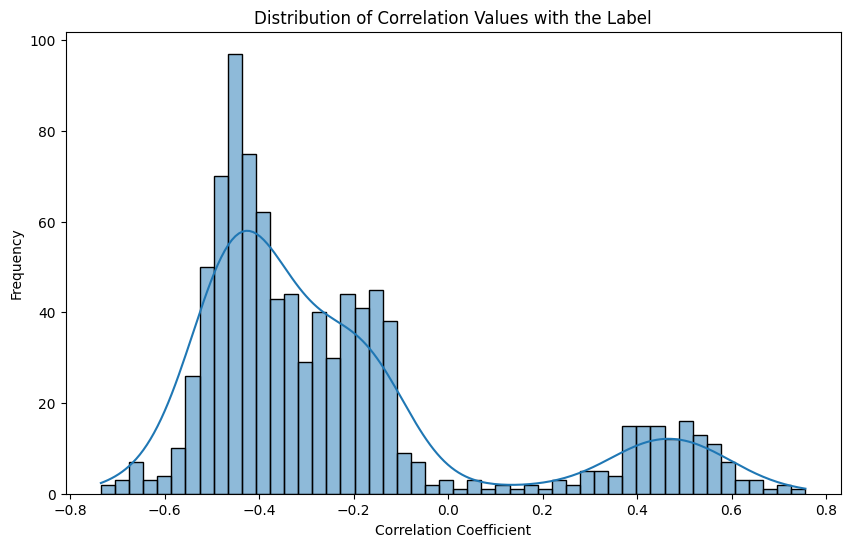

In [5]:
import seaborn as sns
# Create a distribution plot of the correlation values
plt.figure(figsize=(10, 6))
sns.histplot(correlation_with_label, kde=True, bins=50)
plt.title('Distribution of Correlation Values with the Label')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.show()

In [6]:
# Count the number of features with correlation -0.2 < x < 0.2 and those outside this range
within_range = ((correlation_with_label > -0.5) & (correlation_with_label < 0.5)).sum()
outside_range = ((correlation_with_label <= -0.5) | (correlation_with_label >= 0.5)).sum()

print(f'Number of features with correlation -0.3 < x < 0.3: {within_range}')
print(f'Number of features with correlation outside this range: {outside_range}')

Number of features with correlation -0.3 < x < 0.3: 774
Number of features with correlation outside this range: 154


In [7]:
# Filter columns based on correlation value <= -0.2 or >= 0.2
filtered_columns_02 = correlation_with_label[(correlation_with_label <= -0.2) | (correlation_with_label >= 0.2)].index
X_df_02 = X_df[filtered_columns_02]
print(len(filtered_columns_02))

# Filter columns based on correlation value <= -0.2 or >= 0.2
filtered_columns_03 = correlation_with_label[(correlation_with_label <= -0.5) | (correlation_with_label >= 0.5)].index
X_df_03 = X_df[filtered_columns_03]
print(len(filtered_columns_03))

769
154


In [8]:
y_df

,Sample_Name,label
0,TCGA-BC-A10Q-11A,0
1,TCGA-BC-A10R-11A,0
2,TCGA-BC-A10T-11A,0
3,TCGA-BC-A10U-11A,0
4,TCGA-BC-A10W-11A,0
...,...,...
428,TCGA-UB-A7MC-01A,3
429,TCGA-UB-A7MD-01A,3
430,TCGA-WX-AA44-01A,3
431,TCGA-XR-A8TD-01A,3


In [9]:
def dataset_prep(X_df, y_df):
    X = X_df.values
    y = y_df['label'].values
    # SMOTE
    sm = SMOTE(random_state=42)  # Set random seed for reproducibility
    X_res, y_res = sm.fit_resample(X, y)
    X_res = np.round(X_res, decimals=5)

    # Print the class distribution before and after SMOTE
    print("Original class distribution:")
    print({i: list(y).count(i) for i in range(len(set(y)))})
    print("Class distribution after SMOTE:")
    print({i: list(y_res).count(i) for i in range(len(set(y_res)))})

    return X_res, y_res

def split_data(X_res, y_res):
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
    # Counting the occurrences of each class in the training and test sets
    train_class_counts = np.bincount(y_train)
    test_class_counts = np.bincount(y_test)

    # Creating dictionaries to store class distributions
    train_class_distribution = {i: count for i, count in enumerate(train_class_counts)}
    test_class_distribution = {i: count for i, count in enumerate(test_class_counts)}

    # Printing the class distributions in the specified format
    print('Train class:')
    print(train_class_distribution)
    print('Test class:')
    print(test_class_distribution)

    return X_train, X_test, y_train, y_test

def scale_features(X_train, X_test, scaling_option='minmax'):
    if scaling_option == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_option == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError("scaling_option should be either 'minmax' or 'standard'")
    # Fit the scaler on the training data
    scaler.fit(X_train)
    # Transform both training and test data
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

def export_df(X_df, y_df):
    X = X_df.values
    y = y_df['label'].values

    # SMOTE
    sm = SMOTE(random_state=42)  # Set random seed for reproducibility
    X_res, y_res = sm.fit_resample(X, y)
    X_res = np.round(X_res, decimals=5)

    # Replace labels in y_df
    label_mapping = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
    y_df['label'] = y_df['label'].map(label_mapping)
    y_res = np.vectorize(label_mapping.get)(y_res)

    # Print the class distribution before and after SMOTE
    print("Original class distribution:")
    print({label_mapping[i]: list(y).count(i) for i in range(len(set(y)))})
    print("Class distribution after SMOTE:")
    print({label_mapping[i]: list(y_res).count(label_mapping[i]) for i in range(len(set(y_res)))})

    # Convert resampled data back to DataFrame
    X_res_df = pd.DataFrame(X_res, columns=X_df.columns)
    y_res_df = pd.DataFrame({'label': y_res})

    # Identify synthetic data
    num_original = len(y)
    num_synthetic = len(y_res) - num_original

    # Create new Sample_Name for synthetic data
    synthetic_names = []
    synthetic_count = {label: 1 for label in label_mapping.values()}
    for label in y_res[num_original:]:
        synthetic_names.append(f"SMT_{label}_{synthetic_count[label]}")
        synthetic_count[label] += 1

    # Combine original and synthetic Sample_Name
    original_names = y_df['Sample_Name'].tolist()
    all_names = original_names + synthetic_names

    # Add Sample_Name to y_res_df
    y_res_df['Sample_Name'] = all_names

    return X_res_df, y_res_df

# Example usage:
# X_train_scaled, X_test_scaled = scale_features(X_train, X_test, scaling_option='minmax')
# X_train_scaled, X_test_scaled = scale_features(X_train, X_test, scaling_option='standard')




In [10]:
X_smt_df, y_smt_df = export_df(X_df, y_df)

Original class distribution:
{'NT': 100, 'G1': 46, 'G2': 167, 'G3': 120}
Class distribution after SMOTE:
{'NT': 167, 'G1': 167, 'G2': 167, 'G3': 167}


In [11]:
X_smt_df

,AAK1,ABCA4,ABHD12B,ABLIM1,ABLIM3,ABTB2,ACAT2,ACBD5,ACOX3,ACSL3,...,ZNF696,ZNF700,ZNF738,ZNF790,ZNF862,ZNRF1,ZPBP,ZSCAN12L1,ZSCAN18,ZSCAN22
0,0.04105,0.95156,0.31702,0.94398,0.97272,0.01851,0.03661,0.02353,0.75057,0.87453,...,0.11869,0.03293,0.95289,0.01744,0.09145,0.13929,0.78953,0.19557,0.93291,0.09370
1,0.03706,0.84891,0.31341,0.87455,0.95469,0.02329,0.01536,0.02999,0.79407,0.88269,...,0.15566,0.02709,0.92718,0.01743,0.11169,0.09054,0.63656,0.23732,0.92956,0.06030
2,0.04765,0.90316,0.31322,0.95461,0.95257,0.02078,0.00842,0.02244,0.64830,0.83707,...,0.15685,0.01407,0.96188,0.02726,0.18945,0.06610,0.59957,0.22367,0.83886,0.03345
3,0.04697,0.93180,0.29168,0.96668,0.94596,0.02906,0.00629,0.01997,0.81916,0.88557,...,0.16480,0.01403,0.97430,0.01071,0.14919,0.13590,0.71551,0.23629,0.91128,0.03207
4,0.03593,0.88004,0.39725,0.97076,0.93467,0.02710,0.00856,0.02105,0.85712,0.80809,...,0.19934,0.01959,0.96583,0.01815,0.13817,0.10262,0.59318,0.22769,0.92158,0.03453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,0.03813,0.59299,0.74548,0.35992,0.95884,0.01835,0.00831,0.02157,0.30743,0.65787,...,0.11877,0.02484,0.80926,0.02355,0.07876,0.17458,0.89582,0.54373,0.35964,0.06188
664,0.04850,0.86145,0.55784,0.51512,0.95811,0.02029,0.01314,0.02253,0.58159,0.68472,...,0.11568,0.02805,0.81663,0.02572,0.07479,0.19868,0.91219,0.50941,0.50726,0.05567
665,0.03972,0.83009,0.61055,0.79411,0.92006,0.02936,0.01014,0.02692,0.77030,0.83811,...,0.15571,0.01651,0.96733,0.01988,0.12358,0.11328,0.68069,0.37071,0.84080,0.03957
666,0.03287,0.28687,0.24511,0.44451,0.83507,0.02393,0.01020,0.02085,0.29598,0.75478,...,0.13193,0.03438,0.76313,0.02041,0.09654,0.16276,0.69520,0.30353,0.35521,0.05003


In [12]:
y_smt_df

,label,Sample_Name
0,NT,TCGA-BC-A10Q-11A
1,NT,TCGA-BC-A10R-11A
2,NT,TCGA-BC-A10T-11A
3,NT,TCGA-BC-A10U-11A
4,NT,TCGA-BC-A10W-11A
...,...,...
663,G3,SMT_G3_43
664,G3,SMT_G3_44
665,G3,SMT_G3_45
666,G3,SMT_G3_46


In [13]:
X_smt_df.to_csv('X_smt_df.txt', sep=' ', index = False)
y_smt_df.to_csv('y_smt_df.txt', sep=' ', index = False)

##G2G3dataset

In [14]:


g2g3 = f'{dir}/G2G3_genelist.txt'
g2g3genes = pd.read_csv(g2g3, delimiter=' ')
X_df_g2g3 = X_df[g2g3genes['x']]

X_df_g2g3


,HAPLN2,ANG,SEPT8,LOC648691,FAM195B,MYH10,ZNF589,ANKRD39,PAPLN,NUDCD3,...,PIGT,EIF2S2,C1orf77,SNORD24,ATP5O,MIR376B,ZSCAN18,YWHAZ,CCDC64,C5orf15
0,0.95989,0.61363,0.58192,0.73036,0.06325,0.05961,0.02966,0.07461,0.24407,0.07275,...,0.12295,0.04805,0.83164,0.89440,0.08029,0.93313,0.93291,0.36527,0.13276,0.04628
1,0.89563,0.62961,0.28099,0.68370,0.07717,0.07554,0.02058,0.07517,0.25557,0.07354,...,0.12110,0.06187,0.81939,0.86037,0.03697,0.84175,0.92956,0.28576,0.14052,0.06906
2,0.92398,0.44850,0.33419,0.65558,0.07613,0.11650,0.03266,0.11873,0.20110,0.15207,...,0.14000,0.07689,0.73313,0.76811,0.09396,0.88994,0.83886,0.16046,0.21296,0.07747
3,0.94833,0.65811,0.52217,0.65280,0.07793,0.06924,0.01933,0.10585,0.40822,0.12506,...,0.15206,0.07322,0.76426,0.80362,0.07755,0.91002,0.91128,0.24604,0.19165,0.07097
4,0.91870,0.58896,0.31417,0.69463,0.06260,0.08377,0.02355,0.12526,0.24513,0.13894,...,0.15612,0.07132,0.77898,0.82465,0.10120,0.75077,0.92158,0.23011,0.21027,0.06166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,0.83246,0.61885,0.03790,0.69538,0.07598,0.08814,0.02878,0.09720,0.58082,0.10395,...,0.10996,0.05266,0.75100,0.49485,0.07222,0.03525,0.25960,0.08404,0.17703,0.07954
429,0.93818,0.52775,0.14209,0.52186,0.08306,0.08450,0.02191,0.09179,0.05854,0.10656,...,0.13001,0.04971,0.46617,0.46387,0.07937,0.33334,0.49939,0.06126,0.19246,0.06140
430,0.42485,0.94840,0.30937,0.73381,0.07715,0.08480,0.02615,0.08709,0.44358,0.08516,...,0.11041,0.06262,0.77556,0.57390,0.06530,0.92793,0.69672,0.22456,0.15855,0.05511
431,0.94565,0.70193,0.37733,0.46198,0.06118,0.05509,0.01947,0.07087,0.09678,0.07391,...,0.11134,0.06277,0.47843,0.51692,0.06372,0.48249,0.42942,0.04953,0.16778,0.08258


In [15]:
# Remove rows where y_df['label'] is 0 or 1
mask = ~y_df['label'].isin([0, 1])
X_df0 = X_df[mask]
y_df0 = y_df[mask]

# Resetting the index after removing rows to ensure indexes align correctly
X_df0.reset_index(drop=True, inplace=True)
y_df0.reset_index(drop=True, inplace=True)

# Convert values in y_df['label']: 2 into 0, and 3 into 1
y_df0['label'] = y_df0['label'].map({2: 0, 3: 1})

# Display the resulting DataFrames
print(X_df0)
print(y_df0)

        AAK1    ABCA4  ABHD12B   ABLIM1   ABLIM3    ABTB2    ACAT2    ACBD5  \
0    0.04105  0.95156  0.31702  0.94398  0.97272  0.01851  0.03661  0.02353   
1    0.03706  0.84891  0.31341  0.87455  0.95469  0.02329  0.01536  0.02999   
2    0.04765  0.90316  0.31322  0.95461  0.95257  0.02078  0.00842  0.02244   
3    0.04697  0.93180  0.29168  0.96668  0.94596  0.02906  0.00629  0.01997   
4    0.03593  0.88004  0.39725  0.97076  0.93467  0.02710  0.00856  0.02105   
..       ...      ...      ...      ...      ...      ...      ...      ...   
428  0.02302  0.75892  0.84318  0.28777  0.95446  0.03824  0.01142  0.02337   
429  0.02616  0.41857  0.38136  0.73464  0.92737  0.03846  0.01340  0.02240   
430  0.03698  0.91240  0.57929  0.87591  0.87208  0.02371  0.01407  0.02134   
431  0.04806  0.51589  0.44248  0.83412  0.91276  0.02666  0.00886  0.02204   
432  0.03606  0.67654  0.46795  0.59719  0.95896  0.02726  0.01603  0.02529   

       ACOX3    ACSL3  ...   ZNF696   ZNF700   ZNF7

In [16]:
X_res0, y_res0 = dataset_prep(X_df0, y_df0)
print('===============================================================')
X_train_valid0, X_test0, y_train_valid0, y_test0 = split_data(X_res0, y_res0)
print('===============================================================')
X_train_valid_scaled0, X_test_scaled0 = scale_features(X_train_valid0, X_test0, scaling_option='minmax')
print('Scaling success')
print('===============================================================')


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_array_api.py:245: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y contains NaN.

In [ ]:
y_df0

In [ ]:
X_res, y_res = dataset_prep(X_df, y_df)
print('===============================================================')
X_train_valid, X_test, y_train_valid, y_test = split_data(X_res, y_res)
print('===============================================================')
X_train_valid_scaled, X_test_scaled = scale_features(X_train_valid, X_test, scaling_option='minmax')
print('Scaling success')
print('===============================================================')


In [ ]:
y_res

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# Initialize the LabelBinarizer
lb = LabelBinarizer()

# Fit and transform the training data
y_train_hot = lb.fit_transform(y_train_valid)

# Transform the testing data
y_test_hot = lb.transform(y_test)

In [ ]:
X_02, y_02 = dataset_prep(X_df_02, y_df)
print('===============================================================')
X_train_valid_02, X_test_02, y_train_valid_02, y_test_02 = split_data(X_02, y_02)
print('===============================================================')
X_train_valid_scaled_02, X_test_scaled_02 = scale_features(X_train_valid_02, X_test_02, scaling_option='minmax')
print('Scaling success')
print('===============================================================')

In [ ]:
X_03, y_03 = dataset_prep(X_df_03, y_df)
print('===============================================================')
X_train_valid_03, X_test_03, y_train_valid_03, y_test_03 = split_data(X_03, y_03)
print('===============================================================')
X_train_valid_scaled_03, X_test_scaled_03 = scale_features(X_train_valid_03, X_test_03, scaling_option='minmax')
print('Scaling success')
print('===============================================================')

<br>

#2. Data distribution visualization

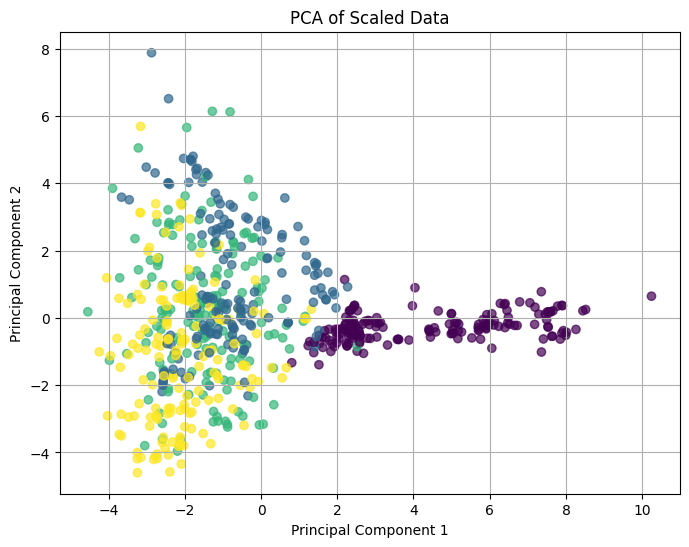

In [ ]:

# Scaling the data
scaler = MinMaxScaler()
X_df_scaled = scaler.fit_transform(X_res)

# Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Visualize the PCA results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res, cmap='viridis', alpha=0.7)
#plt.colorbar(scatter)
plt.title('PCA of Scaled Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)


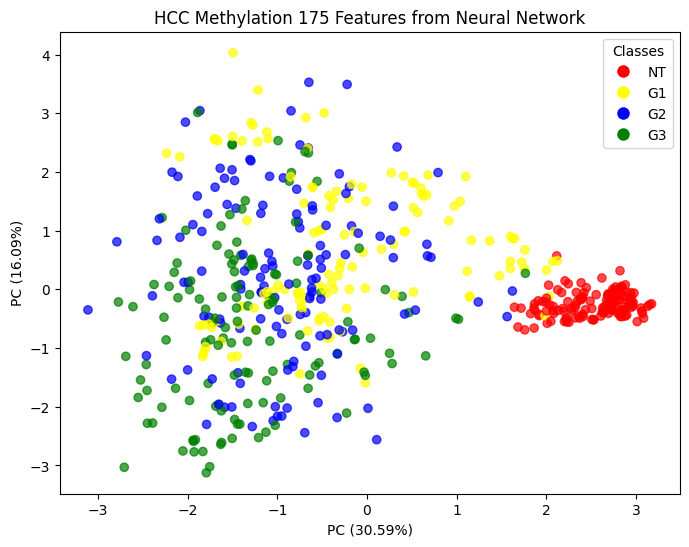

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming X_res is your features dataframe and y_res is your target array
# Replace X_res and y_res with your actual data variables

# Example:
# X_res = pd.DataFrame(np.random.randn(100, 5))  # Replace with your data
# y_res = np.random.randint(0, 4, 100)  # Replace with your target variable (0, 1, 2, 3)

# Step 1: Scaling the data
scaler = MinMaxScaler()
#X_df_scaled = scaler.fit_transform(X_res)
X_df_scaled = X_train_importances
# Step 2: Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Step 3: Visualize the PCA results
colors = {0: 'red', 1: 'yellow', 2: 'blue', 3: 'green'}
c_list = [colors[label] for label in y_train_valid]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c_list, alpha=0.7)

# Add a legend
# Add a legend
class_labels = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
scatter_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[cls], markersize=10, label=class_labels[cls]) for cls in classes]
plt.legend(handles=scatter_labels, title="Classes")


# Display the percentage of variance explained
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f'PC ({pc1_variance:.2f}%)')
plt.ylabel(f'PC ({pc2_variance:.2f}%)')

plt.title('HCC Methylation 175 Features from Neural Network')
#plt.grid(True)
plt.show()


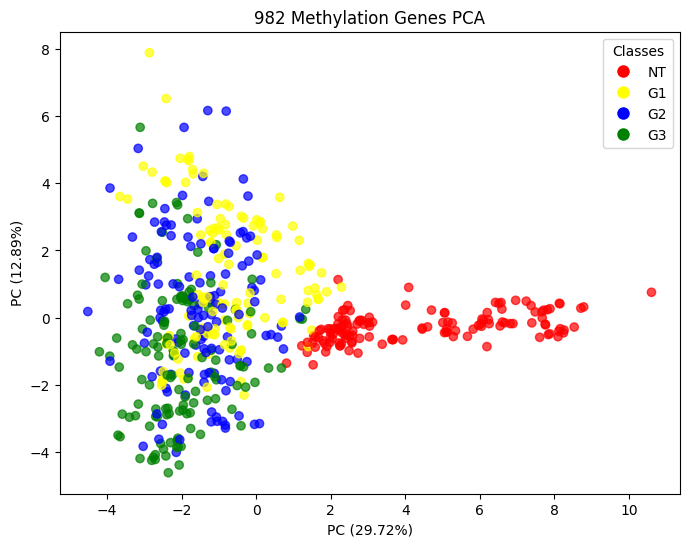

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming X_res is your features dataframe and y_res is your target array
# Replace X_res and y_res with your actual data variables

# Example:
# X_res = pd.DataFrame(np.random.randn(100, 5))  # Replace with your data
# y_res = np.random.randint(0, 4, 100)  # Replace with your target variable (0, 1, 2, 3)

# Step 1: Scaling the data
scaler = MinMaxScaler()
#X_df_scaled = scaler.fit_transform(X_res)
X_df_scaled = X_train_valid_scaled
# Step 2: Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Step 3: Visualize the PCA results
colors = {0: 'red', 1: 'yellow', 2: 'blue', 3: 'green'}
c_list = [colors[label] for label in y_train_valid]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c_list, alpha=0.7)
classes=np.unique(y_train_valid)
# Add a legend
# Add a legend
class_labels = {0: 'NT', 1: 'G1', 2: 'G2', 3: 'G3'}
scatter_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[cls], markersize=10, label=class_labels[cls]) for cls in classes]
plt.legend(handles=scatter_labels, title="Classes")


# Display the percentage of variance explained
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f'PC ({pc1_variance:.2f}%)')
plt.ylabel(f'PC ({pc2_variance:.2f}%)')

plt.title('982 Methylation Genes PCA')
#plt.grid(True)
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


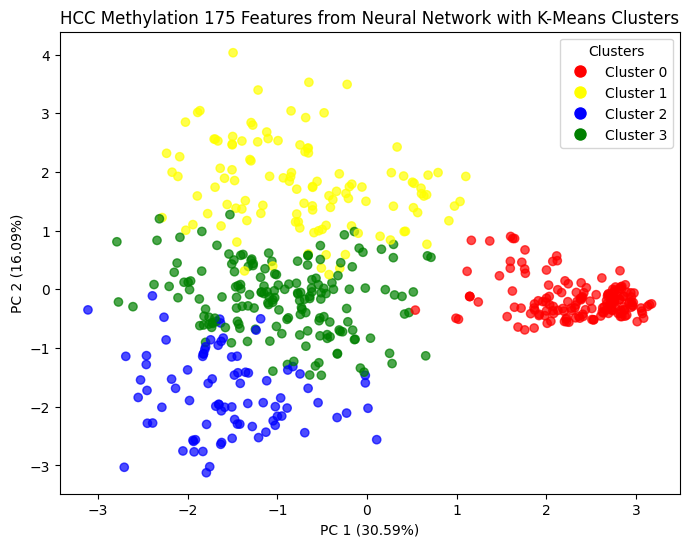

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming X_res is your features dataframe and y_res is your target array
# Replace X_res and y_res with your actual data variables

# Example:
# X_res = pd.DataFrame(np.random.randn(100, 5))  # Replace with your data
# y_res = np.random.randint(0, 4, 100)  # Replace with your target variable (0, 1, 2, 3)

# Step 1: Scaling the data
scaler = MinMaxScaler()
#X_df_scaled = scaler.fit_transform(X_res)
X_df_scaled = X_train_importances

# Step 2: Perform K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)  # Adjust the number of clusters as needed
kmeans_labels = kmeans.fit_predict(X_df_scaled)

# Step 3: Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Step 4: Visualize the PCA results with K-Means cluster colors
colors = {0: 'red', 1: 'yellow', 2: 'blue', 3: 'green'}
c_list = [colors[label] for label in kmeans_labels]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c_list, alpha=0.7)

# Add a legend
class_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
scatter_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[cls], markersize=10, label=class_labels[cls]) for cls in class_labels]
plt.legend(handles=scatter_labels, title="Clusters")

# Display the percentage of variance explained
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f'PC 1 ({pc1_variance:.2f}%)')
plt.ylabel(f'PC 2 ({pc2_variance:.2f}%)')

plt.title('HCC Methylation 175 Features from Neural Network with K-Means Clusters')
#plt.grid(True)
plt.show()


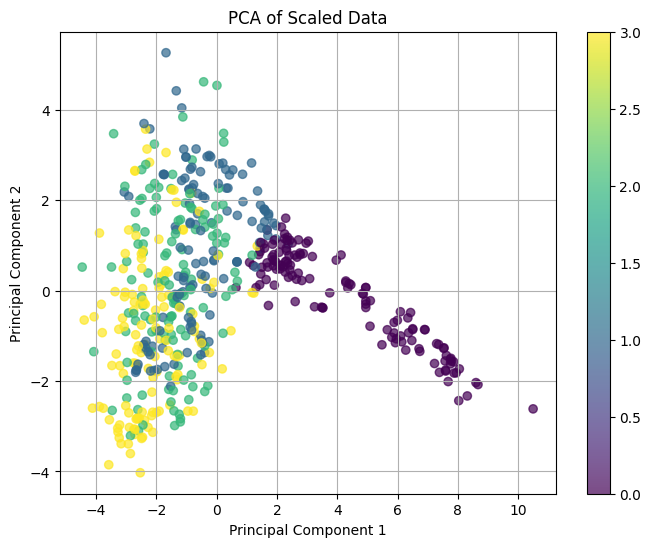

In [ ]:
# Scaling the data
scaler = MinMaxScaler()
X_df_scaled = scaler.fit_transform(X_train_valid_scaled_02)

# Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Visualize the PCA results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_valid, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('PCA of Scaled Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

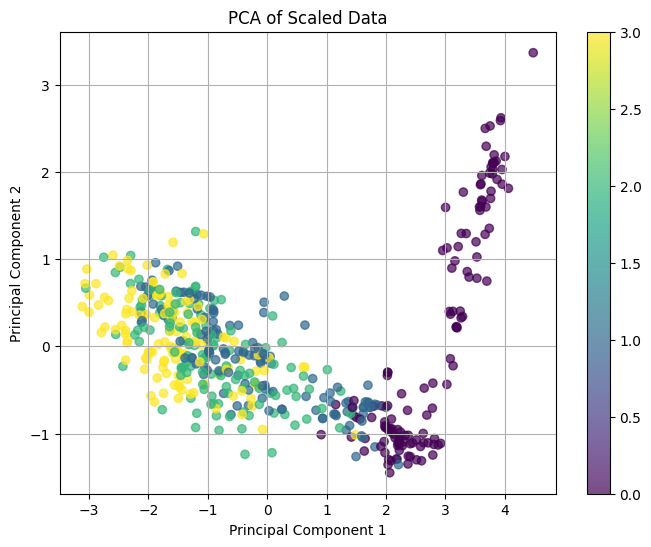

In [ ]:
# Scaling the data
scaler = MinMaxScaler()
X_df_scaled = scaler.fit_transform(X_train_valid_scaled_03)

# Perform PCA
pca = PCA(n_components=2)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_df_scaled)

# Visualize the PCA results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_valid, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('PCA of Scaled Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

<br>

#4. Crossvalidation

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    class_names = ['NT', 'G1', 'G2', 'G3']

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(len(class_names))}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(len(class_names)):
            tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(len(class_names))}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')


def plot_confusion_matrices(cms, class_names, fig, model_title):
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()


#Evaluation test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    class_names = ['NT', 'G1', 'G2', 'G3']

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(len(class_names))}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(len(class_names)):
            tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(len(class_names))}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')



def plot_confusion_matrices(cms, class_names, fig, model_title):
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()
'''
Evaluation test
[ ]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
[ ]
'''


'\nEvaluation test\n[ ]\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.preprocessing import label_binarize\n[ ]\n'

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

def calculate_metrics(model, X_train, X_test, y_train, y_test, cms):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')  # Sensitivity
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')  # Assuming the classifier has predict_proba method

    # Calculate sensitivity and specificity for each class
    sensitivity = recall_score(y_test, y_pred, average=None)
    # Compute specificity for each class
    specificity = []
    for i in range(len(class_names)):
        # True Negatives (TN): Sum of all elements except those in the row and column of the current class
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])

        # False Positives (FP): Sum of elements in the column of the current class, excluding the true positive element
        fp = cm[:, i].sum() - cm[i, i]

        # Calculate specificity for the current class
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, specificity, sensitivity

def plot_confusion_matrix_single(cm, class_names, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    print(cm_normalized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    fig, ax = plt.subplots()
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds')
    disp.plot(values_format='.2f', cmap='Reds', colorbar=False, ax=ax)  # Plot without the default colorbar
    plt.title(title)
    plt.xlabel('Predicted label (%)')
    plt.ylabel('True label (%)')

    # Add the color bar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Percentage (%)', rotation=-90, va="bottom")
    plt.show()

def plot_decision_boundary(model, X, y, title, class_names):
    # Perform PCA to reduce to two dimensions
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a meshgrid covering the PCA-transformed feature space
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    # Predict the class for each point in the meshgrid
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the data points
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
    plt.show()

def evaluation_test(X_train, X_test, y_train, y_test, classifier, model_title, class_names):
    classifier.fit(X_train, y_train)

    # Step 4: Make predictions on the testing data
    y_pred = classifier.predict(X_test)

    # Step 5: Evaluate the model
    # Calculate accuracy
    cms = []
    accuracy, precision, recall, f1, auc, cm, specificity, sensitivity = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

    # Output the results
    print(f"Evaluation metrics {model_title}")
    print(f"Accuracy: {accuracy*100:.2f} %")
    print(f"Precision: {precision*100:.2f} %")
    print(f"Recall (Macro-Averaged Sensitivity): {recall*100:.2f} %")
    print(f"F1-score: {f1*100:.2f} %")
    print(f"AUC: {auc*100:.2f} %")

    print("Sensitivity (Recall) for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {sensitivity[idx]*100:.2f} %")

    print("Specificity for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {specificity[idx]*100:.2f} %")

    print(f"Confusion Matrix {model_title}:")

    plot_confusion_matrix_single(cm, class_names=class_names, title=model_title)

    # Plot decision boundary using PCA to reduce to 2D
    plot_decision_boundary(classifier, X_test, y_test, title=f"Decision Boundary - {model_title}", class_names=class_names)


In [ ]:
def plot_confusion_matrix_single(cm, class_names, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    print(cm_normalized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    fig, ax = plt.subplots()
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds')
    disp.plot(values_format='.2f', cmap='Reds', colorbar=False, ax=ax)  # Plot without the default colorbar
    plt.title(title)
    plt.xlabel('Predicted label (%)')
    plt.ylabel('True label (%)')

    # Add the color bar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Percentage (%)', rotation=-90, va="bottom")
    plt.show()

def evaluation_test(X_train, X_test, y_train, y_test, classifier, model_title):
    classifier.fit(X_train, y_train)

    # Step 4: Make predictions on the testing data
    y_pred = classifier.predict(X_test)

    # Step 5: Evaluate the model
    # Calculate accuracy
    cms=[]
    accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, cms)

    # Output the results
    print(f"Evaluation metrics {model_title}")
    print(f"Accuracy: {accuracy*100:.2f} %")
    print(f"Precision: {precision*100:.2f} %")
    print(f"Recall: {recall*100:.2f} %")
    print(f"F1-score: {f1*100:.2f} %")
    print(f"Confusion Matrix {model_title}:")

    plot_confusion_matrix_single(cm, class_names=class_names, title=model_title)


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

def calculate_metrics(model, X_train, X_test, y_train, y_test, cms):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')  # Sensitivity
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')  # Assuming the classifier has predict_proba method

    # Calculate sensitivity and specificity for each class
    sensitivity = recall_score(y_test, y_pred, average=None)
    # Compute specificity for each class
    specificity = []
    for i in range(len(class_names)):
        # True Negatives (TN): Sum of all elements except those in the row and column of the current class
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])

        # False Positives (FP): Sum of elements in the column of the current class, excluding the true positive element
        fp = cm[:, i].sum() - cm[i, i]

        # Calculate specificity for the current class
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, specificity, sensitivity

def plot_confusion_matrix_single(cm, class_names, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    print(cm_normalized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    fig, ax = plt.subplots()
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds')
    disp.plot(values_format='.2f', cmap='Reds', colorbar=False, ax=ax)  # Plot without the default colorbar
    plt.title(title)
    plt.xlabel('Predicted label (%)')
    plt.ylabel('True label (%)')

    # Add the color bar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Percentage (%)', rotation=-90, va="bottom")
    plt.show()

def plot_decision_boundary(model, X, y, title, class_names, random_state=42):
    # Perform PCA to reduce to two dimensions with a fixed random_state
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)

    # Create a meshgrid covering the PCA-transformed feature space
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    # Predict the class for each point in the meshgrid
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the data points
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
    plt.show()

def evaluation_test(X_train, X_test, y_train, y_test, classifier, model_title, class_names):
    classifier.fit(X_train, y_train)

    # Step 4: Make predictions on the testing data
    y_pred = classifier.predict(X_test)

    # Step 5: Evaluate the model
    # Calculate accuracy
    cms = []
    accuracy, precision, recall, f1, auc, cm, specificity, sensitivity = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

    # Output the results
    print(f"Evaluation metrics {model_title}")
    print(f"Accuracy: {accuracy*100:.2f} %")
    print(f"Precision: {precision*100:.2f} %")
    print(f"Recall (Macro-Averaged Sensitivity): {recall*100:.2f} %")
    print(f"F1-score: {f1*100:.2f} %")
    print(f"AUC: {auc*100:.2f} %")

    print("Sensitivity (Recall) for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {sensitivity[idx]*100:.2f} %")

    print("Specificity for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {specificity[idx]*100:.2f} %")

    print(f"Confusion Matrix {model_title}:")

    plot_confusion_matrix_single(cm, class_names=class_names, title=model_title)

    # Plot decision boundary using PCA to reduce to 2D
    plot_decision_boundary(classifier, X_test, y_test, title=f"Decision Boundary - {model_title}", class_names=class_names)


#select features

In [ ]:
def select_features(features_score, X_df, X_train, X_test, top=100):
    #features_score = features_score.sort_values(by='G1', ascending=False)

    # Select the top 'top' features based on the index of features_score
    top_features = features_score.index[:top]
    print(top_features)

    # Map the top features to their column indices in X_df
    index_mapped = [X_df.columns.get_loc(feature) for feature in top_features]

    # Filter the columns in X_scaled based on the mapped indices
    top_train = X_train[:, index_mapped]
    top_test = X_test[:, index_mapped]

    return top_train, top_test, top_features

In [ ]:
def select_features_cv(features_score, X_df, X_train, top=100):
    #features_score = features_score.sort_values(by='G1', ascending=False)

    # Select the top 'top' features based on the index of features_score
    top_features = features_score.index[:top]
    print(top_features)

    # Map the top features to their column indices in X_df
    index_mapped = [X_df.columns.get_loc(feature) for feature in top_features]

    # Filter the columns in X_scaled based on the mapped indices
    top_train = X_train[:, index_mapped]

    return top_train, top_features

#Crossvalidation with specifity and sensitivity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    sensitivity = recall_score(y_test, y_pred, average=None)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))
    return accuracy, precision, recall, f1, auc, cm, sensitivity, specificity

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    class_names = ['NT', 'G1', 'G2', 'G3']

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    sensitivity_scores = {label: [] for label in range(len(class_names))}
    specificity_scores = {label: [] for label in range(len(class_names))}
    tp_percentages = {label: [] for label in range(len(class_names))}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm, sensitivity, specificity = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(len(class_names)):
            sensitivity_scores[label].append(sensitivity[label] * 100)
            specificity_scores[label].append(specificity[label] * 100)
            tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    print('\n======================================================================')
    print(f'Sensitivity (Recall) CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = np.mean(sensitivity_scores[label]), np.std(sensitivity_scores[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

    print('\n======================================================================')
    print(f'Specificity CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = np.mean(specificity_scores[label]), np.std(specificity_scores[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = np.mean(tp_percentages[label]), np.std(tp_percentages[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')


def plot_confusion_matrices(cms, class_names, fig, model_title):
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()


<ipython-input-18-02c9bb5b3541>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-18-02c9bb5b3541>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


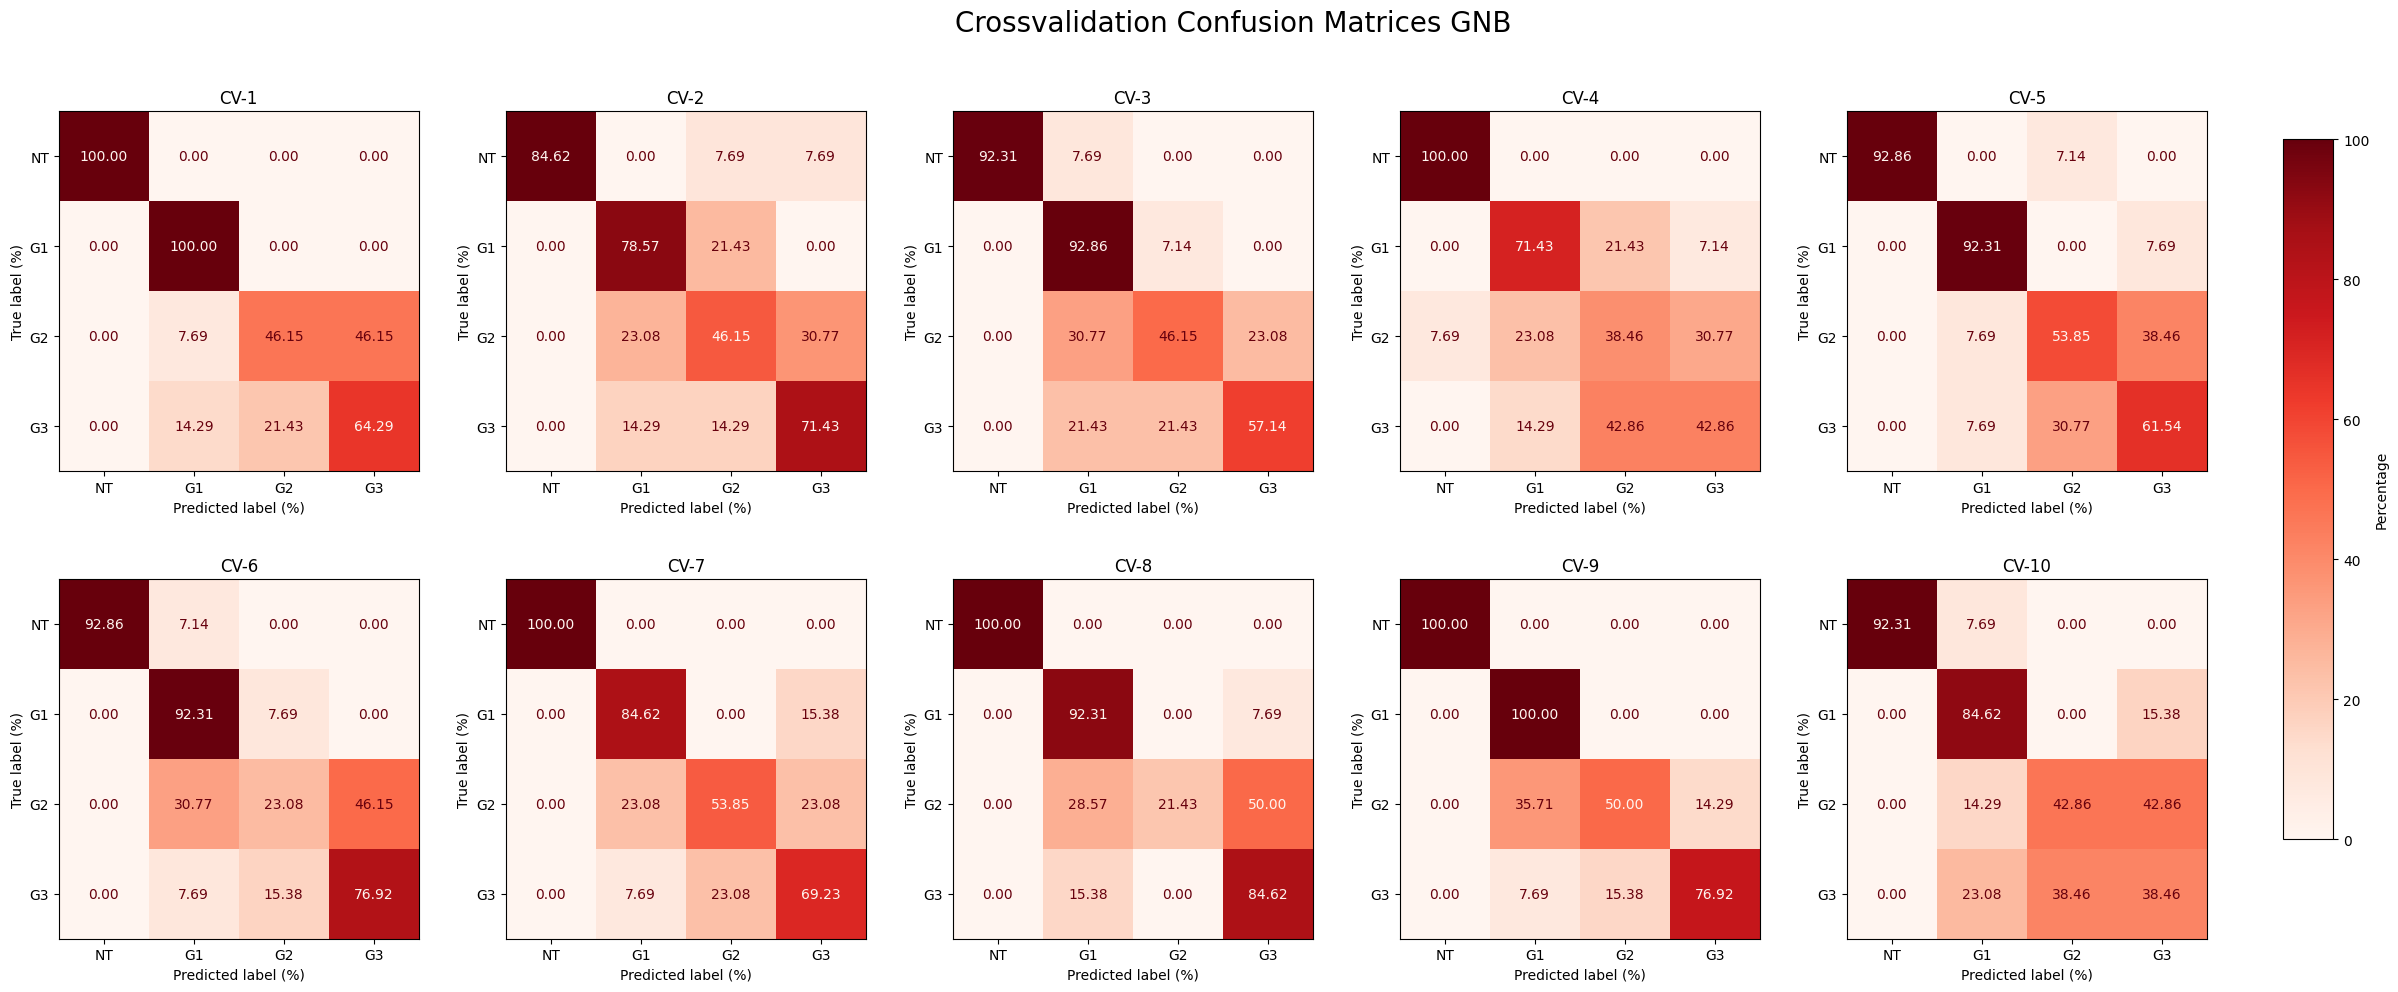

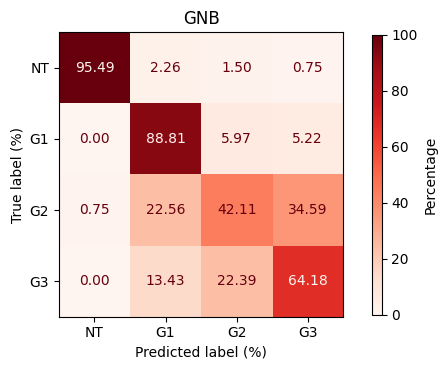

Cross-Validation Results GNB:
Accuracy: ['77.78', '70.37', '72.22', '62.96', '75.47', '71.70', '77.36', '73.58', '81.13', '64.15']
Precision: ['77.03', '71.22', '73.42', '62.38', '75.76', '70.36', '77.34', '81.50', '82.30', '64.24']
Recall: ['77.78', '70.37', '72.22', '62.96', '75.47', '71.70', '77.36', '73.58', '81.13', '64.15']
F1: ['76.71', '70.52', '71.52', '62.42', '75.51', '69.09', '76.97', '69.70', '80.16', '63.65']
AUC: ['93.21', '88.31', '87.95', '82.87', '90.89', '89.57', '90.17', '93.35', '91.48', '86.51']

Average Metrics CV GNB:
Accuracy: 72.67 +- 5.49
Precision: 73.55 +- 6.31
Recall: 72.67 +- 5.49
F1: 71.63 +- 5.50
AUC: 89.43 +- 3.03

Sensitivity (Recall) CV GNB:
NT: 95.49 ± 5.04
G1: 88.90 ± 8.63
G2: 42.20 ± 10.91
G3: 64.34 ± 14.12

Specificity CV GNB:
NT: 99.76 ± 0.73
G1: 87.25 ± 4.10
G2: 90.09 ± 5.67
G3: 86.50 ± 4.50

True positive CV GNB:
NT: 95.49 ± 5.04
G1: 88.90 ± 8.63
G2: 42.20 ± 10.91
G3: 64.34 ± 14.12


In [ ]:
gnb = GaussianNB()
crossvalidation(gnb, 'GNB',X_train_valid_scaled, y_train_valid)

<ipython-input-18-02c9bb5b3541>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-18-02c9bb5b3541>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


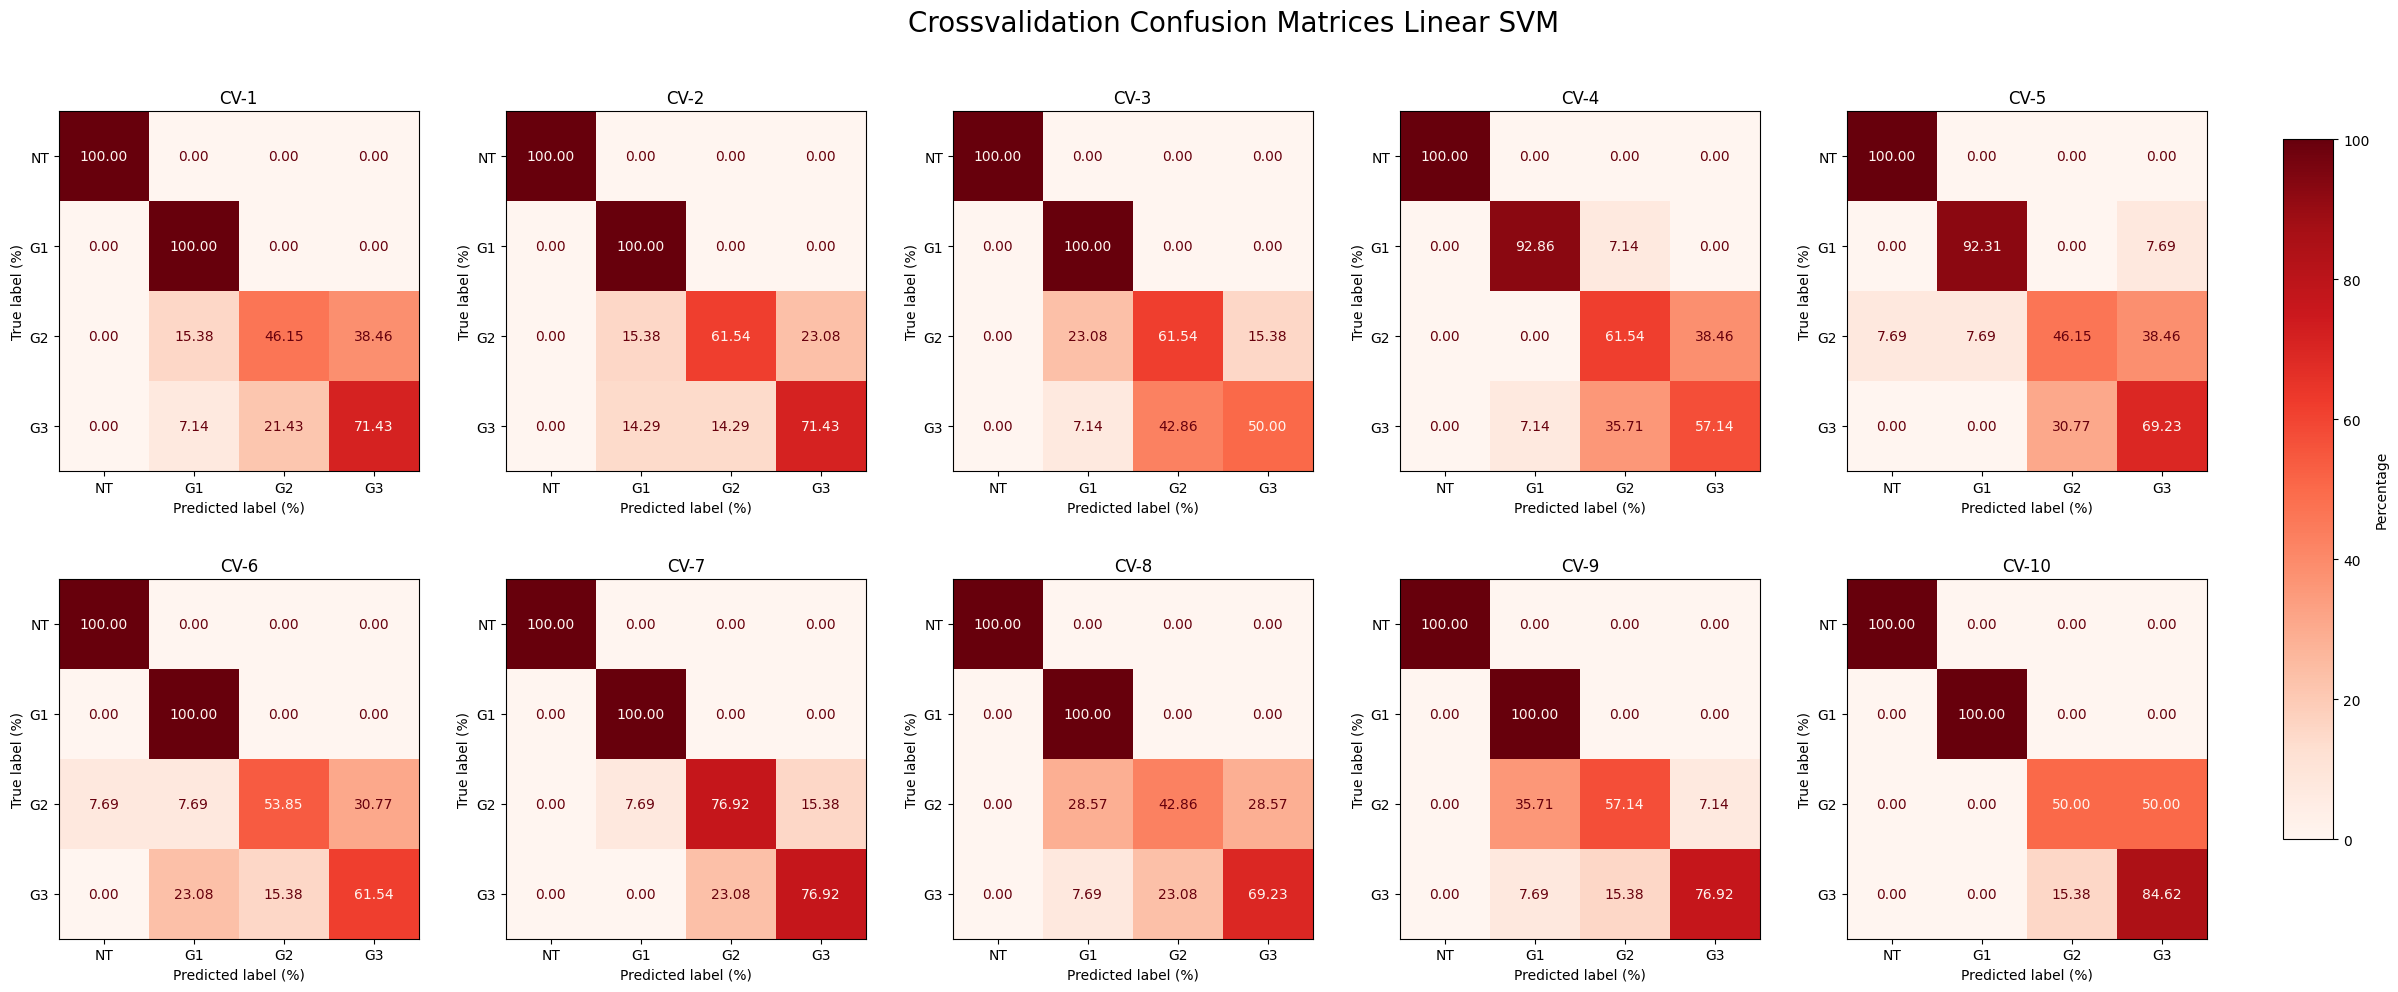

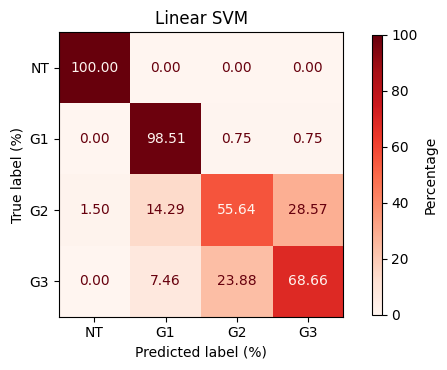

Cross-Validation Results Linear SVM:
Accuracy: ['79.63', '83.33', '77.78', '77.78', '77.36', '79.25', '88.68', '77.36', '83.02', '83.02']
Precision: ['78.76', '83.44', '78.16', '77.86', '76.73', '78.84', '88.50', '76.83', '84.74', '84.59']
Recall: ['79.63', '83.33', '77.78', '77.78', '77.36', '79.25', '88.68', '77.36', '83.02', '83.02']
F1: ['78.50', '82.71', '76.81', '77.78', '76.71', '78.07', '88.53', '75.86', '82.51', '82.54']
AUC: ['95.92', '94.78', '95.71', '95.37', '92.84', '96.73', '97.07', '95.83', '95.06', '96.29']

Average Metrics CV Linear SVM:
Accuracy: 80.72 +- 3.52
Precision: 80.85 +- 3.90
Recall: 80.72 +- 3.52
F1: 80.00 +- 3.77
AUC: 95.56 +- 1.13

Sensitivity (Recall) CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 55.77 ± 9.68
G3: 68.85 ± 9.69

Specificity CV Linear SVM:
NT: 99.49 ± 1.03
G1: 92.75 ± 4.80
G2: 91.81 ± 3.57
G3: 90.25 ± 4.53

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 55.77 ± 9.68
G3: 68.85 ± 9.69


In [ ]:
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_train_valid_scaled, y_train_valid)



<ipython-input-42-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


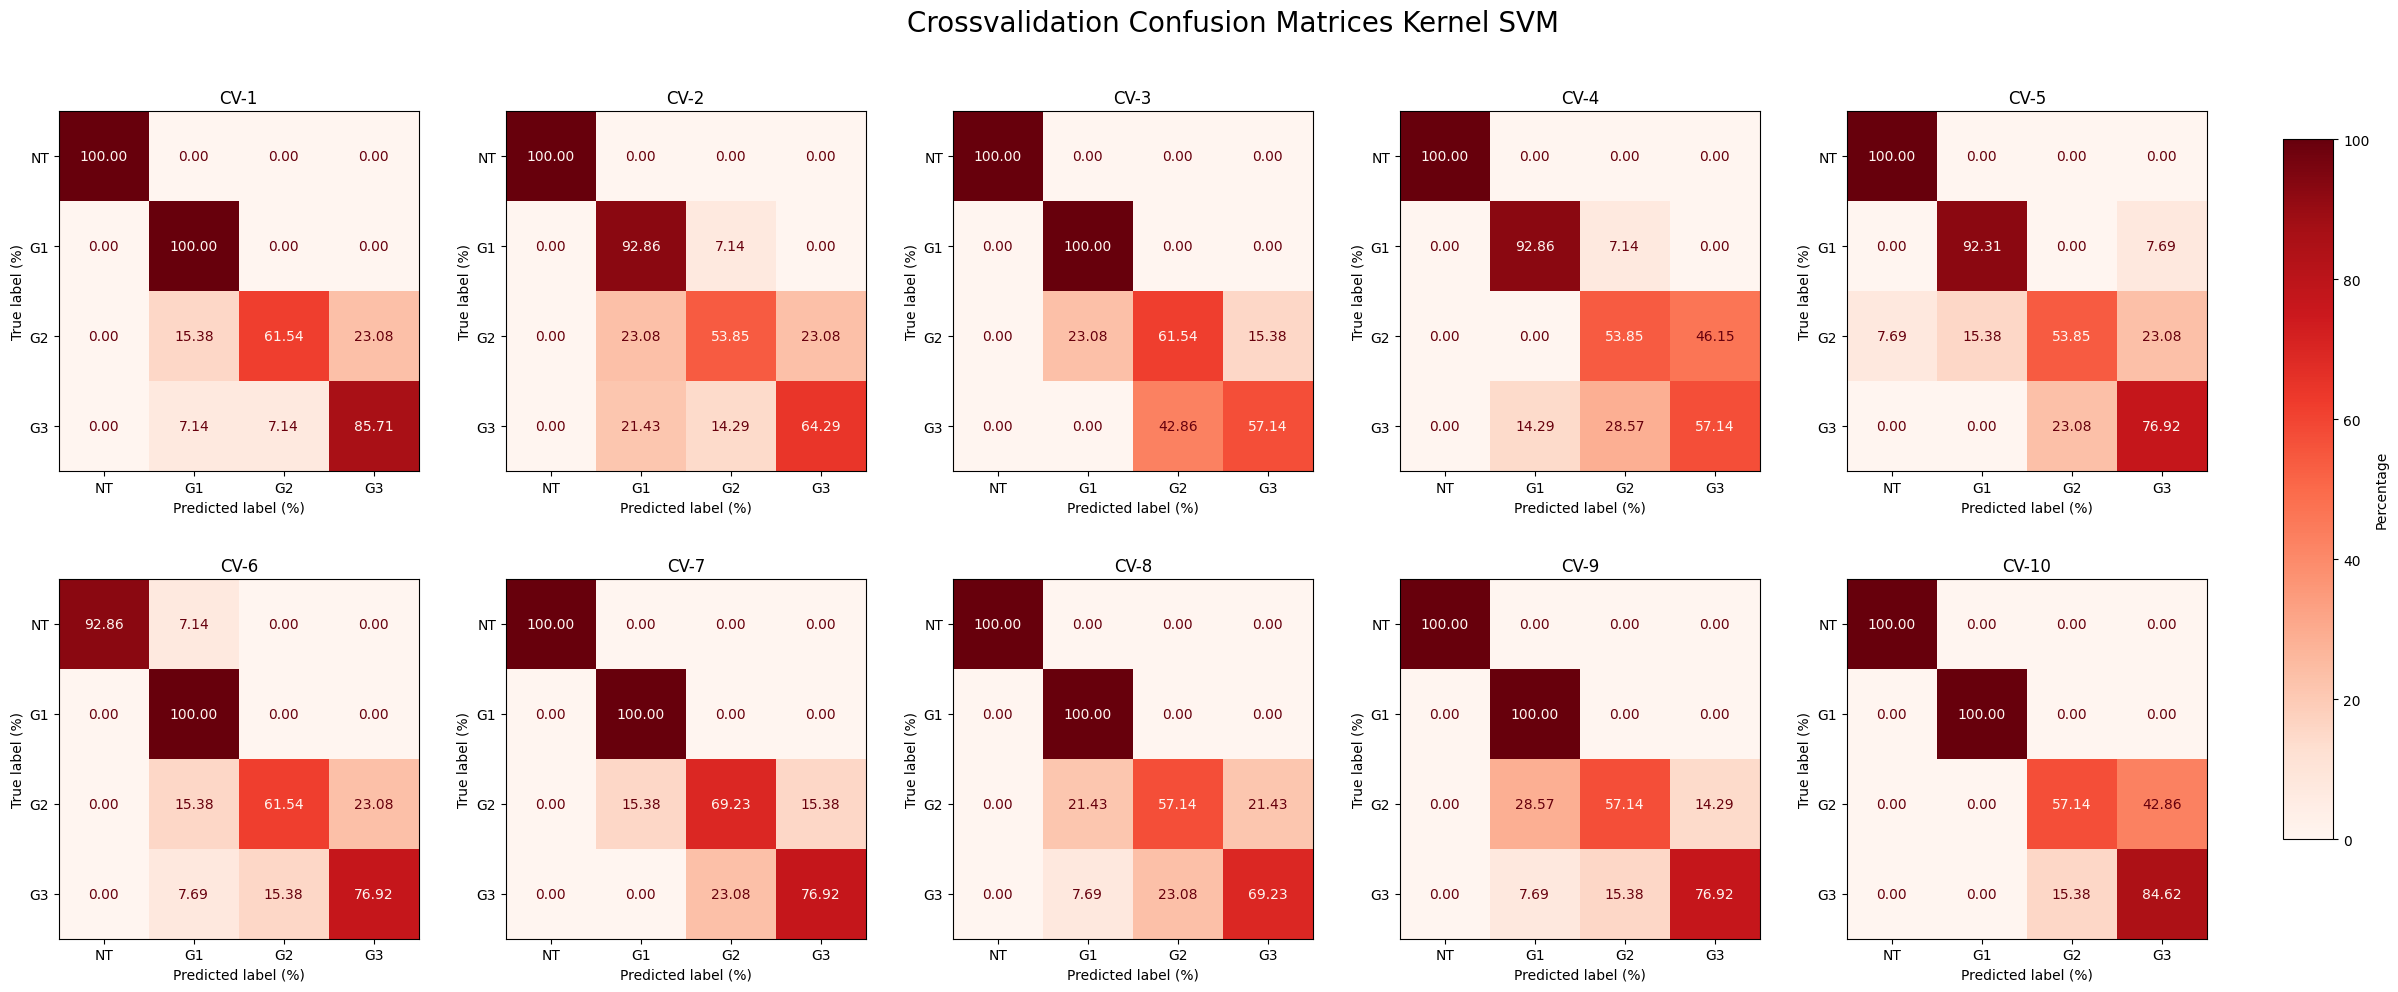

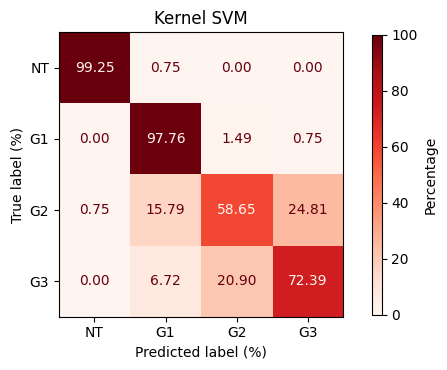

Cross-Validation Results Kernel SVM:
Accuracy: ['87.04', '77.78', '79.63', '75.93', '81.13', '83.02', '86.79', '81.13', '83.02', '84.91']
Precision: ['87.56', '78.11', '79.92', '75.40', '80.37', '83.66', '86.51', '80.89', '83.82', '86.06']
Recall: ['87.04', '77.78', '79.63', '75.93', '81.13', '83.02', '86.79', '81.13', '83.02', '84.91']
F1: ['86.46', '77.10', '79.04', '75.61', '80.41', '82.63', '86.47', '80.35', '82.33', '84.65']
AUC: ['97.80', '94.46', '96.87', '94.27', '93.17', '97.40', '96.97', '96.49', '94.82', '96.11']

Average Metrics CV Kernel SVM:
Accuracy: 82.04 +- 3.47
Precision: 82.23 +- 3.74
Recall: 82.04 +- 3.47
F1: 81.51 +- 3.52
AUC: 95.84 +- 1.47

Sensitivity (Recall) CV Kernel SVM:
NT: 99.29 ± 2.14
G1: 97.80 ± 3.36
G2: 58.68 ± 4.62
G3: 72.58 ± 9.74

Specificity CV Kernel SVM:
NT: 99.74 ± 0.77
G1: 92.25 ± 4.10
G2: 92.55 ± 3.41
G3: 91.50 ± 3.57

True positive CV Kernel SVM:
NT: 99.29 ± 2.14
G1: 97.80 ± 3.36
G2: 58.68 ± 4.62
G3: 72.58 ± 9.74


In [ ]:
svm_kernel = svm = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Kernel SVM', X_train_valid_scaled, y_train_valid)

<ipython-input-18-02c9bb5b3541>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-18-02c9bb5b3541>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


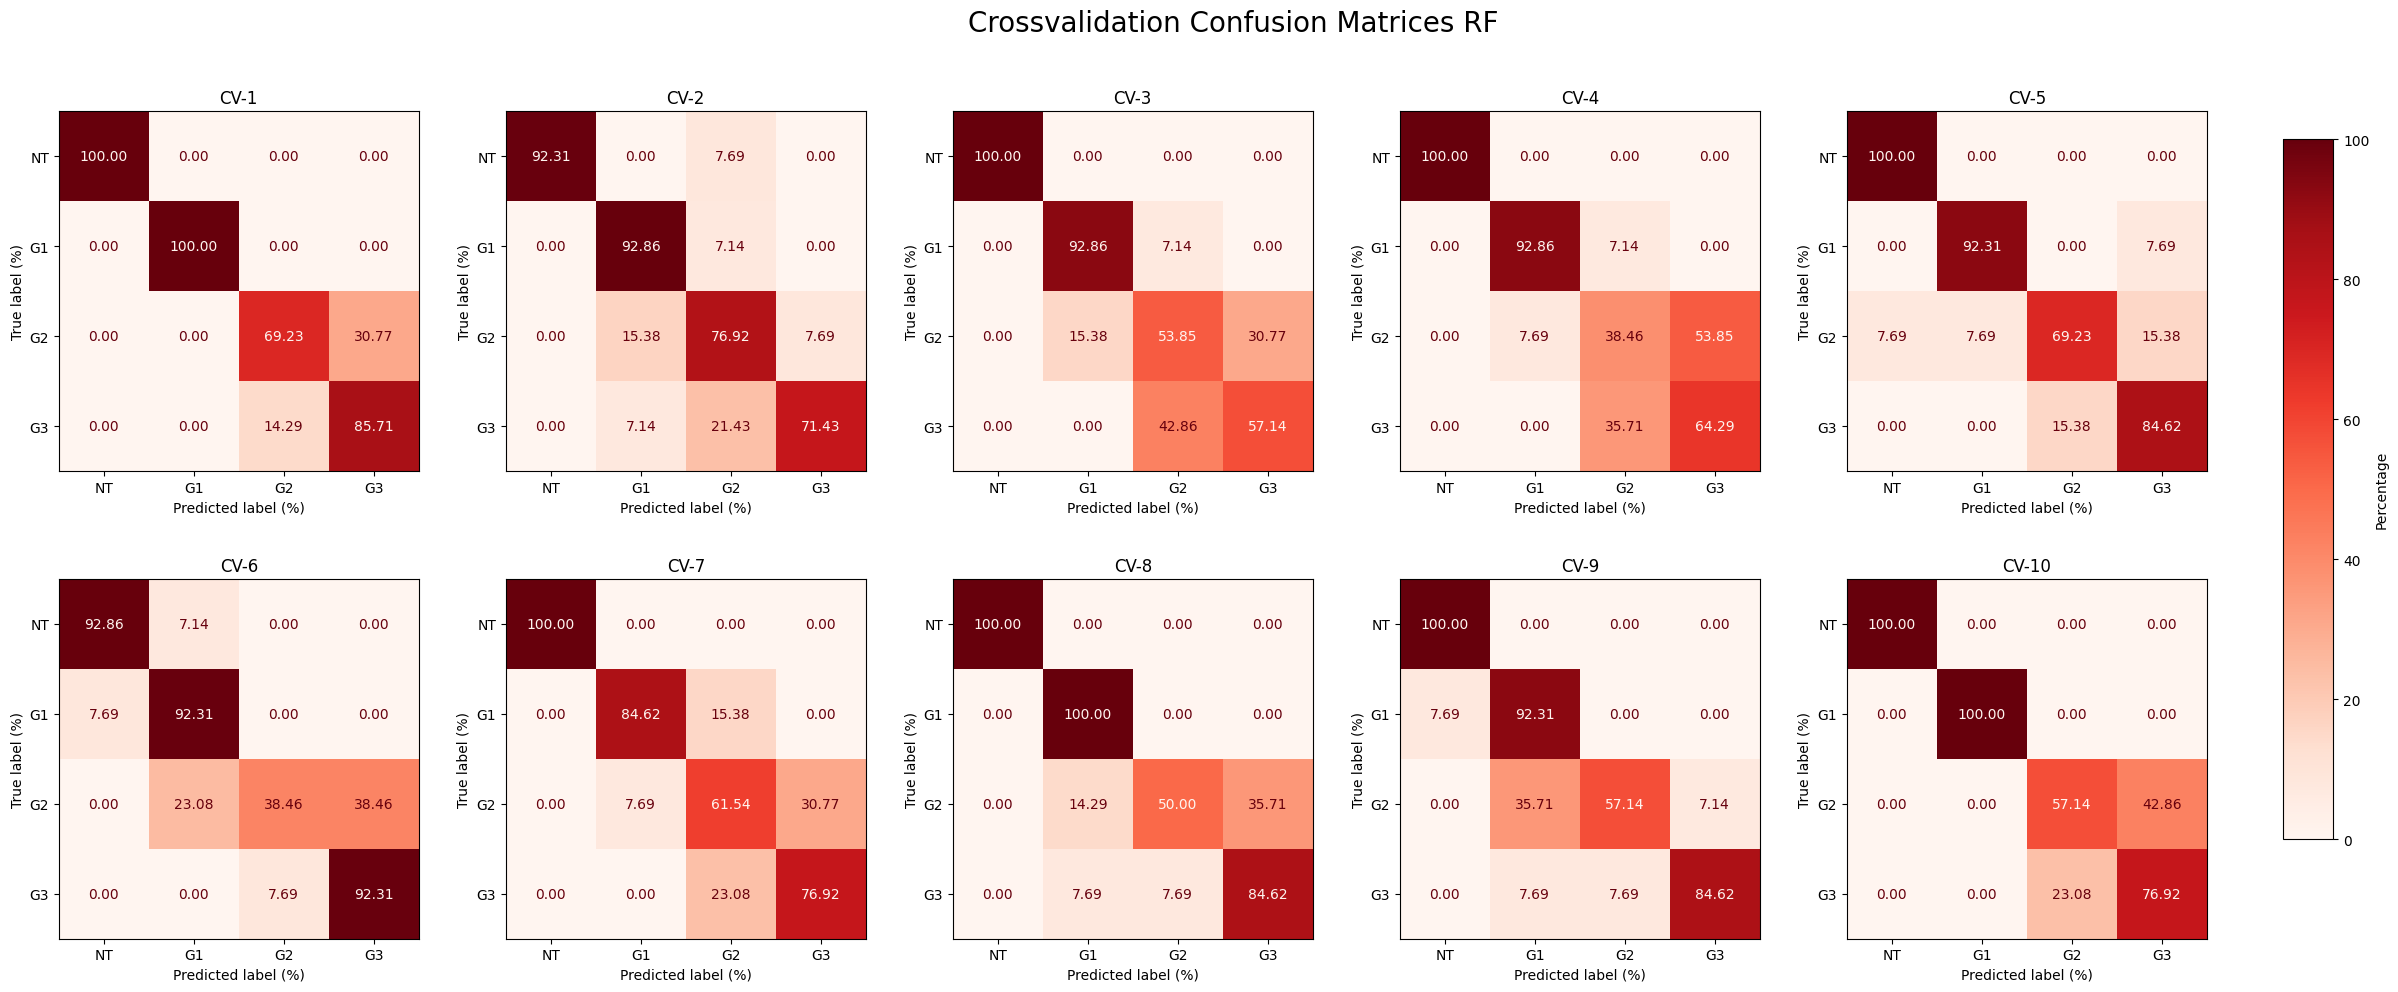

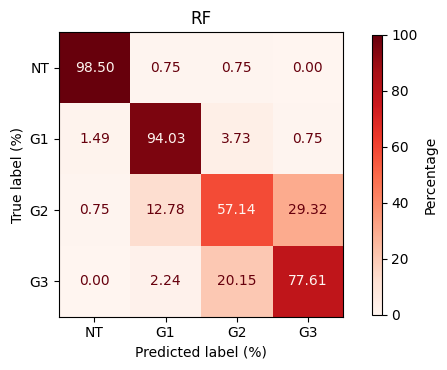

Cross-Validation Results RF:
Accuracy: ['88.89', '83.33', '75.93', '74.07', '86.79', '79.25', '81.13', '83.02', '83.02', '83.02']
Precision: ['89.14', '84.76', '75.86', '73.67', '86.64', '80.68', '81.51', '84.43', '85.09', '83.60']
Recall: ['88.89', '83.33', '75.93', '74.07', '86.79', '79.25', '81.13', '83.02', '83.02', '83.02']
F1: ['88.80', '83.52', '75.76', '73.73', '86.53', '77.36', '81.26', '81.94', '82.57', '82.88']
AUC: ['98.54', '95.03', '93.73', '93.95', '95.02', '95.58', '95.94', '96.78', '96.86', '96.36']

Average Metrics CV RF:
Accuracy: 81.84 +- 4.28
Precision: 82.54 +- 4.52
Recall: 81.84 +- 4.28
F1: 81.43 +- 4.43
AUC: 95.78 +- 1.37

Sensitivity (Recall) CV RF:
NT: 98.52 ± 2.97
G1: 94.01 ± 4.57
G2: 57.20 ± 12.09
G3: 77.86 ± 10.31

Specificity CV RF:
NT: 99.24 ± 1.17
G1: 94.75 ± 4.53
G2: 91.84 ± 5.22
G3: 90.00 ± 4.61

True positive CV RF:
NT: 98.52 ± 2.97
G1: 94.01 ± 4.57
G2: 57.20 ± 12.09
G3: 77.86 ± 10.31


In [ ]:
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
crossvalidation(rf, 'RF',X_train_valid_scaled, y_train_valid)

Index(['KCNQ1', 'S100A2', 'COLEC11', 'RAB22A', 'CDKL2', 'PIGB', 'E2F6', 'PLD1',
       'PAPLN', 'SERPINE2',
       ...
       'RNF215', 'CBY3', 'TRIM61', 'VASH2', 'JDP2', 'C6orf48', 'HRAS', 'TCL6',
       'B4GALT5', 'HIST2H2BF'],
      dtype='object', length=350)
Evaluation metrics Linear SVM
Accuracy: 87.31 %
Precision: 87.14 %
Recall (Macro-Averaged Sensitivity): 87.37 %
F1-score: 87.02 %
AUC: 95.59 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 67.65 %
Class G3: 81.82 %
Specificity for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 89.62 %
Class G3: 93.88 %
Confusion Matrix Linear SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  2.94117647   2.94117647  67.64705882  26.47058824]
 [  0.           3.03030303  15.15151515  81.81818182]]


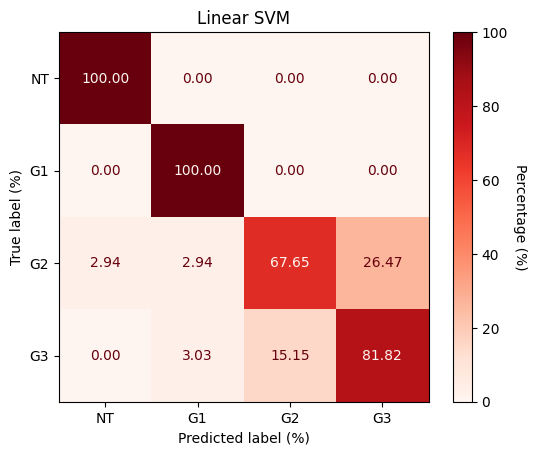

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_lsvm, X_df, X_train_valid_scaled, X_test_scaled, top=350)
model = SVC(kernel='linear', probability = True, random_state=42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Linear SVM', class_names)





#Linear SVM Evaluation Test Final 247

Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD94', 'LRRN1', 'HIST2H2BA', 'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1',
       'DEGS1', 'ARAP1', 'SPRY4'],
      dtype='object', length=247)
Evaluation metrics Linear SVM
Accuracy: 91.04 %
Precision: 91.54 %
Recall (Macro-Averaged Sensitivity): 91.11 %
F1-score: 90.78 %
AUC: 96.12 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 73.53 %
Class G3: 90.91 %
Specificity for each class:
Class NT: 99.00 %
Class G1: 94.06 %
Class G2: 99.00 %
Class G3: 96.04 %
Confusion Matrix Linear SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  2.94117647  11.76470588  73.52941176  11.76470588]
 [  0.           6.06060606   3.03030303  90.90909091]]


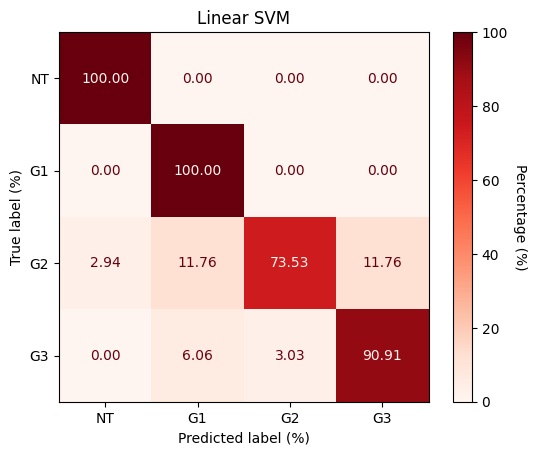

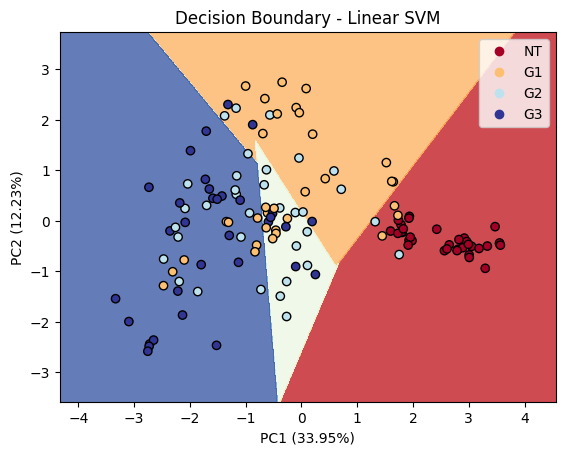

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled, X_test_scaled, top=247)
model = SVC(kernel='linear', probability = True, random_state=42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Linear SVM', class_names)


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled, X_test_scaled, top=247)
model = SVC(kernel='linear', probability = True, random_state=42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Linear SVM', class_names)


Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD94', 'LRRN1', 'HIST2H2BA', 'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1',
       'DEGS1', 'ARAP1', 'SPRY4'],
      dtype='object', length=247)


NameError: name 'class_names' is not defined

Index(['KCNQ1', 'CDKL2', 'RAB22A', 'E2F6', 'PIGB', 'S100A2', 'NEDD1',
       'C1orf77', 'PLD1', 'BMP4',
       ...
       'OR9Q1', 'POPDC2', 'ALKBH3', 'SNORD114-4', 'LOH12CR1', 'DAXX',
       'KIAA1143', 'ZNF167', 'HMGB1', 'DMRTA2'],
      dtype='object', length=165)
Evaluation metrics Polynomial SVM
Accuracy: 88.06 %
Precision: 87.73 %
Recall (Macro-Averaged Sensitivity): 88.10 %
F1-score: 87.75 %
AUC: 96.09 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 70.59 %
Class G3: 81.82 %
Specificity for each class:
Class NT: 98.00 %
Class G1: 98.02 %
Class G2: 95.00 %
Class G3: 93.07 %
Confusion Matrix Polynomial SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  5.88235294   2.94117647  70.58823529  20.58823529]
 [  0.           3.03030303  15.15151515  81.81818182]]


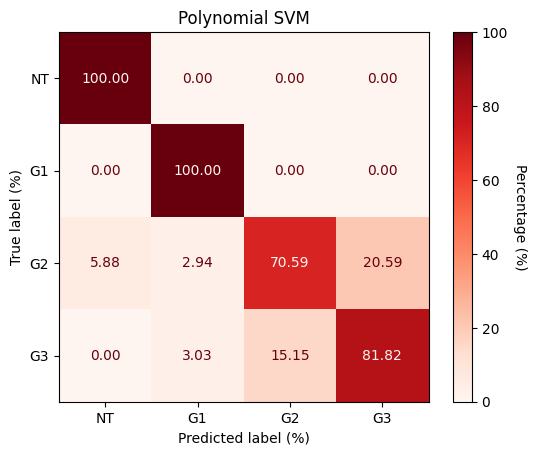

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvm, X_df, X_train_valid_scaled, X_test_scaled, top=165)
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Polynomial SVM', class_names)





Index(['KCNQ1', 'CDKL2', 'RAB22A', 'E2F6', 'PIGB', 'S100A2', 'NEDD1',
       'C1orf77', 'PLD1', 'BMP4',
       ...
       'OR9Q1', 'POPDC2', 'ALKBH3', 'SNORD114-4', 'LOH12CR1', 'DAXX',
       'KIAA1143', 'ZNF167', 'HMGB1', 'DMRTA2'],
      dtype='object', length=165)
Evaluation metrics Polynomial SVM
Accuracy: 88.06 %
Precision: 87.73 %
Recall (Macro-Averaged Sensitivity): 88.10 %
F1-score: 87.75 %
AUC: 96.09 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 70.59 %
Class G3: 81.82 %
Specificity for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 90.48 %
Class G3: 94.00 %
Confusion Matrix Polynomial SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  5.88235294   2.94117647  70.58823529  20.58823529]
 [  0.           3.03030303  15.15151515  81.81818182]]


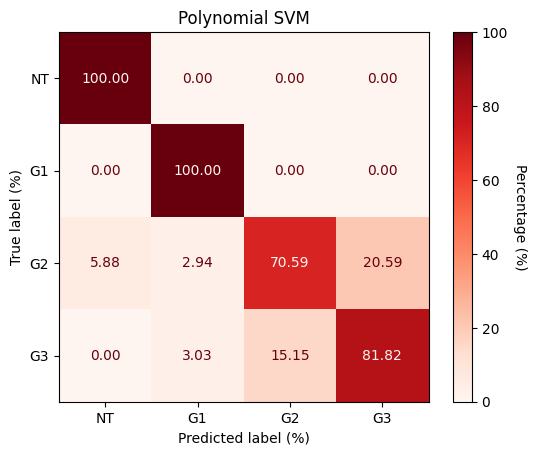

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvm, X_df, X_train_valid_scaled, X_test_scaled, top=165)
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Polynomial SVM', class_names)





Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181', 'CCDC144NL',
       'HDAC2', 'E2F2', 'PTBP2'],
      dtype='object', length=370)
Evaluation metrics Kernel SVM
Accuracy: 90.30 %
Precision: 90.42 %
Recall (Macro-Averaged Sensitivity): 90.33 %
F1-score: 90.06 %
AUC: 97.98 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 76.47 %
Class G3: 84.85 %
Specificity for each class:
Class NT: 99.00 %
Class G1: 95.05 %
Class G2: 98.00 %
Class G3: 95.05 %
Confusion Matrix Kernel SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  2.94117647   5.88235294  76.47058824  14.70588235]
 [  0.           9.09090909   6.06060606  84.84848485]]


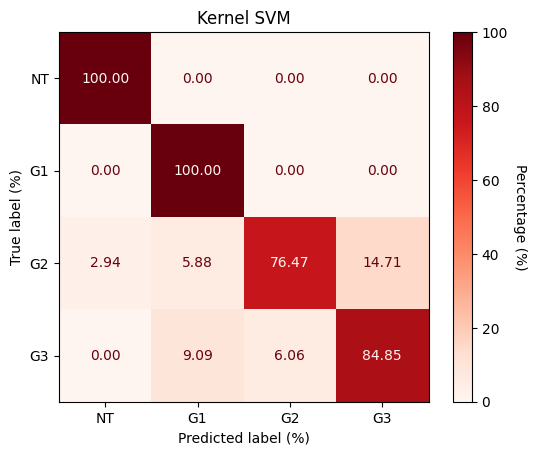

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled, X_test_scaled, top=370)
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Kernel SVM', class_names)





Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181', 'CCDC144NL',
       'HDAC2', 'E2F2', 'PTBP2'],
      dtype='object', length=370)
Evaluation metrics Kernel SVM
Accuracy: 90.30 %
Precision: 90.42 %
Recall (Macro-Averaged Sensitivity): 90.33 %
F1-score: 90.06 %
AUC: 97.98 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 76.47 %
Class G3: 84.85 %
Specificity for each class:
Class NT: 99.00 %
Class G1: 95.05 %
Class G2: 98.00 %
Class G3: 95.05 %
Confusion Matrix Kernel SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  2.94117647   5.88235294  76.47058824  14.70588235]
 [  0.           9.09090909   6.06060606  84.84848485]]


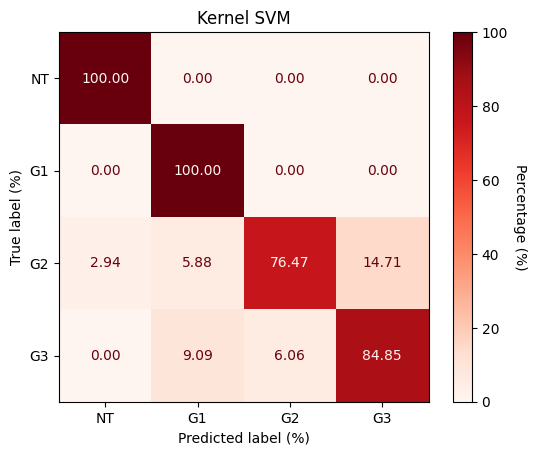

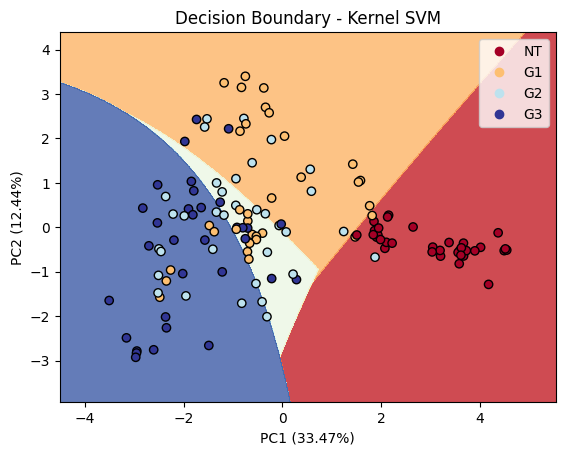

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled, X_test_scaled, top=370)
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Kernel SVM', class_names)





Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181', 'CCDC144NL',
       'HDAC2', 'E2F2', 'PTBP2'],
      dtype='object', length=370)
Evaluation metrics Polynomial SVM
Accuracy: 90.30 %
Precision: 90.42 %
Recall (Macro-Averaged Sensitivity): 90.33 %
F1-score: 90.06 %
AUC: 97.98 %
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 100.00 %
Class G2: 76.47 %
Class G3: 84.85 %
Specificity for each class:
Class NT: 99.00 %
Class G1: 95.05 %
Class G2: 98.00 %
Class G3: 95.05 %
Confusion Matrix Polynomial SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  2.94117647   5.88235294  76.47058824  14.70588235]
 [  0.           9.09090909   6.06060606  84.84848485]]


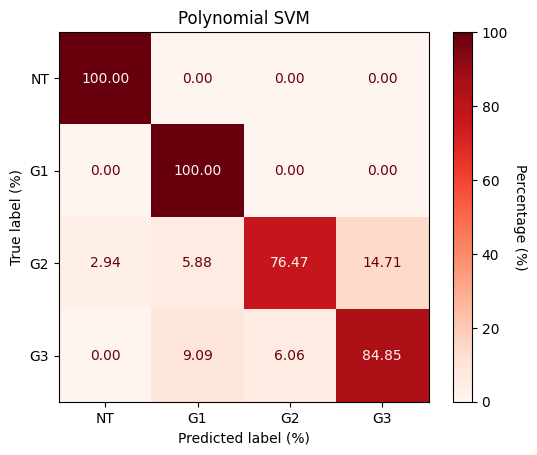

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled, X_test_scaled, top=370)
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid, y_test, model, 'Polynomial SVM', class_names)





Evaluation metrics GNB
Accuracy: 72.39 %
Precision: 72.48 %
Recall: 72.39 %
F1-score: 70.73 %
Confusion Matrix GNB:
[[100.           0.           0.           0.        ]
 [  0.          87.87878788   3.03030303   9.09090909]
 [  2.94117647  29.41176471  35.29411765  32.35294118]
 [  0.          18.18181818  15.15151515  66.66666667]]


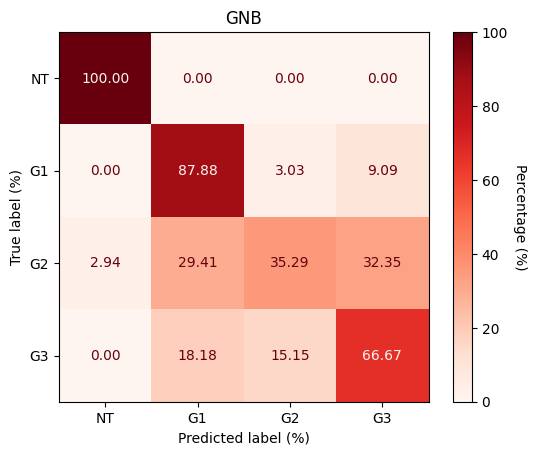

In [ ]:
model = GaussianNB()
evauation_test(X_train_valid_scaled, X_test_scaled, y_train_valid, y_test, model, 'GNB')

#1. GNB

<ipython-input-42-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


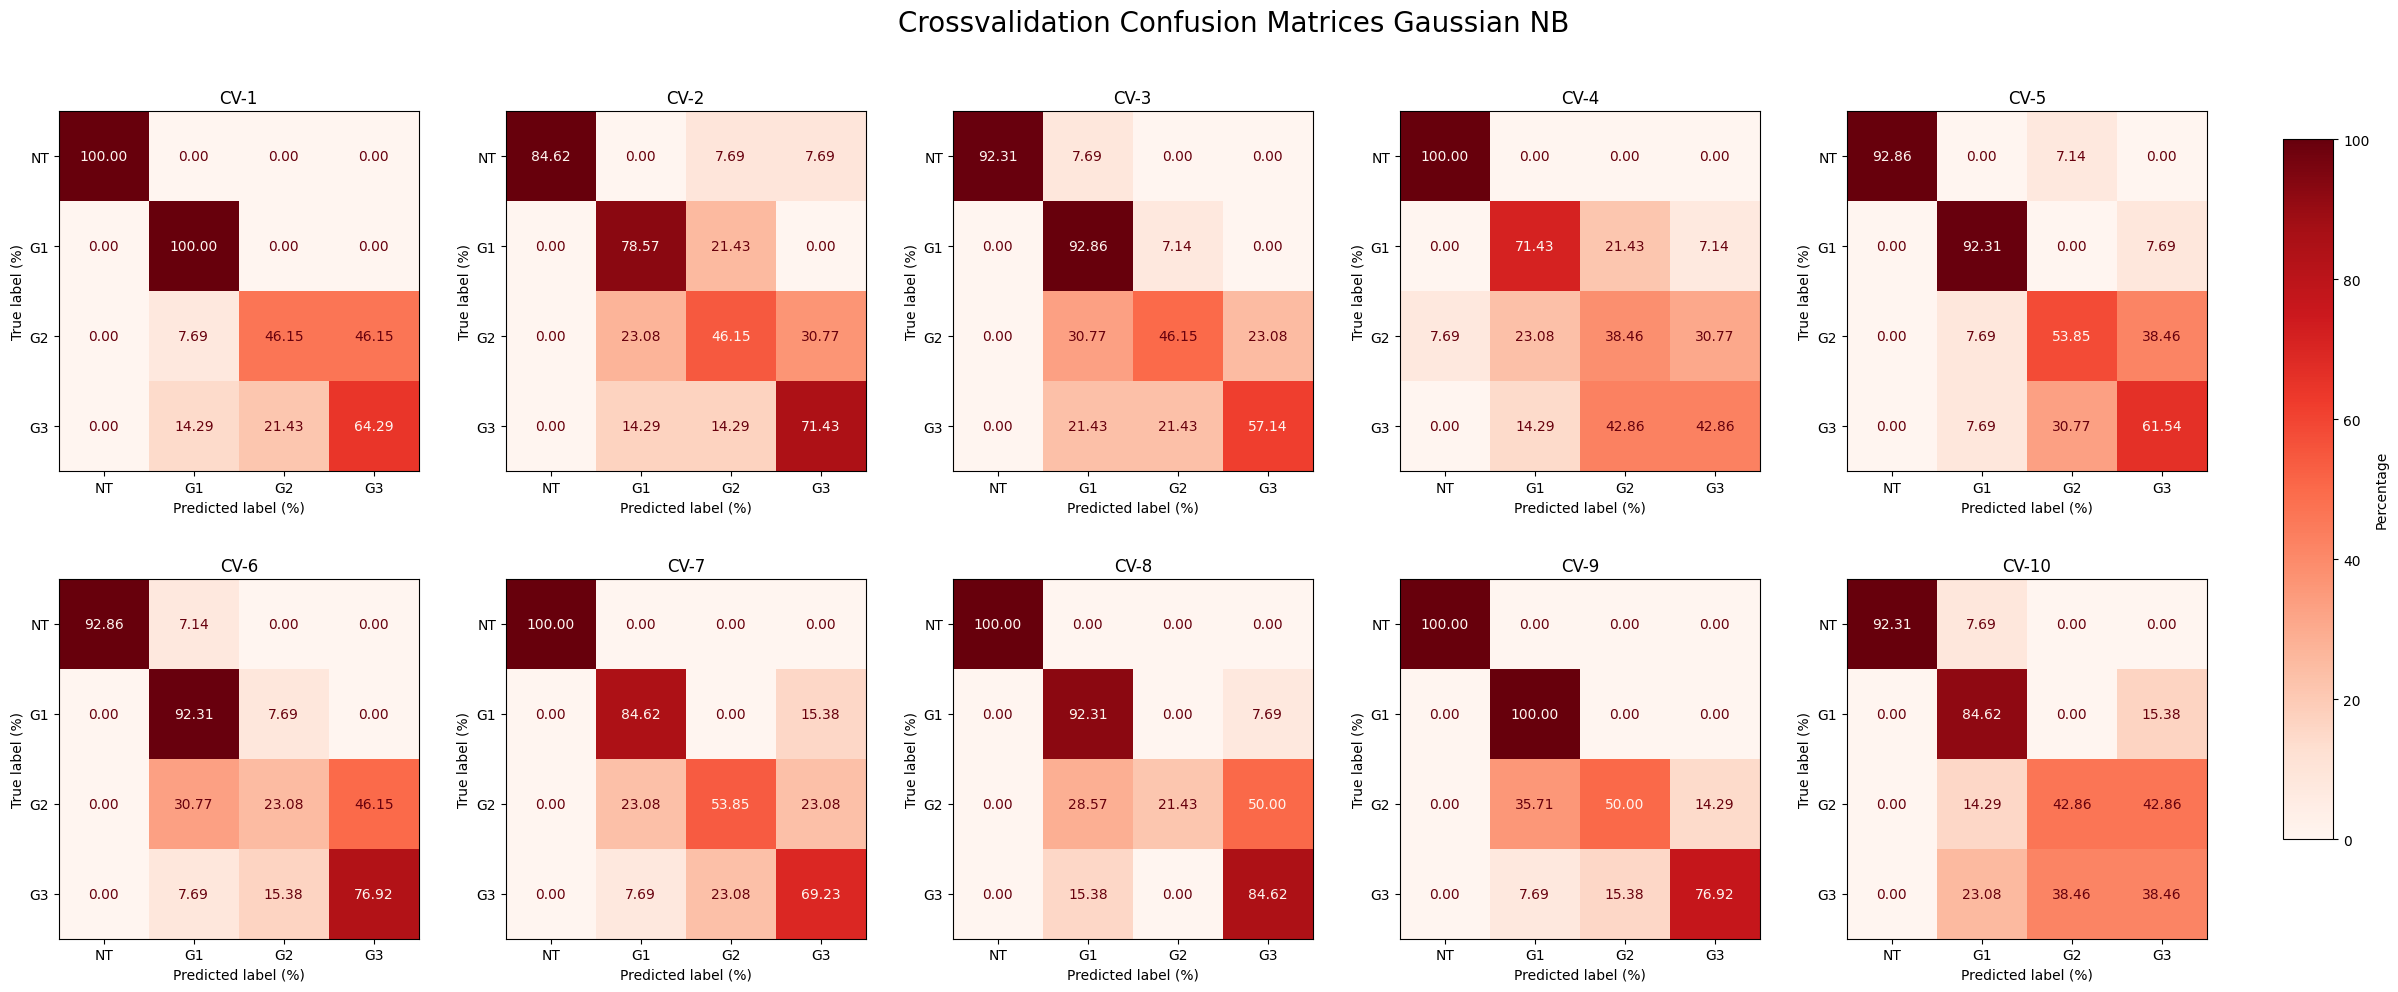

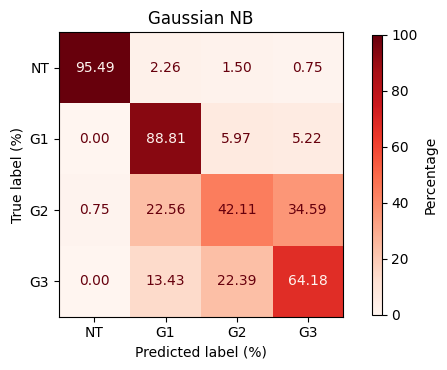

Cross-Validation Results Gaussian NB:
Accuracy: ['77.78', '70.37', '72.22', '62.96', '75.47', '71.70', '77.36', '73.58', '81.13', '64.15']
Precision: ['77.03', '71.22', '73.42', '62.38', '75.76', '70.36', '77.34', '81.50', '82.30', '64.24']
Recall: ['77.78', '70.37', '72.22', '62.96', '75.47', '71.70', '77.36', '73.58', '81.13', '64.15']
F1: ['76.71', '70.52', '71.52', '62.42', '75.51', '69.09', '76.97', '69.70', '80.16', '63.65']
AUC: ['93.21', '88.31', '87.95', '82.87', '90.89', '89.57', '90.17', '93.35', '91.48', '86.51']

Average Metrics CV Gaussian NB:
Accuracy: 72.67 +- 5.49
Precision: 73.55 +- 6.31
Recall: 72.67 +- 5.49
F1: 71.63 +- 5.50
AUC: 89.43 +- 3.03

Sensitivity (Recall) CV Gaussian NB:
NT: 95.49 ± 5.04
G1: 88.90 ± 8.63
G2: 42.20 ± 10.91
G3: 64.34 ± 14.12

Specificity CV Gaussian NB:
NT: 99.76 ± 0.73
G1: 87.25 ± 4.10
G2: 90.09 ± 5.67
G3: 86.50 ± 4.50

True positive CV Gaussian NB:
NT: 95.49 ± 5.04
G1: 88.90 ± 8.63
G2: 42.20 ± 10.91
G3: 64.34 ± 14.12


In [ ]:
gnb = GaussianNB()
crossvalidation(gnb, 'Gaussian NB',X_train_valid_scaled, y_train_valid)

Evaluation metrics GNB
Accuracy: 72.39 %
Precision: 72.48 %
Recall: 72.39 %
F1-score: 70.73 %
Confusion Matrix GNB:
[[100.           0.           0.           0.        ]
 [  0.          87.87878788   3.03030303   9.09090909]
 [  2.94117647  29.41176471  35.29411765  32.35294118]
 [  0.          18.18181818  15.15151515  66.66666667]]


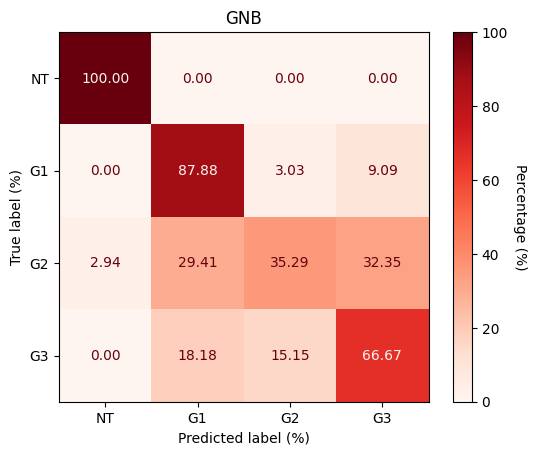

In [ ]:
model = GaussianNB()
evauation_test(X_train_valid_scaled, X_test_scaled, y_train_valid, y_test, model, 'GNB')

In [ ]:
 gnb = GaussianNB()
features_gnb = crossvalidation_with_shap(gnb, 'GaussianNB',X_train_valid_scaled, y_train_valid, X_df)

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [ ]:
features_gnb.sort_values(by='average', ascending=False).reset_index(drop=True)

,feature,average,stdev
0,GTF3C1,0.013779,0.002841
1,C7orf59,0.007323,0.003325
2,VASH1,0.006588,0.006141
3,ZNF181,0.005631,0.004731
4,RND1,0.005343,0.008112
...,...,...,...
923,SLC22A4,0.000388,0.000362
924,DNAJC16,0.000374,0.000507
925,WDR18,0.000372,0.000433
926,MOBKL2C,0.000337,0.000389


from matplotlib import pyplot as plt
_df_0['average'].plot(kind='hist', bins=20, title='average')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['stdev'].plot(kind='hist', bins=20, title='stdev')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='average', y='stdev', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['average'].plot(kind='line', figsize=(8, 4), title='average')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['stdev'].plot(kind='line', figsize=(8, 4), title='stdev')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
gnb = GaussianNB()
crossvalidation(gnb, X_train_valid_scaled_02, y_train_valid)

#2. SVM linear

<ipython-input-42-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


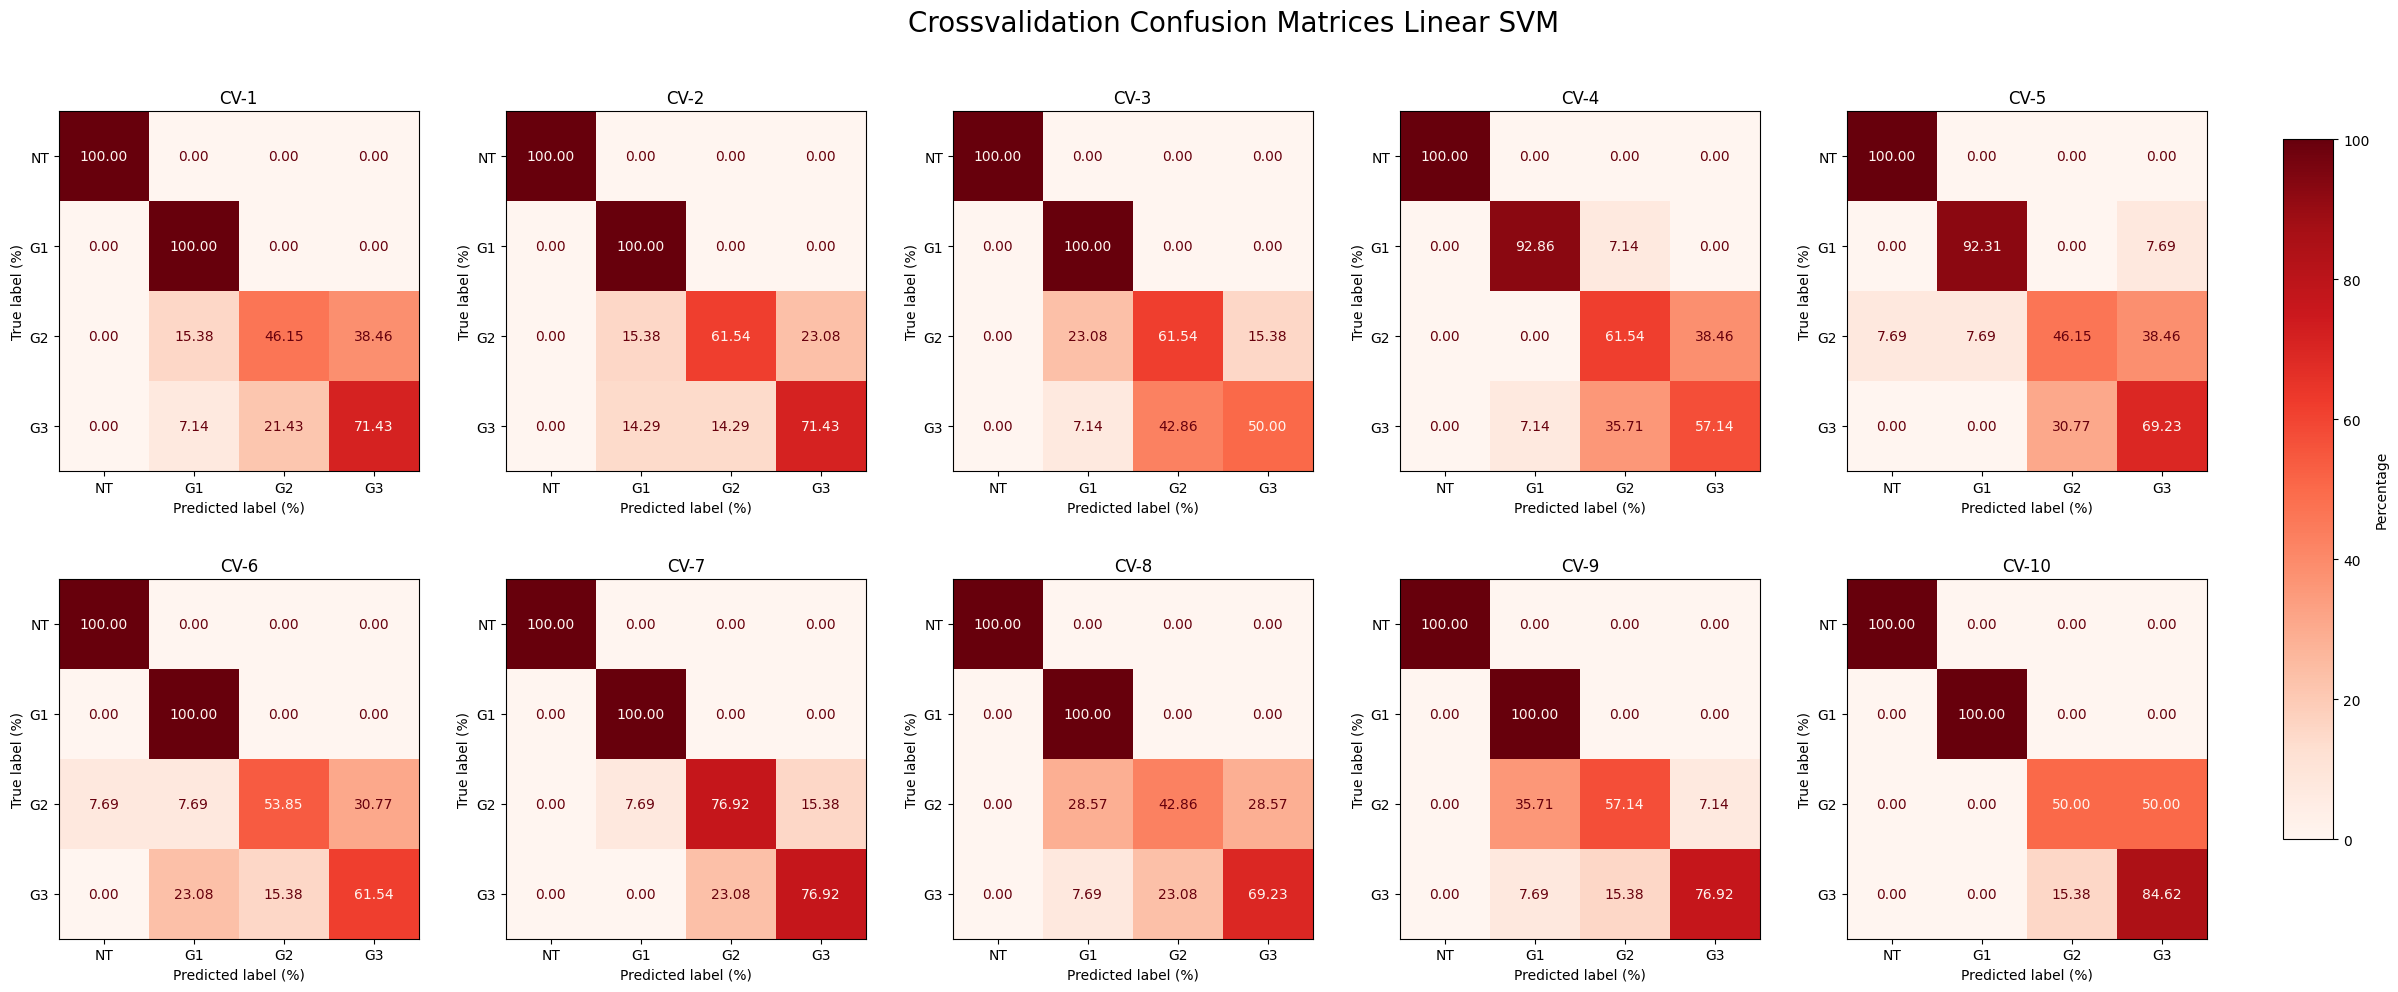

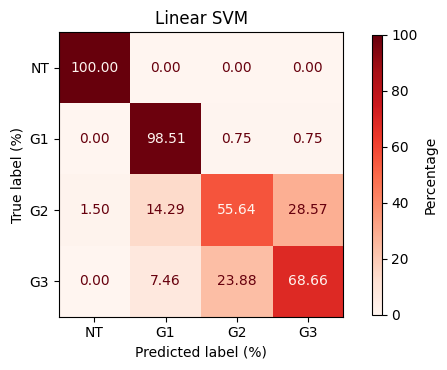

Cross-Validation Results Linear SVM:
Accuracy: ['79.63', '83.33', '77.78', '77.78', '77.36', '79.25', '88.68', '77.36', '83.02', '83.02']
Precision: ['78.76', '83.44', '78.16', '77.86', '76.73', '78.84', '88.50', '76.83', '84.74', '84.59']
Recall: ['79.63', '83.33', '77.78', '77.78', '77.36', '79.25', '88.68', '77.36', '83.02', '83.02']
F1: ['78.50', '82.71', '76.81', '77.78', '76.71', '78.07', '88.53', '75.86', '82.51', '82.54']
AUC: ['95.92', '94.78', '95.71', '95.37', '92.84', '96.73', '97.07', '95.83', '95.06', '96.29']

Average Metrics CV Linear SVM:
Accuracy: 80.72 +- 3.52
Precision: 80.85 +- 3.90
Recall: 80.72 +- 3.52
F1: 80.00 +- 3.77
AUC: 95.56 +- 1.13

Sensitivity (Recall) CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 55.77 ± 9.68
G3: 68.85 ± 9.69

Specificity CV Linear SVM:
NT: 99.49 ± 1.03
G1: 92.75 ± 4.80
G2: 91.81 ± 3.57
G3: 90.25 ± 4.53

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 55.77 ± 9.68
G3: 68.85 ± 9.69


In [ ]:
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_train_valid_scaled, y_train_valid)

Evaluation metrics Linear SVM
Accuracy: 86.57 %
Precision: 86.21 %
Recall: 86.57 %
F1-score: 86.14 %
Confusion Matrix Linear SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  5.88235294   2.94117647  67.64705882  23.52941176]
 [  0.           6.06060606  15.15151515  78.78787879]]


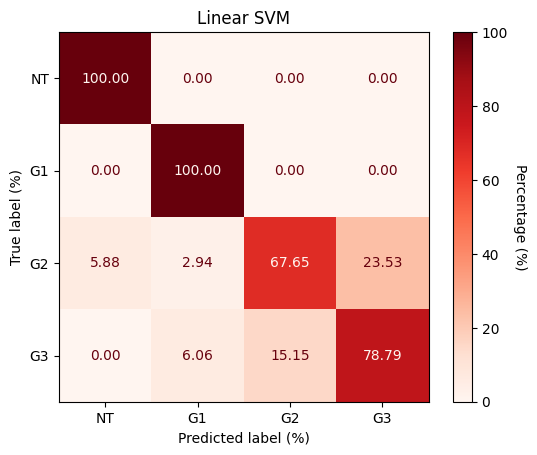

In [ ]:
#evaluation
model = SVC(kernel='linear', probability = True, random_state=42)
evauation_test(X_train_valid_scaled, X_test_scaled, y_train_valid, y_test, model, 'Linear SVM')

<ipython-input-29-5c0eb07ccb38>:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-29-5c0eb07ccb38>:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


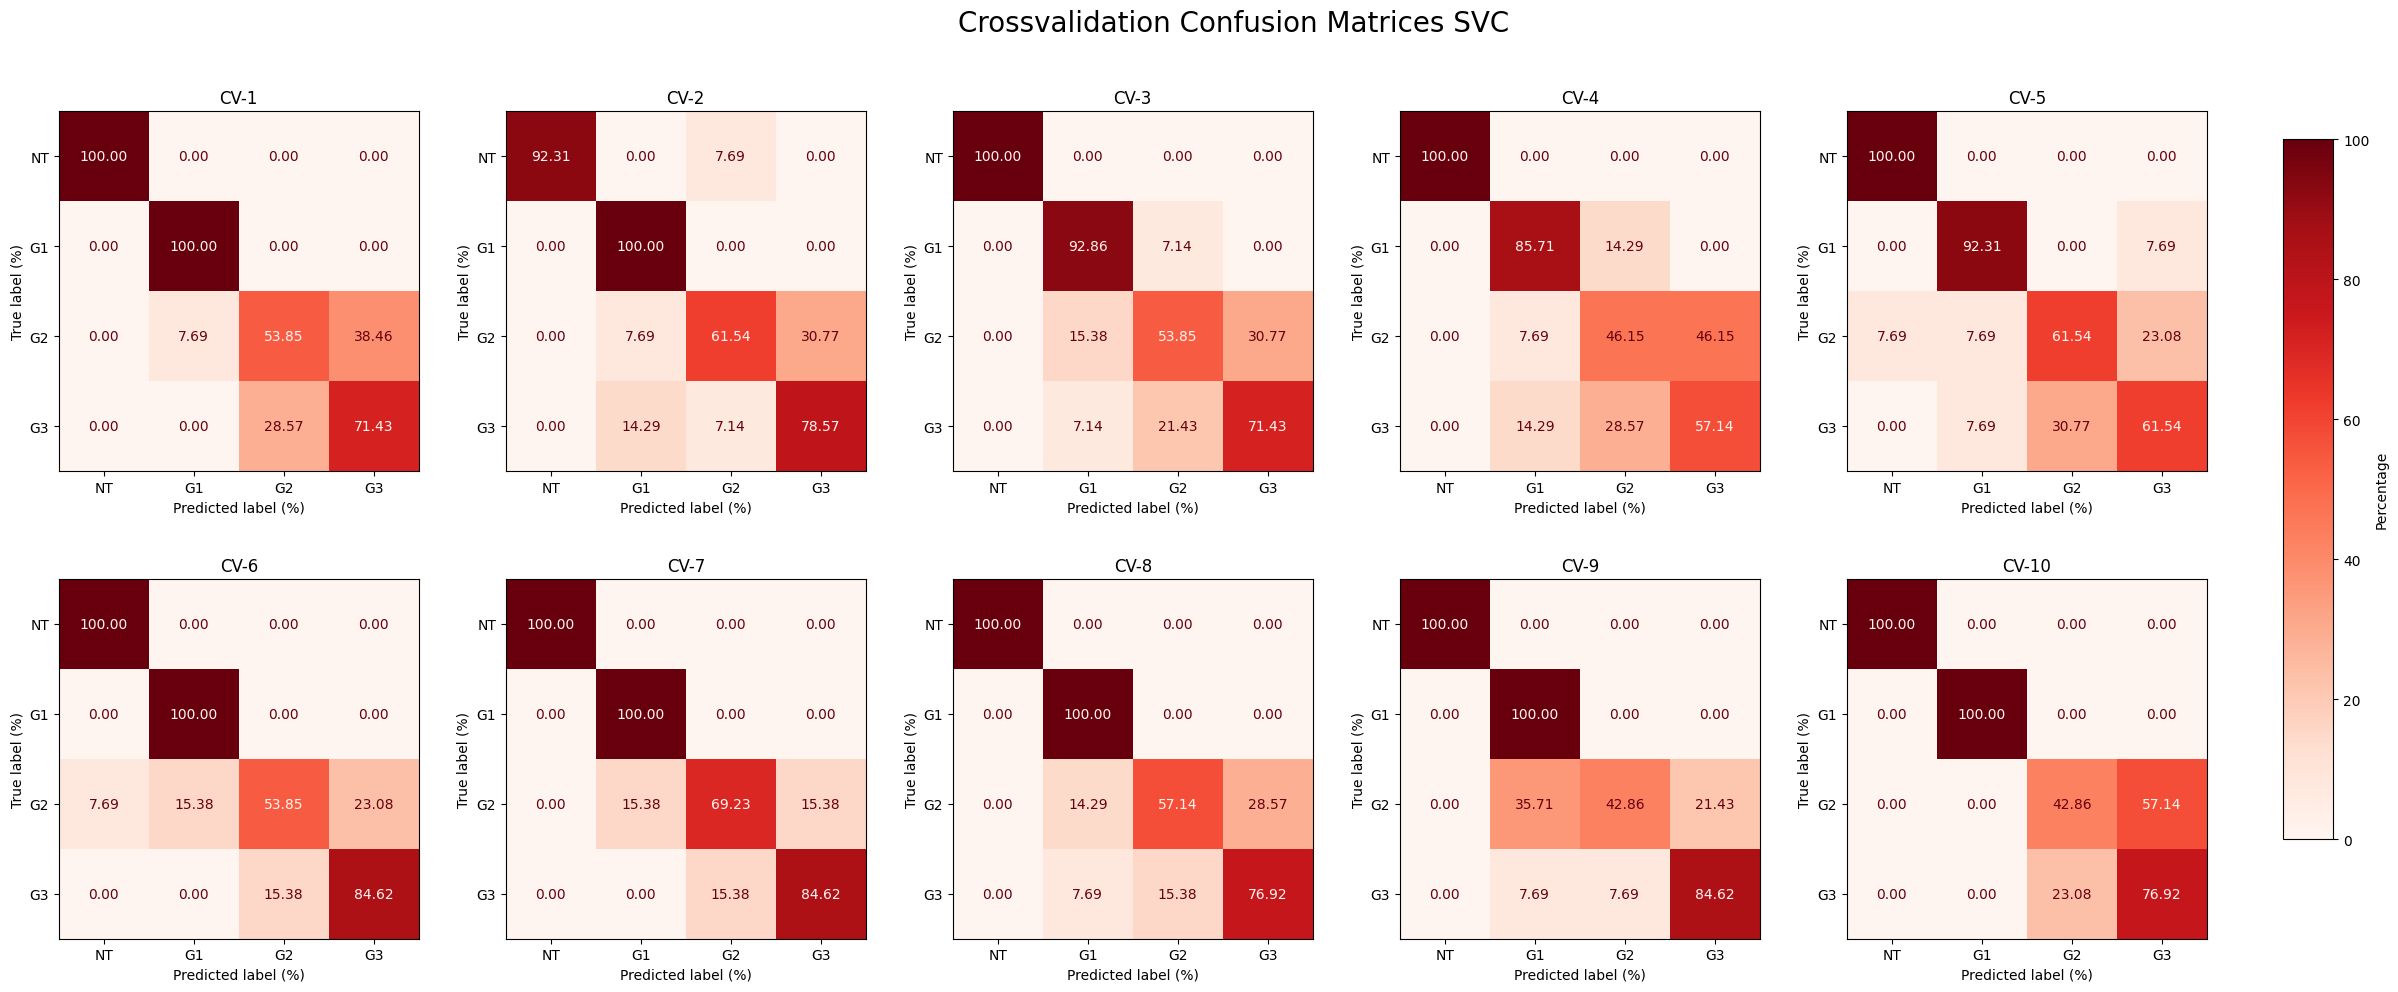

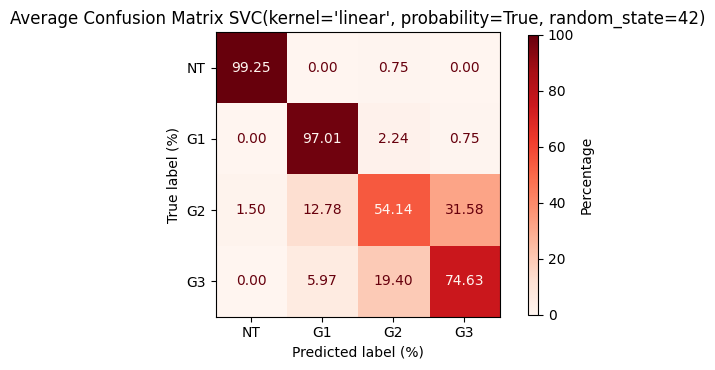

Cross-Validation Results SVC(kernel='linear', probability=True, random_state=42):
Accuracy: ['81.48', '83.33', '79.63', '72.22', '79.25', '84.91', '88.68', '83.02', '81.13', '79.25']
Precision: ['80.88', '83.70', '78.98', '71.67', '78.38', '84.26', '88.50', '83.11', '83.22', '80.29']
Recall: ['81.48', '83.33', '79.63', '72.22', '79.25', '84.91', '88.68', '83.02', '81.13', '79.25']
F1: ['81.03', '82.94', '79.10', '71.90', '78.70', '83.88', '88.34', '82.30', '79.54', '78.66']
AUC: ['94.81', '94.09', '96.55', '95.51', '93.08', '96.68', '96.97', '94.65', '94.78', '94.51']

Average Metrics CV SVC(kernel='linear', probability=True, random_state=42):
Accuracy: 81.29 +- 4.10
Precision: 81.30 +- 4.26
Recall: 81.29 +- 4.10
F1: 80.64 +- 4.07
AUC: 95.16 +- 1.19

True positive CV SVC(kernel='linear', probability=True, random_state=42):
NT: 99.23 ± 2.31
G1: 97.09 ± 4.79
G2: 54.29 ± 8.15
G3: 74.78 ± 9.07


In [ ]:
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, X_train_valid_scaled_02, y_train_valid)

#3. SVM Kernel

<ipython-input-127-e66405b69885>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-127-e66405b69885>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


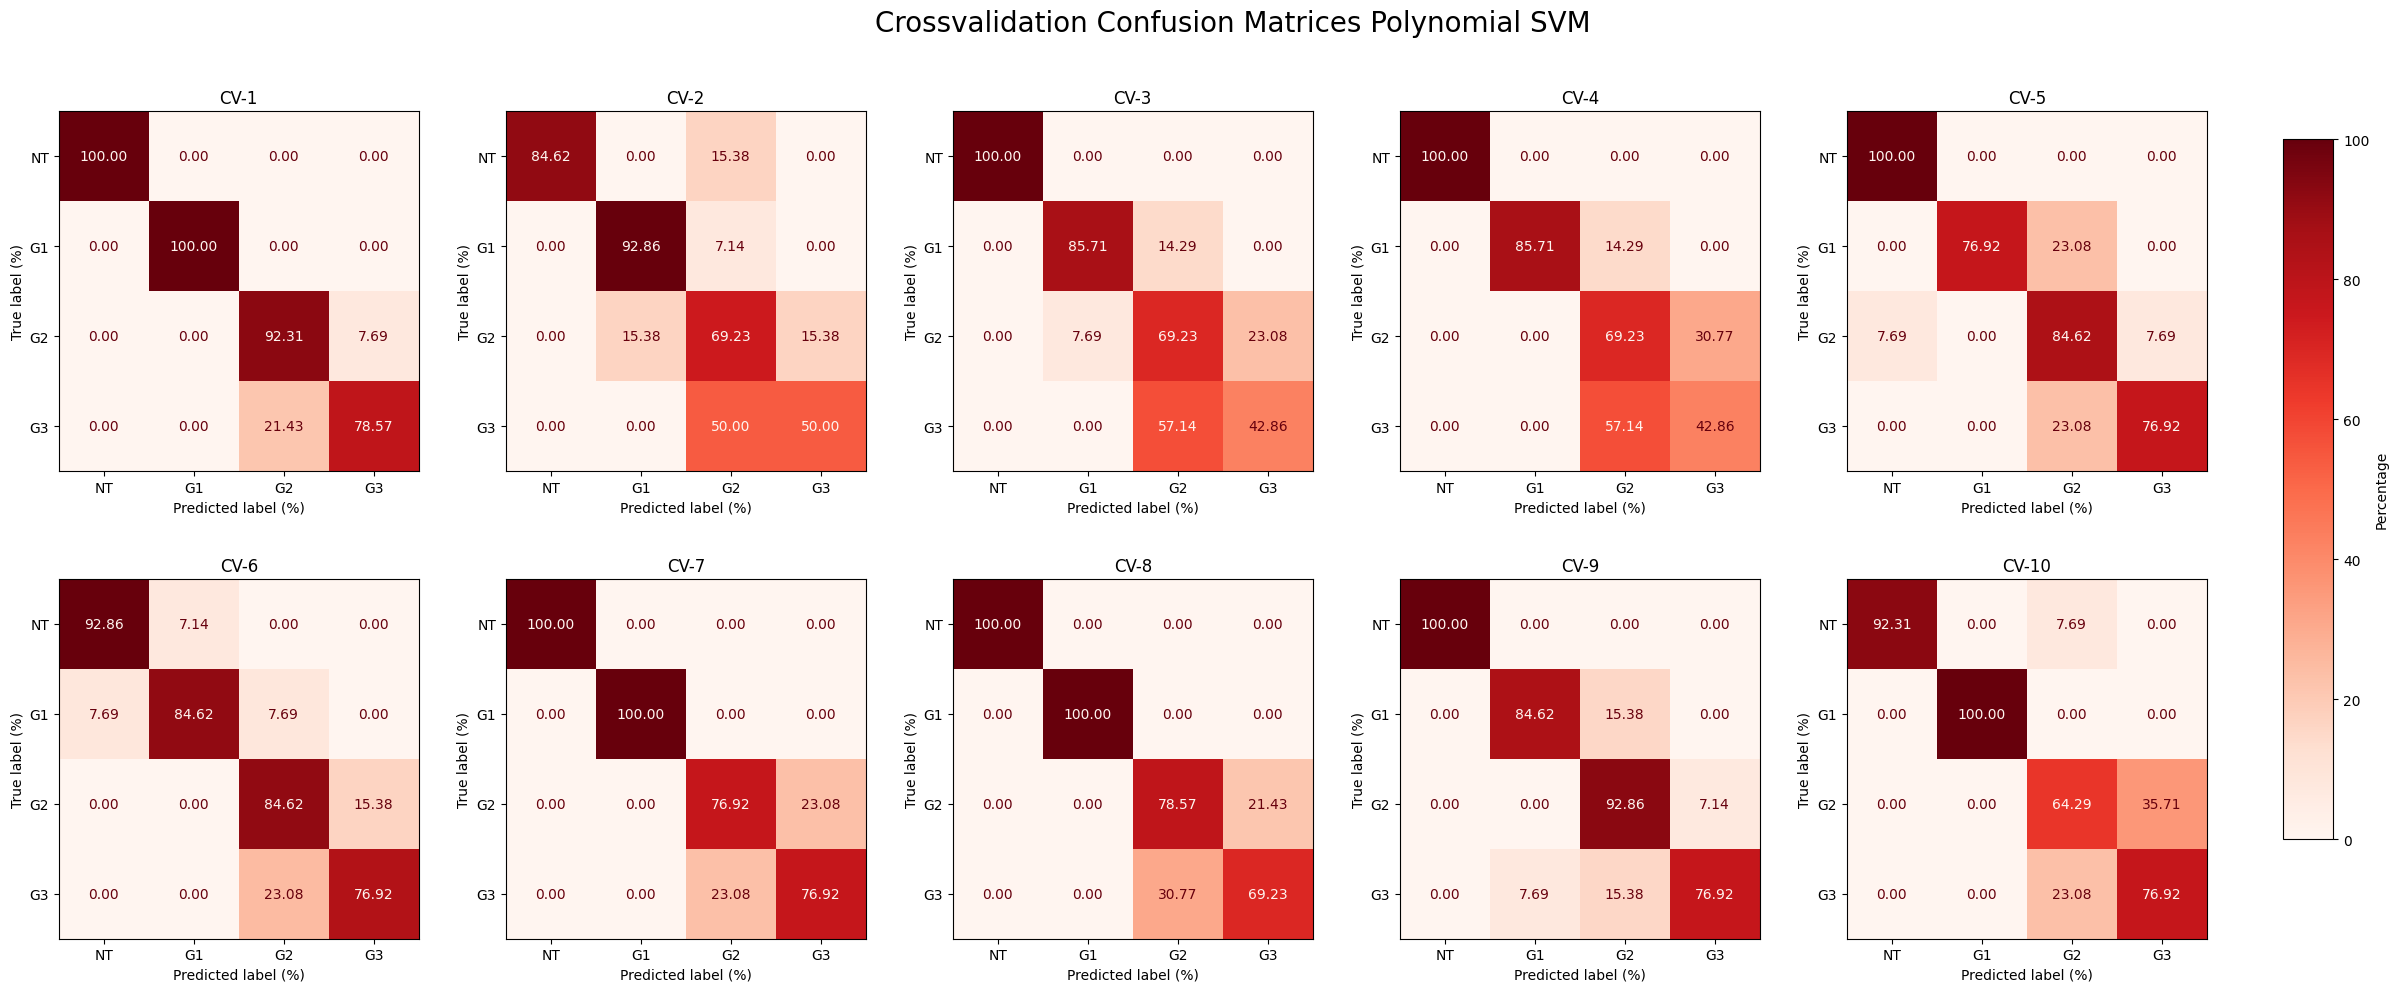

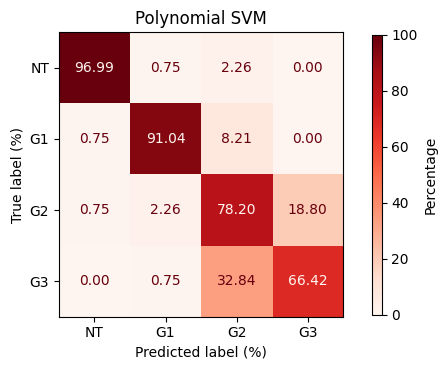

Cross-Validation Results Polynomial SVM:
Accuracy: ['92.59', '74.07', '74.07', '74.07', '84.91', '84.91', '88.68', '86.79', '88.68', '83.02']
Precision: ['93.02', '78.11', '76.69', '76.96', '87.35', '85.44', '88.68', '86.82', '89.51', '83.70']
Recall: ['92.59', '74.07', '74.07', '74.07', '84.91', '84.91', '88.68', '86.79', '88.68', '83.02']
F1: ['92.57', '74.63', '74.19', '74.51', '85.26', '85.01', '88.68', '86.76', '88.71', '83.21']
AUC: ['98.35', '93.16', '94.10', '93.99', '95.00', '97.74', '97.55', '96.96', '97.83', '96.21']

Average Metrics CV Polynomial SVM:
Accuracy: 83.18 +- 6.46
Precision: 84.63 +- 5.37
Recall: 83.18 +- 6.46
F1: 83.35 +- 6.31
AUC: 96.09 +- 1.79

Sensitivity (Recall) CV Polynomial SVM:
NT: 96.98 ± 5.06
G1: 91.04 ± 8.14
G2: 78.19 ± 9.66
G3: 66.81 ± 14.44

Specificity CV Polynomial SVM:
NT: 99.49 ± 1.03
G1: 98.75 ± 1.68
G2: 85.62 ± 6.84
G3: 93.75 ± 3.21

True positive CV Polynomial SVM:
NT: 96.98 ± 5.06
G1: 91.04 ± 8.14
G2: 78.19 ± 9.66
G3: 66.81 ± 14.44


In [ ]:
#svm_kernel = svm = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
model = SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
crossvalidation(model, 'Polynomial SVM', X_train_valid_scaled, y_train_valid)

Evaluation metrics Poly SVM
Accuracy: 85.82 %
Precision: 85.31 %
Recall: 85.82 %
F1-score: 85.32 %
Confusion Matrix Poly SVM:
[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  5.88235294   5.88235294  64.70588235  23.52941176]
 [  0.           3.03030303  18.18181818  78.78787879]]


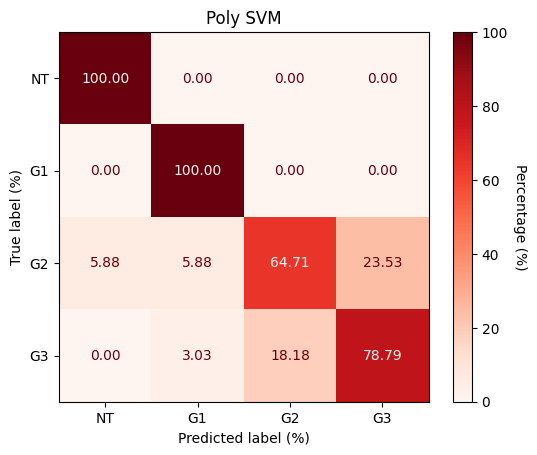

In [ ]:
#evaluation
model = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
evauation_test(X_train_valid_scaled, X_test_scaled, y_train_valid, y_test, model, 'Poly SVM')

<ipython-input-42-25feda21f987>:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-25feda21f987>:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


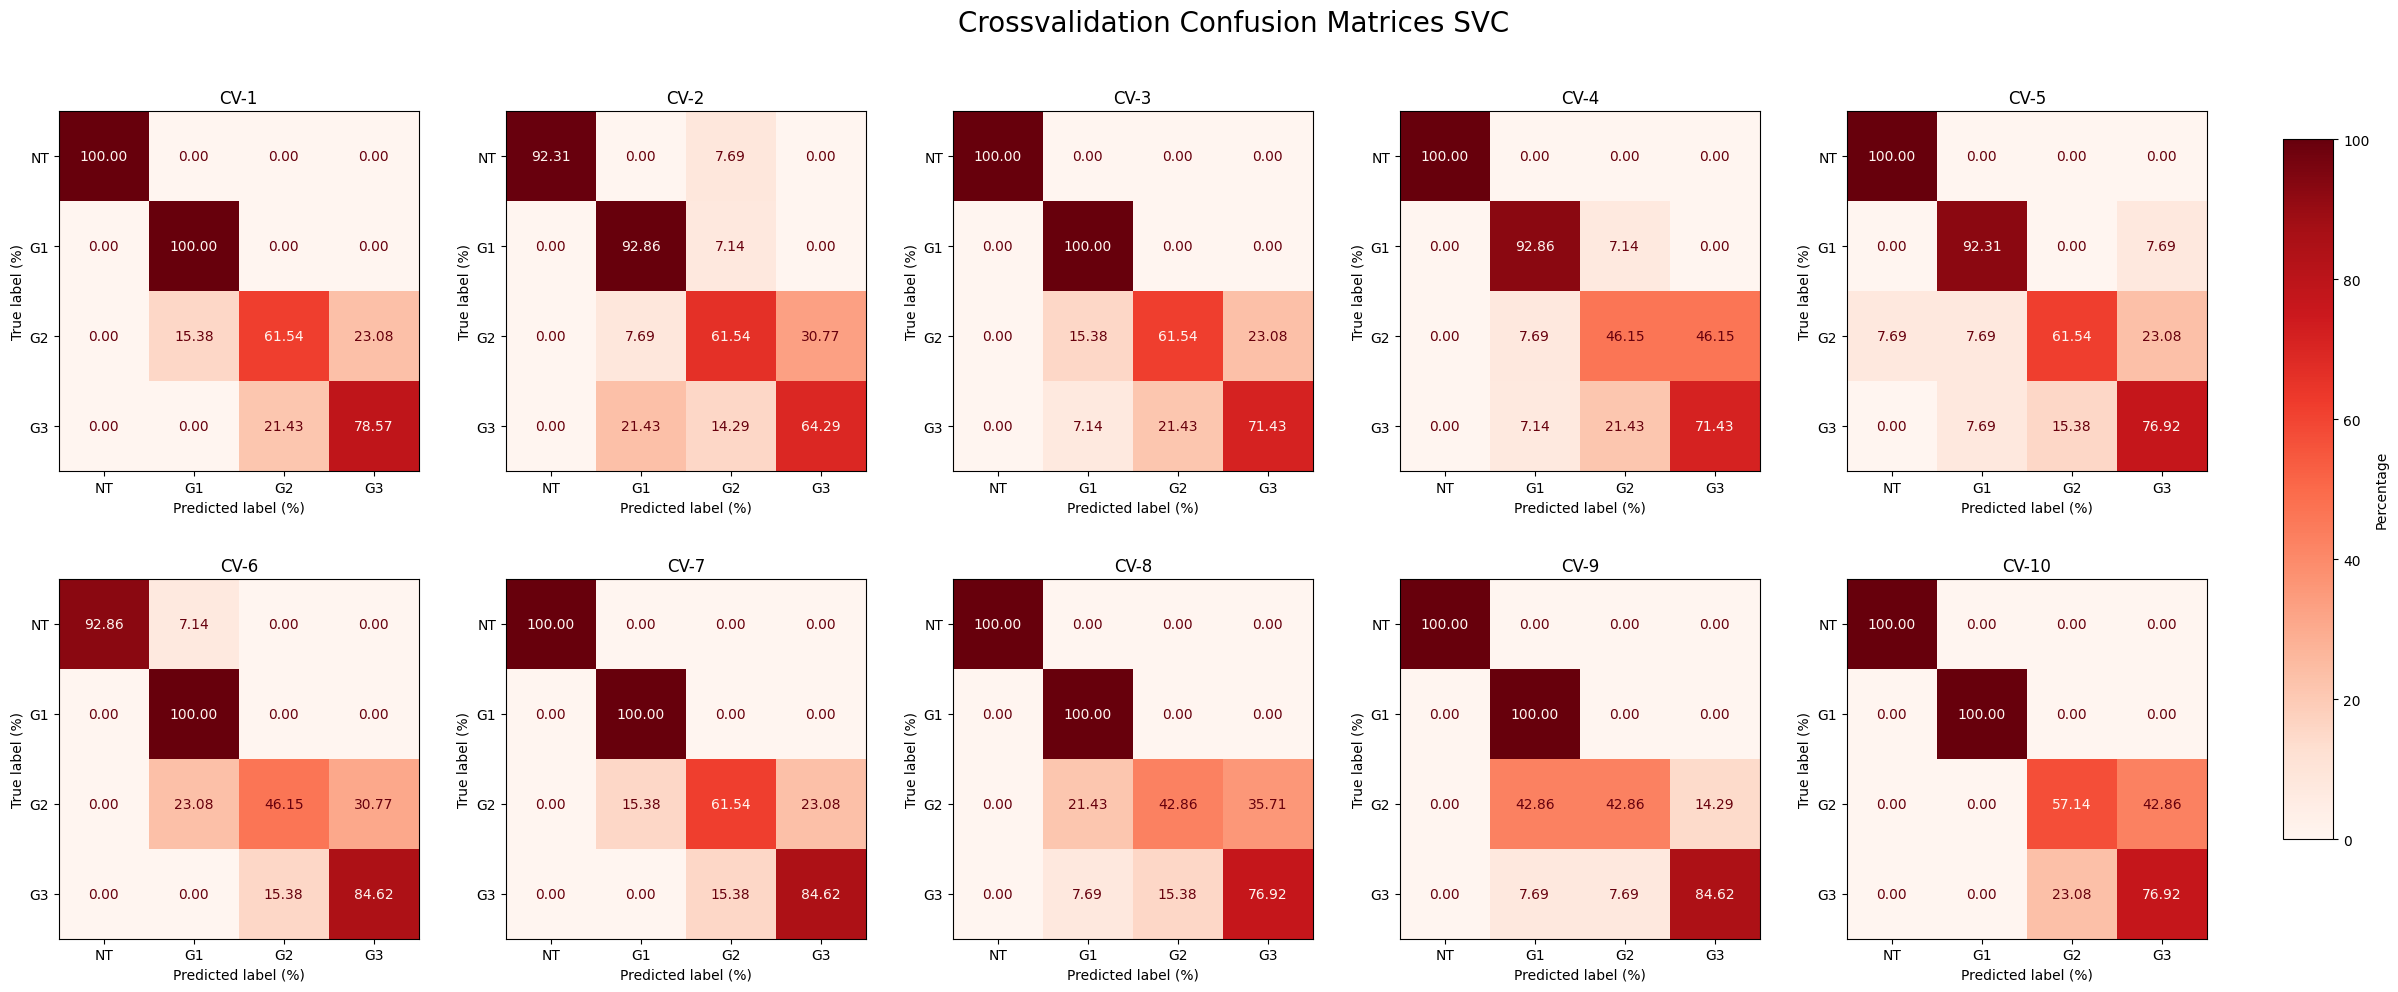

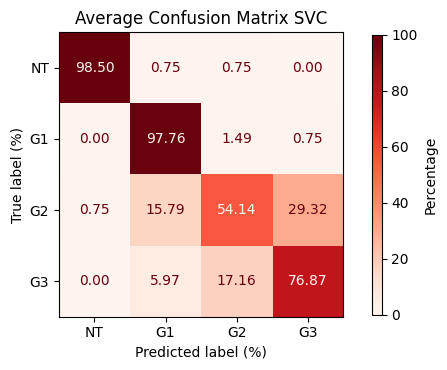

Cross-Validation Results SVC(kernel='poly', probability=True, random_state=42):
Accuracy: ['85.19', '77.78', '83.33', '77.78', '83.02', '81.13', '86.79', '79.25', '81.13', '83.02']
Precision: ['84.64', '77.90', '82.88', '77.19', '82.82', '81.56', '86.57', '79.45', '83.87', '83.60']
Recall: ['85.19', '77.78', '83.33', '77.78', '83.02', '81.13', '86.79', '79.25', '81.13', '83.02']
F1: ['84.69', '77.55', '82.74', '77.16', '82.54', '79.98', '86.24', '77.71', '79.70', '82.88']
AUC: ['96.96', '94.09', '97.33', '94.68', '93.75', '98.12', '96.68', '96.81', '95.15', '95.54']

Average Metrics CV SVC(kernel='poly', probability=True, random_state=42):
Accuracy: 81.84 +- 2.85
Precision: 82.05 +- 2.86
Recall: 81.84 +- 2.85
F1: 81.12 +- 3.00
AUC: 95.91 +- 1.40

True positive CV SVC(kernel='poly', probability=True, random_state=42):
NT: 98.52 ± 2.97
G1: 97.80 ± 3.36
G2: 54.29 ± 8.15
G3: 77.03 ± 6.33


In [ ]:
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
crossvalidation(svm_kernel, X_train_valid_scaled_02, y_train_valid)

#4. RF

<ipython-input-42-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


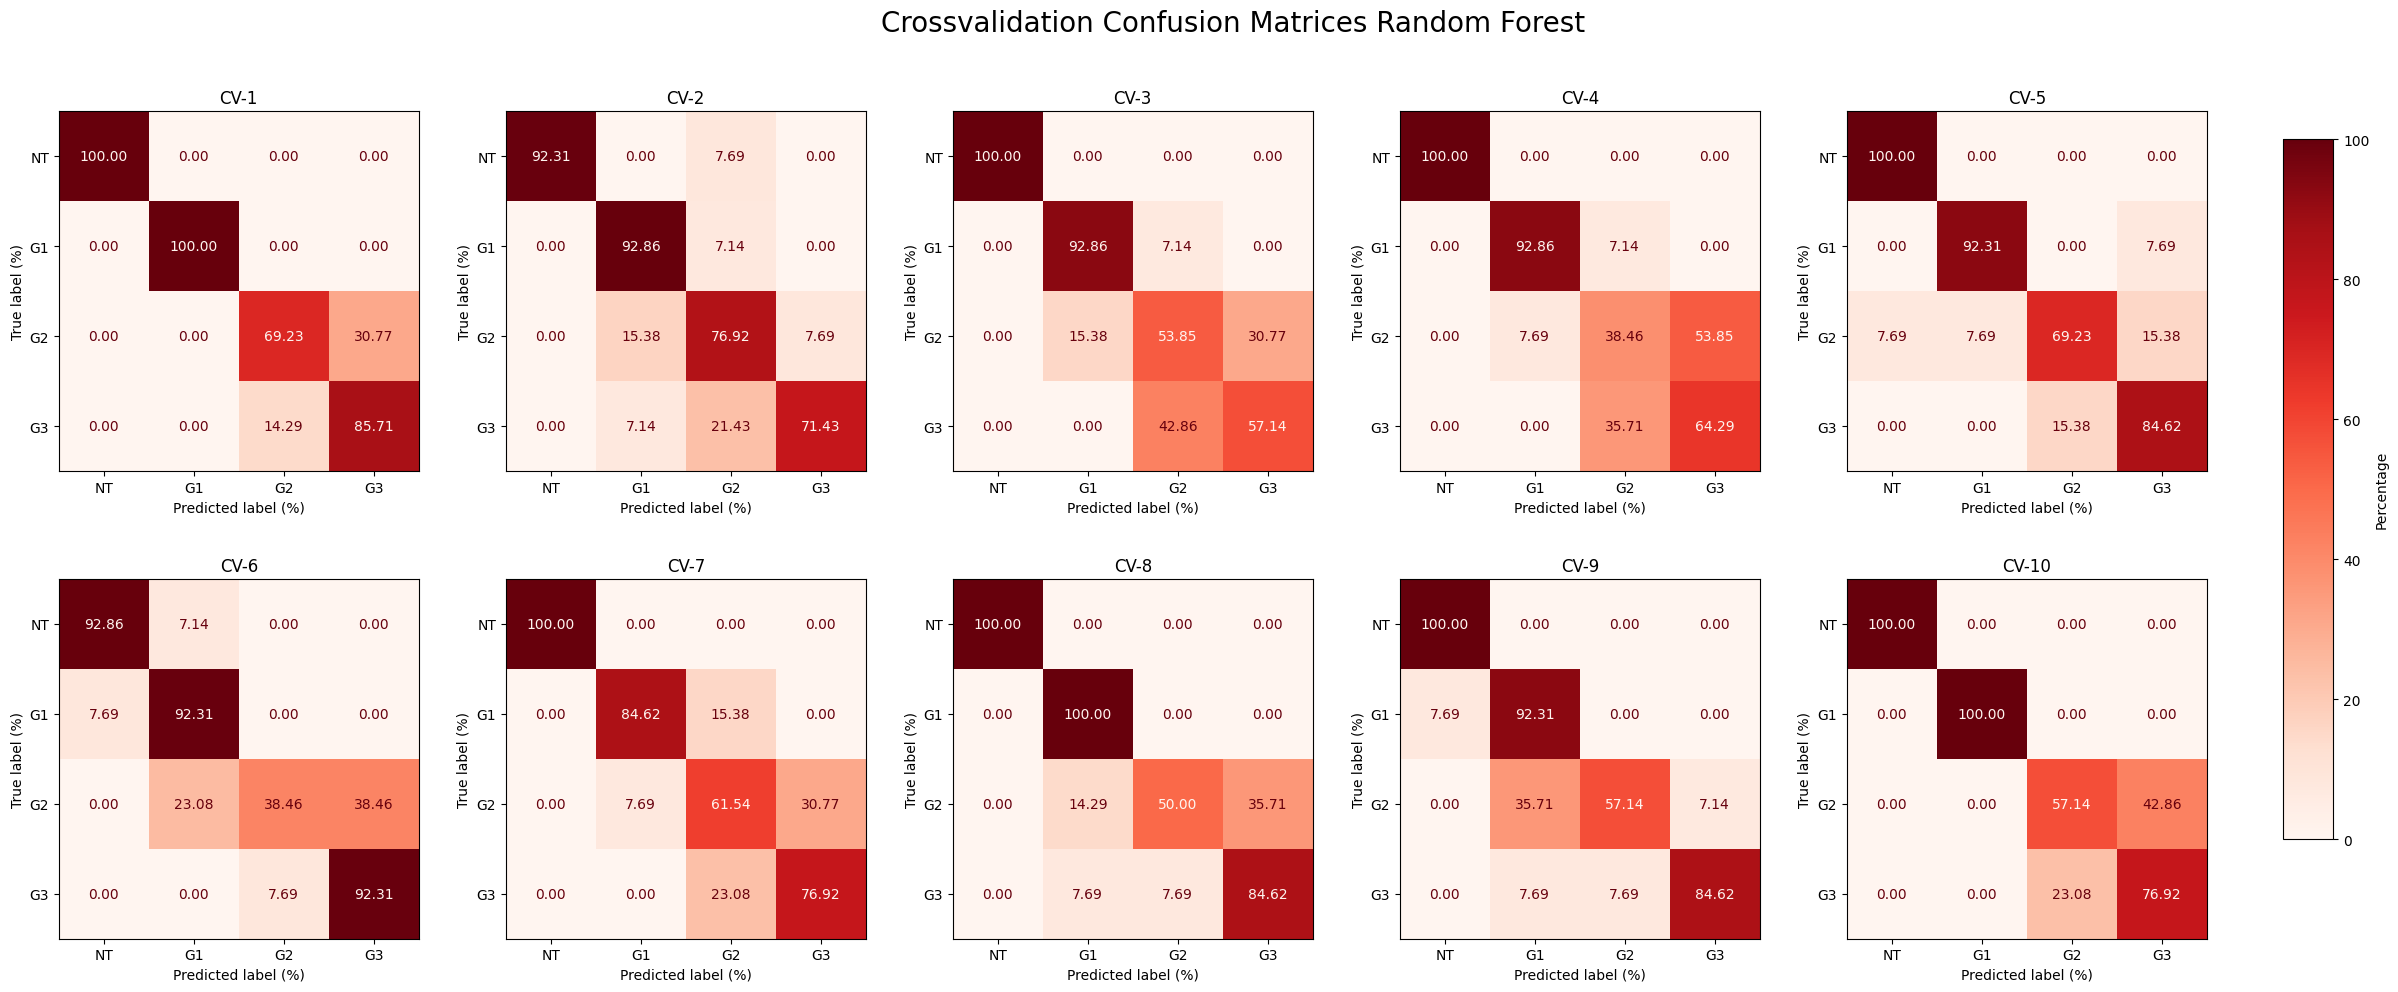

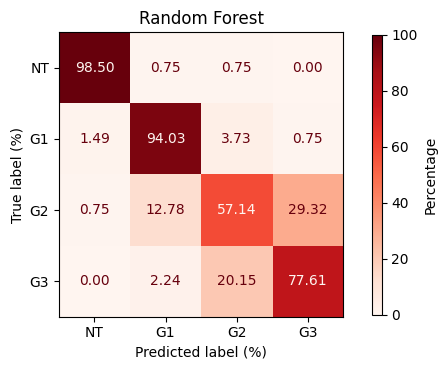

Cross-Validation Results Random Forest:
Accuracy: ['88.89', '83.33', '75.93', '74.07', '86.79', '79.25', '81.13', '83.02', '83.02', '83.02']
Precision: ['89.14', '84.76', '75.86', '73.67', '86.64', '80.68', '81.51', '84.43', '85.09', '83.60']
Recall: ['88.89', '83.33', '75.93', '74.07', '86.79', '79.25', '81.13', '83.02', '83.02', '83.02']
F1: ['88.80', '83.52', '75.76', '73.73', '86.53', '77.36', '81.26', '81.94', '82.57', '82.88']
AUC: ['98.54', '95.03', '93.73', '93.95', '95.02', '95.58', '95.94', '96.78', '96.86', '96.36']

Average Metrics CV Random Forest:
Accuracy: 81.84 +- 4.28
Precision: 82.54 +- 4.52
Recall: 81.84 +- 4.28
F1: 81.43 +- 4.43
AUC: 95.78 +- 1.37

Sensitivity (Recall) CV Random Forest:
NT: 98.52 ± 2.97
G1: 94.01 ± 4.57
G2: 57.20 ± 12.09
G3: 77.86 ± 10.31

Specificity CV Random Forest:
NT: 99.24 ± 1.17
G1: 94.75 ± 4.53
G2: 91.84 ± 5.22
G3: 90.00 ± 4.61

True positive CV Random Forest:
NT: 98.52 ± 2.97
G1: 94.01 ± 4.57
G2: 57.20 ± 12.09
G3: 77.86 ± 10.31


In [ ]:
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
crossvalidation(rf, 'Random Forest',X_train_valid_scaled, y_train_valid)

Evaluation metrics RF
Accuracy: 85.07 %
Precision: 84.69 %
Recall: 85.07 %
F1-score: 84.79 %
Confusion Matrix RF:
[[100.           0.           0.           0.        ]
 [  0.          96.96969697   3.03030303   0.        ]
 [  2.94117647   8.82352941  70.58823529  17.64705882]
 [  0.           3.03030303  24.24242424  72.72727273]]


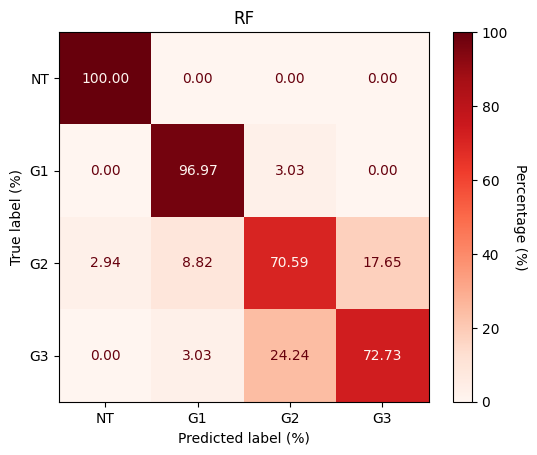

In [ ]:
#evaluation
model = RandomForestClassifier(n_estimators=1000, random_state=42)
evauation_test(X_train_valid_scaled, X_test_scaled, y_train_valid, y_test, model, 'RF')

<ipython-input-29-5c0eb07ccb38>:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-29-5c0eb07ccb38>:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


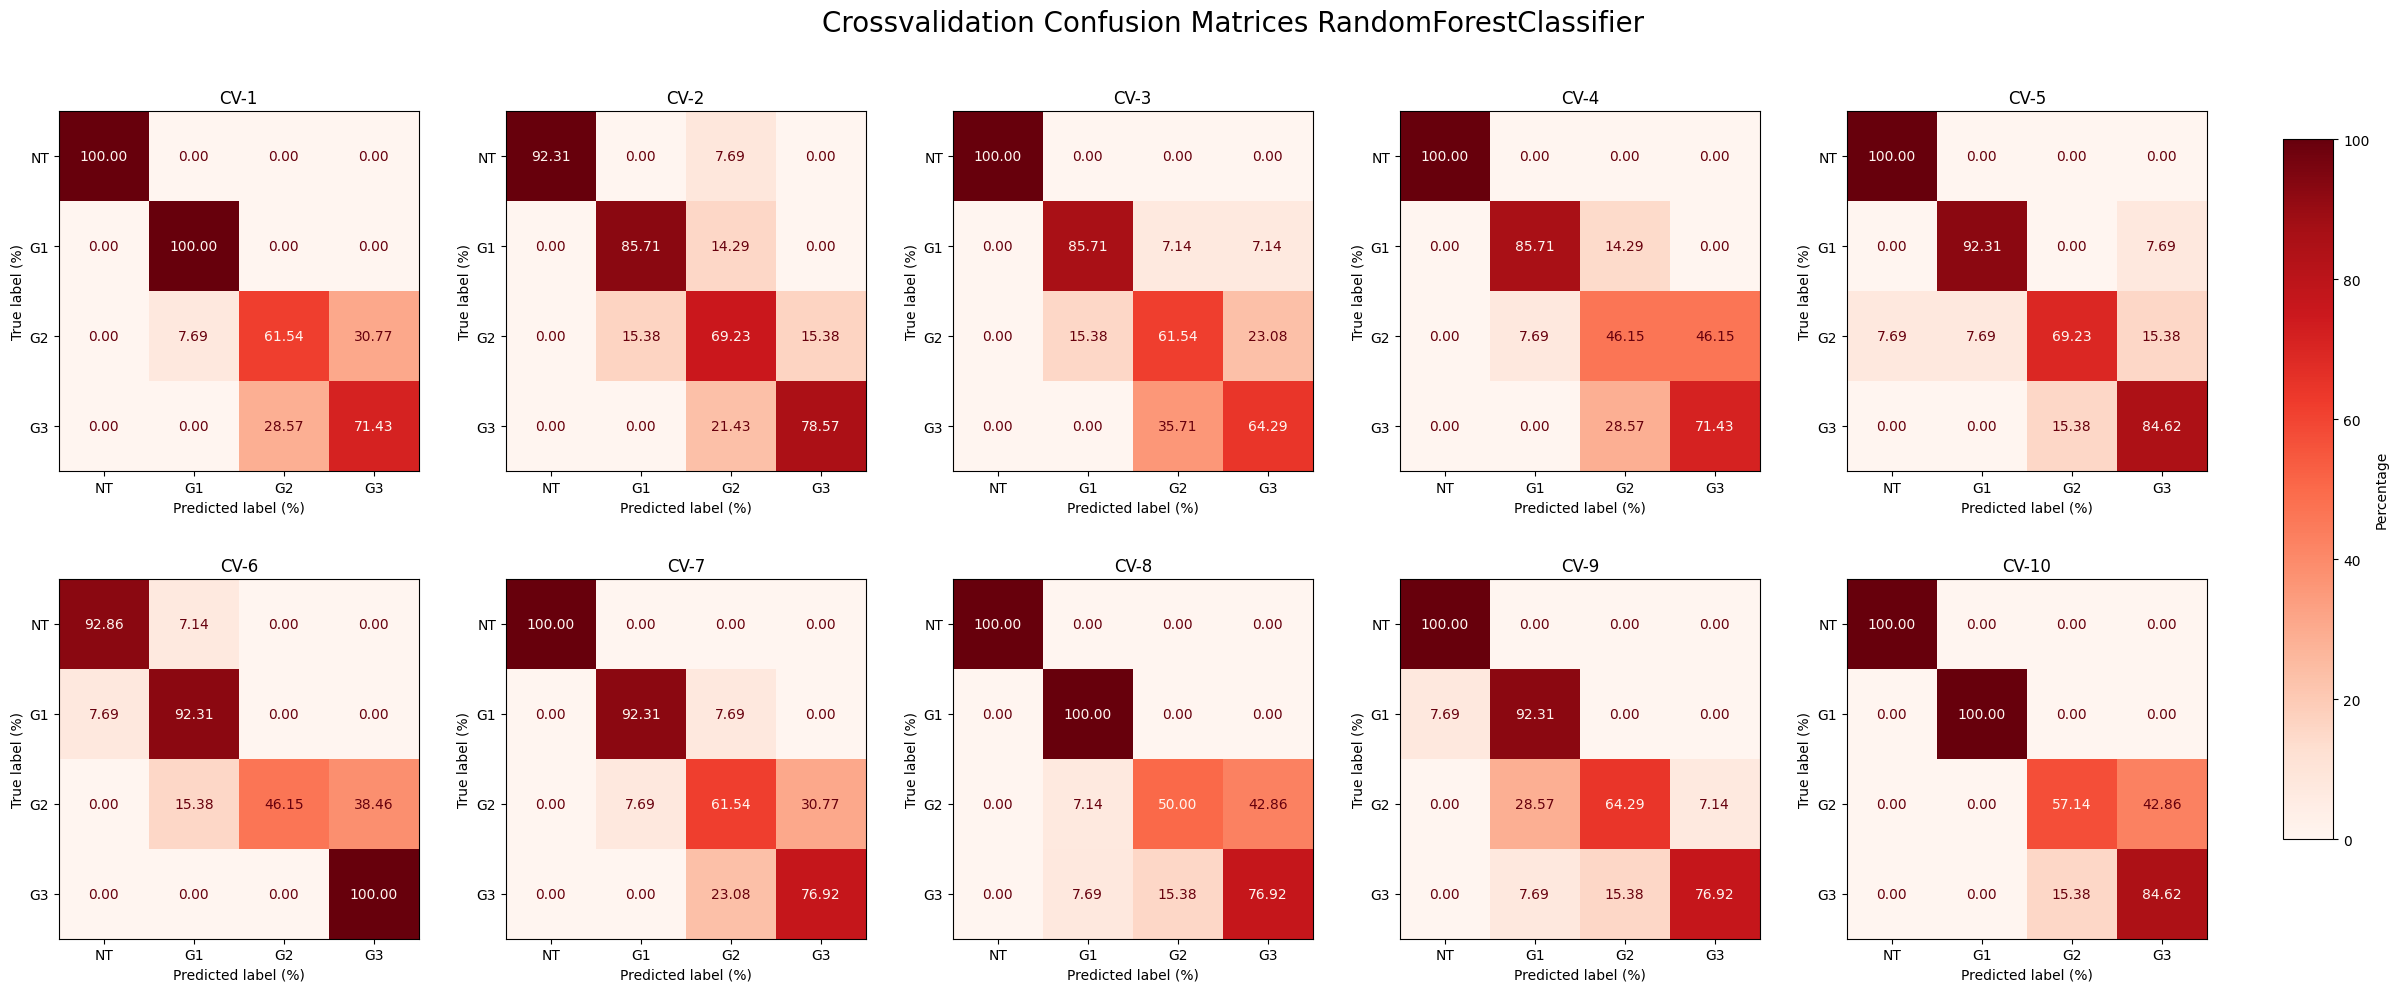

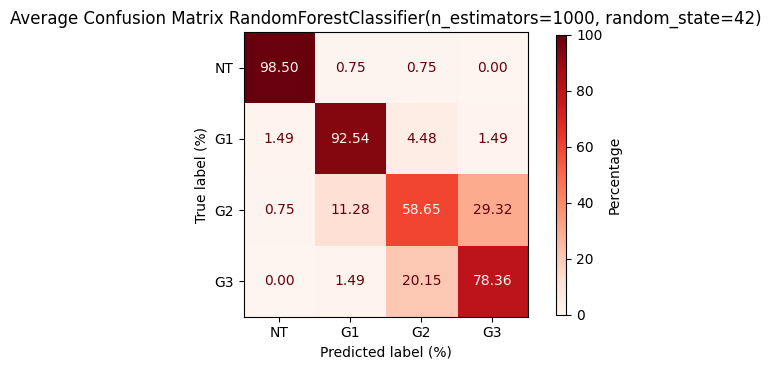

Cross-Validation Results RandomForestClassifier(n_estimators=1000, random_state=42):
Accuracy: ['83.33', '81.48', '77.78', '75.93', '86.79', '83.02', '83.02', '81.13', '83.02', '84.91']
Precision: ['82.84', '82.68', '78.00', '76.25', '86.64', '86.39', '82.93', '81.66', '84.00', '86.06']
Recall: ['83.33', '81.48', '77.78', '75.93', '86.79', '83.02', '83.02', '81.13', '83.02', '84.91']
F1: ['83.03', '81.93', '77.85', '75.96', '86.53', '81.62', '82.92', '80.30', '82.70', '84.65']
AUC: ['97.62', '95.27', '94.52', '93.15', '94.74', '97.05', '95.67', '96.73', '97.21', '96.47']

Average Metrics CV RandomForestClassifier(n_estimators=1000, random_state=42):
Accuracy: 82.04 +- 3.03
Precision: 82.74 +- 3.27
Recall: 82.04 +- 3.03
F1: 81.75 +- 2.93
AUC: 95.84 +- 1.35

True positive CV RandomForestClassifier(n_estimators=1000, random_state=42):
NT: 98.52 ± 2.97
G1: 92.64 ± 5.54
G2: 58.68 ± 8.19
G3: 78.57 ± 9.20


In [ ]:
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
crossvalidation(rf, X_train_valid_scaled_02, y_train_valid)

#3. NN

Epoch 1/100
43/43 [==============================] - 6s 38ms/step - loss: 2.5499 - accuracy: 0.2933 - val_loss: 2.2153 - val_accuracy: 0.5233 - lr: 8.0000e-04
Epoch 2/100
43/43 [==============================] - 1s 21ms/step - loss: 2.1267 - accuracy: 0.3754 - val_loss: 1.7678 - val_accuracy: 0.6279 - lr: 8.0000e-04
Epoch 3/100
43/43 [==============================] - 1s 12ms/step - loss: 1.8796 - accuracy: 0.4780 - val_loss: 1.6340 - val_accuracy: 0.5698 - lr: 8.0000e-04
Epoch 4/100
43/43 [==============================] - 1s 12ms/step - loss: 1.7429 - accuracy: 0.5249 - val_loss: 1.5786 - val_accuracy: 0.5698 - lr: 8.0000e-04
Epoch 5/100
43/43 [==============================] - 1s 12ms/step - loss: 1.6452 - accuracy: 0.5337 - val_loss: 1.4603 - val_accuracy: 0.6512 - lr: 8.0000e-04
Epoch 6/100
43/43 [==============================] - 1s 12ms/step - loss: 1.5752 - accuracy: 0.5425 - val_loss: 1.6023 - val_accuracy: 0.4186 - lr: 8.0000e-04
Epoch 7/100
43/43 [===========================

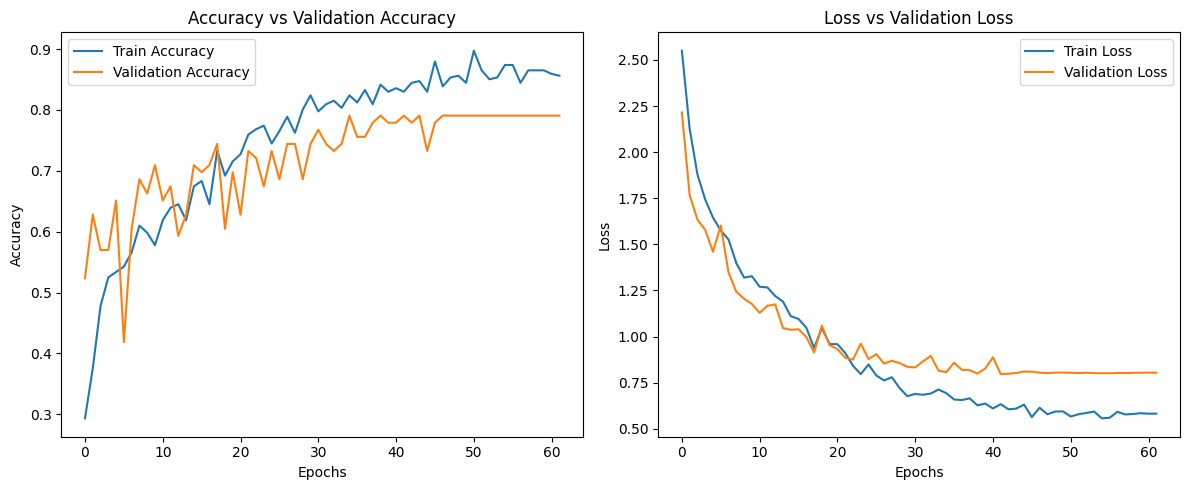

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,  BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Example dataset
# Replace with your actual data
X = X_train_valid_02
y = y_train_valid

# One-hot encoding of the target labels
y_hot = to_categorical(y, num_classes=4)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_hot, test_size=0.2, random_state=42)

# Feature scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the neural network model
def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=tf.keras.regularizers.l2(regularizer)))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(regularizer)))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(regularizer)))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(regularizer)))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(regularizer)))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Hyperparameters
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]
learning_rate = 0.0008 ##### convergence
dropout_rate = 0.25 ##### >more regulaizer
batch_size = 8 #16 ####
epochs = 100
regularizer = 0.009

# Create and train the model
model = create_model(input_dim, num_classes, learning_rate, dropout_rate)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule])

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.2f}')

# Plot accuracy vs val_accuracy and loss vs val_loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 512)               475648    
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout_5 (Dropout)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 256)              

In [ ]:
from kerastuner import HyperModel, RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

class MyHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        '''
        model.add(Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        '''
        model.add(Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        model.add(Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(hp.Float('regularizer', 0.001, 0.01))))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_rate', 0.1, 0.5)))
        model.add(Dense(num_classes, activation='softmax'))

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 0.0001, 0.001)),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        return model

hypermodel = MyHyperModel()

tuner = RandomSearch(
    hypermodel,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir_1',
    project_name='hyperparameter_tuning_1')

tuner.search_space_summary()

tuner.search(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping, lr_schedule])

# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.2f}')

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print(f"""
The hyperparameter search is complete. Here are the best hyperparameters:
- Learning rate: {best_hps.get('learning_rate')}
- Dropout rate: {best_hps.get('dropout_rate')}
- L2 regularization: {best_hps.get('regularizer')}
""")



'''
history = best_model.fit(X_train, y_train, epochs=100, batch_size=best_model.batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule])

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()
'''


Trial 10 Complete [00h 00m 48s]
val_accuracy: 0.7674418687820435

Best val_accuracy So Far: 0.8255813717842102
Total elapsed time: 00h 06m 00s
4/4 [==============================] - 1s 7ms/step - loss: 3.8050 - accuracy: 0.8131
Test accuracy: 0.81

The hyperparameter search is complete. Here are the best hyperparameters:
- Learning rate: 0.0007633572806175834
- Dropout rate: 0.2471501920863339
- L2 regularization: 0.00889643782323539



"\nhistory = best_model.fit(X_train, y_train, epochs=100, batch_size=best_model.batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule])\n\nplt.figure(figsize=(12, 5))\n\n# Accuracy plot\nplt.subplot(1, 2, 1)\nplt.plot(history.history['accuracy'], label='Train Accuracy')\nplt.plot(history.history['val_accuracy'], label='Validation Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('Accuracy')\nplt.title('Accuracy vs Validation Accuracy')\nplt.legend()\n\n# Loss plot\nplt.subplot(1, 2, 2)\nplt.plot(history.history['loss'], label='Train Loss')\nplt.plot(history.history['val_loss'], label='Validation Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.title('Loss vs Validation Loss')\nplt.legend()\n\nplt.tight_layout()\nplt.show()\n"

#5. NN Crossvalidation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    sensitivity = recall_score(y_test, y_pred, average=None)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))
    return accuracy, precision, recall, f1, auc, cm, sensitivity, specificity


def crossvalidation(classifier_func, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(num_classes):
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(num_classes)}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# X, y should be your dataset
# crossvalidation(create_model, 'Neural Network', X, y)


In [ ]:
def create_model(input_dim = 928,  num_classes = 4, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()
    return model

In [ ]:
create_model(learning_rate=0.001, dropout_rate=0.1, regularizer=0.001)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               475648    
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 256)               0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    # model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    sensitivity = recall_score(y_test_classes, y_pred, average=None)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, sensitivity, specificity

def crossvalidation(classifier_func, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    sensitivity_scores = {label: [] for label in range(num_classes)}
    specificity_scores = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm, sensitivity, specificity = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(num_classes):
            sensitivity_scores[label].append(sensitivity[label] * 100)
            specificity_scores[label].append(specificity[label] * 100)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    print('\n======================================================================')
    print(f'Sensitivity for each class CV {model_title}:')
    for label in range(num_classes):
        avg_sensitivity = np.mean(sensitivity_scores[label])
        std_sensitivity = np.std(sensitivity_scores[label])
        print(f'{class_names[label]}: {avg_sensitivity:.2f} ± {std_sensitivity:.2f}')

    print('\n======================================================================')
    print(f'Specificity for each class CV {model_title}:')
    for label in range(num_classes):
        avg_specificity = np.mean(specificity_scores[label])
        std_specificity = np.std(specificity_scores[label])
        print(f'{class_names[label]}: {avg_specificity:.2f} ± {std_specificity:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# X, y should be your dataset
# crossvalidation(create_model, 'Neural Network', X, y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    sensitivity = recall_score(y_test_classes, y_pred, average=None)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, sensitivity, specificity

def crossvalidation(classifier_func, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    sensitivity_scores = {label: [] for label in range(num_classes)}
    specificity_scores = {label: [] for label in range(num_classes)}
    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm, sensitivity, specificity = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(num_classes):
            sensitivity_scores[label].append(sensitivity[label] * 100)
            specificity_scores[label].append(specificity[label] * 100)
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    print('\n======================================================================')
    print(f'Sensitivity (Recall) CV {model_title}:')
    for label in range(num_classes):
        avg, std = np.mean(sensitivity_scores[label]), np.std(sensitivity_scores[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

    print('\n======================================================================')
    print(f'Specificity CV {model_title}:')
    for label in range(num_classes):
        avg, std = np.mean(specificity_scores[label]), np.std(specificity_scores[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = np.mean(tp_percentages[label]), np.std(tp_percentages[label])
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()


Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'CLCC1',
       'LOC100128675', 'GSTM5',
       ...
       'DDX46', 'ZNF322A', 'RPL7', 'C17orf85', 'MUC13', 'ANKRD11', 'LASP1',
       'PFKFB4', 'C6orf48', 'EGFL8'],
      dtype='object', length=300)
2/2 [==============================] - 0s 12ms/step


2/2 [==============================] - 0s 10ms/step


2/2 [==============================] - 0s 7ms/step


<ipython-input-21-225fef8ad4e2>:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-21-225fef8ad4e2>:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


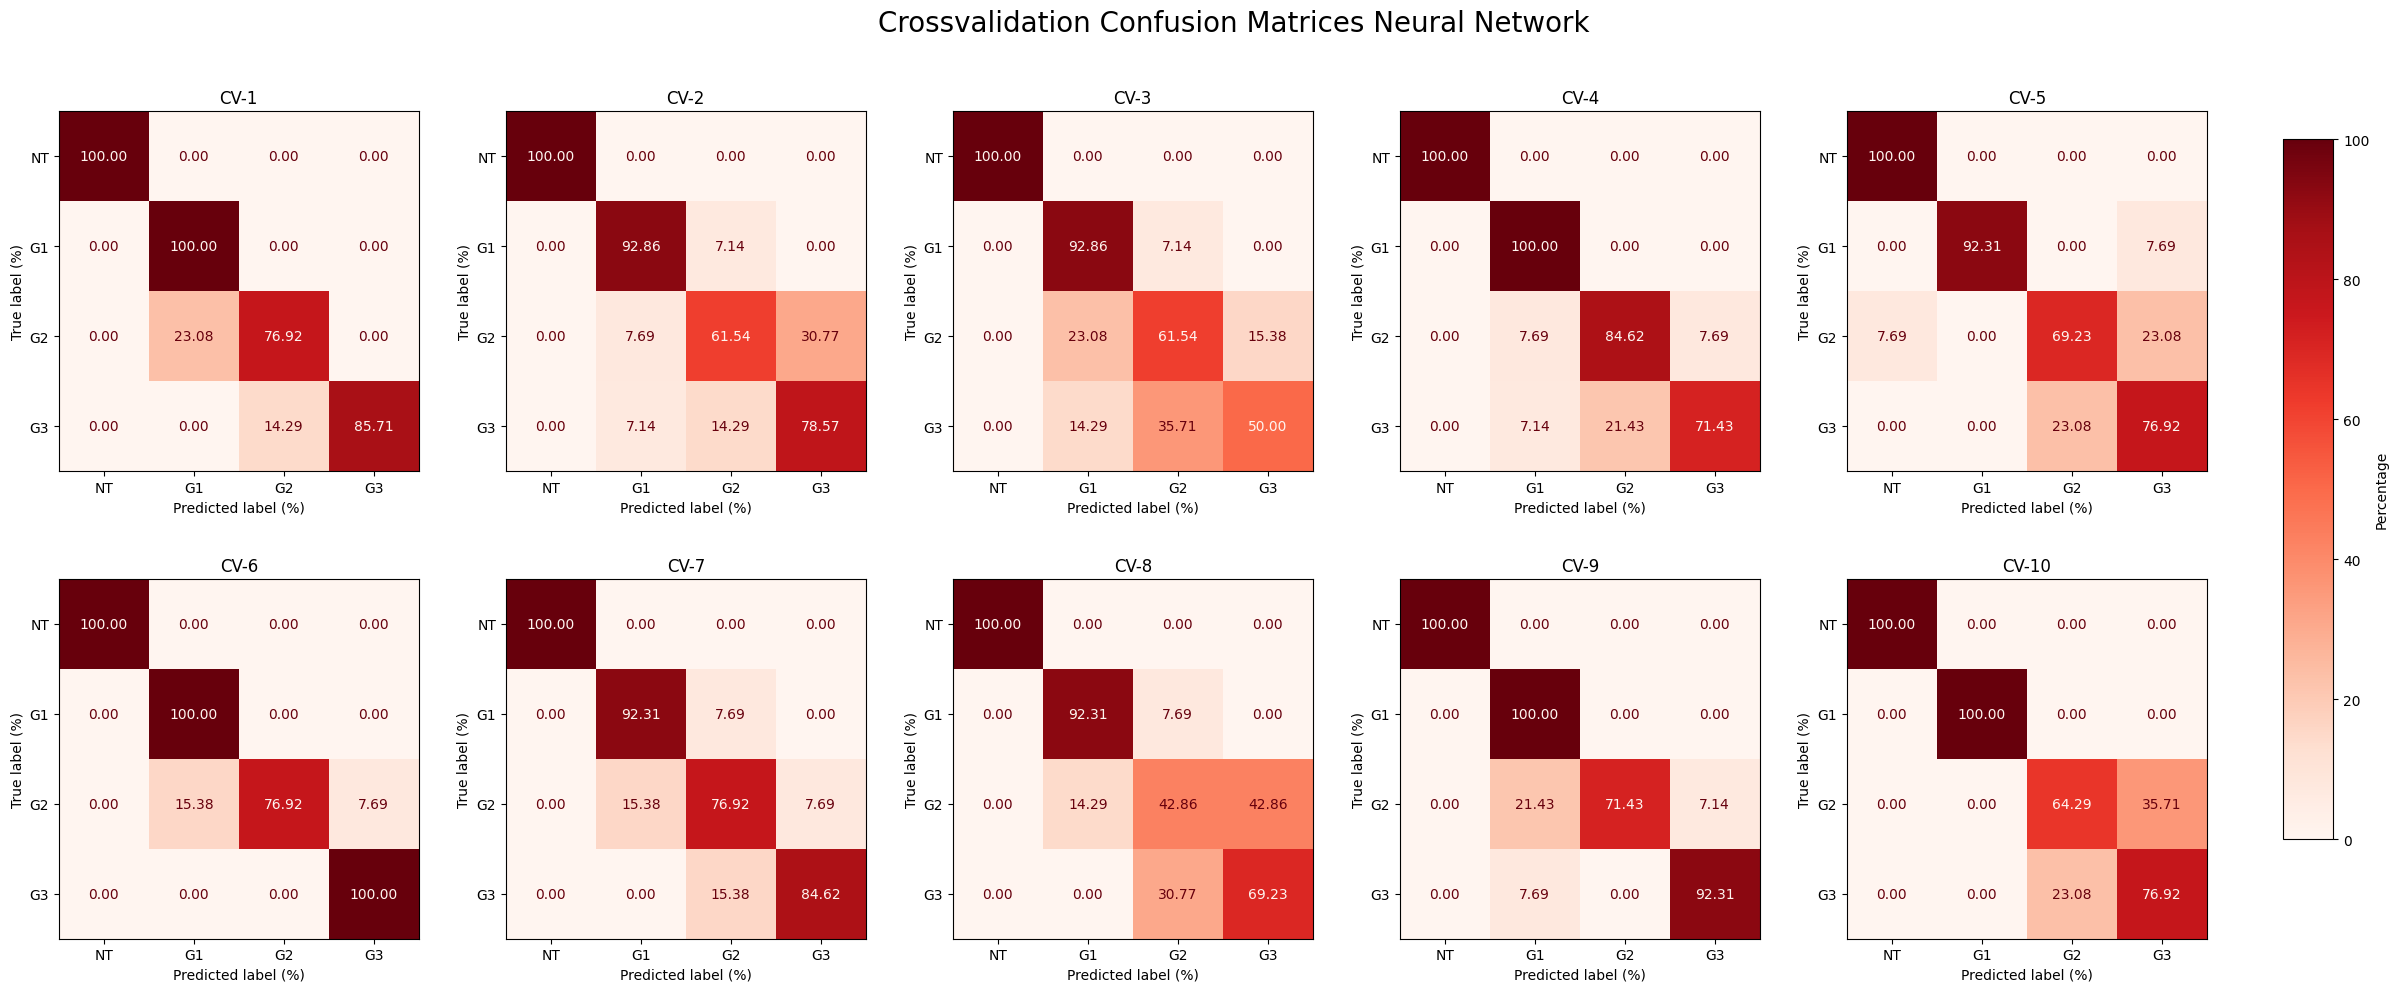

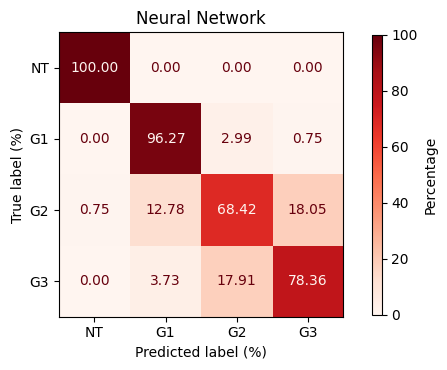

Cross-Validation Results Neural Network:
Accuracy: ['90.74', '83.33', '75.93', '88.89', '84.91', '94.34', '88.68', '75.47', '90.57', '84.91']
Precision: ['91.41', '83.06', '76.72', '89.24', '85.10', '94.98', '88.79', '74.68', '92.34', '85.22']
Recall: ['90.74', '83.33', '75.93', '88.89', '84.91', '94.34', '88.68', '75.47', '90.57', '84.91']
F1: ['90.68', '83.04', '75.19', '88.63', '84.88', '94.14', '88.67', '74.78', '90.44', '84.86']
AUC: ['97.73', '95.69', '96.24', '96.93', '94.62', '98.89', '96.83', '93.16', '97.20', '96.77']

Average Metrics CV Neural Network:
Accuracy: 85.78 +- 5.91
Precision: 86.15 +- 6.27
Recall: 85.78 +- 5.91
F1: 85.53 +- 6.11
AUC: 96.41 +- 1.53

Sensitivity (Recall) CV Neural Network:
NT: 100.00 ± 0.00
G1: 96.26 ± 3.74
G2: 68.63 ± 11.20
G3: 78.57 ± 13.02

Specificity CV Neural Network:
NT: 99.74 ± 0.77
G1: 94.50 ± 3.67
G2: 93.03 ± 4.43
G3: 93.75 ± 4.91

True positive CV Neural Network:
NT: 100.00 ± 0.00
G1: 96.26 ± 3.74
G2: 68.63 ± 11.20
G3: 78.57 ± 13.02


In [ ]:
X_nn100, features100_nn = select_features_cv(feat_nn, X_df, X_train_valid_scaled,top=300)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

In [ ]:
feat_nn

,NT,G1,G2,G3,sum,sum_G2_G3
NEDD1,0.000673,0.001169,0.010519,0.007394,0.019755,0.017913
NUMA1,0.000671,0.000796,0.006674,0.007074,0.015215,0.013748
E2F6,0.000658,0.001556,0.008849,0.004000,0.015063,0.012849
KCNQ1,0.000470,0.000799,0.005393,0.007230,0.013892,0.012622
ATPGD1,0.000694,0.001274,0.006332,0.003381,0.011682,0.009713
...,...,...,...,...,...,...
CPNE2,0.000562,0.000382,0.000450,0.000337,0.001731,0.000787
SNORA34,0.000753,0.000531,0.000405,0.000320,0.002009,0.000725
ZNF639,0.000507,0.000497,0.000358,0.000363,0.001726,0.000721
ZNF862,0.000434,0.000759,0.000259,0.000458,0.001910,0.000717


2/2 [==============================] - 0s 8ms/step


2/2 [==============================] - 0s 10ms/step


2/2 [==============================] - 0s 9ms/step


<ipython-input-35-10e51f5c677c>:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-35-10e51f5c677c>:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


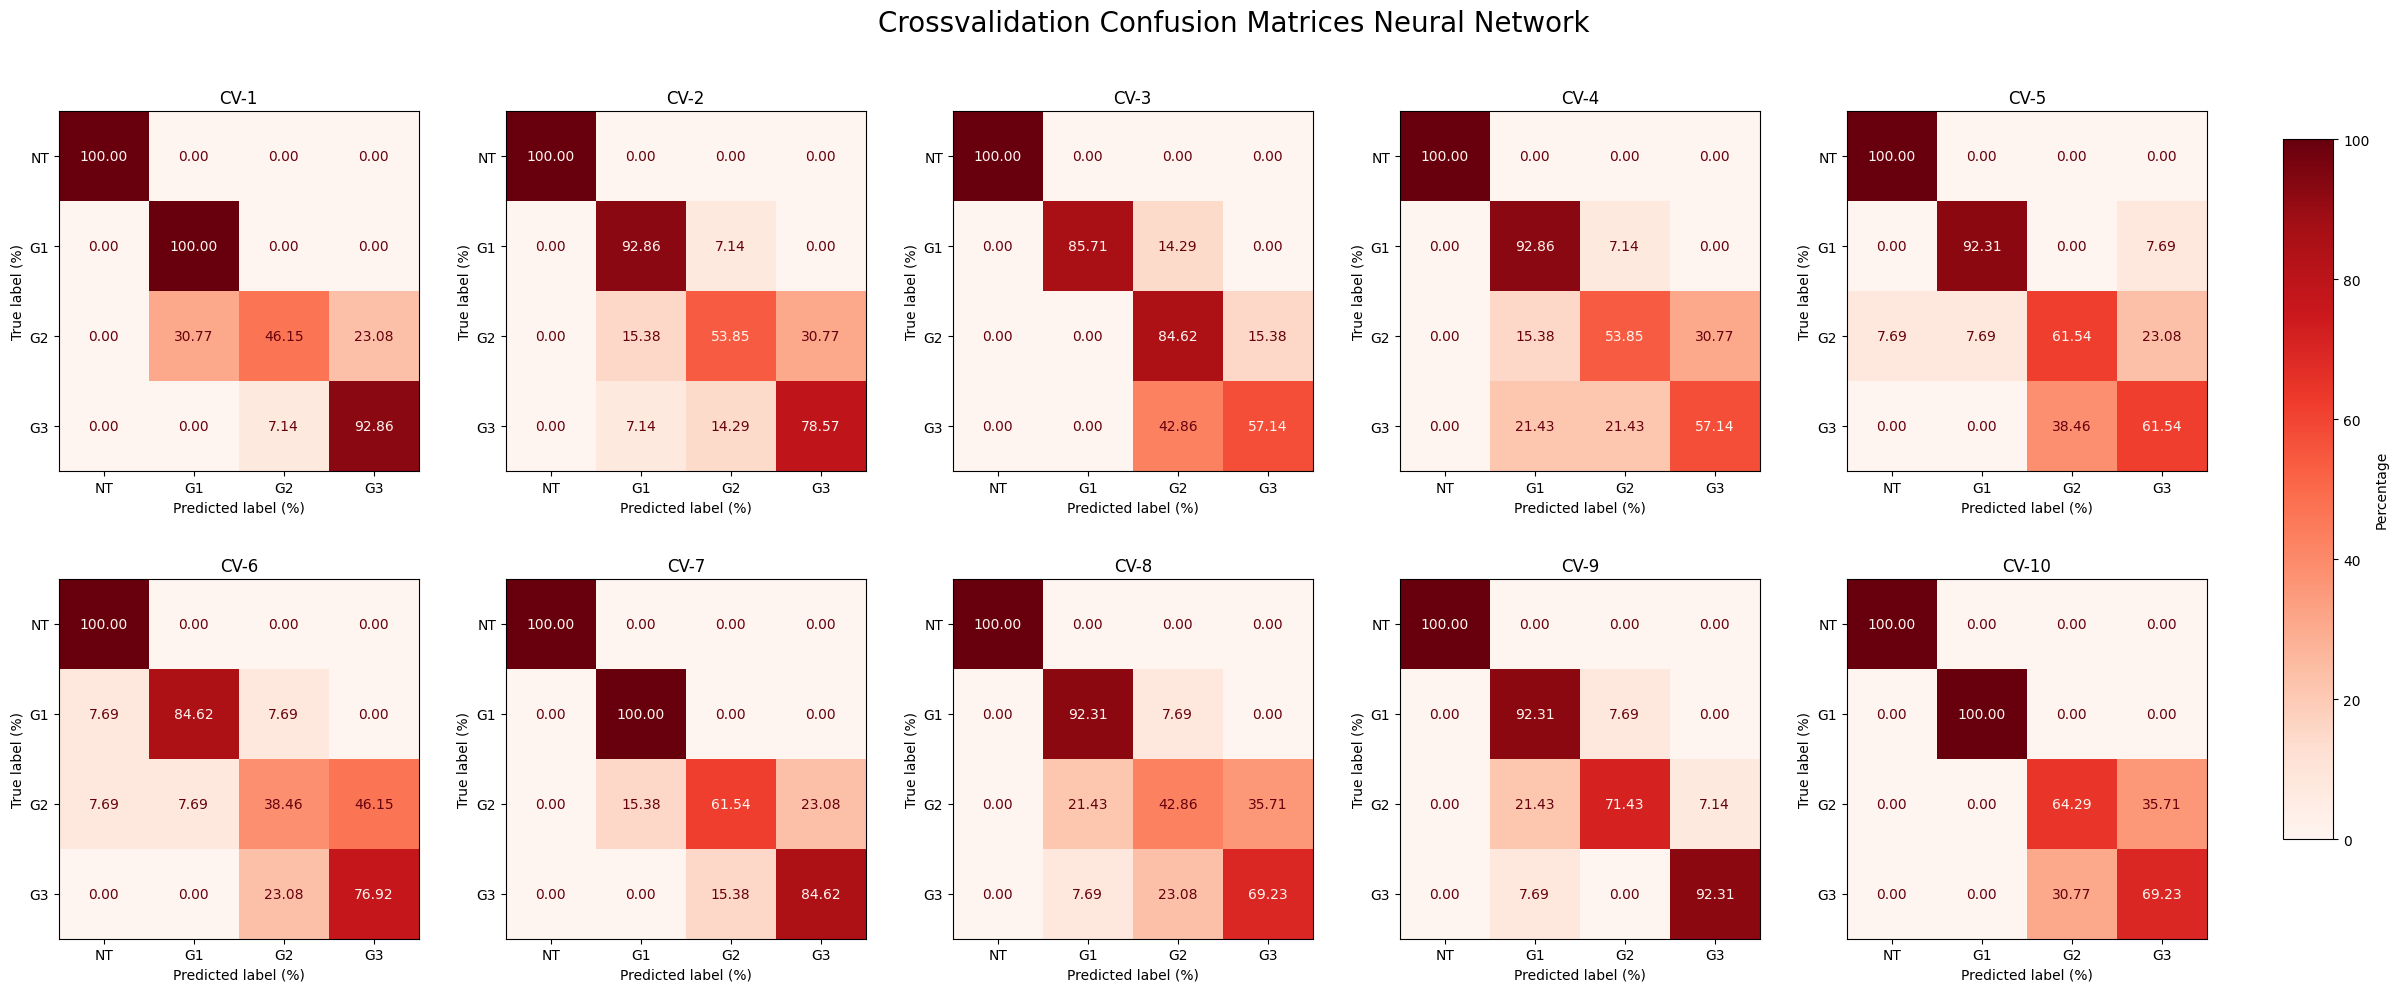

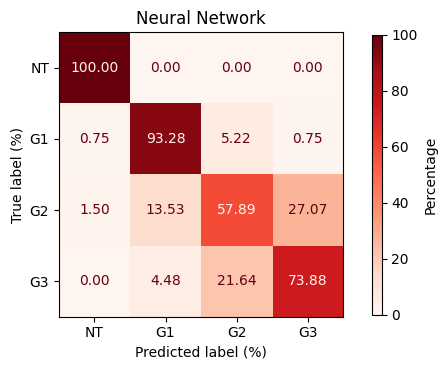

Cross-Validation Results Neural Network:
Accuracy: ['85.19', '81.48', '81.48', '75.93', '79.25', '75.47', '86.79', '75.47', '88.68', '83.02']
Precision: ['85.94', '81.00', '84.68', '75.40', '78.74', '74.55', '86.57', '74.54', '89.58', '83.11']
Recall: ['85.19', '81.48', '81.48', '75.93', '79.25', '75.47', '86.79', '75.47', '88.68', '83.02']
F1: ['83.67', '80.86', '81.84', '75.14', '78.94', '74.30', '86.24', '74.39', '88.60', '83.02']
AUC: ['97.41', '95.51', '95.00', '95.11', '93.22', '94.81', '96.88', '94.06', '96.47', '94.55']

Average Metrics CV Neural Network:
Accuracy: 81.28 +- 4.51
Precision: 81.41 +- 5.15
Recall: 81.28 +- 4.51
F1: 80.70 +- 4.73
AUC: 95.30 +- 1.23

Sensitivity (Recall) CV Neural Network:
NT: 100.00 ± 0.00
G1: 93.30 ± 5.21
G2: 57.86 ± 13.19
G3: 73.96 ± 12.66

Specificity CV Neural Network:
NT: 99.23 ± 1.64
G1: 94.00 ± 4.36
G2: 91.04 ± 4.80
G3: 90.75 ± 3.54

True positive CV Neural Network:
NT: 100.00 ± 0.00
G1: 93.30 ± 5.21
G2: 57.86 ± 13.19
G3: 73.96 ± 12.66


In [ ]:
crossvalidation(create_model, 'Neural Network',X_train_valid_scaled, y_train_valid)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import tensorflow as tf  # Add import statement for TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seed for NumPy
np.random.seed(42)

# Set random seed for TensorFlow
tf.random.set_seed(42)
def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = accuracy_score(y_test_classes, y_pred)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)

    return accuracy, precision, recall, f1, auc, cm

def plot_confusion_matrix_single(cm, class_names, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    print(cm_normalized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    fig, ax = plt.subplots()
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds')
    disp.plot(values_format='.2f', cmap='Reds', colorbar=False, ax=ax)  # Plot without the default colorbar
    plt.title(title)
    plt.xlabel('Predicted label (%)')
    plt.ylabel('True label (%)')

    # Add the color bar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Percentage (%)', rotation=-90, va="bottom")
    plt.show()

def evaluation_test_nn(X_train, X_test, y_train, y_test, classifier_func, class_names, model_title, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001, batch_size=32, epochs=50):
    input_dim = X_train.shape[1]
    num_classes = y_train.shape[1]

    model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)

    accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs)

    # Output the results
    print(f"Evaluation metrics {model_title}")
    print(f"Accuracy: {accuracy*100:.2f} %")
    print(f"Precision: {precision*100:.2f} %")
    print(f"Recall: {recall*100:.2f} %")
    print(f"F1-score: {f1*100:.2f} %")
    print(f"Confusion Matrix {model_title}:")

    plot_confusion_matrix_single(cm, class_names=class_names, title=model_title)


# One-hot encode the target labels
num_classes = 4



5/5 [==============================] - 0s 4ms/step
Evaluation metrics Neural Network Model
Accuracy: 81.34 %
Precision: 80.81 %
Recall: 81.34 %
F1-score: 80.79 %
Confusion Matrix Neural Network Model:
[[100.           0.           0.           0.        ]
 [  0.          93.93939394   6.06060606   0.        ]
 [  2.94117647   8.82352941  55.88235294  32.35294118]
 [  0.           6.06060606  18.18181818  75.75757576]]


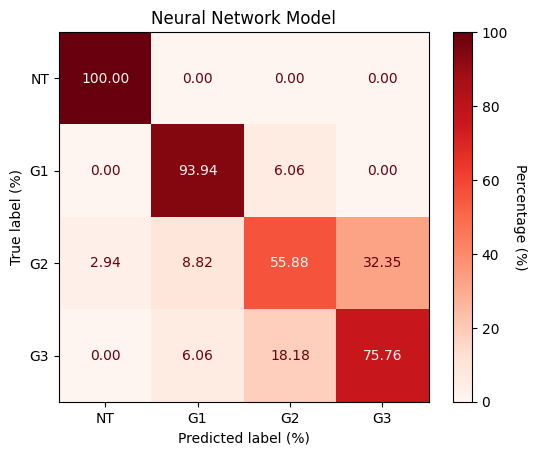

In [ ]:
evaluation_test(X_train_valid, X_test, y_train_hot, y_test_hot, create_model, class_names, "Neural Network Model")

In [ ]:
learning_rate = 0.0008
dropout_rate = 0.25
batch_size = 8
epochs = 100
regularizer = 0.009
input_dim = X_train_valid.shape[1]
num_classes = 4
model = create_model(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
evaluation_test_nn(X_train_valid, X_test, y_train_hot, y_test_hot, model, class_names, "Neural Network Model")

Epoch 1/50
17/17 [==============================] - 4s 55ms/step - loss: 12.6001 - accuracy: 0.4120 - val_loss: 11.7137 - val_accuracy: 0.2537
Epoch 2/50
17/17 [==============================] - 0s 25ms/step - loss: 10.9823 - accuracy: 0.5655 - val_loss: 10.6728 - val_accuracy: 0.5075
Epoch 3/50
17/17 [==============================] - 0s 26ms/step - loss: 9.9957 - accuracy: 0.5955 - val_loss: 9.9370 - val_accuracy: 0.4627
Epoch 4/50
17/17 [==============================] - 0s 26ms/step - loss: 9.2375 - accuracy: 0.6479 - val_loss: 9.3478 - val_accuracy: 0.4179
Epoch 5/50
17/17 [==============================] - 0s 26ms/step - loss: 8.6582 - accuracy: 0.6835 - val_loss: 8.8411 - val_accuracy: 0.4552
Epoch 6/50
17/17 [==============================] - 0s 24ms/step - loss: 8.2377 - accuracy: 0.6742 - val_loss: 8.3259 - val_accuracy: 0.4925
Epoch 7/50
17/17 [==============================] - 0s 25ms/step - loss: 7.7577 - accuracy: 0.7247 - val_loss: 7.9309 - val_accuracy: 0.4925
Epoch 8/5

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

In [ ]:
num_classes = 4
y_hot = label_binarize(y_train_valid, classes=range(num_classes))
y_hot

array([[0, 1, 0, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       ...,
       [0, 0, 0, 1],
       [0, 1, 0, 0],
       [0, 0, 0, 1]])

# SHAP Feature extraction

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 6.1 MB/s eta 0:00:00


In [ ]:
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def calculate_shap_values(classifier, X_train, X_test):
    # Use K-means to summarize the background dataset
    summarized_X_train = shap.kmeans(X_train, 50)
    if isinstance(classifier, RandomForestClassifier):
        print('shap.TreeExplainer')
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test)
    else:
        explainer = shap.KernelExplainer(classifier.predict_proba, summarized_X_train)
        shap_values = explainer.shap_values(X_test, nsamples=500)
        print('shap.KernelExplainer')
    return shap_values

def crossvalidation_with_shap(classifier, model_title, X, y, df, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)

    shap_values_list = []
    idx = 0
    for train_index, test_index in kf.split(X, y):
        idx += 1
        print(f'\nfold-{idx}')
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        classifier.fit(X_train, y_train)

        # Calculate SHAP values
        shap_values = calculate_shap_values(classifier, X_train, X_test)

        # Calculate mean absolute SHAP values for each class
        mean_0 = np.mean(np.abs(shap_values[:,:, 0]), axis=0)
        mean_1 = np.mean(np.abs(shap_values[:,:, 1]), axis=0)
        mean_2 = np.mean(np.abs(shap_values[:,:, 2]), axis=0)
        mean_3 = np.mean(np.abs(shap_values[:,:, 3]), axis=0)


        # Create a DataFrame for the current fold
        df_fold = pd.DataFrame({'NT': mean_0, 'G1': mean_1, 'G2': mean_2, 'G3': mean_3})

        # Store SHAP values DataFrame for this fold
        shap_values_list.append(df_fold)
        print('\n==================================================')

    # Average SHAP values across all folds

    avg_shap = pd.concat(shap_values_list).groupby(level=0).mean()
    avg_shap.index = df.columns
    avg_shap['sum'] = avg_shap.sum(axis=1)
    avg_shap = avg_shap.sort_values(by='sum', ascending=False)
    # Print the averaged SHAP values
    avg_shap
    return avg_shap



In [ ]:
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
features_svm_linear = crossvalidation_with_shap(svm_linear,'Linear SVM', X_train_valid_scaled, y_train_valid, X_df)


fold-1


  0%|          | 0/54 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/54 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

shap.KernelExplainer


fold-9


  0%|          | 0/53 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/53 [00:00<?, ?it/s]

shap.KernelExplainer



In [ ]:
features_svm_linear.to_csv('features_importances_linearSVM.txt', sep=' ', index=True, header=True)
features_svm_linear

,NT,G1,G2,G3,sum
KCNQ1,0.000712,0.001990,0.006623,0.005254,0.014578
S100A2,0.001023,0.001253,0.001422,0.006740,0.010438
COLEC11,0.000394,0.001334,0.004883,0.003047,0.009658
RAB22A,0.000371,0.002691,0.005029,0.001513,0.009604
CDKL2,0.000463,0.000668,0.005226,0.003091,0.009448
...,...,...,...,...,...
CMTM6,0.000384,0.000215,0.000201,0.000267,0.001067
URB2,0.000253,0.000246,0.000205,0.000337,0.001042
ENSA,0.000394,0.000240,0.000169,0.000232,0.001034
RECQL4,0.000193,0.000153,0.000296,0.000356,0.000999


In [ ]:
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
features_svm_kernel = crossvalidation_with_shap(svm_kernel,'Poly SVM', X_train_valid_scaled, y_train_valid, X_df)


fold-1


  0%|          | 0/54 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/54 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

shap.KernelExplainer


fold-9


  0%|          | 0/53 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/53 [00:00<?, ?it/s]

shap.KernelExplainer



In [ ]:
features_svm_kernel.to_csv('features_importances_kernelSVM.txt', sep=' ', index=True, header=True)
features_svm_kernel

,NT,G1,G2,G3,sum
KCNQ1,0.000510,0.001553,0.005397,0.005586,0.013046
CDKL2,0.000547,0.000598,0.006621,0.004143,0.011909
RAB22A,0.000257,0.003362,0.004426,0.001139,0.009185
E2F6,0.000478,0.000795,0.005097,0.002772,0.009141
PIGB,0.000619,0.002668,0.000966,0.004667,0.008920
...,...,...,...,...,...
ATP1B3,0.000141,0.000277,0.000259,0.000357,0.001035
NEK5,0.000286,0.000138,0.000295,0.000315,0.001033
BHLHE40,0.000308,0.000099,0.000321,0.000290,0.001018
SRP54,0.000167,0.000313,0.000280,0.000256,0.001016


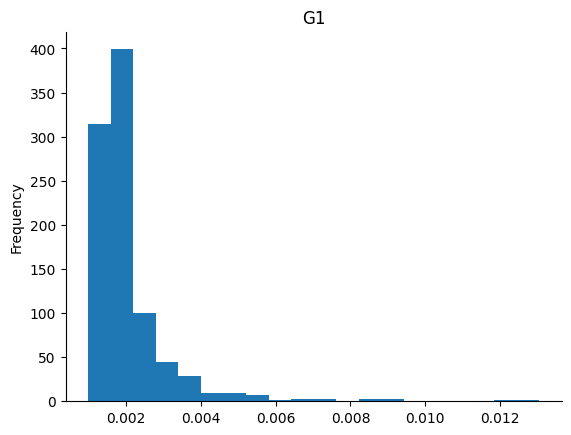

In [ ]:
# @title G1

from matplotlib import pyplot as plt
features_svm_kernel['sum'].plot(kind='hist', bins=20, title='G1')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
features_svm_kernel

In [ ]:
features_svm_kernel.to_csv('features_importances_SVMKernel.txt', sep=' ', index=True, header=True)

In [ ]:
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
features_rf = crossvalidation_with_shap(rf, 'RF',X_train_valid_scaled, y_train_valid, X_df)


fold-1
shap.TreeExplainer


fold-2
shap.TreeExplainer


fold-3
shap.TreeExplainer


fold-4
shap.TreeExplainer


fold-5
shap.TreeExplainer


fold-6
shap.TreeExplainer


fold-7
shap.TreeExplainer


fold-8
shap.TreeExplainer


fold-9
shap.TreeExplainer


fold-10
shap.TreeExplainer



In [ ]:
features_rf

,NT,G1,G2,G3,sum
ADIPOR1,0.016250,0.005199,0.005045,0.006036,0.032530
KIAA0664,0.012234,0.002325,0.005132,0.005705,0.025396
RGS12,0.008552,0.004458,0.005704,0.004403,0.023117
C2orf79,0.009525,0.002631,0.005164,0.004356,0.021676
HOXA10,0.009152,0.001645,0.004299,0.003928,0.019023
...,...,...,...,...,...
VAMP4,0.000063,0.000113,0.000114,0.000115,0.000404
CXCL16,0.000030,0.000109,0.000136,0.000122,0.000396
HRAS,0.000028,0.000112,0.000152,0.000103,0.000396
KIAA0467,0.000035,0.000113,0.000123,0.000109,0.000379


In [ ]:
features_rf.to_csv('features_importances_RF.txt', sep=' ', index=True, header=True)

#G2 G3 SHAP

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 6.8 MB/s eta 0:00:00


In [ ]:
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def calculate_shap_values(classifier, X_train, X_test):
    # Use K-means to summarize the background dataset
    summarized_X_train = shap.kmeans(X_train, 50)
    if isinstance(classifier, RandomForestClassifier):
        print('shap.TreeExplainer')
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test)
    else:
        explainer = shap.KernelExplainer(classifier.predict_proba, summarized_X_train)
        shap_values = explainer.shap_values(X_test, nsamples=500)
        print('shap.KernelExplainer')
    return shap_values

def crossvalidation_with_shap_binary(classifier, model_title, X, y, df, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)

    shap_values_list = []
    idx = 0
    for train_index, test_index in kf.split(X, y):
        idx += 1
        print(f'\nfold-{idx}')
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        classifier.fit(X_train, y_train)

        # Calculate SHAP values
        shap_values = calculate_shap_values(classifier, X_train, X_test)

        # Calculate mean absolute SHAP values for each class
        mean_0 = np.mean(np.abs(shap_values[:,:, 0]), axis=0)
        mean_1 = np.mean(np.abs(shap_values[:,:, 1]), axis=0)
        #mean_2 = np.mean(np.abs(shap_values[:,:, 2]), axis=0)
        #mean_3 = np.mean(np.abs(shap_values[:,:, 3]), axis=0)


        # Create a DataFrame for the current fold
        df_fold = pd.DataFrame({'G2': mean_0, 'G3': mean_1})

        # Store SHAP values DataFrame for this fold
        shap_values_list.append(df_fold)
        print('\n==================================================')

    # Average SHAP values across all folds

    avg_shap = pd.concat(shap_values_list).groupby(level=0).mean()
    avg_shap.index = df.columns
    avg_shap['sum'] = avg_shap.sum(axis=1)
    avg_shap = avg_shap.sort_values(by='sum', ascending=False)
    # Print the averaged SHAP values
    avg_shap
    return avg_shap



In [ ]:
#svm_linear = SVC(kernel='linear', probability = True, random_state=42)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
features_logis_g2g3 = crossvalidation_with_shap_binary(logistic,'logistic regression', X_train_valid_scaled0, y_train_valid0, X_df)
features_logis_g2g3.to_csv('features_importances_logisg2g3.txt', sep=' ', index=True, header=True)
features_logis_g2g3



fold-1


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer



,G2,G3,sum
KCNQ1,0.011702,0.011702,0.023404
PAPLN,0.010682,0.010682,0.021364
NUMA1,0.008251,0.008251,0.016503
SLC6A6,0.007033,0.007033,0.014066
RAB22A,0.006585,0.006585,0.013169
...,...,...,...
PLEKHM1,0.000473,0.000473,0.000945
ZNRF1,0.000468,0.000468,0.000936
CDK4,0.000460,0.000460,0.000920
IBTK,0.000413,0.000413,0.000827


In [ ]:
#svm_linear = SVC(kernel='linear', probability = True, random_state=42)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
features_lsvm_g2g3 = crossvalidation_with_shap_binary(svm_linear,'Linear SVM', X_train_valid_scaled0, y_train_valid0, X_df)
features_lsvm_g2g3.to_csv('features_importances_lsvmg2g3.txt', sep=' ', index=True, header=True)
features_lsvm_g2g3


fold-1


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer



,G2,G3,sum
KCNQ1,0.011251,0.011251,0.022502
OR8B4,0.008460,0.008460,0.016921
MIR10B,0.008413,0.008413,0.016825
SLC6A6,0.007927,0.007927,0.015855
C4orf31,0.007659,0.007659,0.015318
...,...,...,...
SLC47A2,0.000663,0.000663,0.001326
ADD1,0.000656,0.000656,0.001312
ZNF385B,0.000643,0.000643,0.001285
RYBP,0.000639,0.000639,0.001277


In [ ]:
#svm_linear = SVC(kernel='linear', probability = True, random_state=42)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
features_lsvm_g2g3 = crossvalidation_with_shap_binary(svm_linear,'Linear SVM', X_train_valid_scaled0, y_train_valid0, X_df)
features_lsvm_g2g3.to_csv('features_importances_lsvmg2g3.txt', sep=' ', index=True, header=True)
features_lsvm_g2g3

In [ ]:
#svm_linear = SVC(kernel='linear', probability = True, random_state=42)
svm_poly = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
features_psvm_g2g3 = crossvalidation_with_shap_binary(svm_poly,'Polynomial SVM', X_train_valid_scaled0, y_train_valid0, X_df)
features_psvm_g2g3.to_csv('features_importances_psvmg2g3.txt', sep=' ', index=True, header=True)
features_psvm_g2g3

#model= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)


fold-1


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer



,G2,G3,sum
KCNQ1,0.012439,0.012439,0.024877
SLC6A6,0.007463,0.007463,0.014926
PAPLN,0.006731,0.006731,0.013463
OR8B4,0.006409,0.006409,0.012817
NEDD1,0.006096,0.006096,0.012192
...,...,...,...
CEBPG,0.000512,0.000512,0.001025
PDSS1,0.000484,0.000484,0.000967
HRAS,0.000480,0.000480,0.000960
VARS2,0.000470,0.000470,0.000940


In [ ]:
#svm_linear = SVC(kernel='linear', probability = True, random_state=42)
svm_rbf = SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
features_rbfsvm_g2g3 = crossvalidation_with_shap_binary(svm_rbf,'Kernel SVM', X_train_valid_scaled0, y_train_valid0, X_df)
features_rbfsvm_g2g3.to_csv('features_importances_rbfsvmg2g3.txt', sep=' ', index=True, header=True)
features_rbfsvm_g2g3




fold-1


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-2


  0%|          | 0/27 [00:00<?, ?it/s]

shap.KernelExplainer


fold-3


...

  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer


fold-10


  0%|          | 0/26 [00:00<?, ?it/s]

shap.KernelExplainer



,G2,G3,sum
MIR1975,0.001599,0.001599,0.003198
NUMA1,0.001528,0.001537,0.003065
WDR38,0.001339,0.001339,0.002677
MIR376B,0.001247,0.001247,0.002495
PAPLN,0.001235,0.001235,0.002471
...,...,...,...
WDR26,0.000108,0.000108,0.000216
C20orf29,0.000100,0.000100,0.000200
MKL1,0.000100,0.000100,0.000200
GALK1,0.000072,0.000072,0.000144


In [ ]:
X_lsvm100, features100_lsvm = select_features(feat_lsvm, X_df, X_train_valid_scaled,top=350)

#Shap Neural Network

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 11.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')


def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation_shap_nn(classifier_func, model_title, X, y, df, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    shap_values_list = []
    idx = 0
    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        idx += 1
        print(f'\nfold-{idx}')
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        # Calculate SHAP values
        summarized_X_train = shap.kmeans(X_train, 50)
        print('explainer....')
        explainer = shap.KernelExplainer(model.predict, summarized_X_train)
        print('extract shap values....')
        shap_values = explainer.shap_values(X_test, nsamples=500)
        print('shap.KernelExplainer')

        # Calculate mean absolute SHAP values for each class
        mean_0 = np.mean(np.abs(shap_values[:,:, 0]), axis=0)
        mean_1 = np.mean(np.abs(shap_values[:,:, 1]), axis=0)
        mean_2 = np.mean(np.abs(shap_values[:,:, 2]), axis=0)
        mean_3 = np.mean(np.abs(shap_values[:,:, 3]), axis=0)


        # Create a DataFrame for the current fold
        df_fold = pd.DataFrame({'NT': mean_0, 'G1': mean_1, 'G2': mean_2, 'G3': mean_3})

        # Store SHAP values DataFrame for this fold
        shap_values_list.append(df_fold)
        print('\n==================================================')

        for label in range(num_classes):
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')


    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(num_classes)}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

        avg_shap = pd.concat(shap_values_list).groupby(level=0).mean()
    avg_shap.index = df.columns
    avg_shap['sum'] = avg_shap.sum(axis=1)
    avg_shap = avg_shap.sort_values(by='sum', ascending=False)
    # Print the averaged SHAP values
    return avg_shap

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# X, y should be your dataset
# crossvalidation(create_model, 'Neural Network', X, y)



fold-1
2/2 [==============================] - 0s 11ms/step
explainer....
2/2 [==============================] - 0s 7ms/step
extract shap values....


  0%|          | 0/54 [00:00<?, ?it/s]

782/782 [==============================] - 3s 3ms/step
shap.KernelExplainer


fold-2
2/2 [==============================] - 0s 9ms/step
explainer....
2/2 [==============================] - 0s 7ms/step
extract shap values....


  0%|          | 0/54 [00:00<?, ?it/s]

782/782 [==============================] - 3s 3ms/step
shap.KernelExplainer


fold-3
2/2 [==============================] - 0s 8ms/step
explainer....
2/2 [==============================] - 0s 7ms/step
extract shap values....


...

  0%|          | 0/53 [00:00<?, ?it/s]

782/782 [==============================] - 3s 4ms/step
shap.KernelExplainer


fold-10
2/2 [==============================] - 0s 8ms/step
explainer....
2/2 [==============================] - 0s 6ms/step
extract shap values....


  0%|          | 0/53 [00:00<?, ?it/s]

782/782 [==============================] - 3s 4ms/step
shap.KernelExplainer



<ipython-input-19-6abed390077f>:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-19-6abed390077f>:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


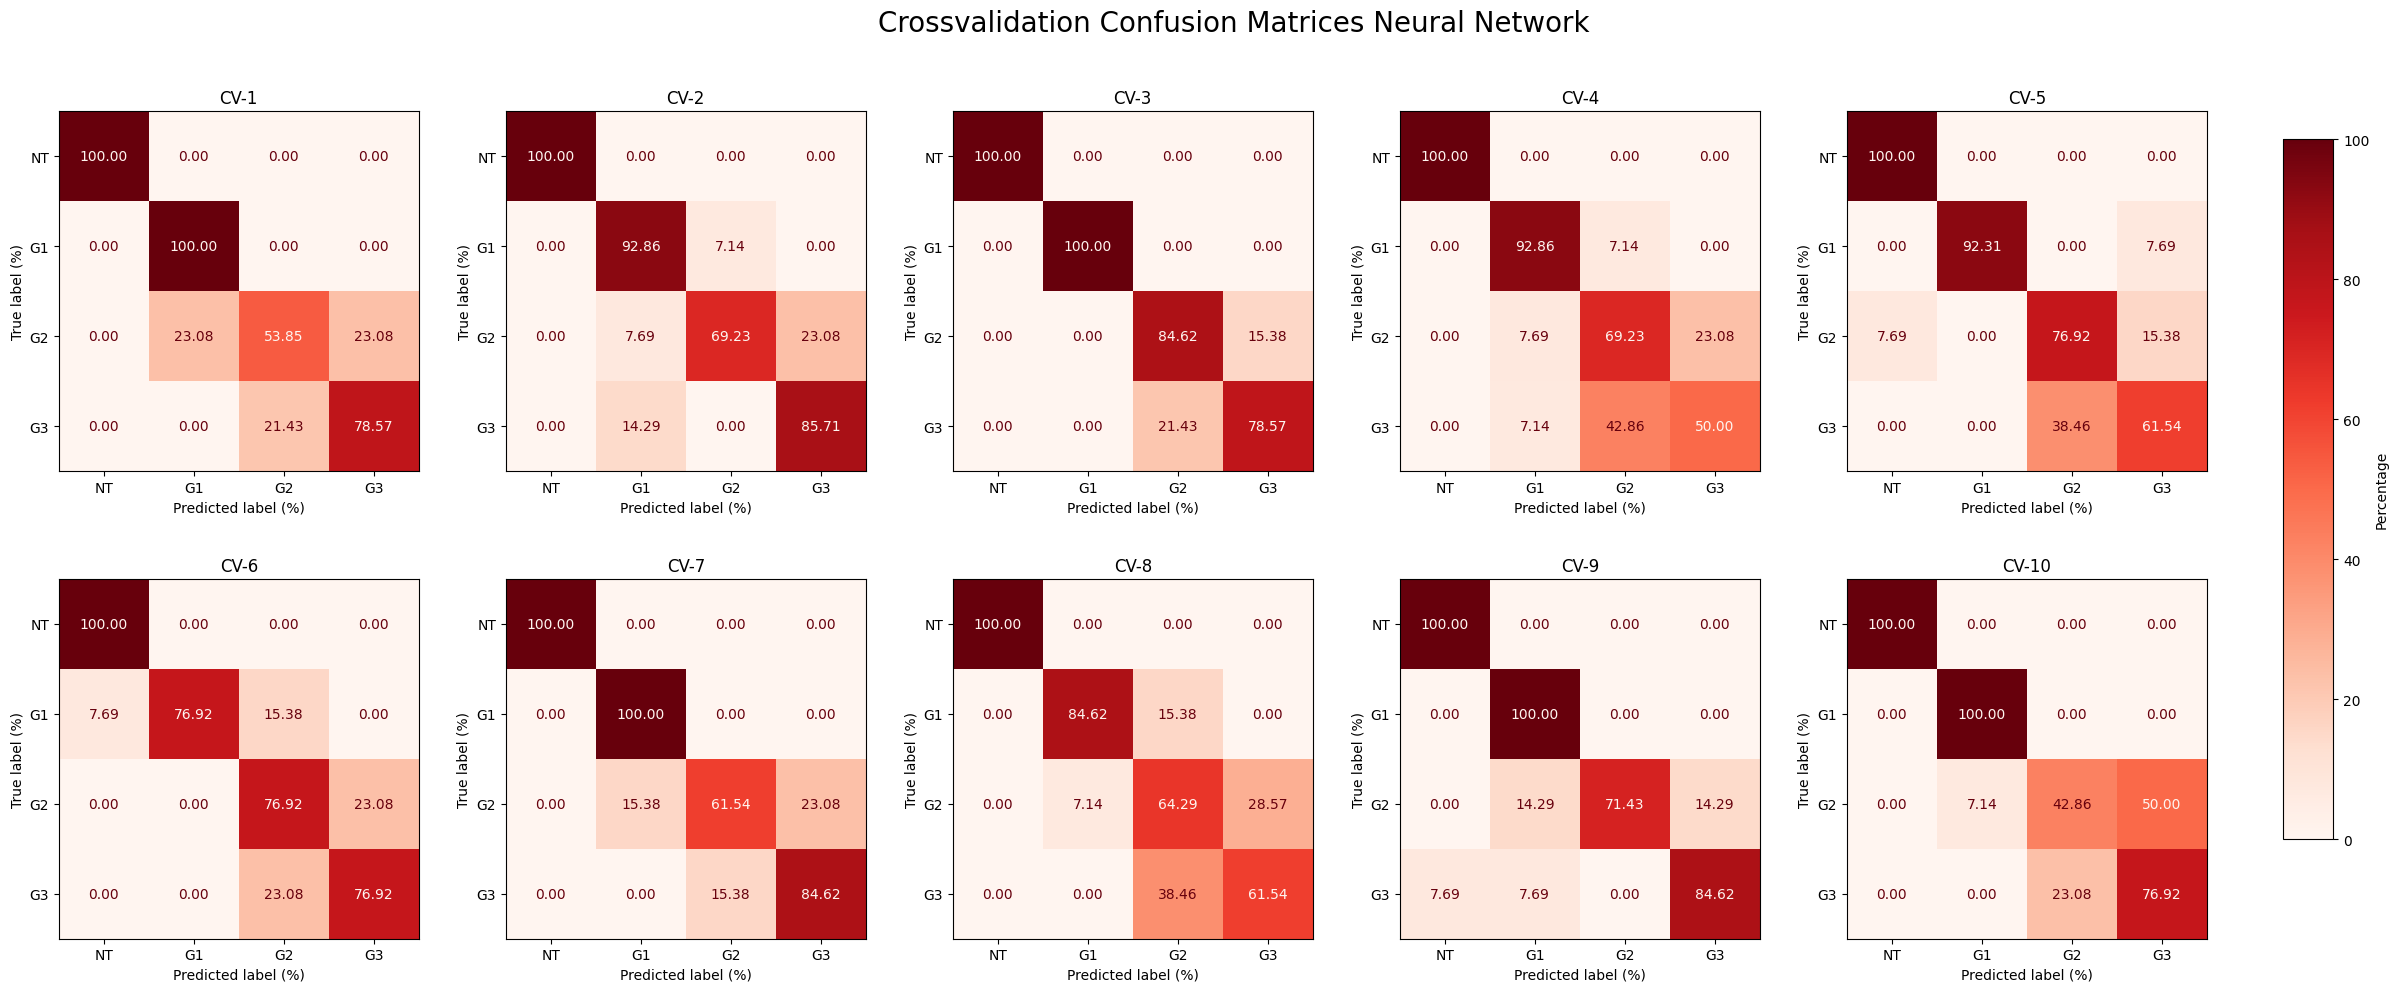

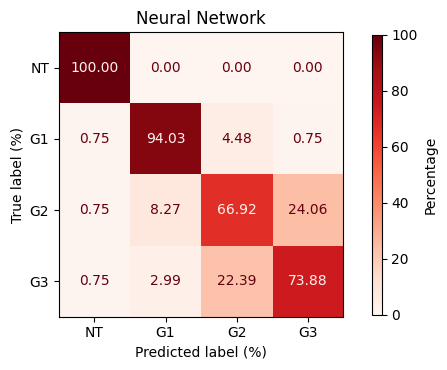

Cross-Validation Results Neural Network:
Accuracy: ['83.33', '87.04', '90.74', '77.78', '83.02', '83.02', '86.79', '77.36', '88.68', '79.25']
Precision: ['82.65', '87.55', '90.85', '78.23', '83.37', '84.40', '86.57', '78.22', '89.88', '79.34']
Recall: ['83.33', '87.04', '90.74', '77.78', '83.02', '83.02', '86.79', '77.36', '88.68', '79.25']
F1: ['82.52', '86.84', '90.74', '77.38', '82.92', '83.22', '86.24', '77.66', '88.38', '78.28']
AUC: ['96.66', '93.82', '97.70', '94.96', '93.89', '94.57', '96.59', '93.41', '97.06', '95.27']

Average Metrics CV Neural Network:
Accuracy: 83.70 +- 4.37
Precision: 84.11 +- 4.37
Recall: 83.70 +- 4.37
F1: 83.42 +- 4.42
AUC: 95.39 +- 1.44

True positive CV Neural Network:
NT: 100.00 ± 0.00
G1: 93.96 ± 7.52
G2: 67.09 ± 11.53
G3: 73.90 ± 11.44


In [ ]:
feature_importances_nn = crossvalidation_shap_nn(create_model, 'Neural Network',X_train_valid_scaled, y_train_valid, X_df)

In [ ]:
feature_importances_nn.to_csv('features_importances_nn.txt', sep=' ', index=True, header=True)
feature_importances_nn

,NT,G1,G2,G3,sum
NEDD1,0.000673,0.001169,0.010519,0.007394,0.019755
NUMA1,0.000671,0.000796,0.006674,0.007074,0.015215
E2F6,0.000658,0.001556,0.008849,0.004000,0.015063
KCNQ1,0.000470,0.000799,0.005393,0.007230,0.013892
ATPGD1,0.000694,0.001274,0.006332,0.003381,0.011682
...,...,...,...,...,...
FLOT1,0.000297,0.000479,0.000506,0.000418,0.001699
BMPR1A,0.000406,0.000432,0.000432,0.000417,0.001687
ZNF295,0.000427,0.000341,0.000175,0.000709,0.001652
GAS2L1,0.000476,0.000340,0.000422,0.000397,0.001635


# NN G2 G3 Shap

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')


def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    print('history')
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)
    print('ypredprob')
    y_pred_prob = model.predict(X_test)
    print('ypred')
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy = np.mean(y_pred == y_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation_shap_nn_binary(classifier_func, model_title, X, y, df, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    #y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    shap_values_list = []
    idx = 0
    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        idx += 1
        print(f'\nfold-{idx}')
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        print('model')
        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        print('calc metrics')
        accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)
        print('after calc')
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        # Calculate SHAP values
        print('summary')
        summarized_X_train = shap.kmeans(X_train, 50)
        print('explainer....')
        explainer = shap.KernelExplainer(model.predict, summarized_X_train)
        print('extract shap values....')
        shap_values = explainer.shap_values(X_test, nsamples=500)
        print('shap.KernelExplainer')

        # Calculate mean absolute SHAP values for each class
        mean_0 = np.mean(np.abs(shap_values[:,:,0]), axis=0)
        mean_1 = np.mean(np.abs(shap_values[:,:,1]), axis=0)

        # Create a DataFrame for the current fold
        df_fold = pd.DataFrame({'G2': mean_0, 'Class 1': G3})

        # Store SHAP values DataFrame for this fold
        shap_values_list.append(df_fold)
        print('\n==================================================')

        for label in range(num_classes):
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')


    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(num_classes)}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

    avg_shap = pd.concat(shap_values_list).groupby(level=0).mean()
    avg_shap.index = df.columns
    avg_shap['sum'] = avg_shap.sum(axis=1)
    avg_shap = avg_shap.sort_values(by='sum', ascending=False)
    # Print the averaged SHAP values
    return avg_shap

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()




AxisError: axis 1 is out of bounds for array of dimension 1

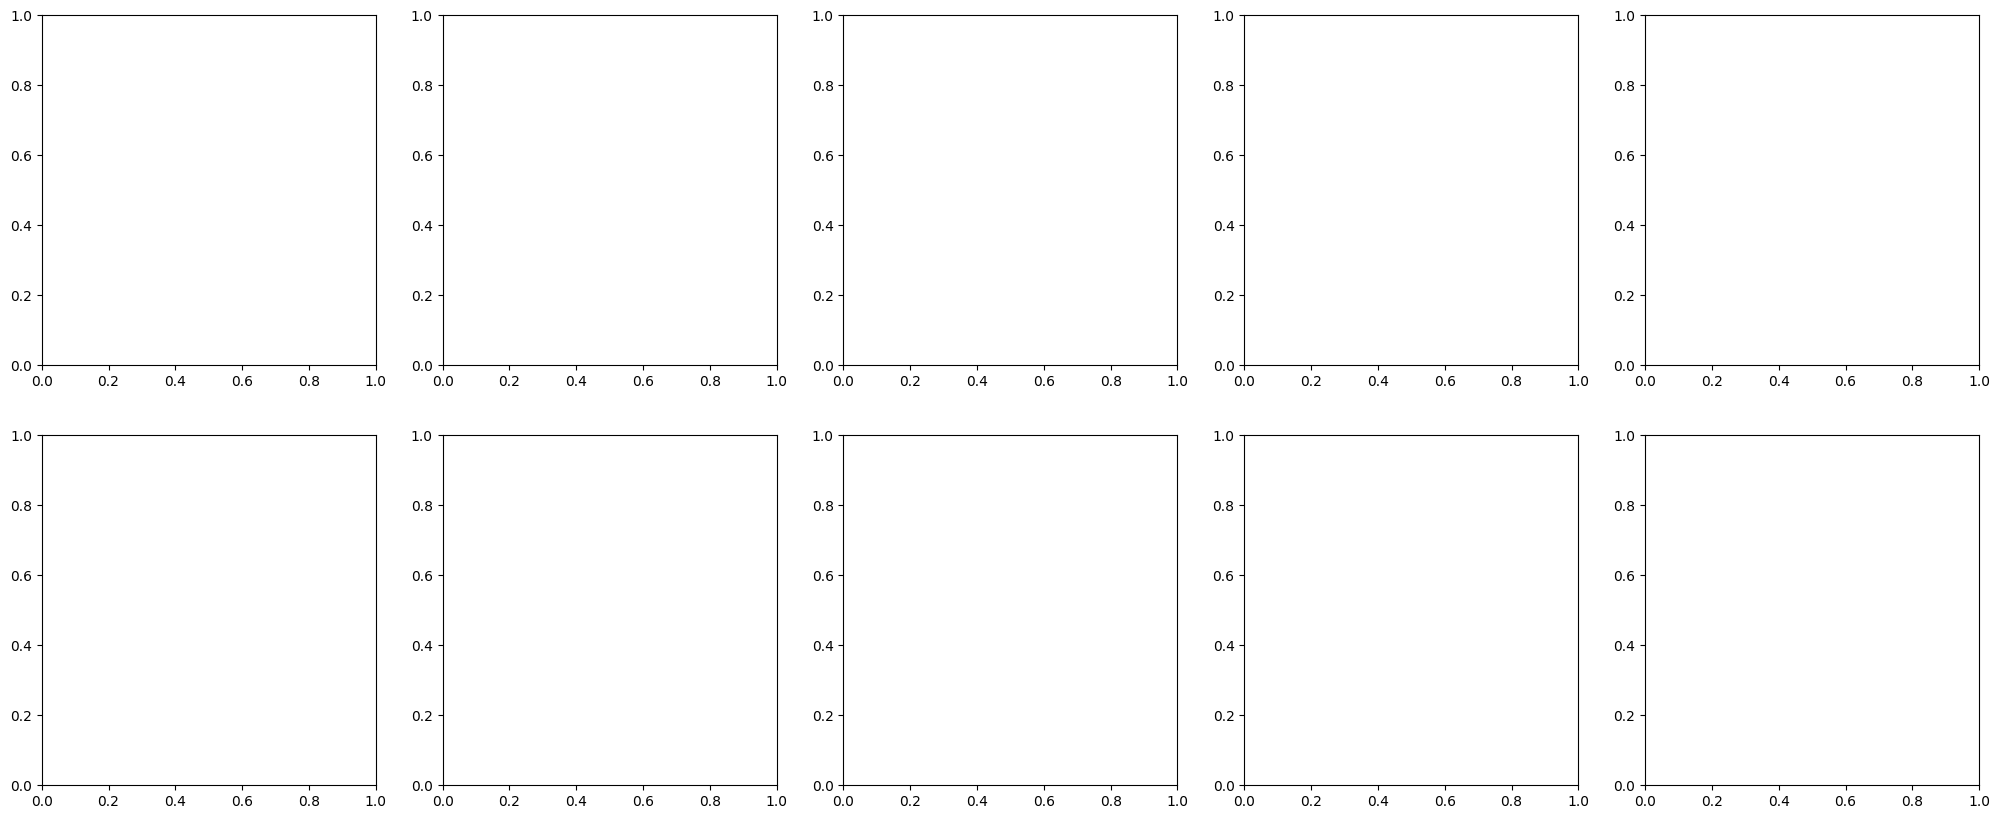

In [ ]:
feature_importances_nng2g3 = crossvalidation_shap_nn_binary(create_model, 'Neural Network',X_train_valid_scaled0, y_train_valid0, X_df)
feature_importances_nng2g3.to_csv('features_importances_nng2g3.txt', sep=' ', index=True, header=True)
feature_importances_nng2g3

<br>

# top 100 features evaluation

In [ ]:
#1. read 4 txt
#2. filtered 100
#3. evaluate crosvalidation for each model
#4. join all features for all model
import pandas as pd

feat_psvm = pd.read_csv('features_importances_kernelSVM.txt', delimiter=' ', index_col=0)
feat_lsvm = pd.read_csv('features_importances_linearSVM.txt', delimiter=' ', index_col=0)
feat_nn = pd.read_csv('features_importances_nn.txt', delimiter=' ', index_col=0)
feat_rf = pd.read_csv('features_importances_RF.txt', delimiter=' ', index_col=0)
feat_logis = pd.read_csv('features_importances_logisg2g3.txt', delimiter=' ', index_col=0)
feat_psvmg2g3 = pd.read_csv('features_importances_psvmg2g3.txt', delimiter=' ', index_col=0)
features_lsvm_g2g3 = pd.read_csv('features_importances_lsvmg2g3.txt', delimiter=' ', index_col=0)

In [ ]:
feat_nn['sum_G2_G3'] = feat_nn['G2'] + feat_nn['G3']
feat_nn = feat_nn.sort_values(by='sum_G2_G3', ascending=False)

In [ ]:
feat_rf['sum_G2_G3'] = feat_rf['G2'] + feat_rf['G3']
feat_rf = feat_rf.sort_values(by='sum_G2_G3', ascending=False)

In [ ]:
feat_psvm

,NT,G1,G2,G3,sum
KCNQ1,0.000510,0.001553,0.005397,0.005586,0.013046
CDKL2,0.000547,0.000598,0.006621,0.004143,0.011909
RAB22A,0.000257,0.003362,0.004426,0.001139,0.009185
E2F6,0.000478,0.000795,0.005097,0.002772,0.009141
PIGB,0.000619,0.002668,0.000966,0.004667,0.008920
...,...,...,...,...,...
ATP1B3,0.000141,0.000277,0.000259,0.000357,0.001035
NEK5,0.000286,0.000138,0.000295,0.000315,0.001033
BHLHE40,0.000308,0.000099,0.000321,0.000290,0.001018
SRP54,0.000167,0.000313,0.000280,0.000256,0.001016


In [ ]:
feat_lsvm

,NT,G1,G2,G3,sum
KCNQ1,0.000712,0.001990,0.006623,0.005254,0.014578
S100A2,0.001023,0.001253,0.001422,0.006740,0.010438
COLEC11,0.000394,0.001334,0.004883,0.003047,0.009658
RAB22A,0.000371,0.002691,0.005029,0.001513,0.009604
CDKL2,0.000463,0.000668,0.005226,0.003091,0.009448
...,...,...,...,...,...
CMTM6,0.000384,0.000215,0.000201,0.000267,0.001067
URB2,0.000253,0.000246,0.000205,0.000337,0.001042
ENSA,0.000394,0.000240,0.000169,0.000232,0.001034
RECQL4,0.000193,0.000153,0.000296,0.000356,0.000999


In [ ]:
feat_nn

,NT,G1,G2,G3,sum
NEDD1,0.000673,0.001169,0.010519,0.007394,0.019755
NUMA1,0.000671,0.000796,0.006674,0.007074,0.015215
E2F6,0.000658,0.001556,0.008849,0.004000,0.015063
KCNQ1,0.000470,0.000799,0.005393,0.007230,0.013892
ATPGD1,0.000694,0.001274,0.006332,0.003381,0.011682
...,...,...,...,...,...
FLOT1,0.000297,0.000479,0.000506,0.000418,0.001699
BMPR1A,0.000406,0.000432,0.000432,0.000417,0.001687
ZNF295,0.000427,0.000341,0.000175,0.000709,0.001652
GAS2L1,0.000476,0.000340,0.000422,0.000397,0.001635


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
# y_df should have a column named 'label'
# X_df should have the feature columns
y_df = pd.DataFrame({'label': ['A', 'A', 'B', 'B', 'C', 'C']})
X_df = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5, 6],
    'feature2': [2, 3, 4, 5, 6, 7],
    'feature3': [3, 4, 5, 6, 7, 8]
})

# Combine y_df and X_df
combined_df = pd.concat([y_df, X_df], axis=1)

# Melt the DataFrame for easier processing
melted_df = combined_df.melt(id_vars=['label'], var_name='feature', value_name='value')

# Calculate mean and standard deviation
summary_df = melted_df.groupby(['label', 'feature']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Create the bar plot
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(x='feature', y='mean', hue='label', data=summary_df, ci=None)

# Add error bars
for i in range(len(summary_df)):
    row = summary_df.iloc[i]
    bar_plot.errorbar(x=i // summary_df['feature'].nunique(),
                      y=row['mean'],
                      yerr=row['std'],
                      fmt='none',
                      c='black',
                      capsize=5)

# Add labels and title
plt.title('Mean and Standard Deviation of Features by Label')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Label')

plt.tight_layout()
plt.show()


In [ ]:
feat_rf

,NT,G1,G2,G3,sum
ADIPOR1,0.016250,0.005199,0.005045,0.006036,0.032530
KIAA0664,0.012234,0.002325,0.005132,0.005705,0.025396
RGS12,0.008552,0.004458,0.005704,0.004403,0.023117
C2orf79,0.009525,0.002631,0.005164,0.004356,0.021676
HOXA10,0.009152,0.001645,0.004299,0.003928,0.019023
...,...,...,...,...,...
VAMP4,0.000063,0.000113,0.000114,0.000115,0.000404
CXCL16,0.000030,0.000109,0.000136,0.000122,0.000396
HRAS,0.000028,0.000112,0.000152,0.000103,0.000396
KIAA0467,0.000035,0.000113,0.000123,0.000109,0.000379


In [ ]:
def select_features(features_score, X_df, X_scaled, top=100):
    #features_score = features_score.sort_values(by='G1', ascending=False)

    # Select the top 'top' features based on the index of features_score
    top_features = features_score.index[:top]
    print(top_features)

    # Map the top features to their column indices in X_df
    index_mapped = [X_df.columns.get_loc(feature) for feature in top_features]

    # Filter the columns in X_scaled based on the mapped indices
    top100_X = X_scaled[:, index_mapped]

    return top100_X, top_features

## features with NT

Index(['KCNQ1', 'S100A2', 'COLEC11', 'RAB22A', 'CDKL2', 'PIGB', 'E2F6', 'PLD1',
       'PAPLN', 'SERPINE2',
       ...
       'RNF215', 'CBY3', 'TRIM61', 'VASH2', 'JDP2', 'C6orf48', 'HRAS', 'TCL6',
       'B4GALT5', 'HIST2H2BF'],
      dtype='object', length=350)


<ipython-input-42-02c9bb5b3541>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-02c9bb5b3541>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


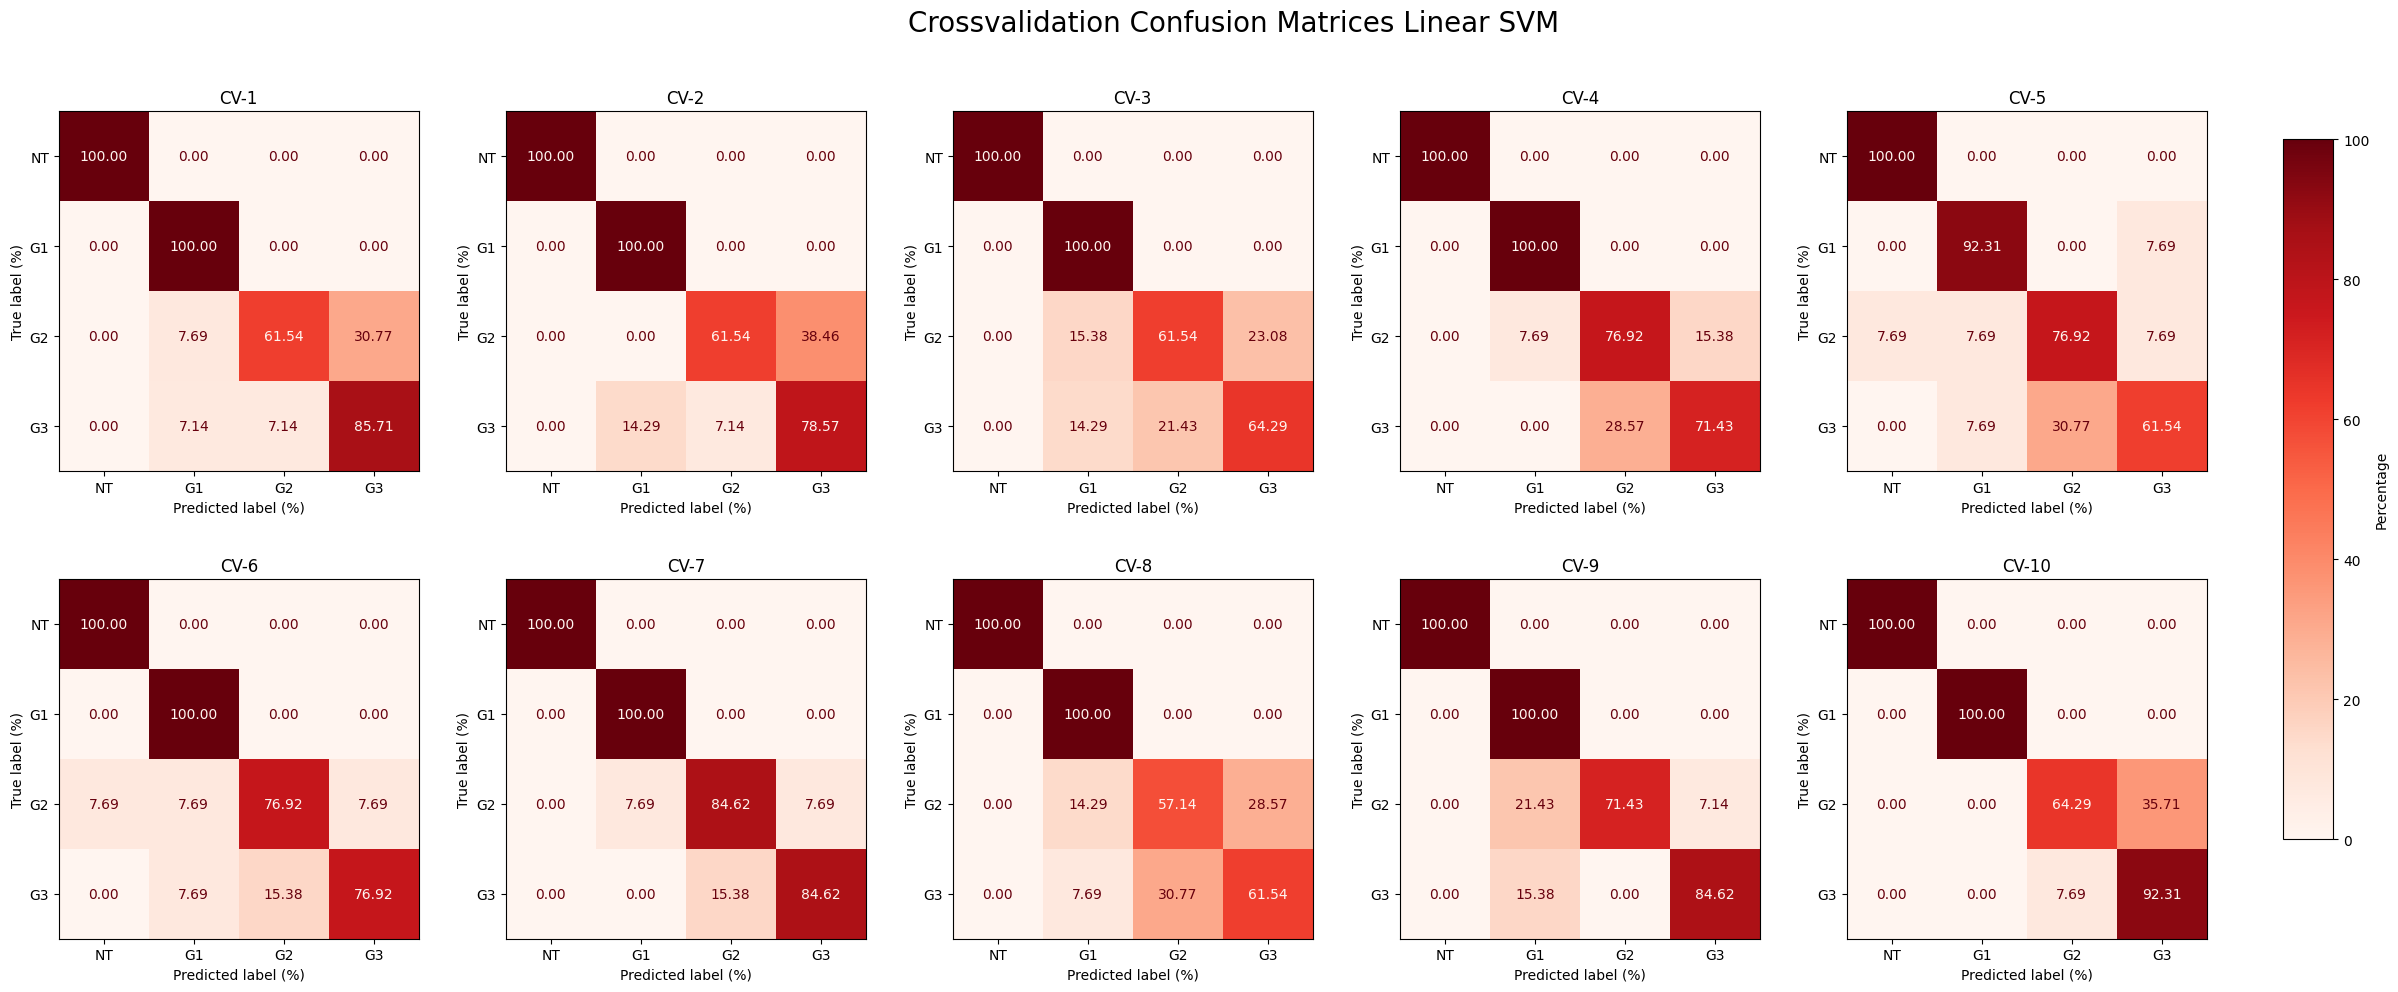

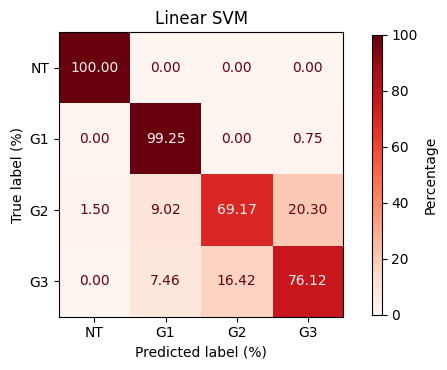

Cross-Validation Results Linear SVM:
Accuracy: ['87.04', '85.19', '81.48', '87.04', '83.02', '88.68', '92.45', '79.25', '88.68', '88.68']
Precision: ['87.60', '85.98', '81.19', '87.07', '82.82', '88.65', '92.43', '78.42', '91.14', '90.14']
Recall: ['87.04', '85.19', '81.48', '87.04', '83.02', '88.68', '92.45', '79.25', '88.68', '88.68']
F1: ['86.52', '84.79', '80.76', '86.88', '82.54', '88.34', '92.37', '78.47', '88.70', '88.49']
AUC: ['97.81', '95.24', '96.70', '97.26', '94.86', '99.23', '97.69', '96.62', '95.64', '98.83']

Average Metrics CV Linear SVM:
Accuracy: 86.15 +- 3.75
Precision: 86.55 +- 4.28
Recall: 86.15 +- 3.75
F1: 85.79 +- 3.97
AUC: 96.99 +- 1.39

Sensitivity (Recall) CV Linear SVM:
NT: 100.00 ± 0.00
G1: 99.23 ± 2.31
G2: 69.29 ± 8.76
G3: 76.15 ± 10.45

Specificity CV Linear SVM:
NT: 99.49 ± 1.03
G1: 94.50 ± 3.50
G2: 94.52 ± 3.50
G3: 93.00 ± 3.84

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 99.23 ± 2.31
G2: 69.29 ± 8.76
G3: 76.15 ± 10.45


In [ ]:
X_lsvm100, features100_lsvm = select_features_cv(feat_lsvm, X_df, X_train_valid_scaled,top=350)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid)


Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD94', 'LRRN1', 'HIST2H2BA', 'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1',
       'DEGS1', 'ARAP1', 'SPRY4'],
      dtype='object', length=247)


<ipython-input-42-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-42-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


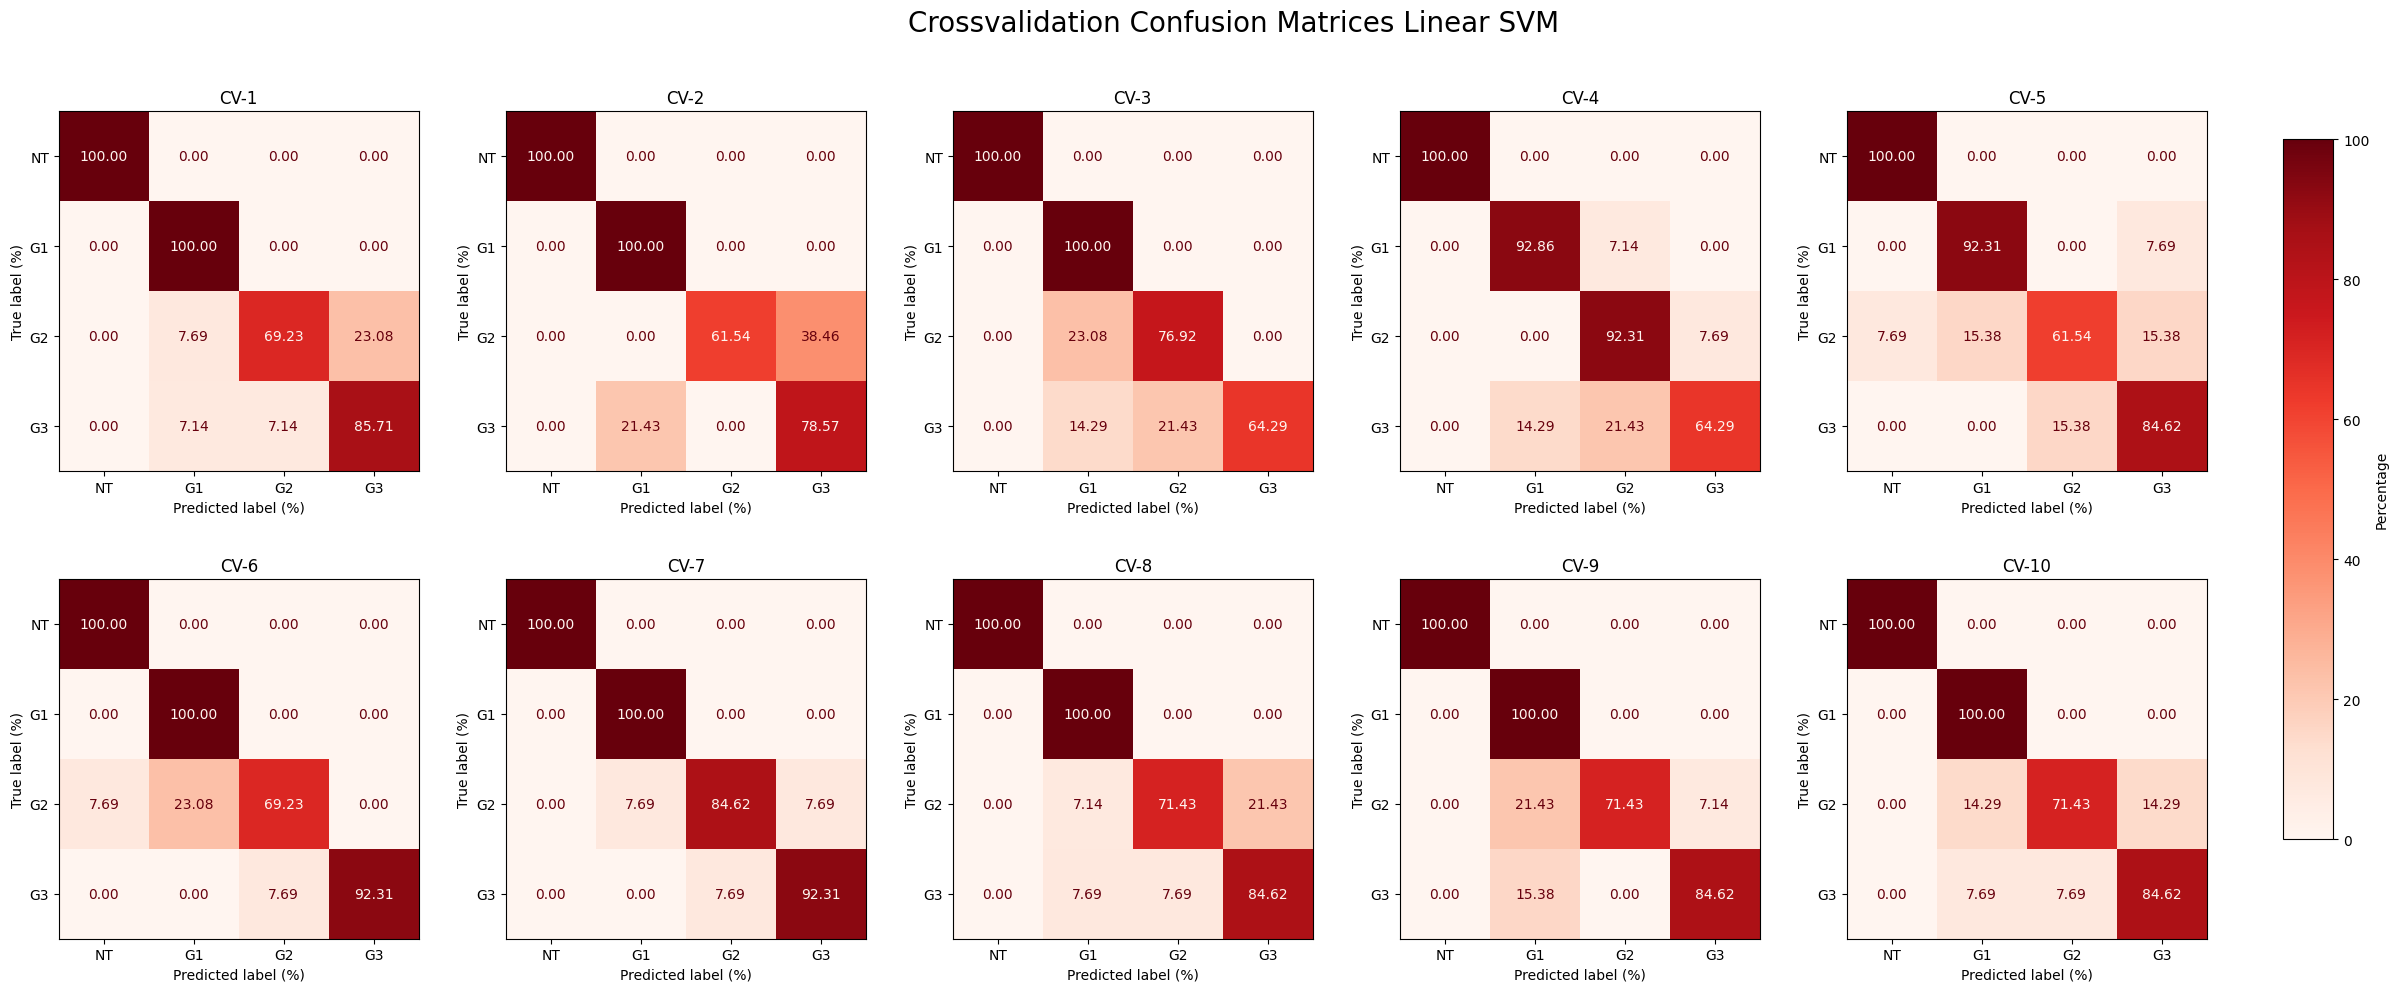

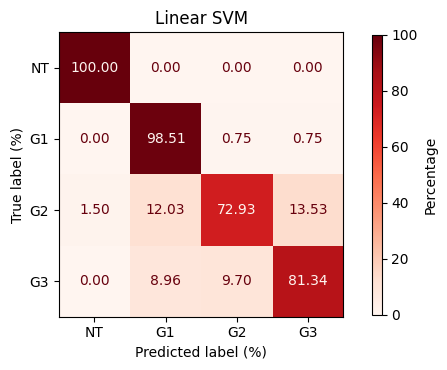

Cross-Validation Results Linear SVM:
Accuracy: ['88.89', '85.19', '85.19', '87.04', '84.91', '90.57', '94.34', '88.68', '88.68', '88.68']
Precision: ['89.17', '87.32', '87.62', '87.93', '84.57', '91.19', '94.32', '89.07', '91.14', '89.23']
Recall: ['88.89', '85.19', '85.19', '87.04', '84.91', '90.57', '94.34', '88.68', '88.68', '88.68']
F1: ['88.57', '84.85', '84.88', '86.69', '84.36', '90.24', '94.26', '88.42', '88.70', '88.41']
AUC: ['95.88', '95.30', '96.82', '97.72', '94.13', '97.50', '98.17', '97.66', '93.06', '98.41']

Average Metrics CV Linear SVM:
Accuracy: 88.21 +- 2.74
Precision: 89.16 +- 2.51
Recall: 88.21 +- 2.74
F1: 87.94 +- 2.83
AUC: 96.47 +- 1.72

Sensitivity (Recall) CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 72.97 ± 9.06
G3: 81.59 ± 9.44

Specificity CV Linear SVM:
NT: 99.49 ± 1.03
G1: 93.00 ± 3.12
G2: 96.54 ± 2.92
G3: 95.25 ± 3.78

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 72.97 ± 9.06
G3: 81.59 ± 9.44


In [ ]:
X_lsvm100, features100_lsvm = select_features_cv(features_lsvm_g2g3, X_df, X_train_valid_scaled,top=247)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid)

Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD94', 'LRRN1', 'HIST2H2BA', 'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1',
       'DEGS1', 'ARAP1', 'SPRY4'],
      dtype='object', length=247)


<ipython-input-34-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-34-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


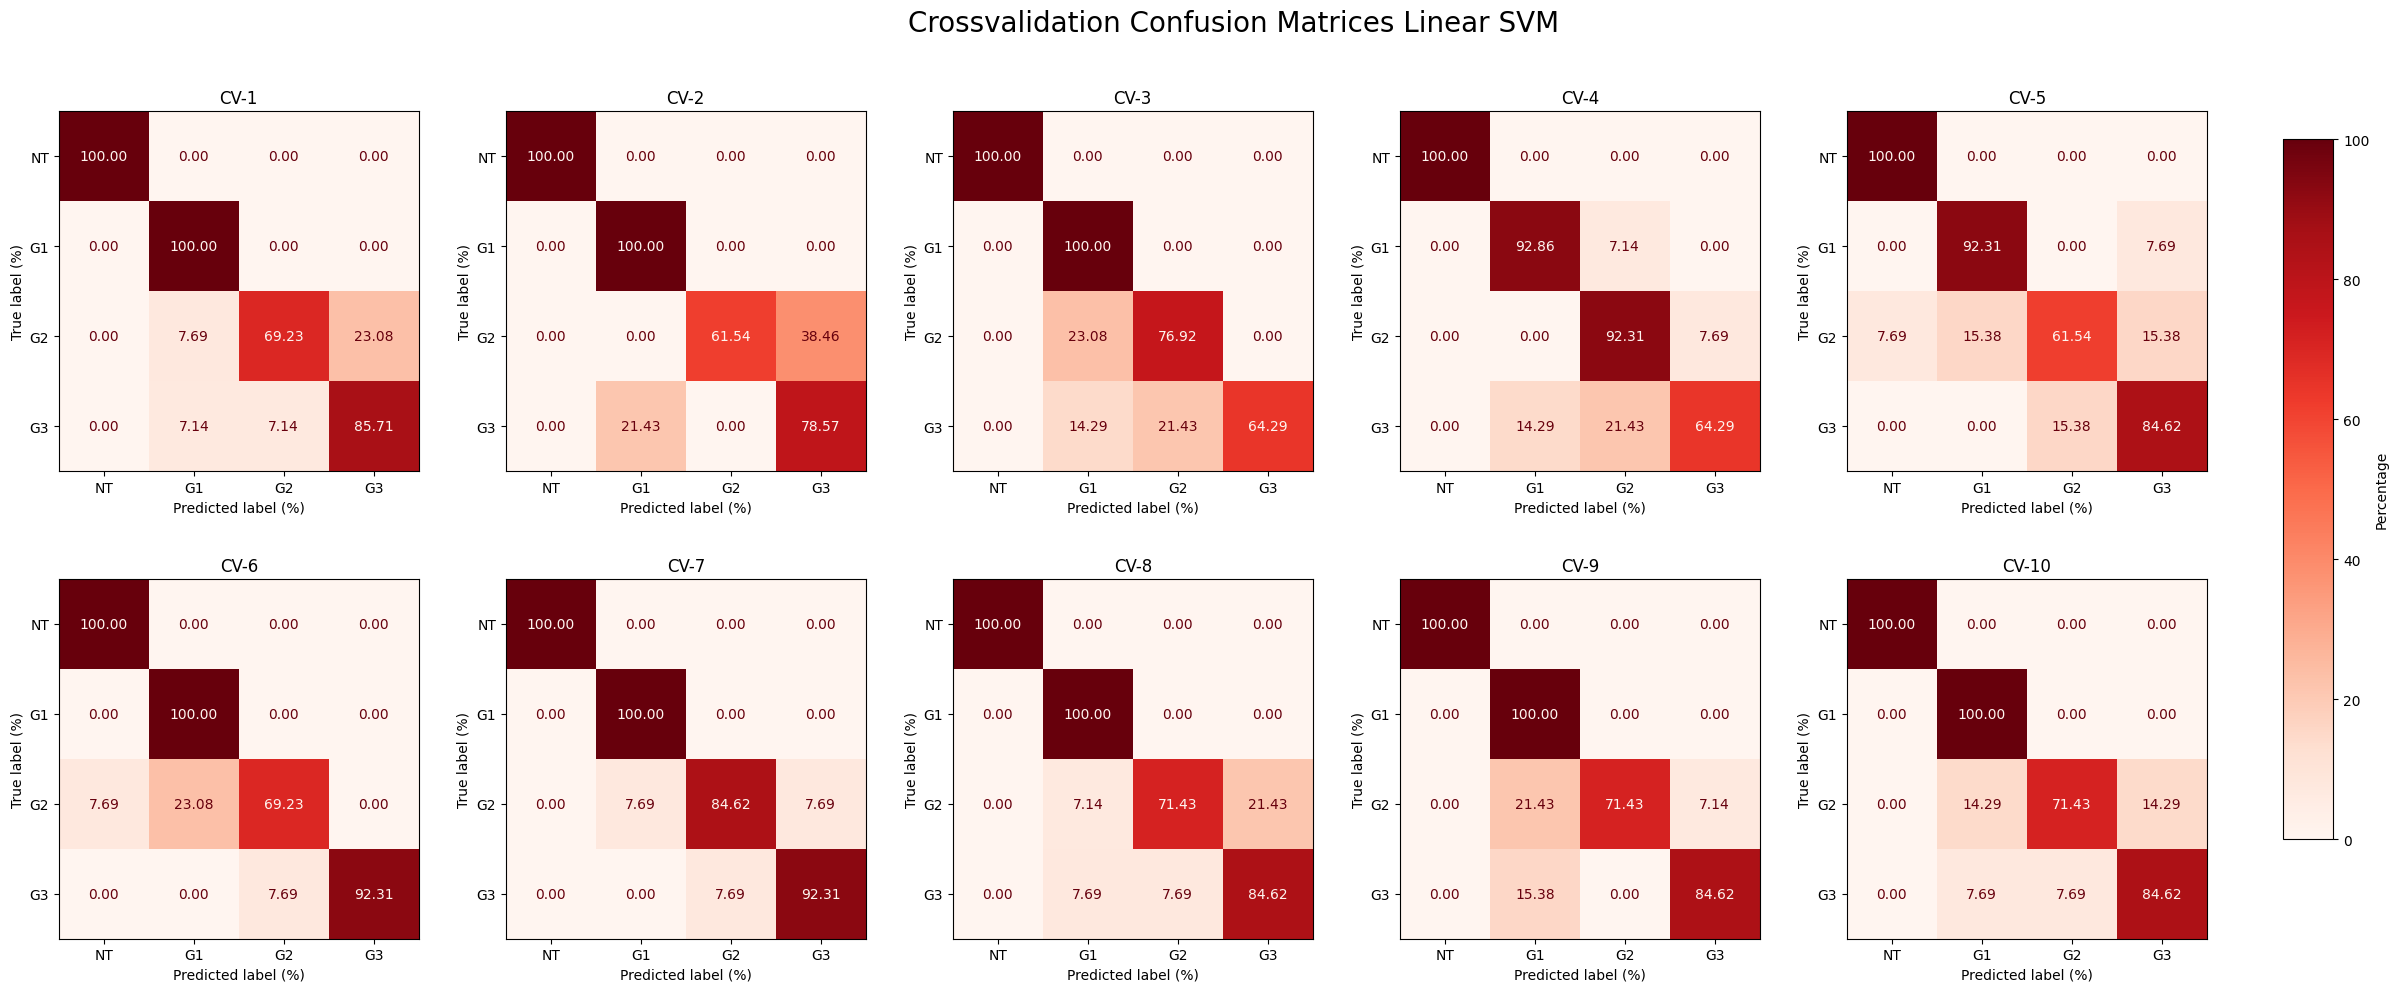

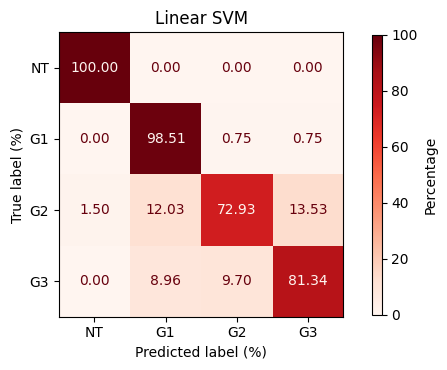

Cross-Validation Results Linear SVM:
Accuracy: ['88.89', '85.19', '85.19', '87.04', '84.91', '90.57', '94.34', '88.68', '88.68', '88.68']
Precision: ['89.17', '87.32', '87.62', '87.93', '84.57', '91.19', '94.32', '89.07', '91.14', '89.23']
Recall: ['88.89', '85.19', '85.19', '87.04', '84.91', '90.57', '94.34', '88.68', '88.68', '88.68']
F1: ['88.57', '84.85', '84.88', '86.69', '84.36', '90.24', '94.26', '88.42', '88.70', '88.41']
AUC: ['95.88', '95.30', '96.82', '97.72', '94.13', '97.50', '98.17', '97.66', '93.06', '98.41']

Average Metrics CV Linear SVM:
Accuracy: 88.21 +- 2.74
Precision: 89.16 +- 2.51
Recall: 88.21 +- 2.74
F1: 87.94 +- 2.83
AUC: 96.47 +- 1.72

Sensitivity (Recall) CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 72.97 ± 9.06
G3: 81.59 ± 9.44

Specificity CV Linear SVM:
NT: 99.49 ± 1.03
G1: 93.00 ± 3.12
G2: 96.54 ± 2.92
G3: 95.25 ± 3.78

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 98.52 ± 2.97
G2: 72.97 ± 9.06
G3: 81.59 ± 9.44


In [ ]:
X_lsvm100, features100_lsvm = select_features_cv(features_lsvm_g2g3, X_df, X_train_valid_scaled,top=247)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid)

Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1', 'DEGS1', 'ARAP1', 'SPRY4',
       'TBXAS1', 'C20orf30', 'VASH2'],
      dtype='object', length=250)


<ipython-input-122-57c95bf53aab>:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-122-57c95bf53aab>:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


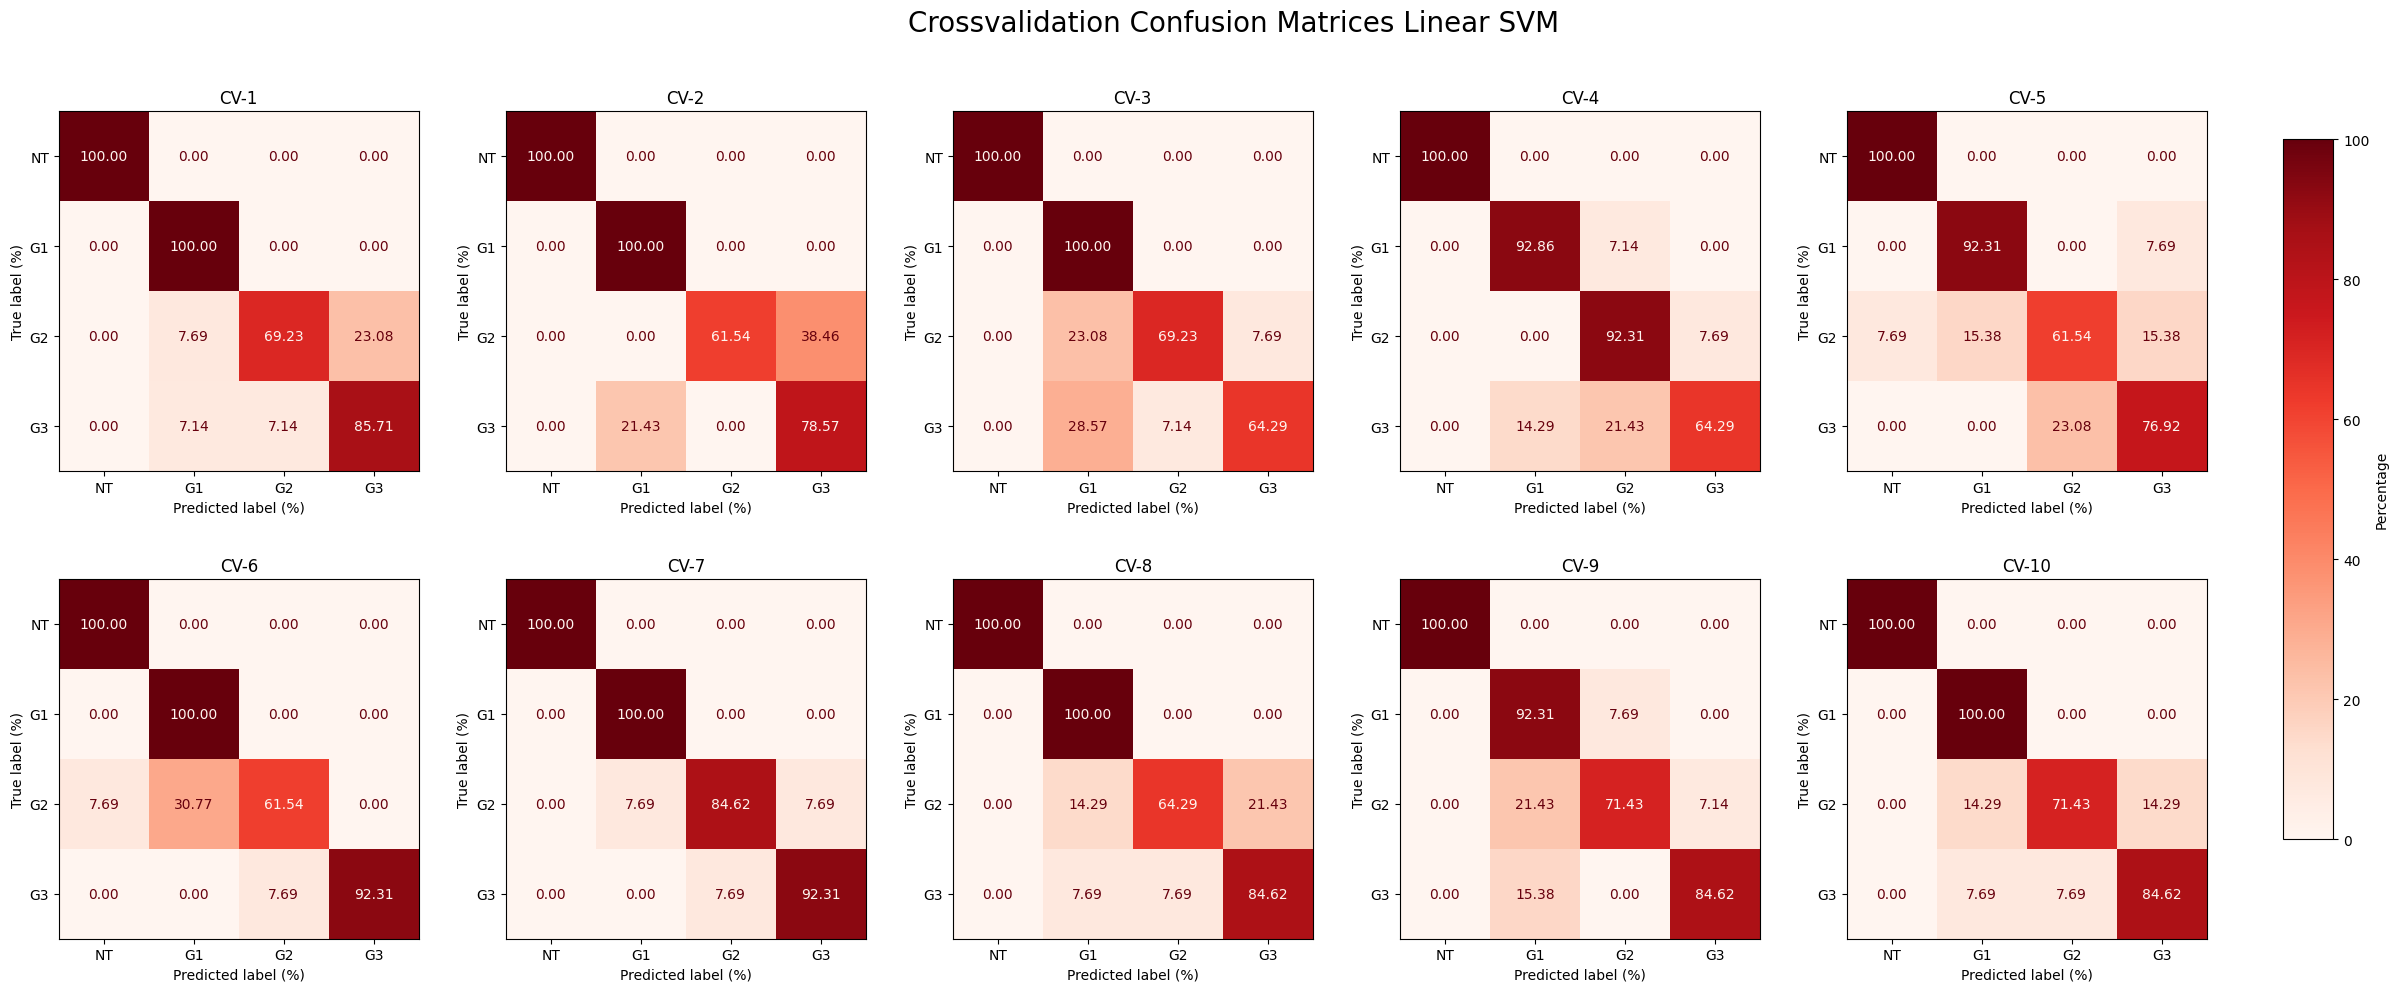

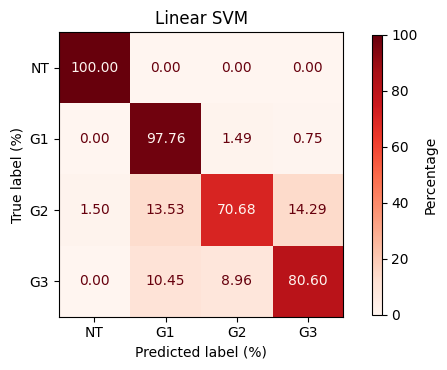

Cross-Validation Results Linear SVM:
Accuracy: ['88.89', '85.19', '83.33', '87.04', '83.02', '88.68', '94.34', '86.79', '86.79', '88.68']
Precision: ['89.17', '87.32', '86.36', '87.93', '82.39', '89.74', '94.32', '87.50', '88.34', '89.23']
Recall: ['88.89', '85.19', '83.33', '87.04', '83.02', '88.68', '94.34', '86.79', '86.79', '88.68']
F1: ['88.57', '84.85', '83.10', '86.69', '82.53', '88.15', '94.26', '86.32', '86.87', '88.41']
AUC: ['95.84', '95.56', '96.60', '97.35', '94.13', '97.60', '98.08', '97.99', '92.87', '98.55']

Average Metrics CV Linear SVM:
Accuracy: 87.27 +- 3.08
Precision: 88.23 +- 2.83
Recall: 87.27 +- 3.08
F1: 86.97 +- 3.15
AUC: 96.46 +- 1.76

True positive CV Linear SVM:
NT: 100.00 ± 0.00
G1: 97.75 ± 3.44
G2: 70.71 ± 9.79
G3: 80.82 ± 9.48


In [ ]:
X_lsvm100, features100_lsvm = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled,top=250)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid)

Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181', 'CCDC144NL',
       'HDAC2', 'E2F2', 'PTBP2'],
      dtype='object', length=370)


<ipython-input-34-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-34-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


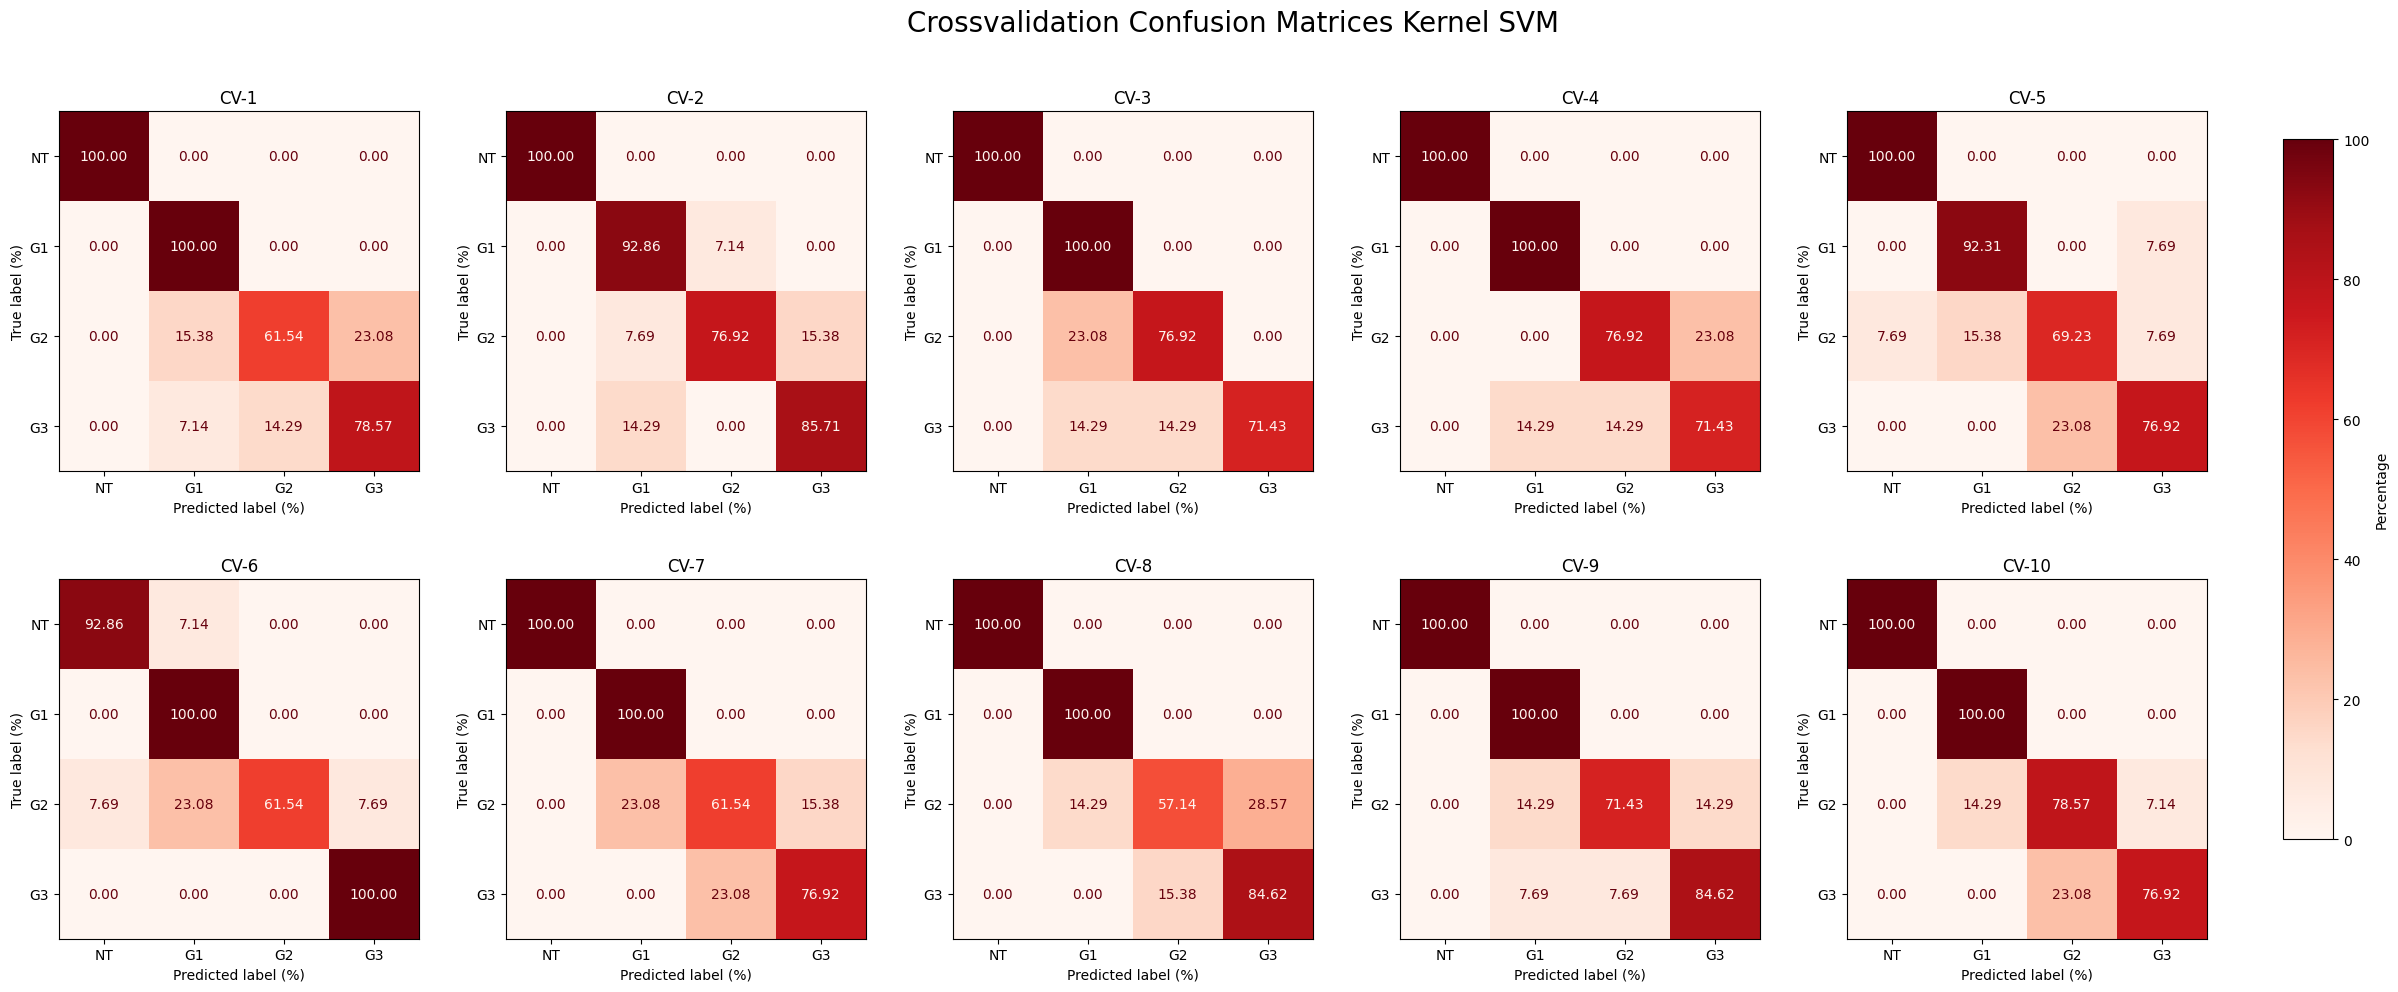

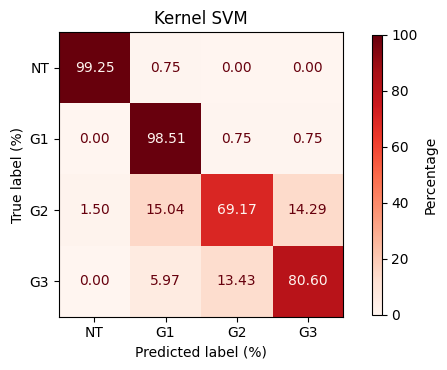

Cross-Validation Results Kernel SVM:
Accuracy: ['85.19', '88.89', '87.04', '87.04', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
Precision: ['85.05', '89.25', '89.17', '86.76', '84.51', '90.59', '84.62', '84.91', '89.23', '88.84']
Recall: ['85.19', '88.89', '87.04', '87.04', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
F1: ['84.61', '88.83', '86.94', '86.74', '84.59', '88.09', '84.38', '84.19', '88.41', '88.50']
AUC: ['97.84', '95.78', '98.52', '95.89', '94.28', '98.22', '96.68', '97.06', '94.28', '98.04']

Average Metrics CV Kernel SVM:
Accuracy: 86.89 +- 1.68
Precision: 87.29 +- 2.24
Recall: 86.89 +- 1.68
F1: 86.53 +- 1.81
AUC: 96.66 +- 1.48

Sensitivity (Recall) CV Kernel SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.18 ± 7.70
G3: 80.71 ± 8.05

Specificity CV Kernel SVM:
NT: 99.49 ± 1.03
G1: 92.75 ± 2.36
G2: 95.25 ± 2.38
G3: 95.00 ± 2.74

True positive CV Kernel SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.18 ± 7.70
G3: 80.71 ± 8.05


In [ ]:
X_psvm, features_psvm = select_features_cv(feat_psvmg2g3, X_df, X_train_valid_scaled,top=370)
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
#svm_kernel= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Kernel SVM', X_psvm, y_train_valid)


Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'CDK13', 'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181',
       'CCDC144NL', 'HDAC2', 'E2F2'],
      dtype='object', length=369)


<ipython-input-418-e66405b69885>:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-418-e66405b69885>:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


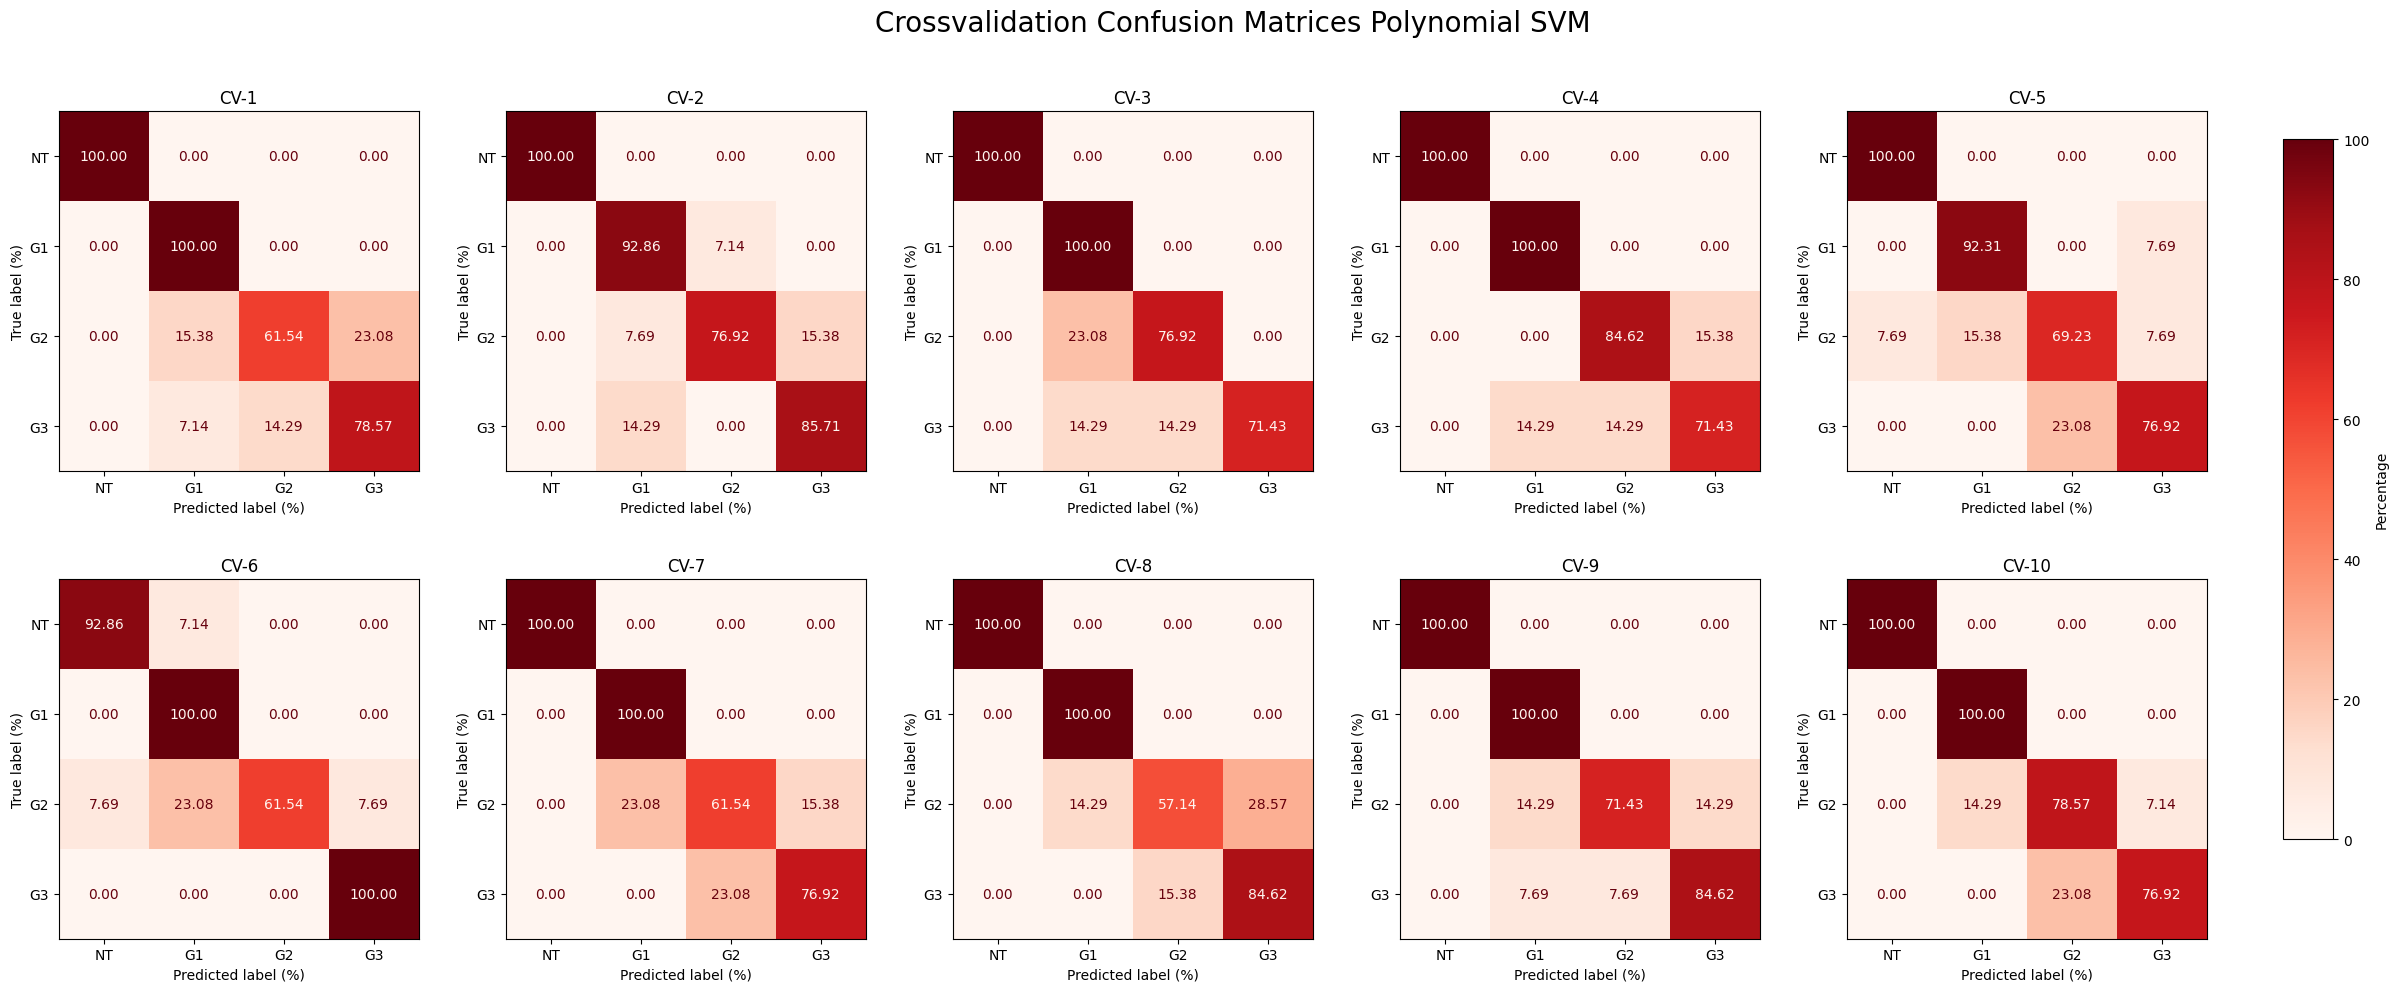

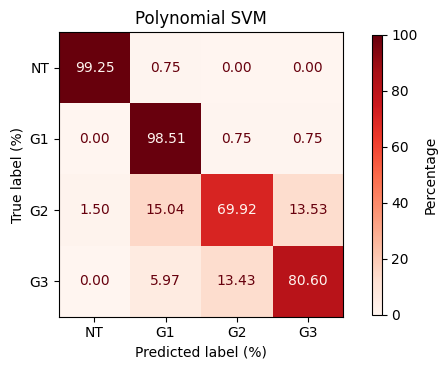

Cross-Validation Results Polynomial SVM:
Accuracy: ['85.19', '88.89', '87.04', '88.89', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
Precision: ['85.05', '89.25', '89.17', '88.73', '84.51', '90.59', '84.62', '84.91', '89.23', '88.84']
Recall: ['85.19', '88.89', '87.04', '88.89', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
F1: ['84.61', '88.83', '86.94', '88.58', '84.59', '88.09', '84.38', '84.19', '88.41', '88.50']
AUC: ['97.84', '95.97', '98.47', '95.84', '94.33', '98.08', '96.63', '96.93', '94.32', '98.04']

Average Metrics CV Polynomial SVM:
Accuracy: 87.08 +- 1.79
Precision: 87.49 +- 2.27
Recall: 87.08 +- 1.79
F1: 86.71 +- 1.92
AUC: 96.64 +- 1.44

Sensitivity (Recall) CV Polynomial SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.95 ± 8.75
G3: 80.71 ± 8.05

Specificity CV Polynomial SVM:
NT: 99.49 ± 1.03
G1: 92.75 ± 2.36
G2: 95.25 ± 2.38
G3: 95.25 ± 2.61

True positive CV Polynomial SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.95 ± 8.75
G3: 80.71 ± 8.05


In [ ]:
X_psvm, features_psvm = select_features_cv(feat_psvmg2g3, X_df, X_train_valid_scaled,top=369)
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
#svm_kernel= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Polynomial SVM', X_psvm, y_train_valid)


Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ADCK5', 'HCG18', 'RNF215', 'FSTL4', 'ZNF696', 'ZNF181', 'CCDC144NL',
       'HDAC2', 'E2F2', 'PTBP2'],
      dtype='object', length=370)


<ipython-input-30-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-30-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


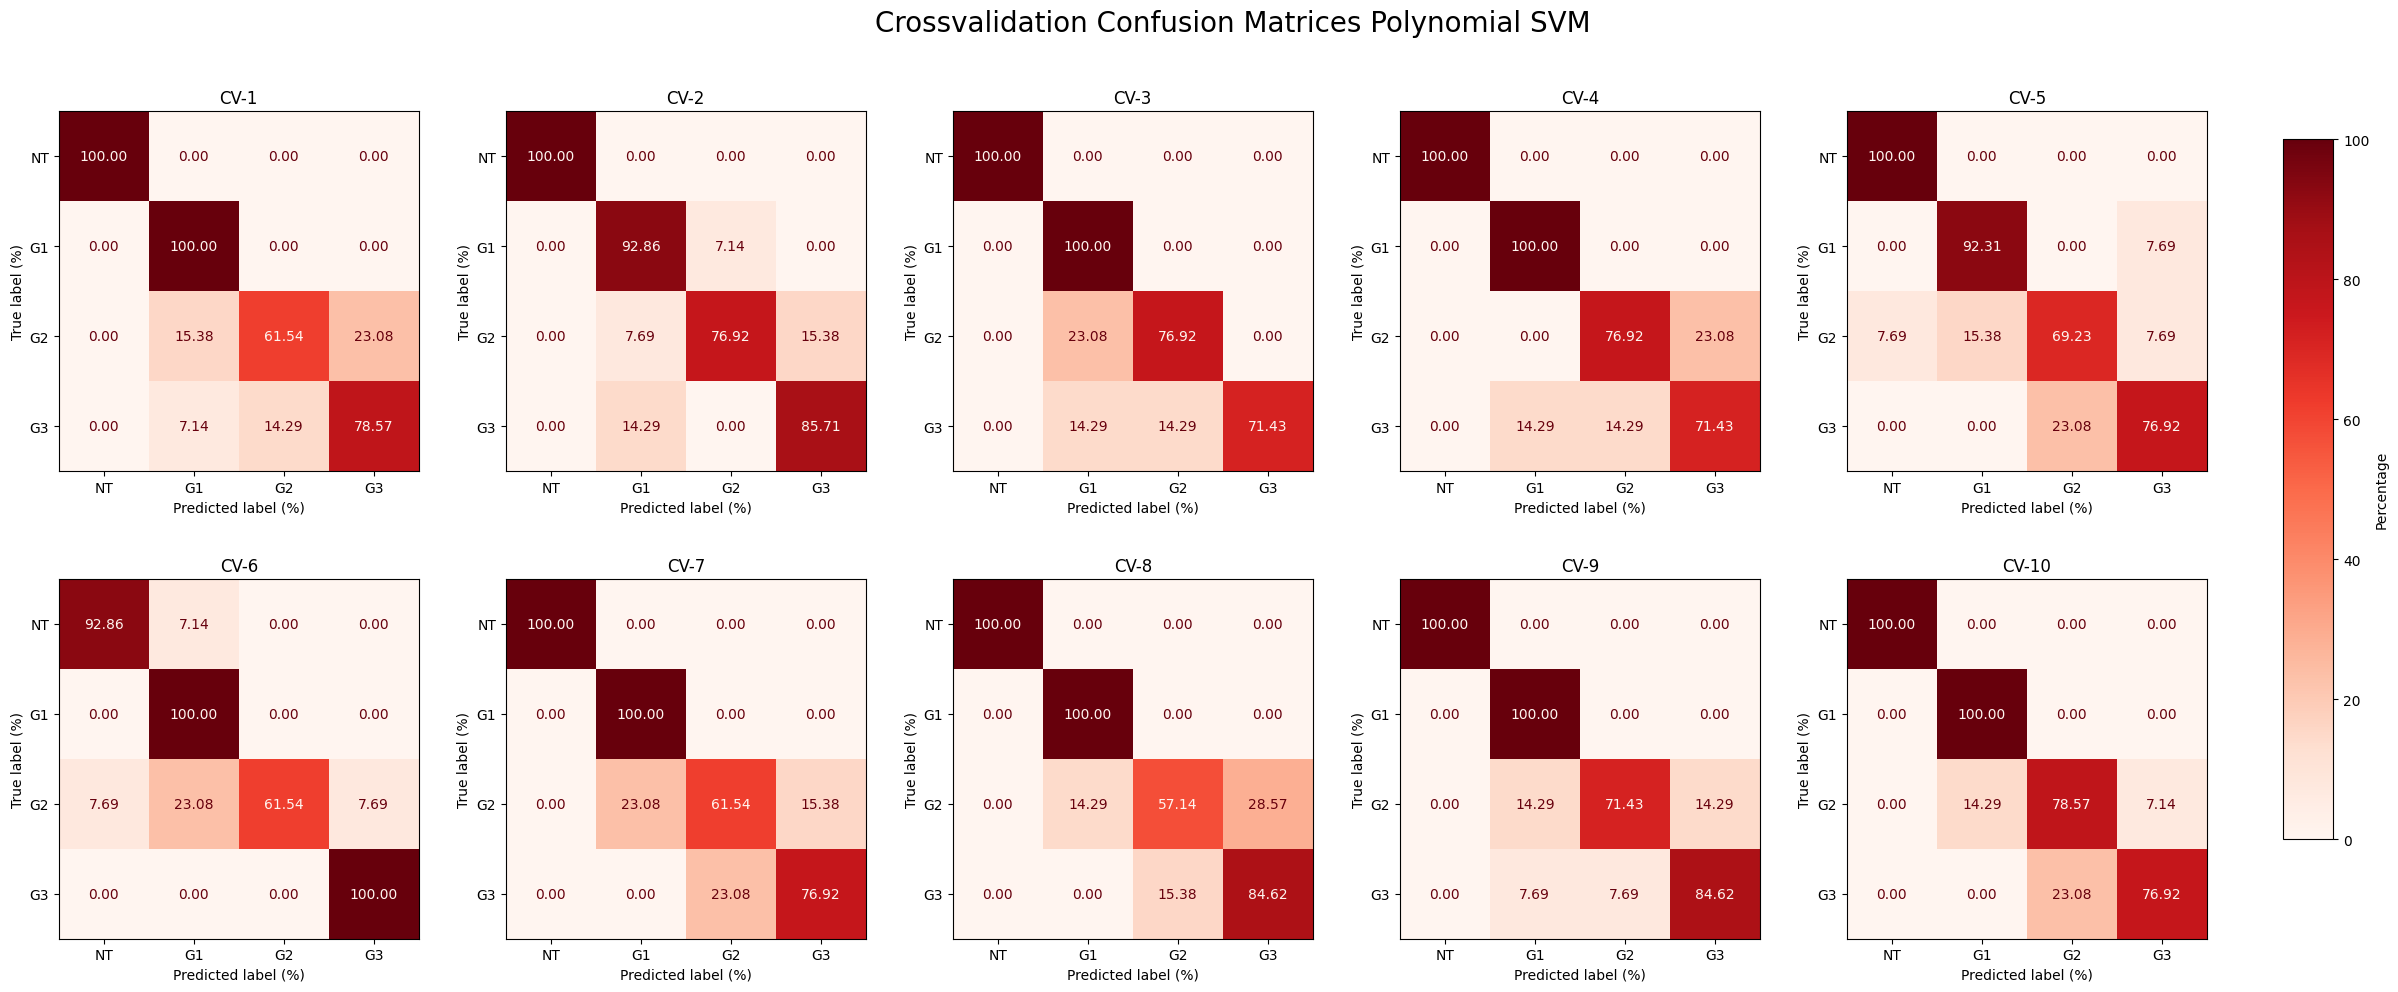

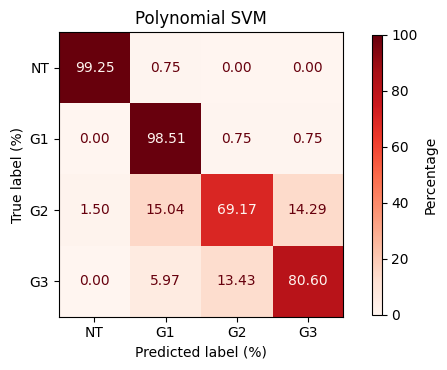

Cross-Validation Results Polynomial SVM:
Accuracy: ['85.19', '88.89', '87.04', '87.04', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
Precision: ['85.05', '89.25', '89.17', '86.76', '84.51', '90.59', '84.62', '84.91', '89.23', '88.84']
Recall: ['85.19', '88.89', '87.04', '87.04', '84.91', '88.68', '84.91', '84.91', '88.68', '88.68']
F1: ['84.61', '88.83', '86.94', '86.74', '84.59', '88.09', '84.38', '84.19', '88.41', '88.50']
AUC: ['97.84', '95.78', '98.52', '95.89', '94.28', '98.22', '96.68', '97.06', '94.28', '98.04']

Average Metrics CV Polynomial SVM:
Accuracy: 86.89 +- 1.68
Precision: 87.29 +- 2.24
Recall: 86.89 +- 1.68
F1: 86.53 +- 1.81
AUC: 96.66 +- 1.48

Sensitivity (Recall) CV Polynomial SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.18 ± 7.70
G3: 80.71 ± 8.05

Specificity CV Polynomial SVM:
NT: 99.49 ± 1.03
G1: 92.75 ± 2.36
G2: 95.25 ± 2.38
G3: 95.00 ± 2.74

True positive CV Polynomial SVM:
NT: 99.29 ± 2.14
G1: 98.52 ± 2.97
G2: 69.18 ± 7.70
G3: 80.71 ± 8.05


In [ ]:
X_psvm, features_psvm = select_features_cv(feat_psvmg2g3, X_df, X_train_valid_scaled,top=370)
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
#svm_kernel= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Polynomial SVM', X_psvm, y_train_valid)


In [ ]:
X_psvm, features_psvm = select_features_cv(feat_psvm, X_df, X_train_valid_scaled,top=135)
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Polynomial SVM', X_psvm, y_train_valid)

Index(['KCNQ1', 'CDKL2', 'RAB22A', 'E2F6', 'PIGB', 'S100A2', 'NEDD1',
       'C1orf77', 'PLD1', 'BMP4',
       ...
       'RTN4', 'GCH1', 'MELK', 'PRR14', 'PDRG1', 'RPRM', 'C22orf24', 'GABPB2',
       'ZFP62', 'HOXC4'],
      dtype='object', length=135)


NameError: name 'crossvalidation' is not defined

Index(['ADIPOR1', 'KIAA0664', 'RGS12', 'C2orf79', 'HOXA10', 'AURKB', 'SPC24',
       'OSR2', 'HDAC11', 'C22orf24',
       ...
       'HNRNPD', 'SH3D20', 'MRPS18C', 'RBM47', 'MC4R', 'C1orf163', 'XPO1',
       'HOXD4', 'LRP5L', 'LRRN4CL'],
      dtype='object', length=300)


<ipython-input-34-ebe35893a7bf>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-34-ebe35893a7bf>:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


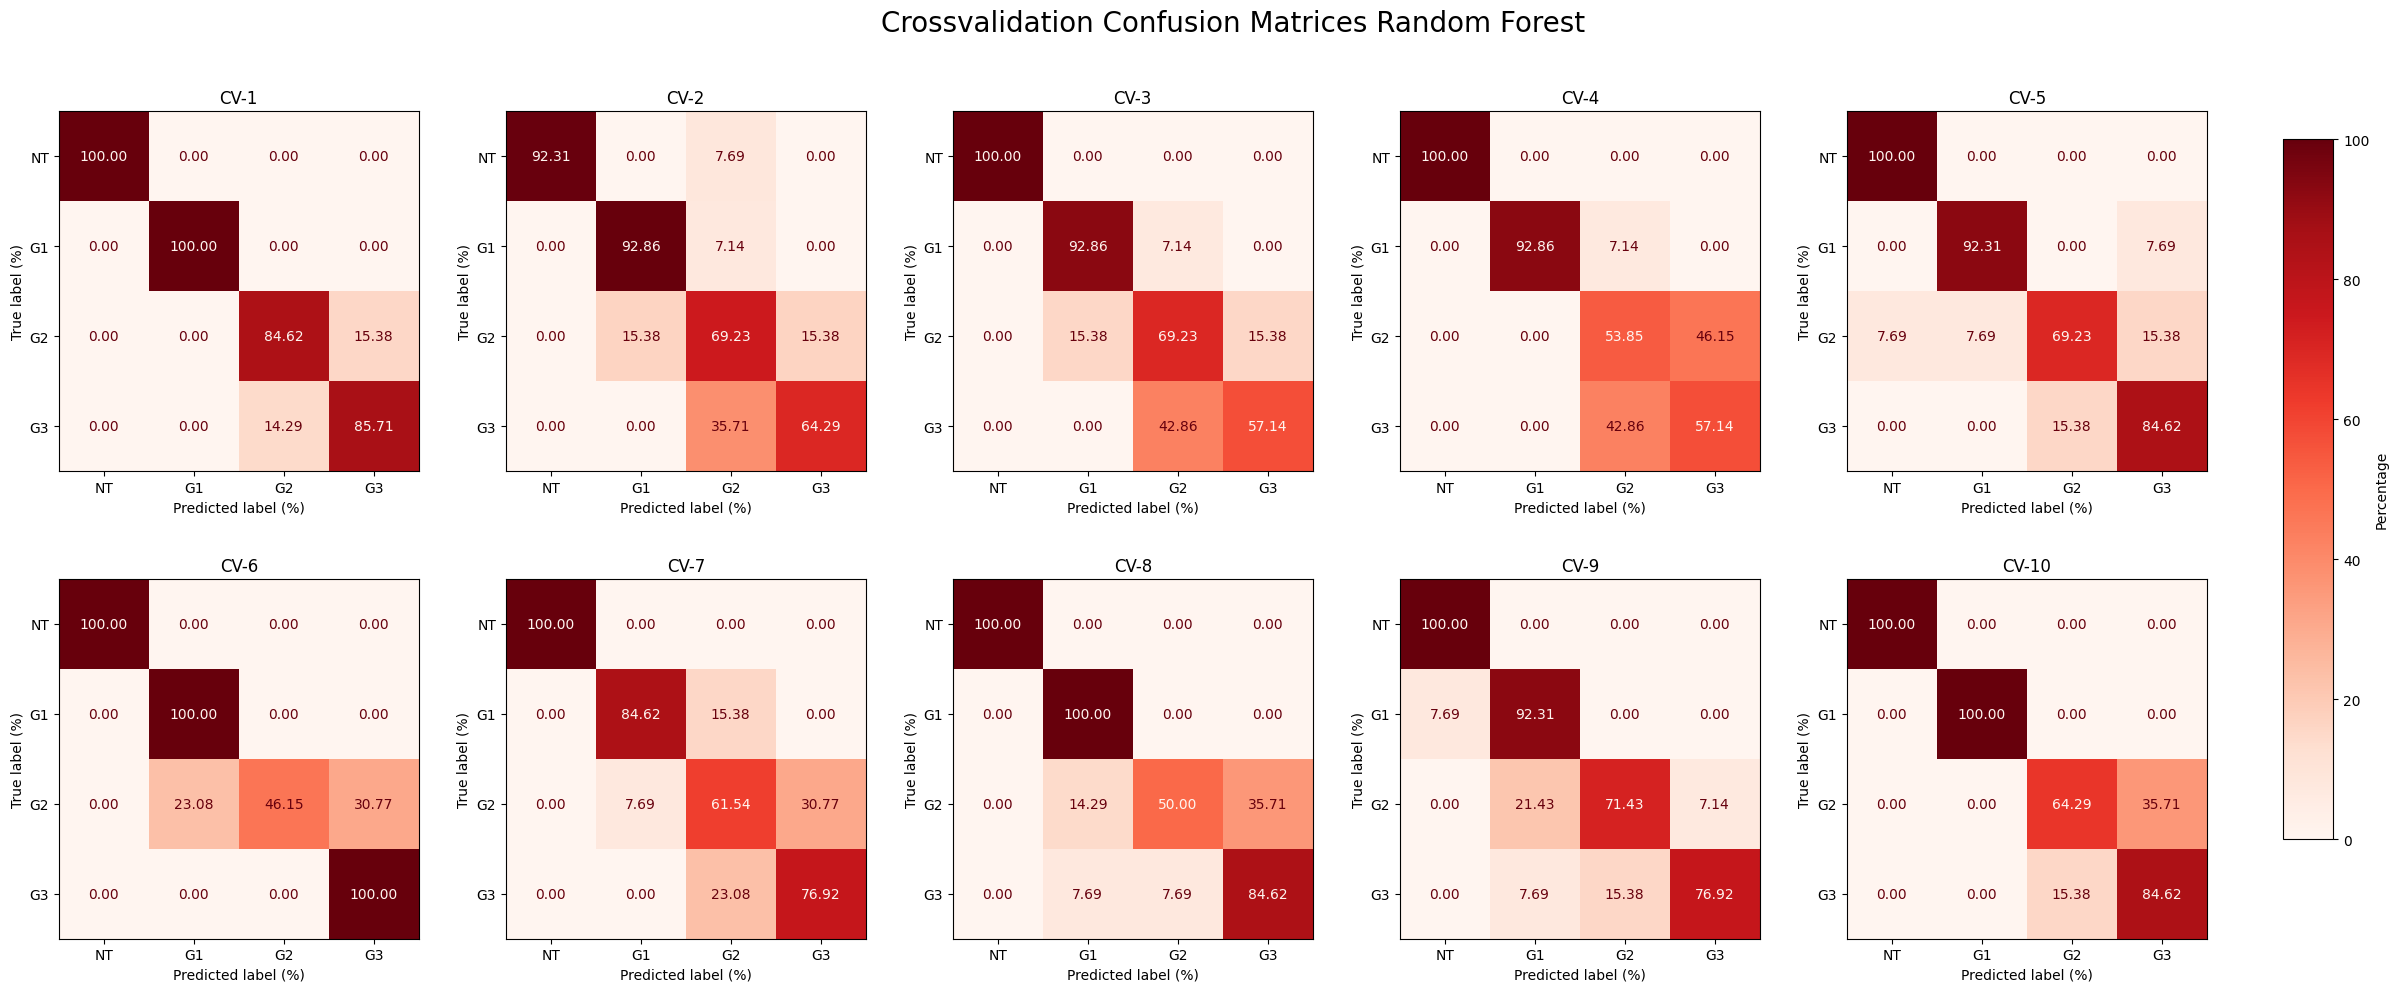

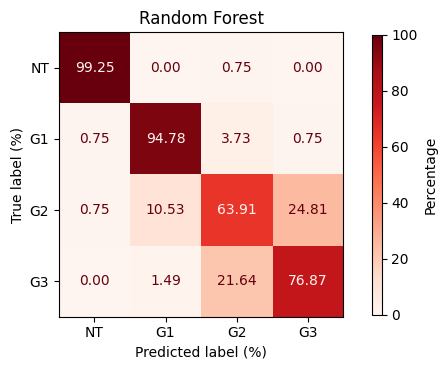

Cross-Validation Results Random Forest:
Accuracy: ['92.59', '79.63', '79.63', '75.93', '86.79', '86.79', '81.13', '83.02', '84.91', '86.79']
Precision: ['92.59', '81.30', '80.83', '76.85', '86.64', '89.63', '81.51', '84.43', '85.48', '87.53']
Recall: ['92.59', '79.63', '79.63', '75.93', '86.79', '86.79', '81.13', '83.02', '84.91', '86.79']
F1: ['92.59', '79.96', '79.54', '76.34', '86.53', '85.16', '81.26', '81.94', '84.68', '86.68']
AUC: ['98.59', '95.28', '94.51', '93.82', '94.90', '97.16', '96.15', '97.05', '97.51', '96.61']

Average Metrics CV Random Forest:
Accuracy: 83.72 +- 4.58
Precision: 84.68 +- 4.44
Recall: 83.72 +- 4.58
F1: 83.47 +- 4.39
AUC: 96.16 +- 1.42

Sensitivity (Recall) CV Random Forest:
NT: 99.23 ± 2.31
G1: 94.78 ± 4.85
G2: 63.96 ± 10.89
G3: 77.20 ± 13.15

Specificity CV Random Forest:
NT: 99.49 ± 1.01
G1: 96.00 ± 3.39
G2: 91.36 ± 6.26
G3: 91.50 ± 3.91

True positive CV Random Forest:
NT: 99.23 ± 2.31
G1: 94.78 ± 4.85
G2: 63.96 ± 10.89
G3: 77.20 ± 13.15


In [ ]:
X_rf100, features100_rf = select_features_cv(feat_rf, X_df, X_train_valid_scaled,top=300)
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
crossvalidation(rf, 'Random Forest',X_rf100, y_train_valid)

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'CLCC1',
       'LOC100128675', 'GSTM5',
       ...
       'DDX46', 'ZNF322A', 'RPL7', 'C17orf85', 'MUC13', 'ANKRD11', 'LASP1',
       'PFKFB4', 'C6orf48', 'EGFL8'],
      dtype='object', length=300)


AttributeError: 'function' object has no attribute 'fit'

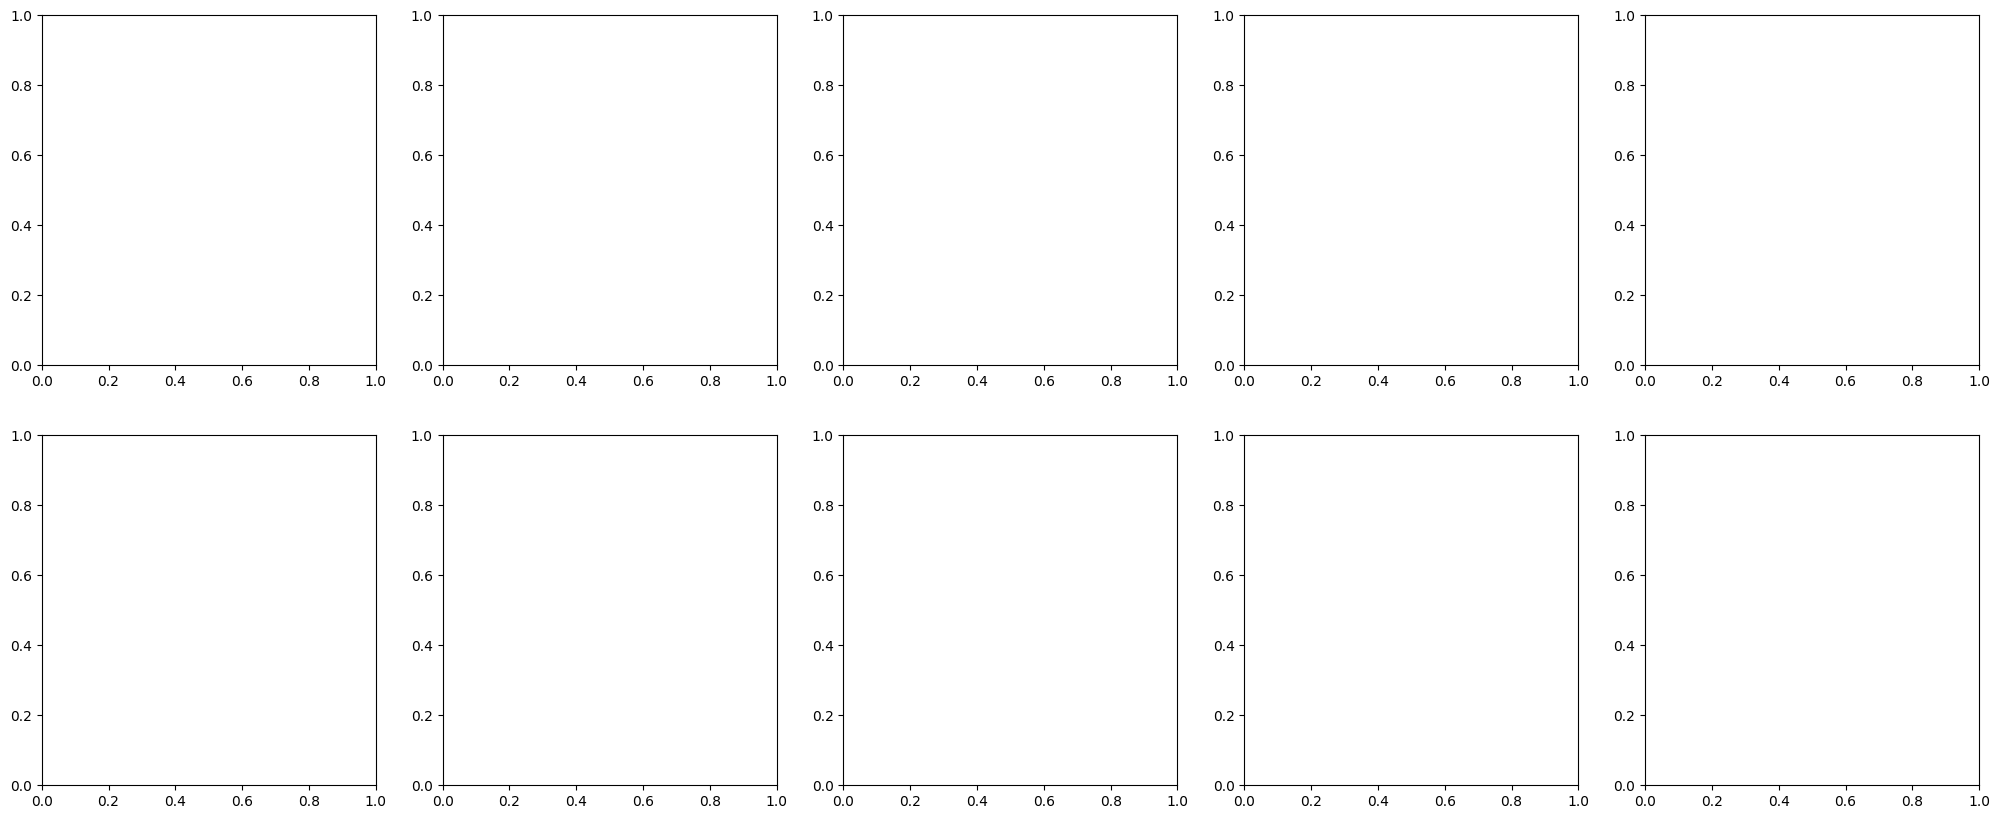

In [ ]:
X_nn100, features100_nn = select_features_cv(feat_nn, X_df, X_train_valid_scaled,top=300)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

#IMPROVE PERFORMANCE NN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation(classifier_func, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(num_classes):
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(num_classes)}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# X, y should be your dataset
# crossvalidation(create_model, 'Neural Network', X, y)


Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
2/2 [==============================] - 0s 8ms/step


2/2 [==============================] - 0s 8ms/step


2/2 [==============================] - 0s 10ms/step


<ipython-input-20-4f13931a3174>:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-20-4f13931a3174>:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


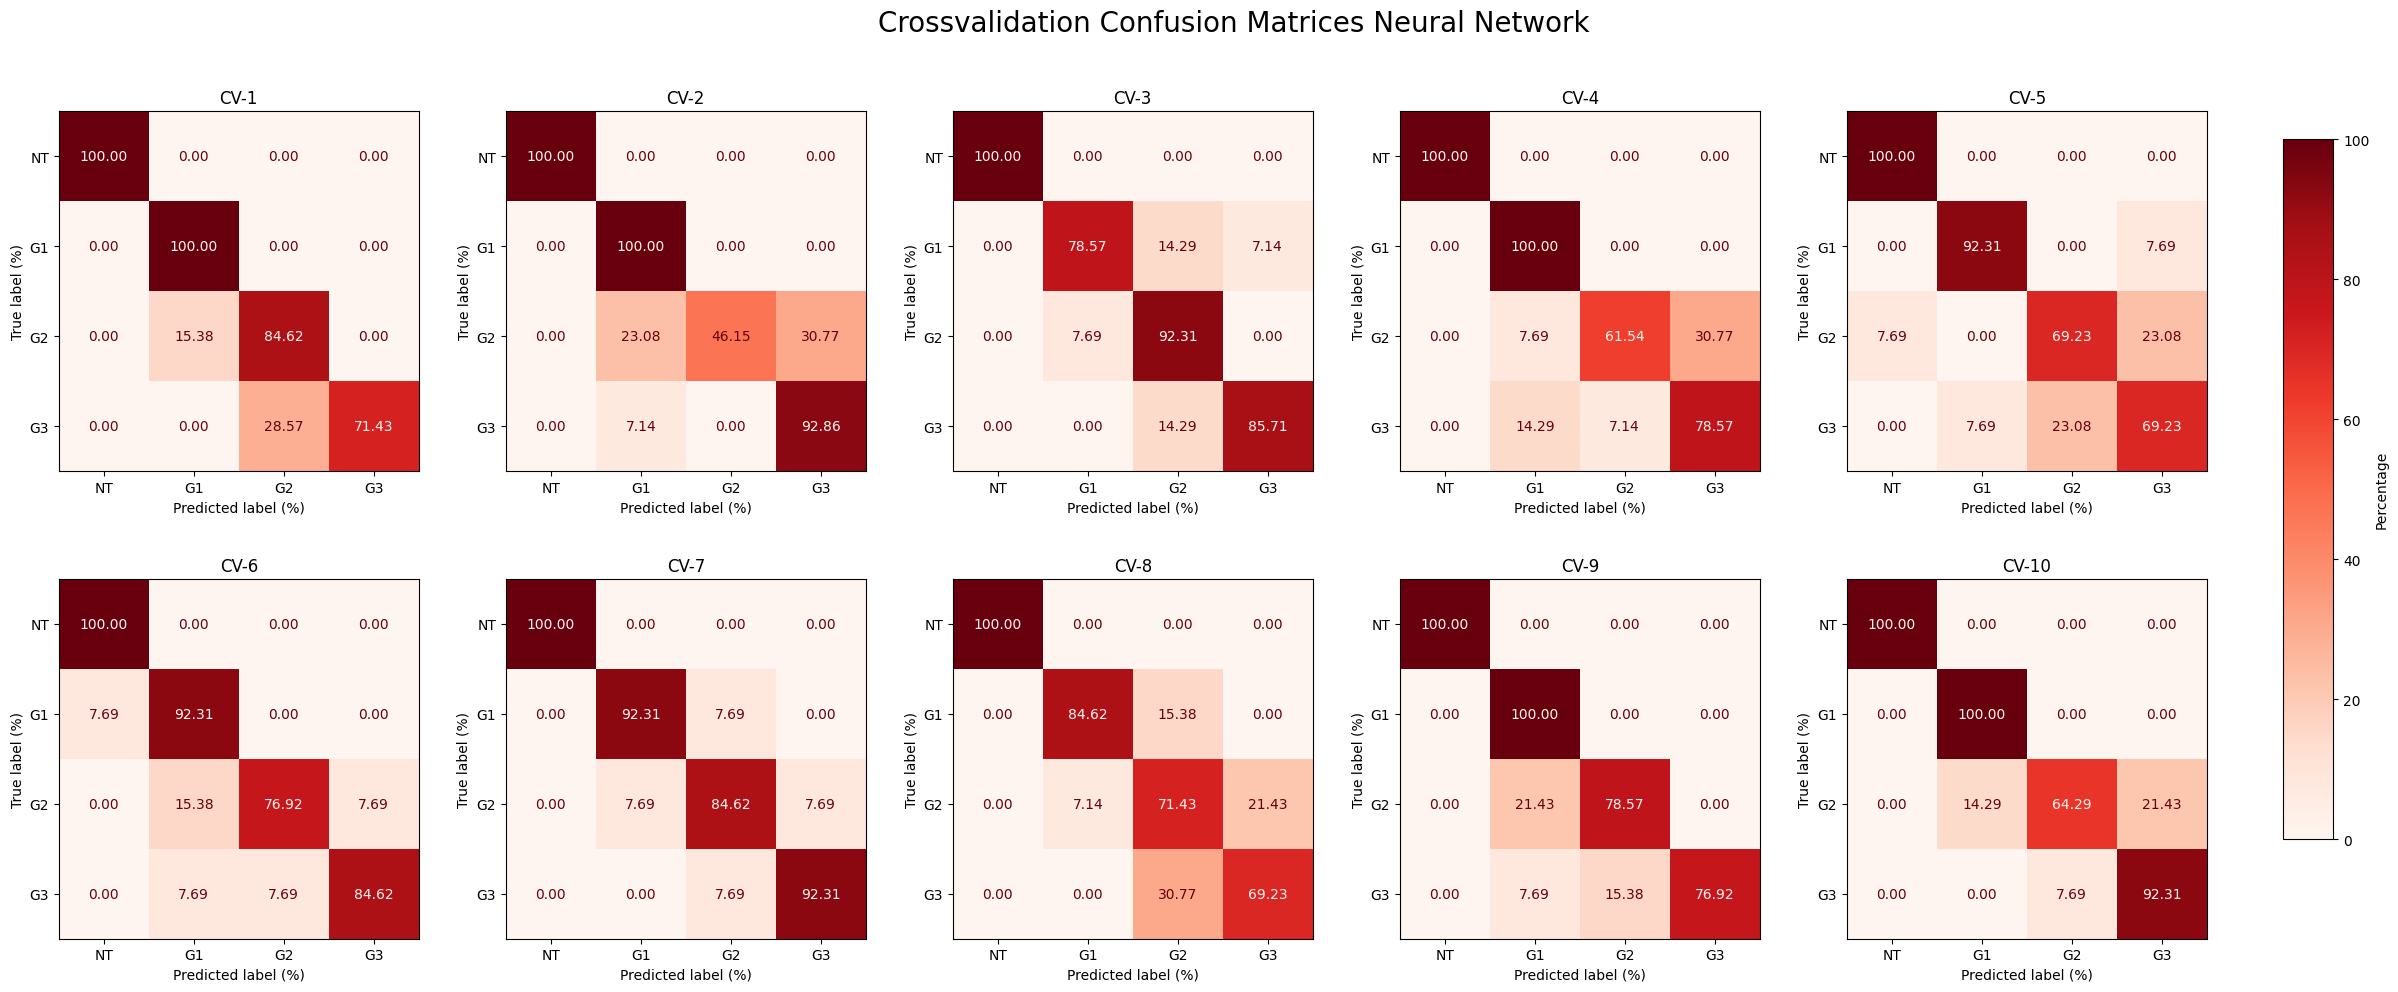

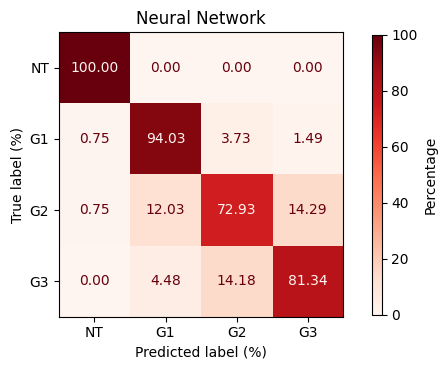

Cross-Validation Results Neural Network:
Accuracy: ['88.89', '85.19', '88.89', '85.19', '83.02', '88.68', '92.45', '81.13', '88.68', '88.68']
Precision: ['90.34', '88.14', '89.83', '85.84', '82.67', '89.06', '92.45', '81.92', '90.16', '89.18']
Recall: ['88.89', '85.19', '88.89', '85.19', '83.02', '88.68', '92.45', '81.13', '88.68', '88.68']
F1: ['88.79', '83.71', '88.98', '84.67', '82.79', '88.55', '92.45', '81.38', '88.64', '88.14']
AUC: ['97.60', '95.11', '98.26', '97.17', '92.50', '98.56', '96.44', '95.07', '95.51', '96.75']

Average Metrics CV Neural Network:
Accuracy: 87.08 +- 3.20
Precision: 87.96 +- 3.25
Recall: 87.08 +- 3.20
F1: 86.81 +- 3.29
AUC: 96.30 +- 1.72

True positive CV Neural Network:
NT: 100.00 ± 0.00
G1: 94.01 ± 7.17
G2: 72.97 ± 12.78
G3: 81.32 ± 9.07


In [ ]:
X_nn100, features100_nn = select_features(feat_nn, X_df, X_train_valid_scaled,top=175)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

In [ ]:
X_nn100, features100_nn = select_features(feat_nn, X_df, X_train_valid_scaled,top=175)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
2/2 [==============================] - 0s 9ms/step


Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'SIRT1', 'PDRG1', 'DSPP', 'LOC728927', 'DDIT3', 'BMP4', 'RIMS3',
       'ITM2C', 'MEG3', 'USP53'],
      dtype='object', length=150)
2/2 [==============================] - 0s 9ms/step


<ipython-input-106-4f13931a3174>:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-106-4f13931a3174>:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


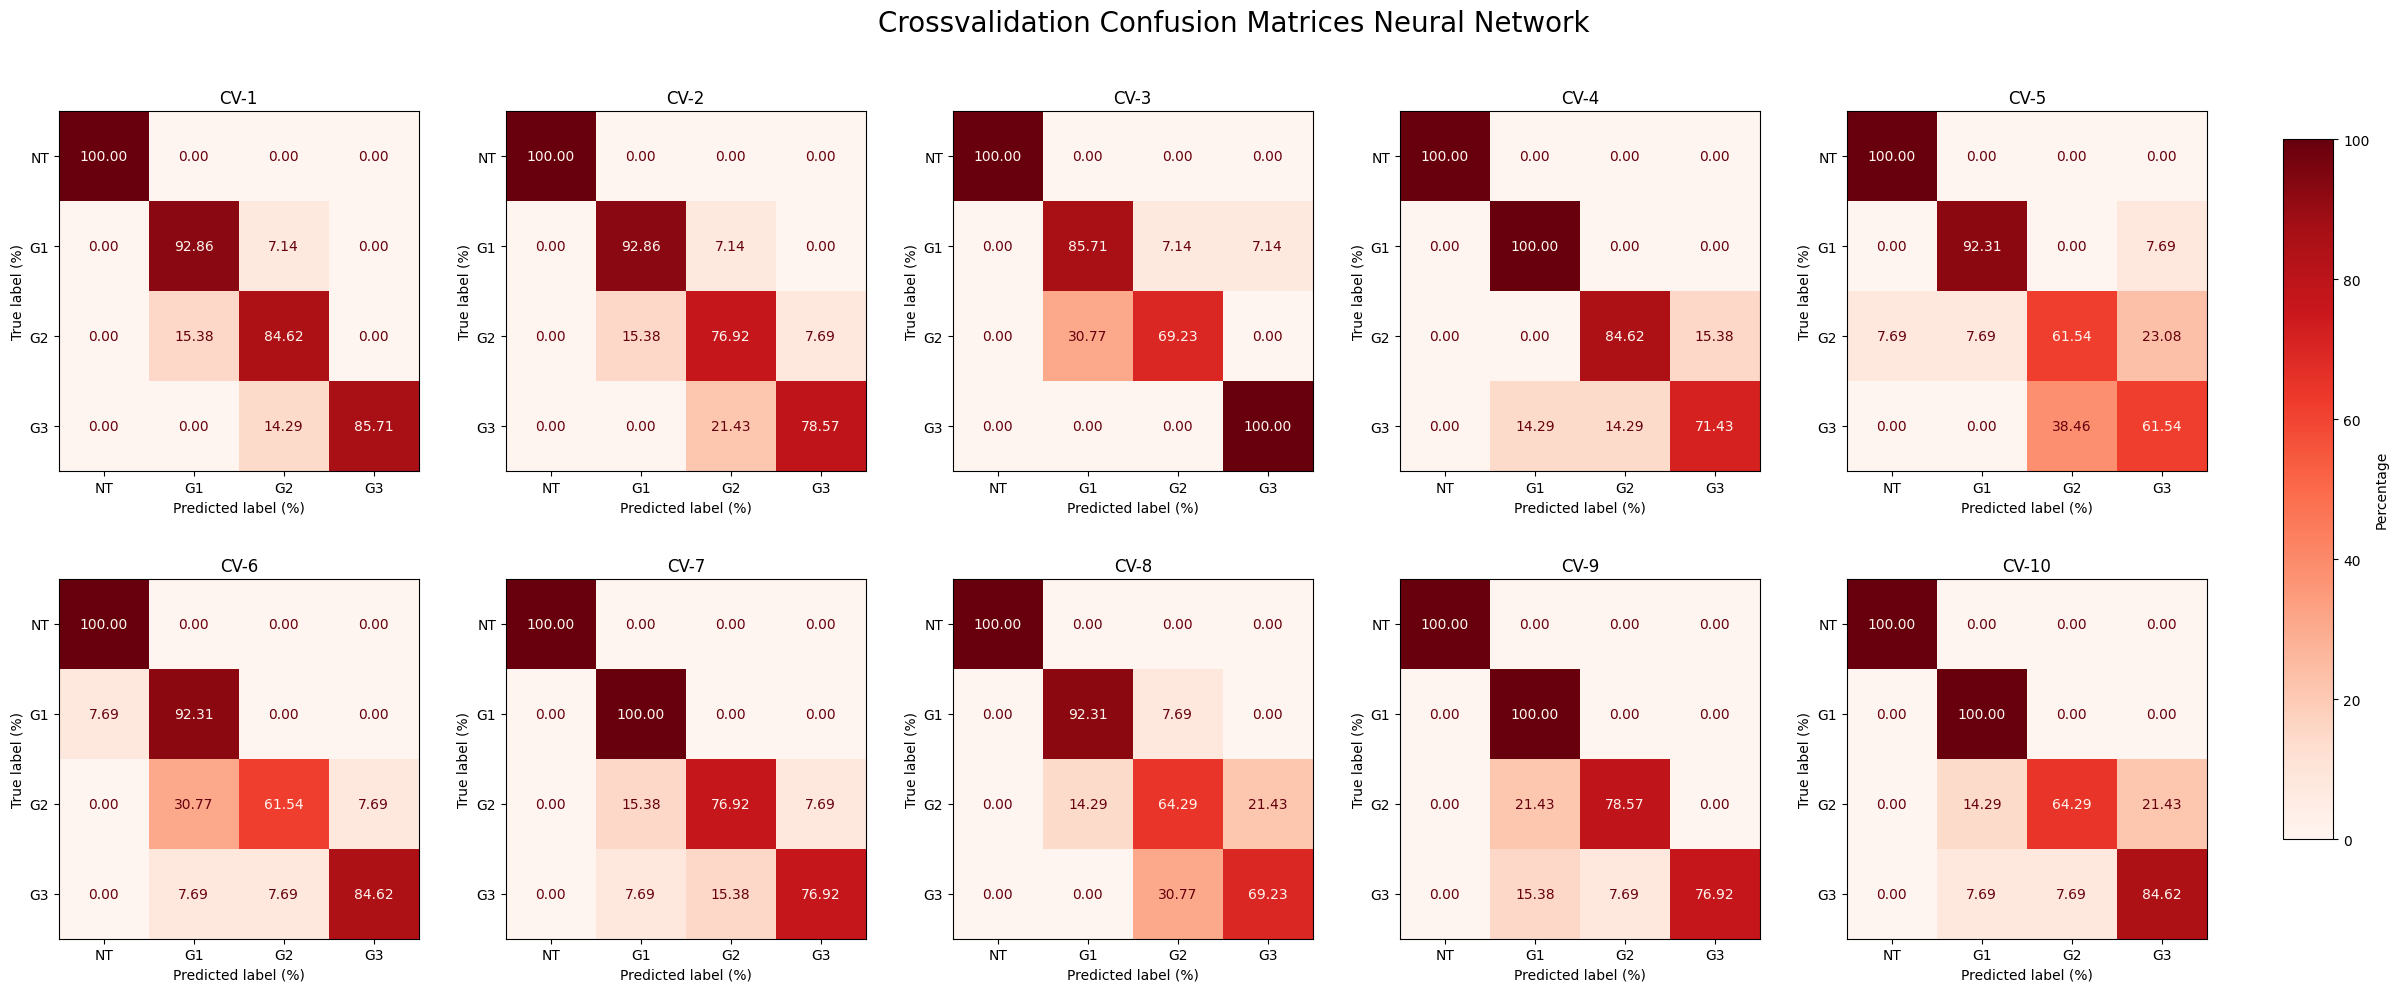

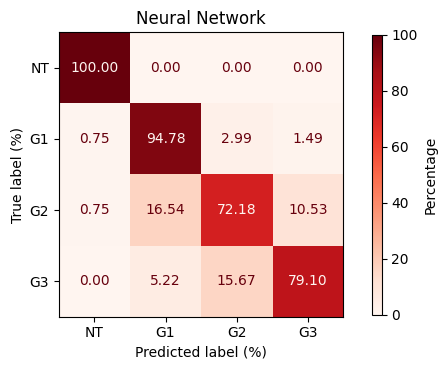

Cross-Validation Results Neural Network:
Accuracy: ['90.74', '87.04', '88.89', '88.89', '79.25', '84.91', '88.68', '81.13', '88.68', '86.79']
Precision: ['91.38', '87.50', '89.38', '88.73', '78.74', '86.26', '89.08', '80.93', '90.99', '87.50']
Recall: ['90.74', '87.04', '88.89', '88.89', '79.25', '84.91', '88.68', '81.13', '88.68', '86.79']
F1: ['90.87', '87.09', '88.69', '88.58', '78.94', '84.55', '88.47', '80.97', '88.78', '86.32']
AUC: ['97.82', '94.19', '98.26', '97.34', '92.12', '96.25', '95.82', '94.55', '97.00', '96.60']

Average Metrics CV Neural Network:
Accuracy: 86.50 +- 3.51
Precision: 87.05 +- 3.93
Recall: 86.50 +- 3.51
F1: 86.33 +- 3.59
AUC: 95.99 +- 1.79

True positive CV Neural Network:
NT: 100.00 ± 0.00
G1: 94.84 ± 4.66
G2: 72.25 ± 8.69
G3: 78.96 ± 10.08


In [ ]:
X_nn100, features100_nn = select_features(feat_nn, X_df, X_train_valid_scaled,top=150)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

# NN


In [ ]:
X_nn100, features100_nn = select_features(feat_nn, X_df, X_train_valid_scaled,top=100)
crossvalidation(create_model, 'Neural Network',X_nn100, y_train_valid)

TypeError: select_features() missing 1 required positional argument: 'X_test'

### coba lagi dengan 100 top berdasarkan sum G2 G3

## features w/o NT

# 3 class cross-validation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# Custom class names
class_names = ['G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
        auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    class_names = ['G2', 'G3']

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(len(class_names))}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(len(class_names)):
            tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(len(class_names))}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(len(class_names)):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Ensure y is 1D
#y_train_valid0 = np.argmax(y_train_valid0, axis=1) if y_train_valid0.ndim > 1 else y_train_valid0

# Example usage
# X_train_valid_scaled0 and y_train_valid0 should be your data
#svm_linear = SVC(kernel='linear', probability=True, random_state=42)
#crossvalidation(svm_linear, 'Linear SVM', X_train_valid_scaled0, y_train_valid0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# Custom class names
class_names = ['G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
        auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    # Calculate sensitivity (recall) and specificity for each class
    sensitivity = recall_score(y_test, y_pred, average=None)
    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, sensitivity, specificity

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    class_names = ['G2', 'G3']

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []
    sensitivity_scores = []
    specificity_scores = []

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm, sensitivity, specificity = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)
        sensitivity_scores.append(sensitivity)
        specificity_scores.append(specificity)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    print('\n======================================================================')
    print(f'Sensitivity (Recall) for each class {model_title}:')
    for i, class_name in enumerate(class_names):
        sensitivities = [s[i] for s in sensitivity_scores]
        print(f'{class_name}: {np.mean(sensitivities) * 100:.2f} ± {np.std(sensitivities) * 100:.2f}')

    print(f'\nSpecificity for each class {model_title}:')
    for i, class_name in enumerate(class_names):
        specificities = [s[i] for s in specificity_scores]
        print(f'{class_name}: {np.mean(specificities) * 100:.2f} ± {np.std(specificities) * 100:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# Assuming X and y are your features and labels respectively
# classifier = LogisticRegression()
# crossvalidation(classifier, "Logistic Regression", X, y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

def calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)

    accuracy = classifier.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
        auc = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')

    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    # Calculate overall sensitivity (recall) and specificity
    overall_sensitivity = recall
    overall_specificity = (cm[0, 0] / (cm[0, 0] + cm[0, 1]) + cm[1, 1] / (cm[1, 0] + cm[1, 1])) / 2

    return accuracy, precision, recall, f1, auc, cm, overall_sensitivity, overall_specificity

def crossvalidation(classifier, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []
    overall_sensitivity_scores = []
    overall_specificity_scores = []

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        accuracy, precision, recall, f1, auc, cm, overall_sensitivity, overall_specificity = calculate_metrics(classifier, X_train, X_test, y_train, y_test, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)
        overall_sensitivity_scores.append(overall_sensitivity)
        overall_specificity_scores.append(overall_specificity)

    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    print('\n======================================================================')
    print(f'Overall Sensitivity (Recall) and Specificity {model_title}:')
    print(f'Overall Sensitivity (Recall): {np.mean(overall_sensitivity_scores) * 100:.2f} +- {np.std(overall_sensitivity_scores) * 100:.2f}')
    print(f'Overall Specificity: {np.mean(overall_specificity_scores) * 100:.2f} +- {np.std(overall_specificity_scores) * 100:.2f}')


Index(['KCNQ1', 'CDKL2', 'RAB22A', 'E2F6', 'COLEC11', 'NEDD1', 'SERPINE2',
       'C17orf69', 'C1orf77', 'ATPGD1', 'NUMA1', 'SLC2A8', 'C17orf90', 'SIX3',
       'RUNX3', 'SPAG6', 'NDN', 'CES4', 'ENO1', 'BMP4', 'ITPKB', 'OSR2',
       'C9orf27', 'DSCR6', 'TMEM173', 'NAPSB', 'BOLL', 'GPRIN2', 'PYGO1',
       'GSTM5', 'LOC340017', 'ZFP62', 'RTN4', 'DSE', 'HMGXB4', 'C4orf31',
       'LOC100128675', 'DMRTA2', 'GABPB2', 'C2orf79', 'CRTAC1', 'TMEM39B',
       'VASH1', 'MEI1', 'ISL2', 'DLEU7', 'CLCC1', 'S100A2', 'C15orf26',
       'INADL', 'PRR20E', 'SMPD3', 'CYP1A2', 'ITM2C', 'ABLIM1', 'RPL18AP3',
       'ABCA4', 'ACSL3', 'C13orf33', 'MMP12', 'FOXP1', 'RIMS3', 'MYO1B',
       'DMP1', 'HOXD3', 'HMGB1', 'PLD1', 'ZNF354B', 'IVD', 'LOXL3', 'PRR15',
       'MIR10B', 'OR8D1', 'OR9Q1', 'OR8B4', 'OVOL1', 'SLN', 'NEURL3',
       'PPP2R5A', 'EHBP1', 'ZNF167', 'PRL', 'CDCA4', 'FAM195B', 'MIR376B',
       'NCK2', 'PAX6', 'RGS22', 'FCGR3A', 'SIRT1', 'PITX3', 'SCG5', 'ACOX3',
       'SPG7', 'C2orf50', 'TRA

<ipython-input-65-ac218c9649b5>:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-65-ac218c9649b5>:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


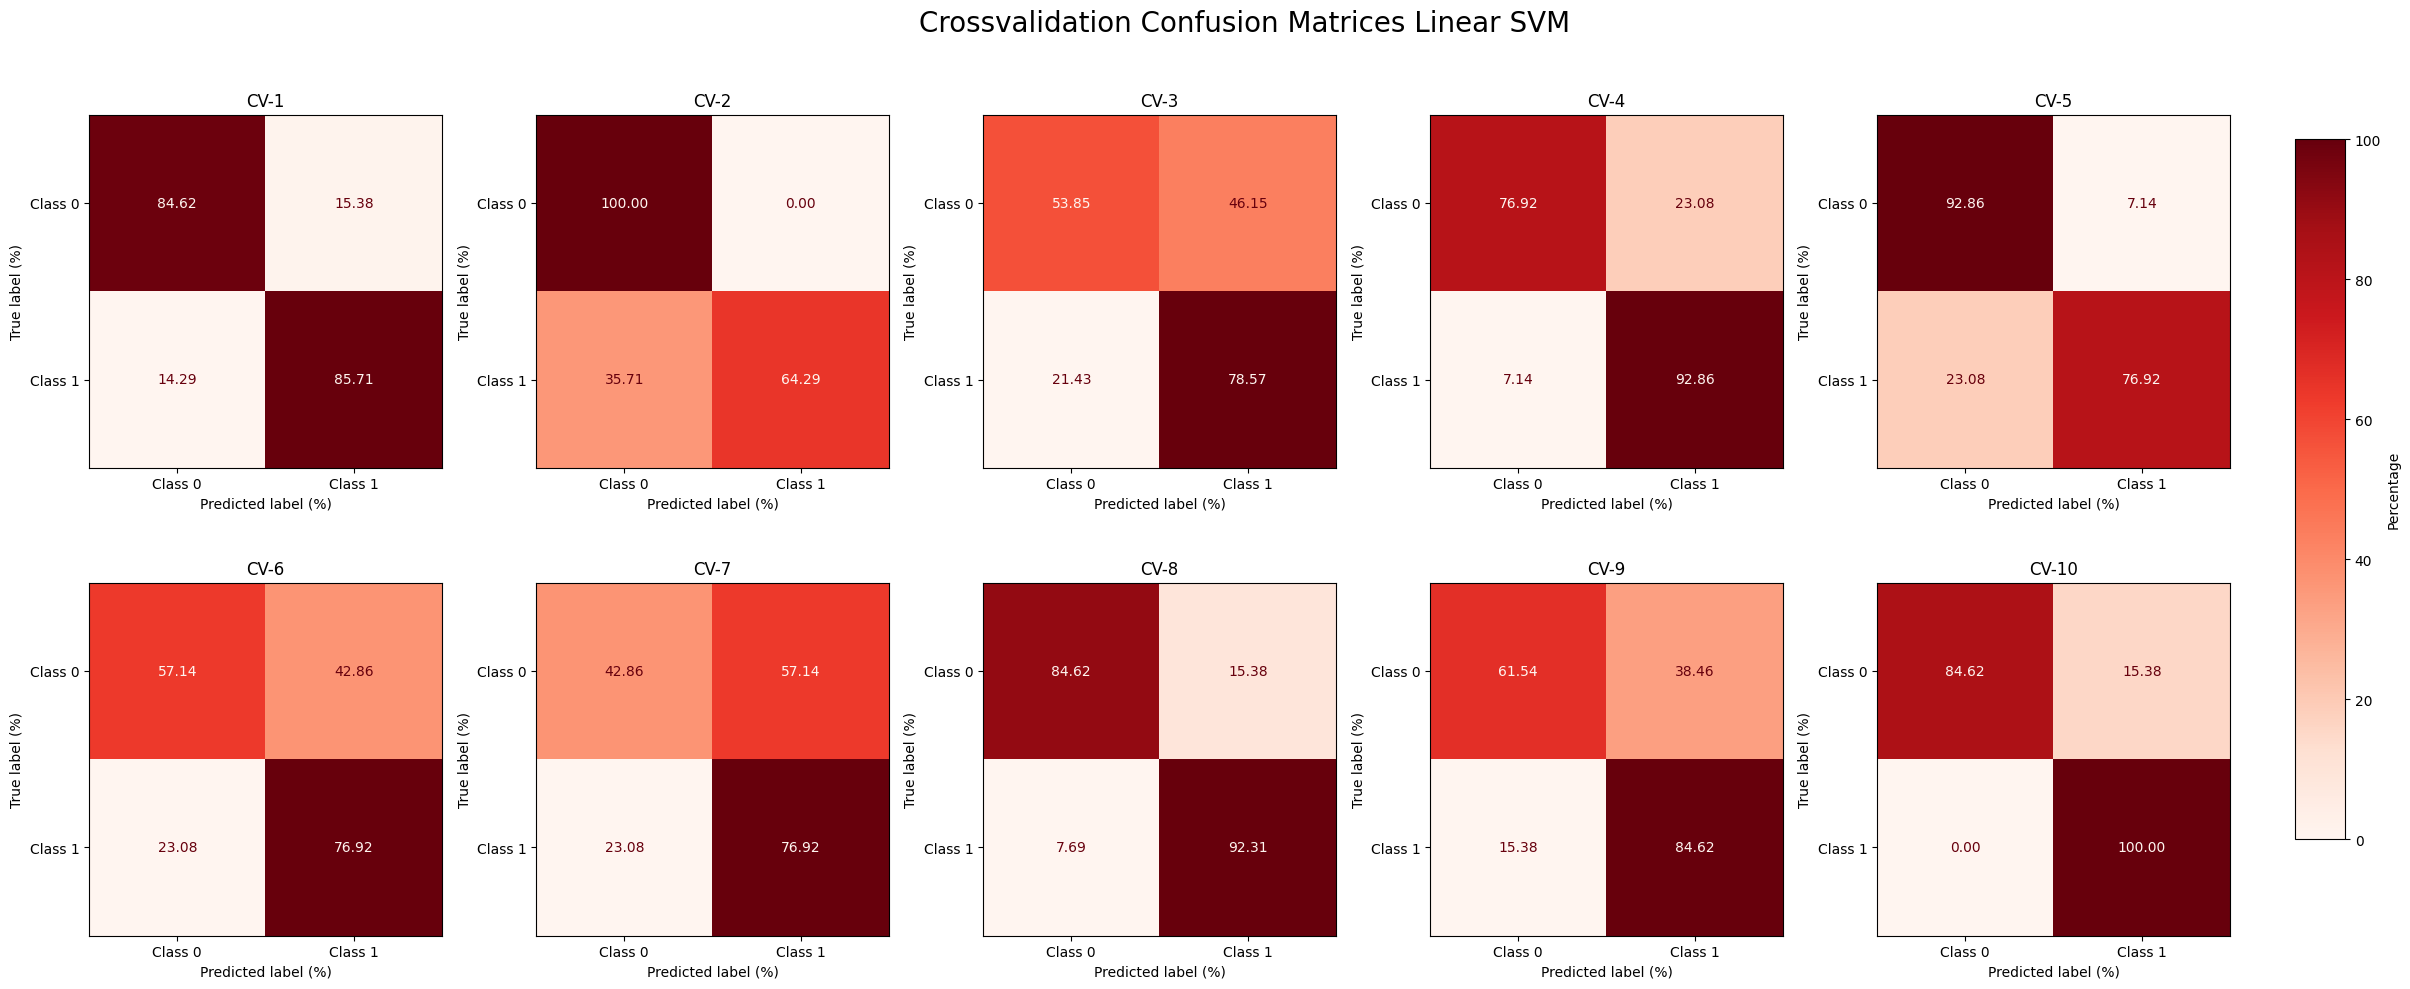

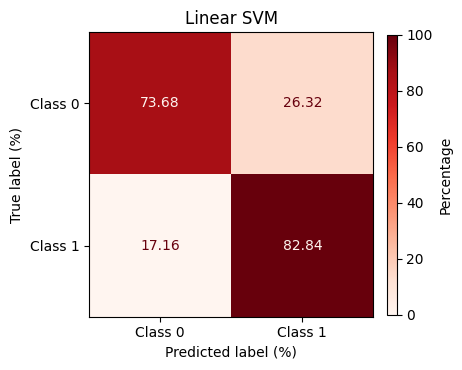

Cross-Validation Results Linear SVM:
Accuracy: ['85.19', '81.48', '66.67', '85.19', '85.19', '66.67', '59.26', '88.46', '73.08', '92.31']
Precision: ['85.19', '86.63', '67.25', '85.90', '85.90', '67.80', '61.32', '88.69', '74.37', '93.33']
Recall: ['85.19', '81.48', '66.67', '85.19', '85.19', '66.67', '59.26', '88.46', '73.08', '92.31']
F1: ['85.19', '80.96', '66.11', '85.06', '85.06', '66.39', '58.12', '88.44', '72.71', '92.26']
AUC: ['85.16', '93.41', '75.55', '86.81', '85.16', '77.47', '54.40', '88.17', '90.53', '97.63']

Average Metrics CV Linear SVM:
Accuracy: 78.35 +- 10.55
Precision: 79.64 +- 10.41
Recall: 78.35 +- 10.55
F1: 78.03 +- 10.83
AUC: 83.43 +- 11.54

True positive CV Linear SVM:
Class 0: 73.90 ± 17.87
Class 1: 82.91 ± 9.81


In [ ]:
X_lsvm100, features100_lsvm = select_features(feat_lsvm, X_df0, X_train_valid_scaled0,top=100)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid0)


In [ ]:
X_lsvm100, features100_lsvm = select_features(feat_lsvm, X_df0, X_train_valid_scaled0,top=100)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_lsvm100, y_train_valid0)

NameError: name 'select_features' is not defined

<ipython-input-43-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-43-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


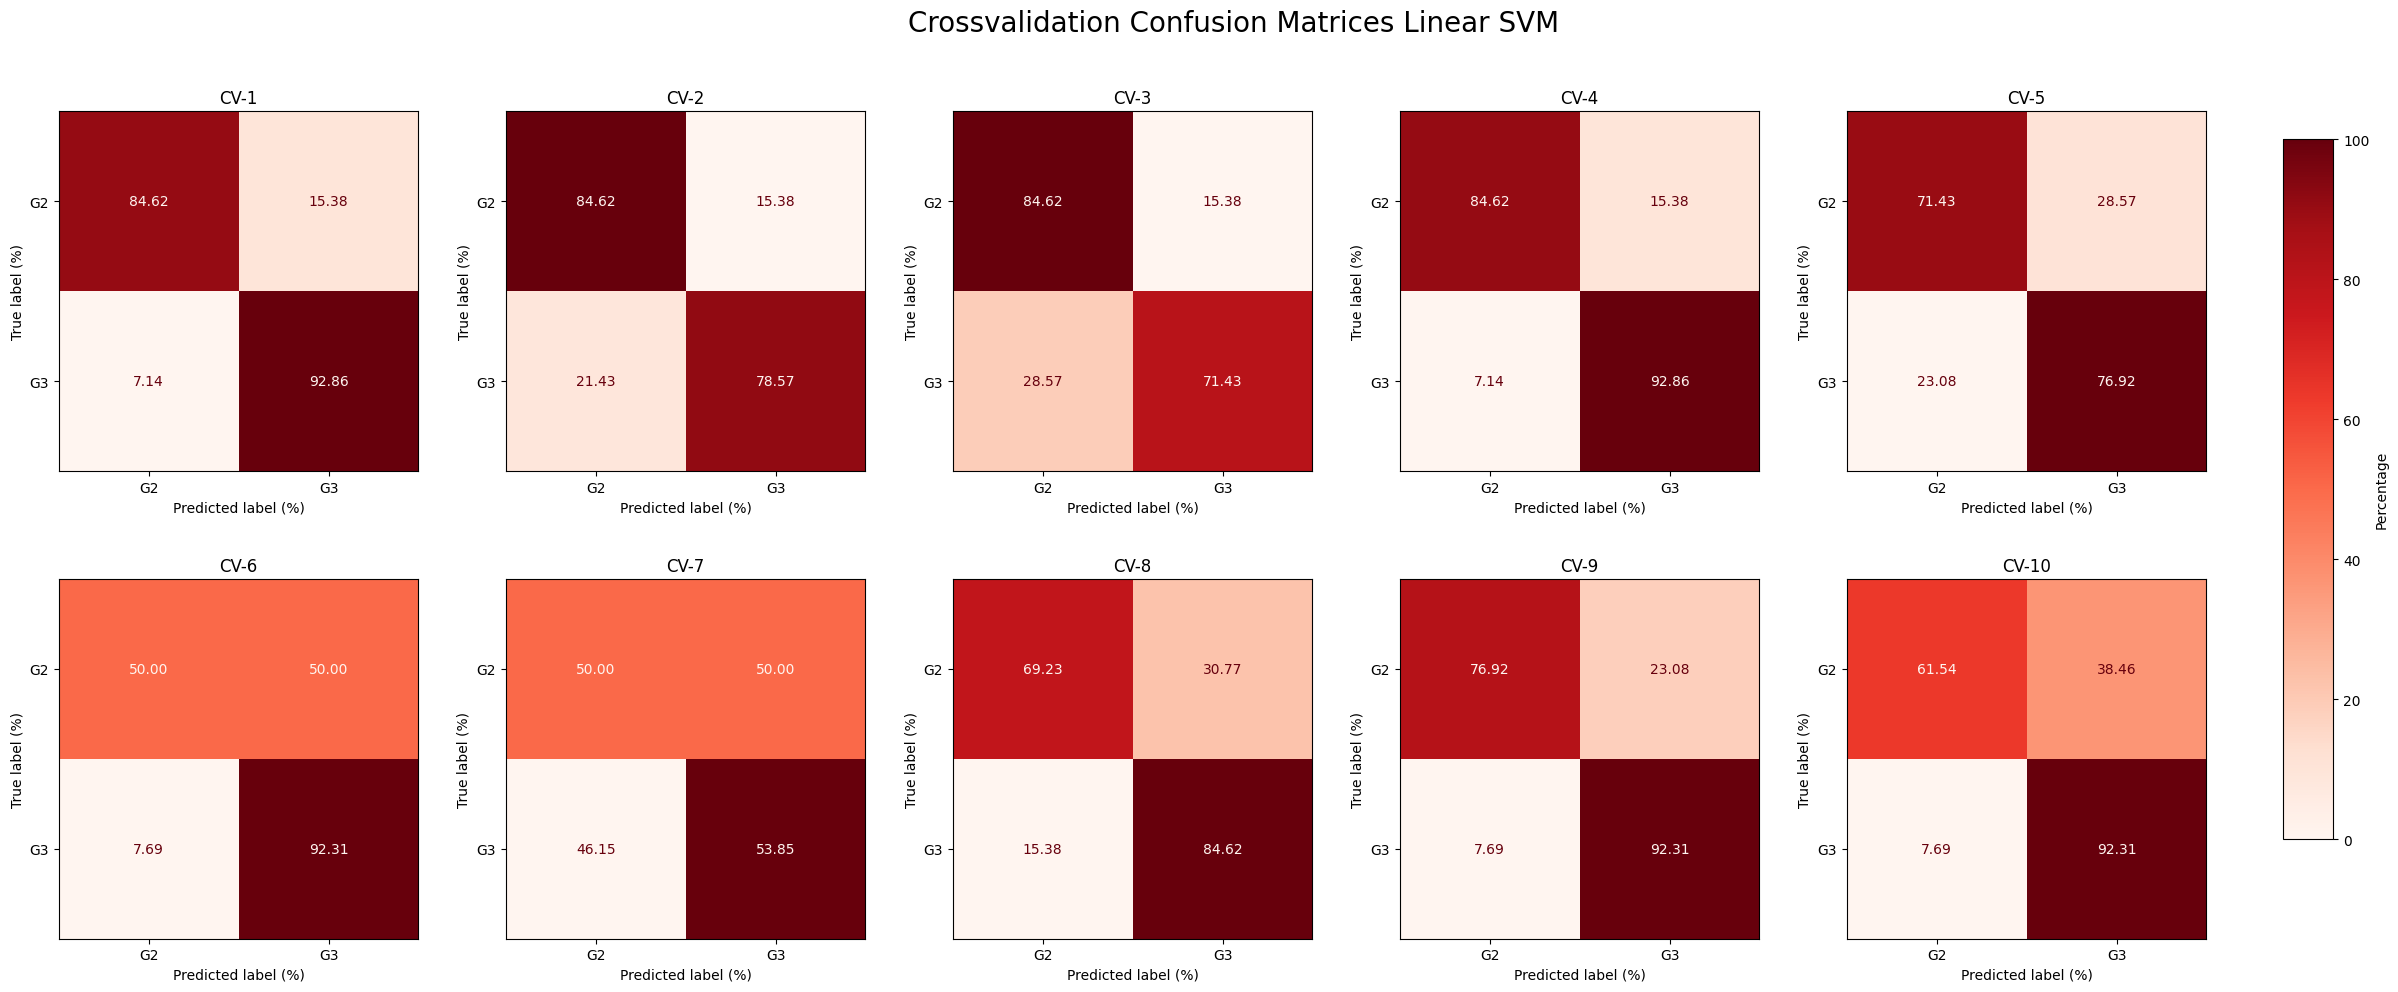

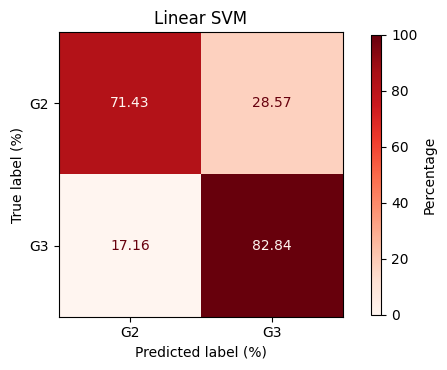

Cross-Validation Results Linear SVM:
Accuracy: ['88.89', '81.48', '77.78', '88.89', '74.07', '70.37', '51.85', '76.92', '84.62', '76.92']
Precision: ['89.07', '81.71', '78.52', '89.07', '74.28', '75.78', '51.99', '77.58', '85.45', '79.74']
Recall: ['88.89', '81.48', '77.78', '88.89', '74.07', '70.37', '51.85', '76.92', '84.62', '76.92']
F1: ['88.86', '81.48', '77.72', '88.86', '74.07', '69.11', '51.85', '76.79', '84.52', '76.36']
AUC: ['86.81', '83.52', '82.97', '93.96', '92.31', '91.76', '66.48', '79.29', '95.27', '84.62']

Average Metrics CV Linear SVM:
Accuracy: 77.18 +- 10.23
Precision: 78.32 +- 10.06
Recall: 77.18 +- 10.23
F1: 76.96 +- 10.31
AUC: 85.70 +- 8.16

True positive CV Linear SVM:
G2: 71.76 ± 13.21
G3: 82.80 ± 12.23


In [ ]:
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_train_valid_scaled0, y_train_valid0)

<ipython-input-43-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-43-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


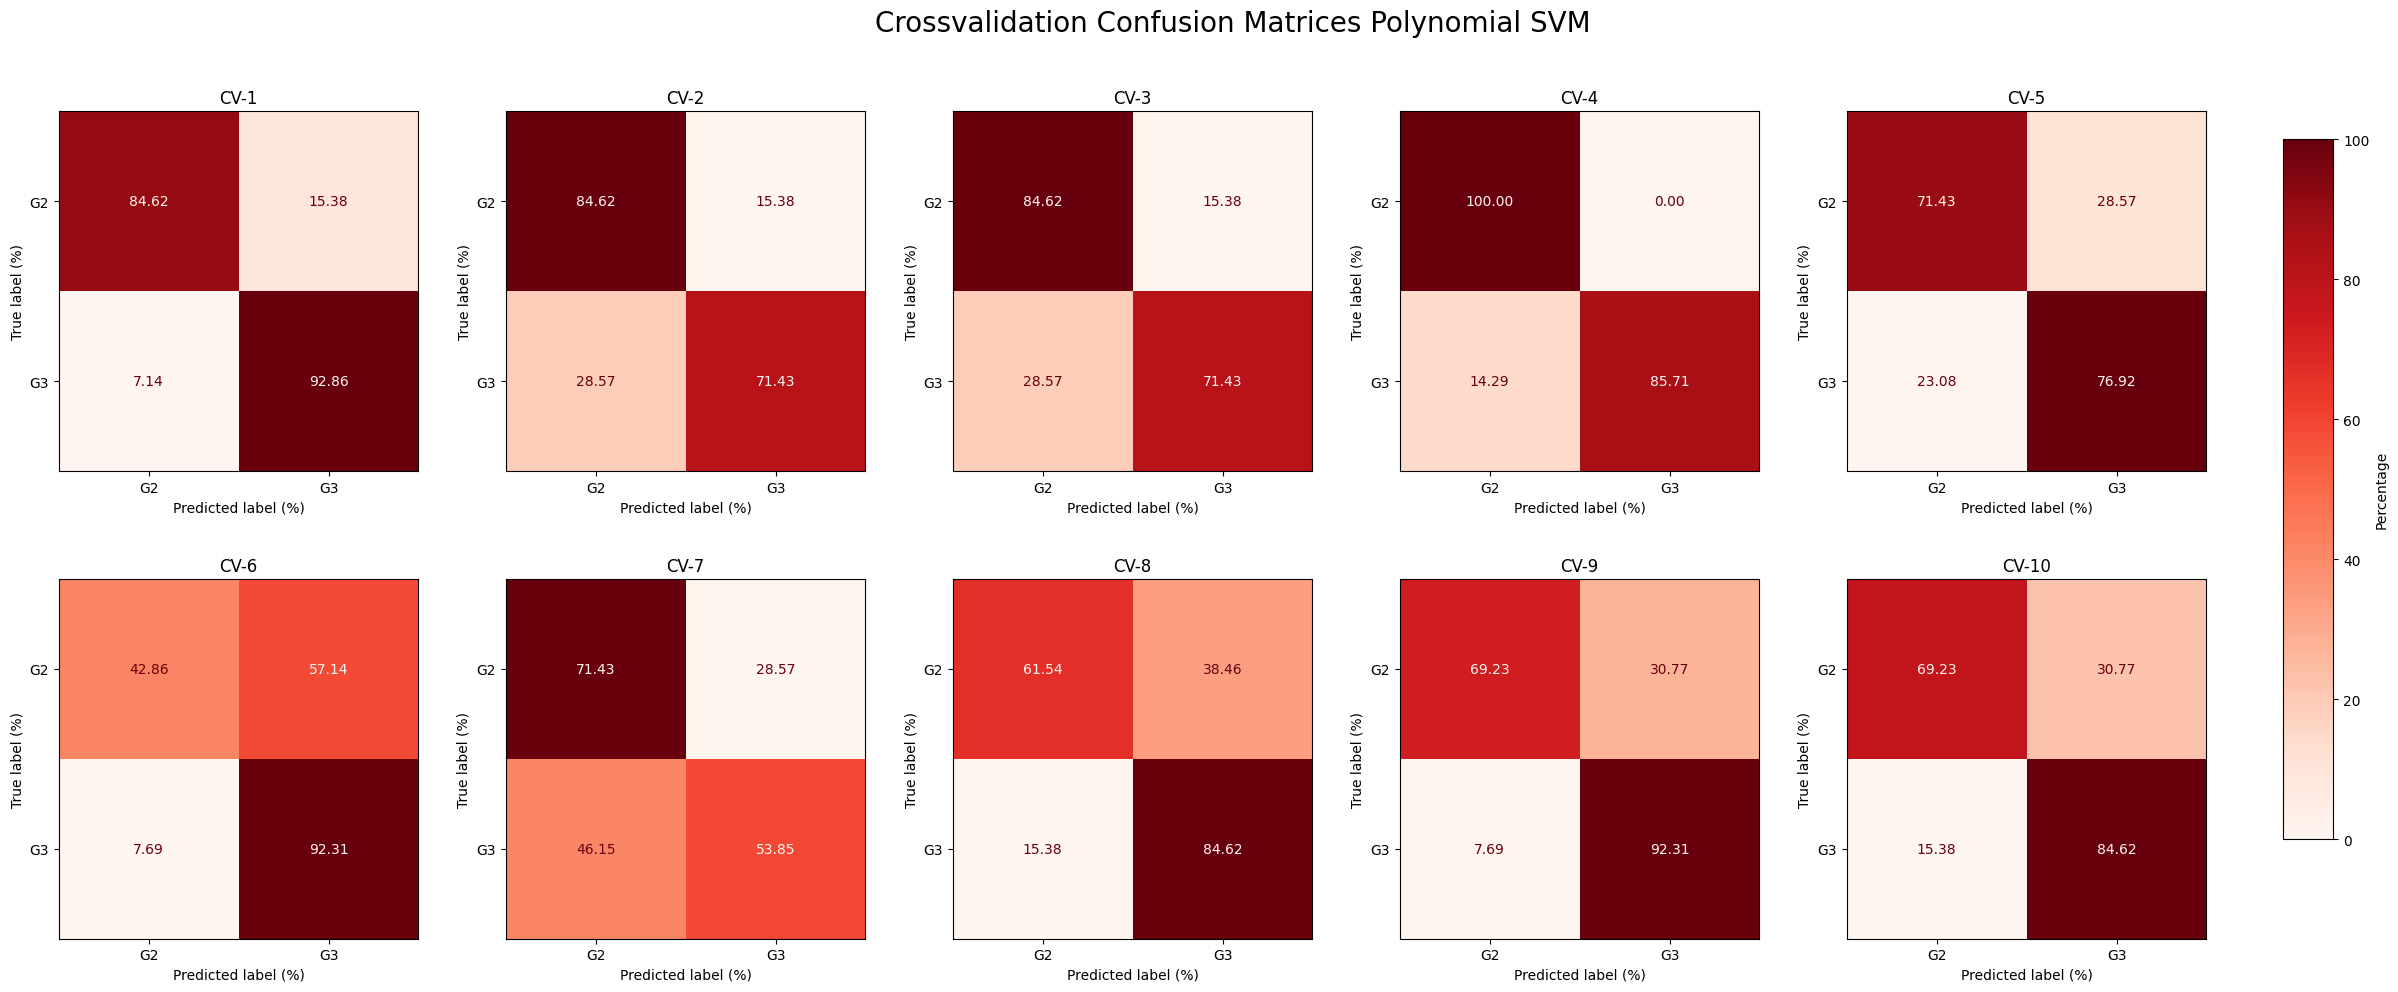

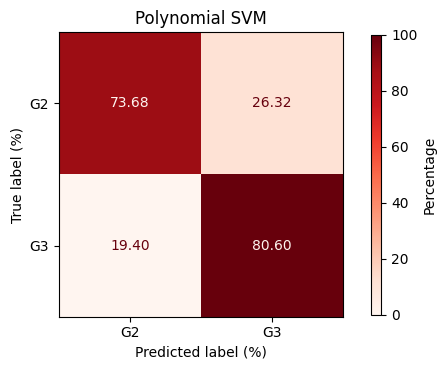

Cross-Validation Results Polynomial SVM:
Accuracy: ['88.89', '77.78', '77.78', '92.59', '74.07', '66.67', '62.96', '73.08', '80.77', '76.92']
Precision: ['89.07', '78.52', '78.52', '93.58', '74.28', '73.33', '63.05', '74.37', '82.50', '77.58']
Recall: ['88.89', '77.78', '77.78', '92.59', '74.07', '66.67', '62.96', '73.08', '80.77', '76.92']
F1: ['88.86', '77.72', '77.72', '92.57', '74.07', '64.65', '62.65', '72.71', '80.51', '76.79']
AUC: ['85.71', '84.07', '84.62', '96.15', '89.01', '89.56', '68.13', '80.47', '95.27', '78.11']

Average Metrics CV Polynomial SVM:
Accuracy: 77.15 +- 8.53
Precision: 78.48 +- 8.10
Recall: 77.15 +- 8.53
F1: 76.82 +- 8.84
AUC: 85.11 +- 7.88

True positive CV Polynomial SVM:
G2: 73.96 ± 14.83
G3: 80.60 ± 11.75


In [ ]:
svm_kernel = SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
crossvalidation(svm_kernel, 'Polynomial SVM', X_train_valid_scaled0, y_train_valid0)

<ipython-input-43-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-43-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


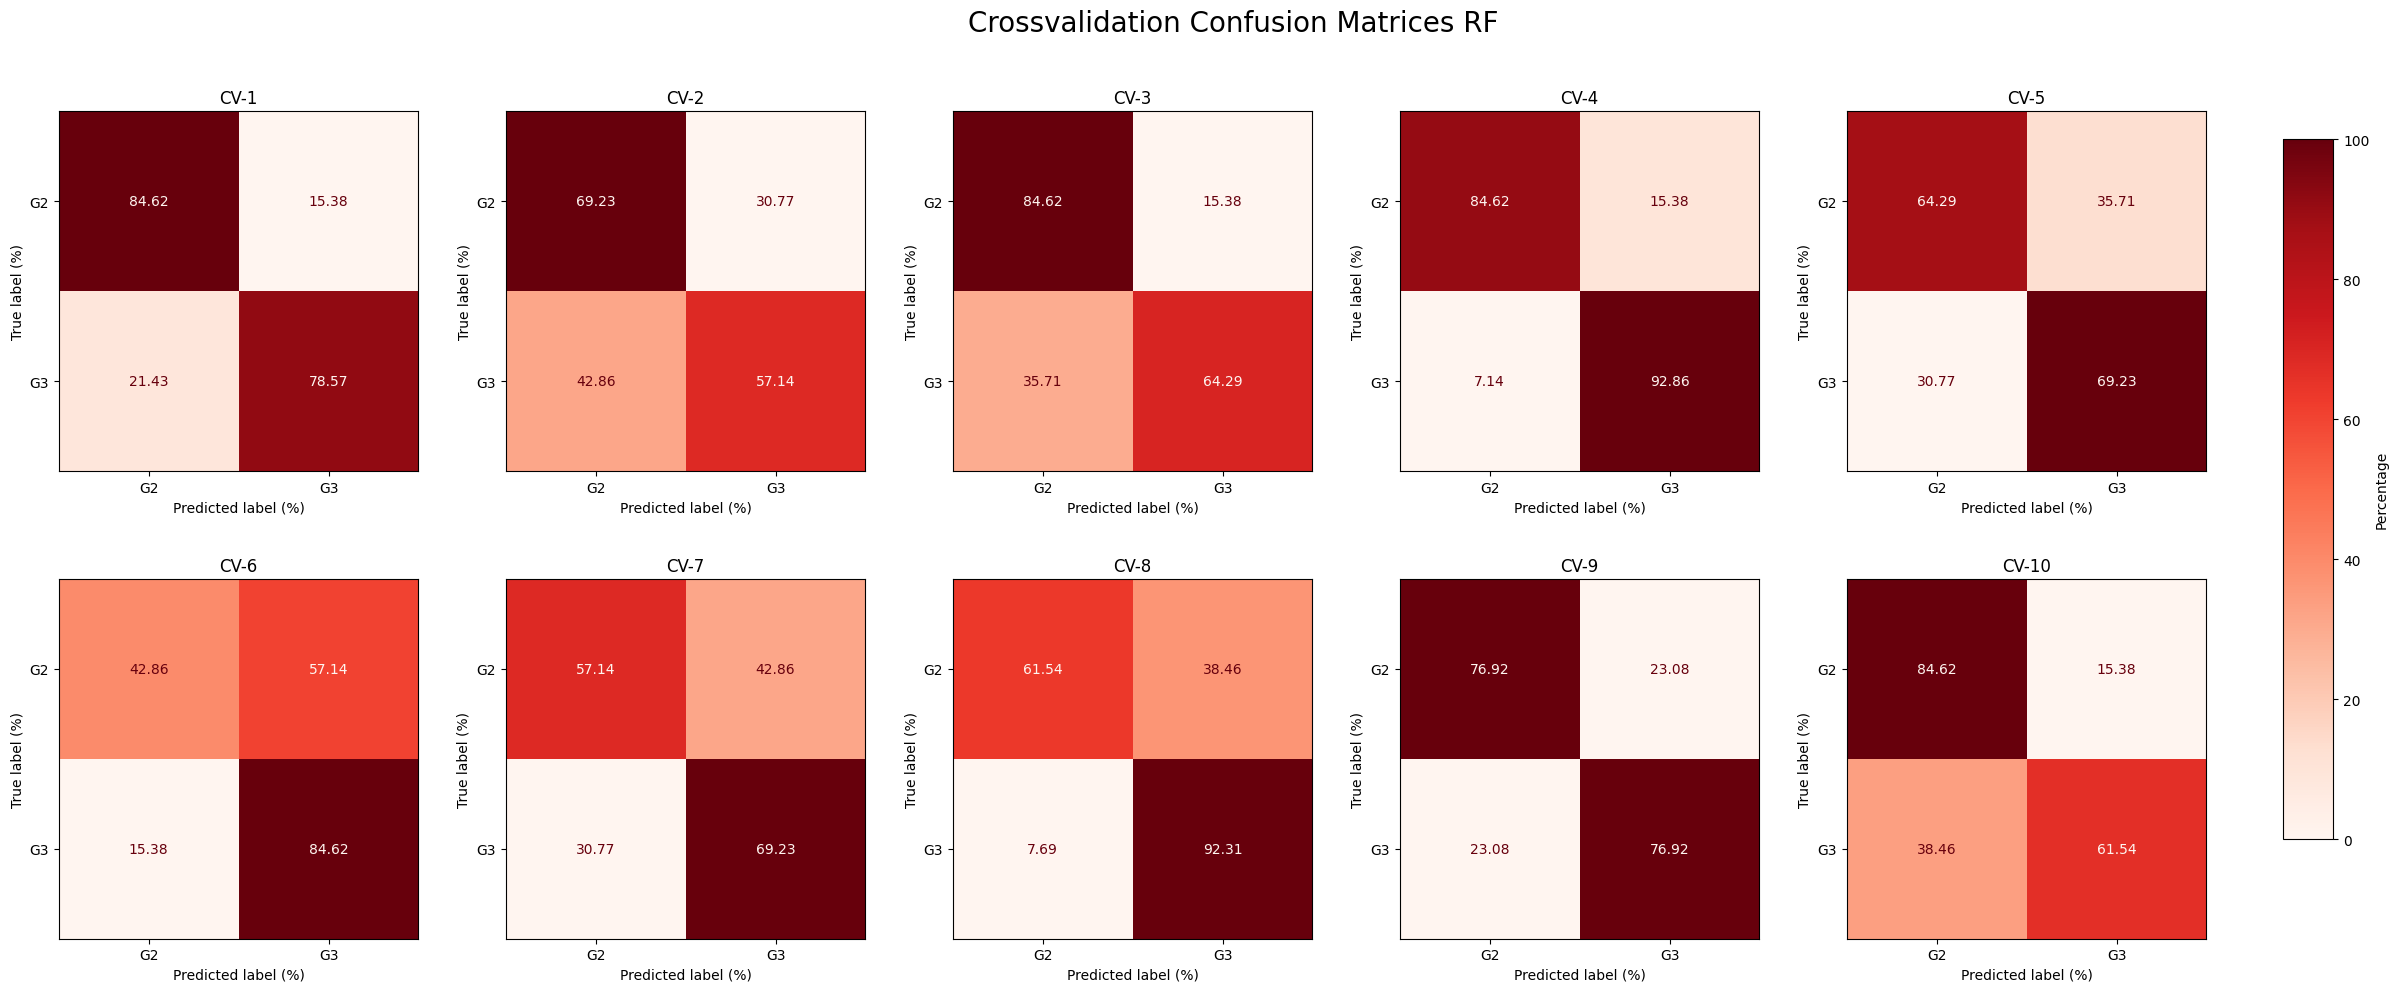

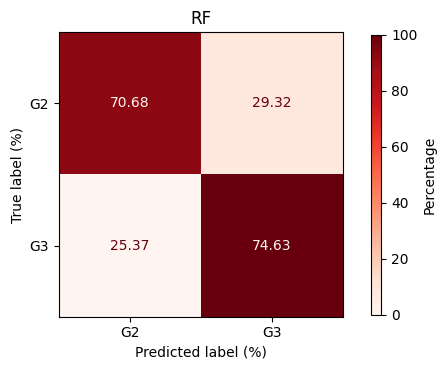

Cross-Validation Results RF:
Accuracy: ['81.48', '62.96', '74.07', '88.89', '66.67', '62.96', '62.96', '76.92', '76.92', '73.08']
Precision: ['81.71', '63.46', '75.53', '89.07', '66.85', '66.76', '63.46', '79.74', '76.92', '74.37']
Recall: ['81.48', '62.96', '74.07', '88.89', '66.67', '62.96', '62.96', '76.92', '76.92', '73.08']
F1: ['81.48', '62.86', '73.86', '88.86', '66.67', '61.38', '62.86', '76.36', '76.92', '72.71']
AUC: ['84.62', '75.82', '80.77', '92.86', '80.22', '73.35', '67.03', '85.21', '86.98', '80.47']

Average Metrics CV RF:
Accuracy: 72.69 +- 8.35
Precision: 73.79 +- 8.10
Recall: 72.69 +- 8.35
F1: 72.40 +- 8.53
AUC: 80.73 +- 6.98

True positive CV RF:
G2: 71.04 ± 13.78
G3: 74.67 ± 11.86


In [ ]:
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
crossvalidation(rf, 'RF',X_train_valid_scaled0, y_train_valid0)

<ipython-input-43-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-43-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


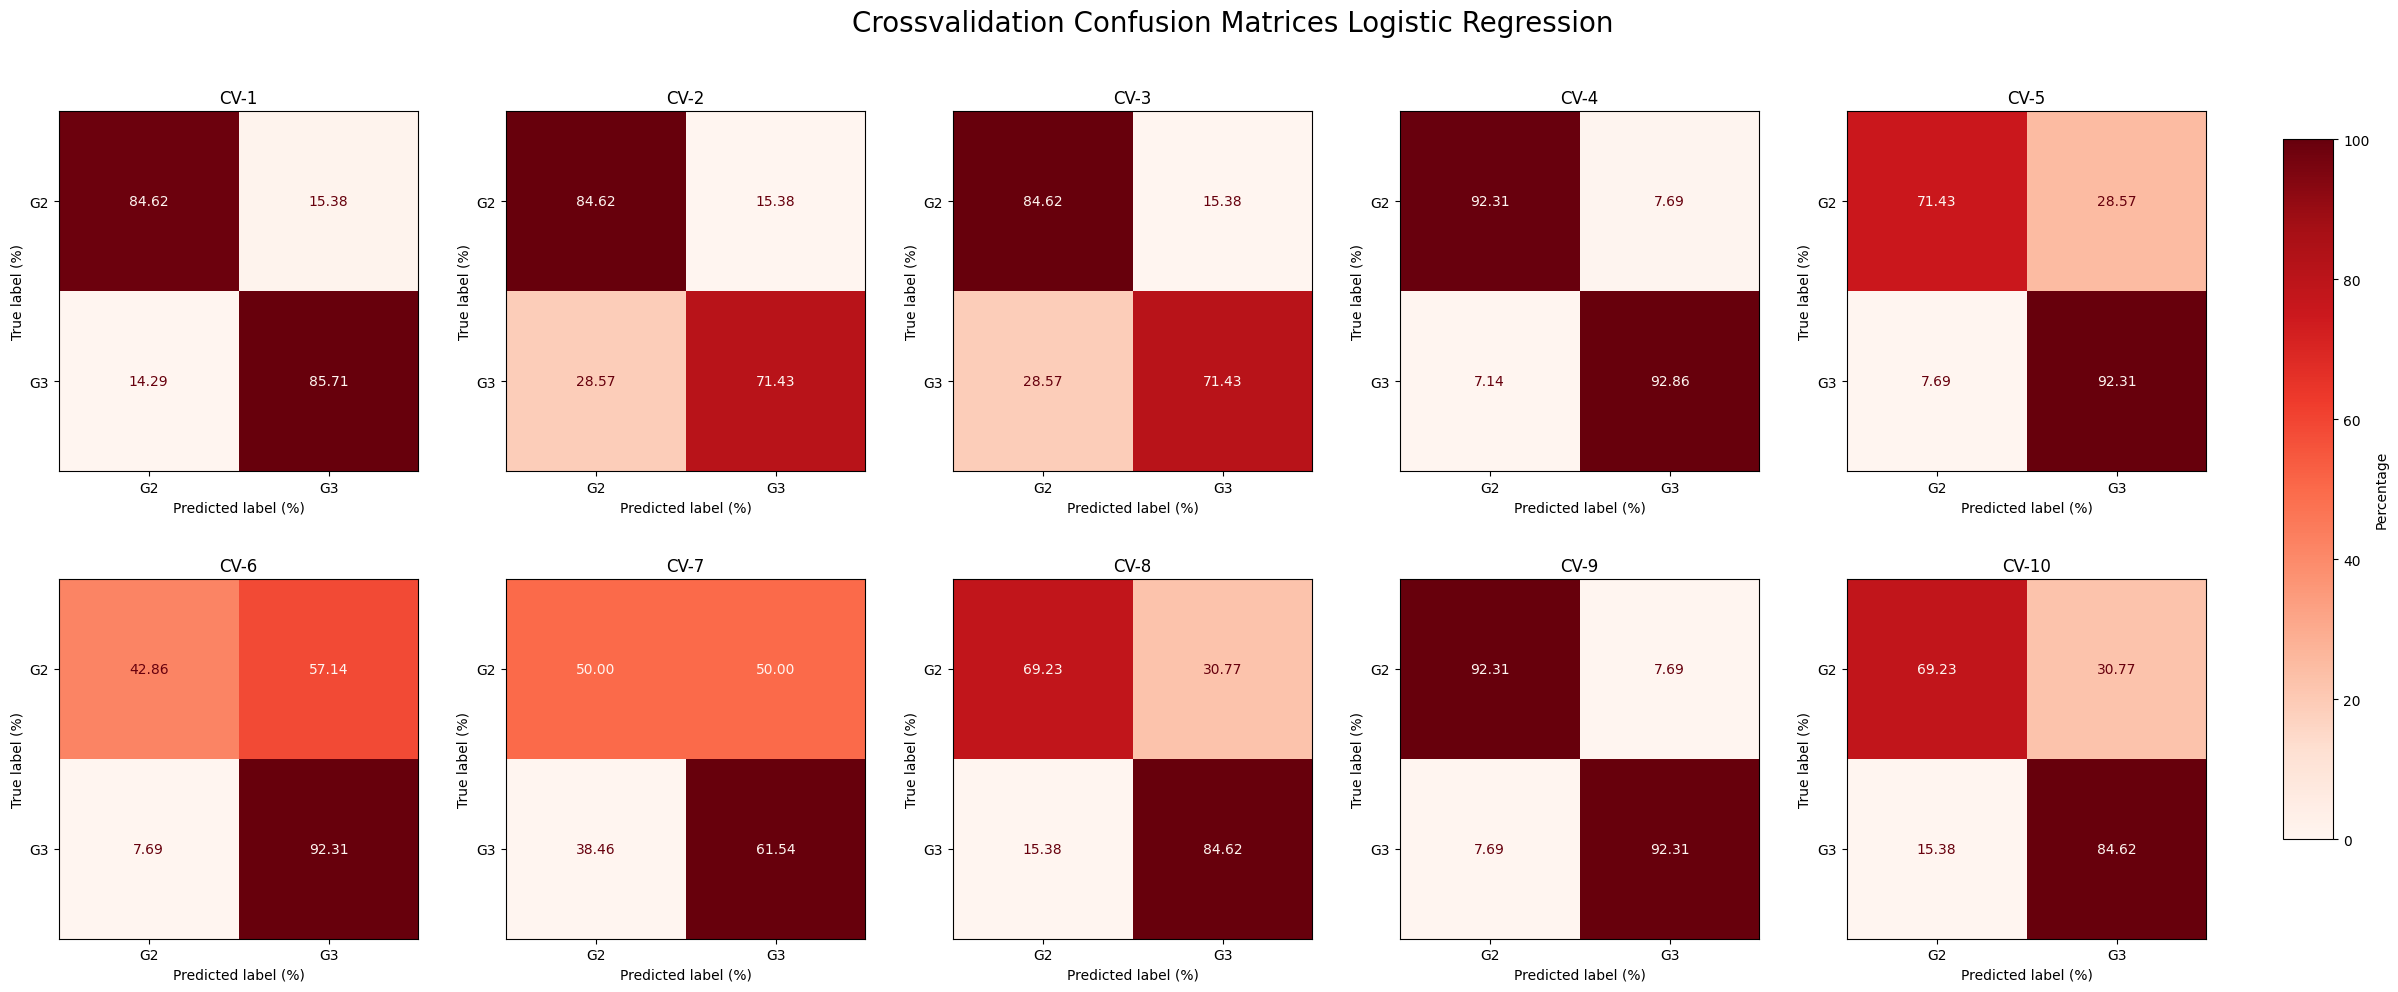

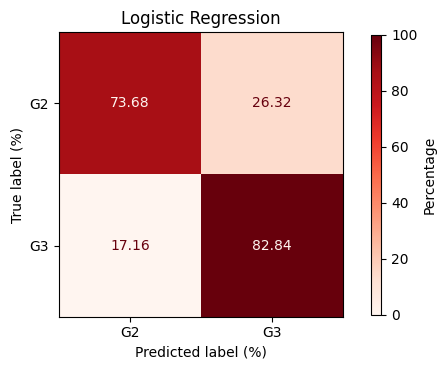

Cross-Validation Results Logistic Regression:
Accuracy: ['85.19', '77.78', '77.78', '92.59', '81.48', '66.67', '55.56', '76.92', '92.31', '76.92']
Precision: ['85.19', '78.52', '78.52', '92.59', '83.25', '73.33', '55.93', '77.58', '92.31', '77.58']
Recall: ['85.19', '77.78', '77.78', '92.59', '81.48', '66.67', '55.56', '76.92', '92.31', '76.92']
F1: ['85.19', '77.72', '77.72', '92.59', '81.33', '64.65', '55.43', '76.79', '92.31', '76.79']
AUC: ['87.91', '79.67', '82.42', '96.70', '90.11', '84.07', '64.84', '76.33', '98.82', '81.07']

Average Metrics CV Logistic Regression:
Accuracy: 78.32 +- 10.56
Precision: 79.48 +- 9.92
Recall: 78.32 +- 10.56
F1: 78.05 +- 10.82
AUC: 84.19 +- 9.43

True positive CV Logistic Regression:
G2: 74.12 ± 16.14
G3: 82.91 ± 10.48


In [ ]:

logistic = LogisticRegression(C=1, penalty='l2', max_iter=100000)

crossvalidation(logistic, 'Logistic Regression', X_train_valid_scaled0, y_train_valid0)

In [ ]:
X_logis, features_logis = select_features(feat_logis, X_df, X_train_valid_scaled0,top=350)
X_logis

Index(['KCNQ1', 'PAPLN', 'NUMA1', 'SLC6A6', 'RAB22A', 'OR8B4', 'C17orf69',
       'CES4', 'DSE', 'CDKL2',
       ...
       'TRIM61', 'ZNF622', 'NARF', 'ZSCAN18', 'ARPC4', 'STARD6', 'MIR2110',
       'P4HA1', 'LASP1', 'CABP4'],
      dtype='object', length=350)


array([[0.12071707, 0.48608453, 0.48179203, ..., 0.55572177, 0.25582436,
        0.87606486],
       [0.01168804, 0.72757153, 0.17441996, ..., 0.55123411, 0.02781909,
        0.89296915],
       [0.07468778, 0.54099083, 0.79897558, ..., 0.47569185, 0.88087725,
        0.86474343],
       ...,
       [0.71024566, 0.46812664, 0.91237487, ..., 0.32610322, 0.72999408,
        0.92599924],
       [0.        , 0.04975569, 0.09125035, ..., 0.48017951, 0.11254579,
        0.93531885],
       [0.12571035, 0.3376486 , 0.51759987, ..., 0.60059835, 0.28024615,
        0.90907271]])

Index(['KCNQ1', 'PAPLN', 'NUMA1', 'SLC6A6', 'RAB22A', 'OR8B4', 'C17orf69',
       'CES4', 'DSE', 'CDKL2',
       ...
       'ORC2L', 'COMT', 'PRL', 'C7orf29', 'ZNF295', 'ATP5O', 'YAP1', 'CDK13',
       'C16orf81', 'NUS1'],
      dtype='object', length=200)


<ipython-input-101-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-101-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


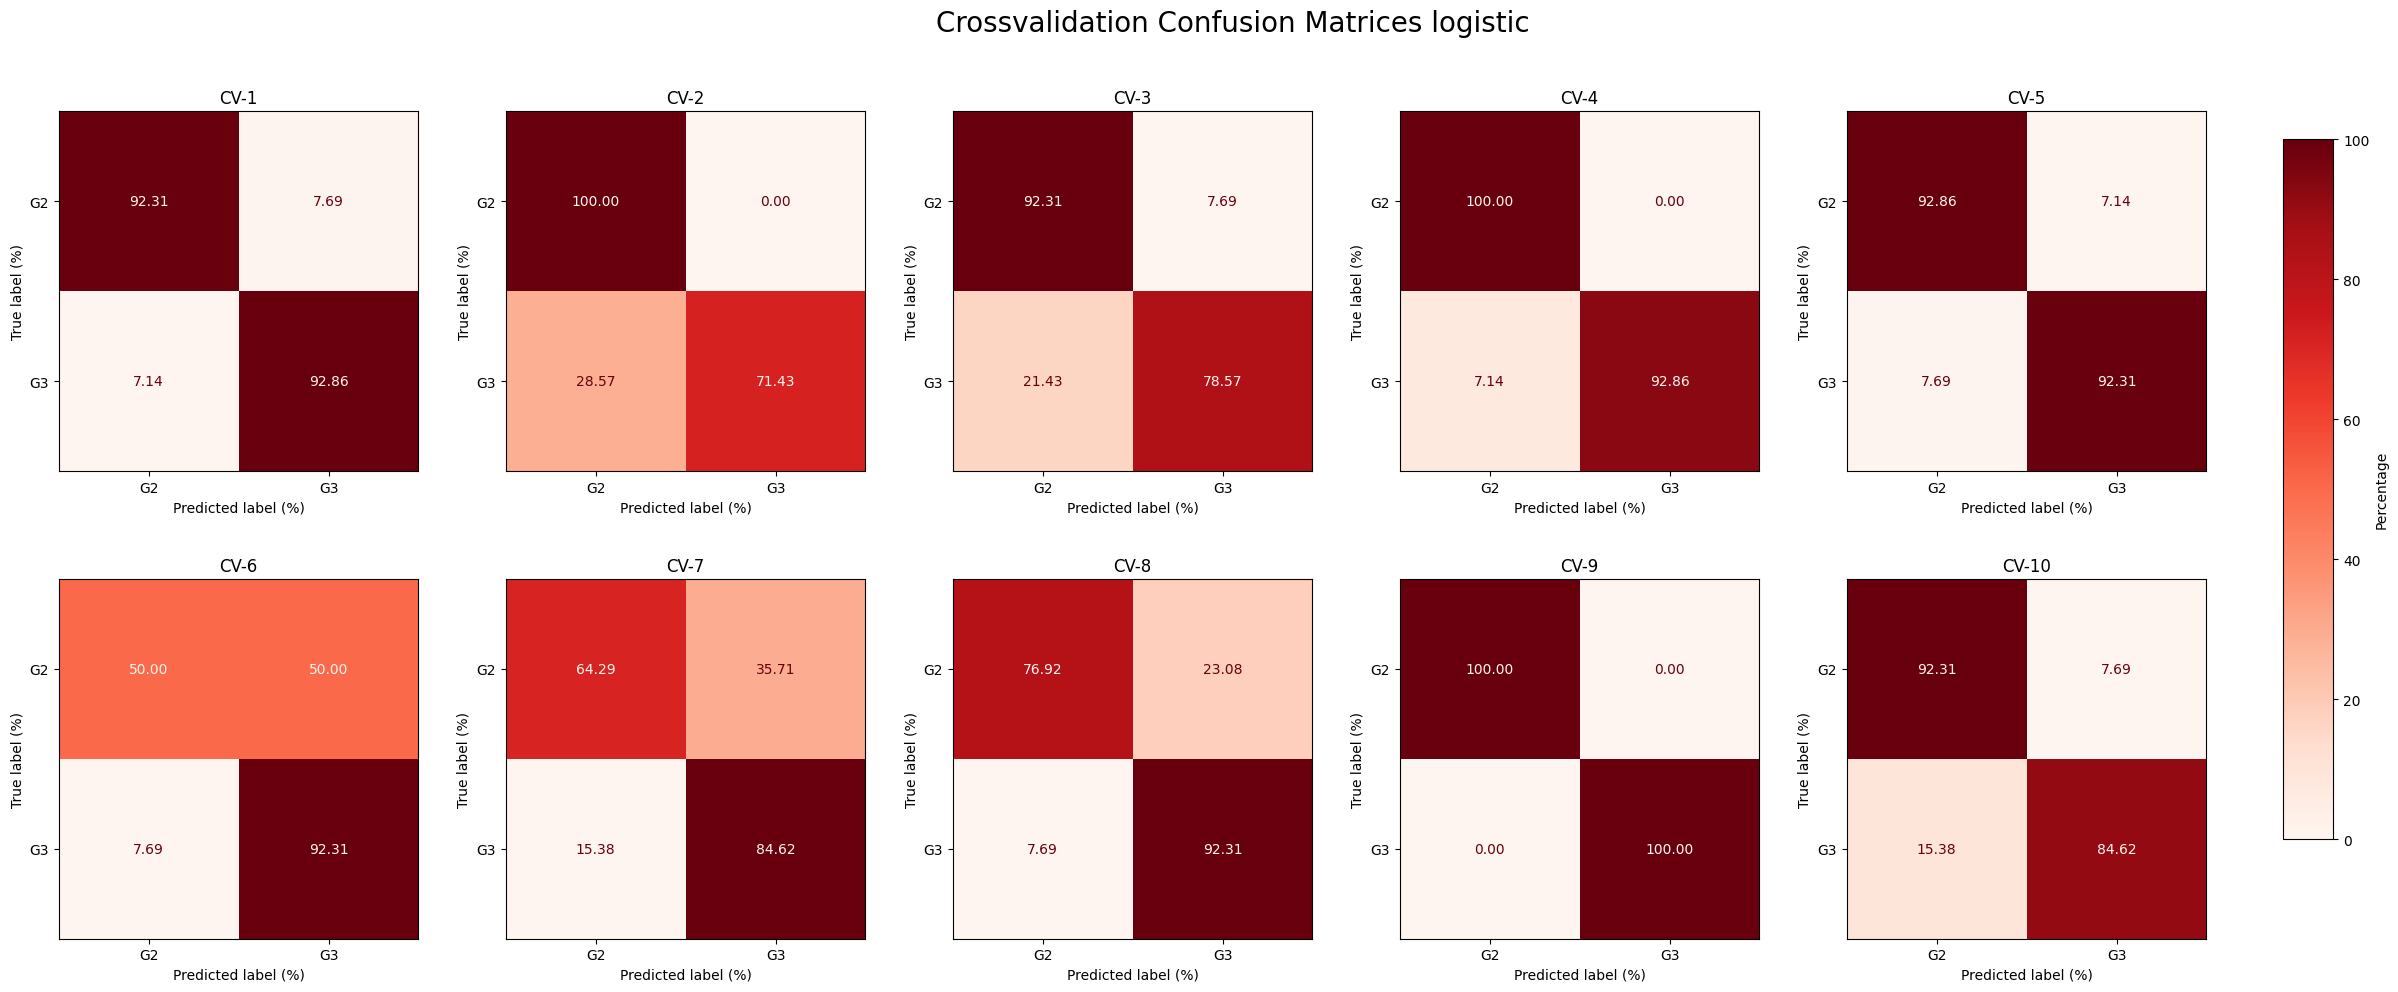

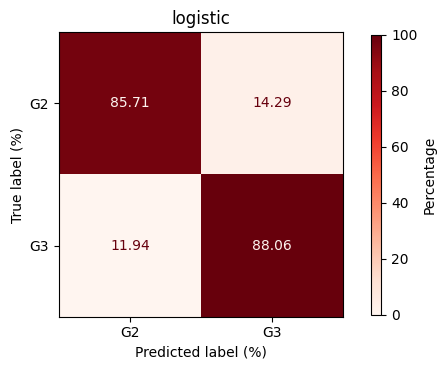

Cross-Validation Results logistic:
Accuracy: ['92.59', '85.19', '85.19', '96.30', '92.59', '70.37', '74.07', '84.62', '100.00', '88.46']
Precision: ['92.59', '88.67', '86.05', '96.56', '92.59', '75.78', '75.53', '85.45', '100.00', '88.69']
Recall: ['92.59', '85.19', '85.19', '96.30', '92.59', '70.37', '74.07', '84.62', '100.00', '88.46']
F1: ['92.59', '84.94', '85.14', '96.30', '92.59', '69.11', '73.86', '84.52', '100.00', '88.44']
AUC: ['96.70', '95.05', '92.31', '100.00', '97.80', '90.11', '83.52', '89.35', '100.00', '95.27']

Average Metrics CV logistic:
Accuracy: 86.94 +- 8.81
Precision: 88.19 +- 7.58
Recall: 86.94 +- 8.81
F1: 86.75 +- 9.09
AUC: 94.01 +- 4.96

True positive CV logistic:
G2: 86.10 ± 16.14
G3: 88.19 ± 7.96


In [ ]:
X_logis, features_logis = select_features(feat_logis, X_df, X_train_valid_scaled0,top=200)
logistic = LogisticRegression(C=1, penalty='l2', max_iter=100000, random_state=42)
crossvalidation(logistic, 'logistic', X_logis, y_train_valid0)

Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD30', 'FAM103A1', 'C21orf56', 'TMEM173', 'PIGB', 'DUSP10', 'LOXL3',
       'PITPNA', 'C6orf145', 'PLCG1'],
      dtype='object', length=225)


<ipython-input-101-04c85cd89efc>:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-101-04c85cd89efc>:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


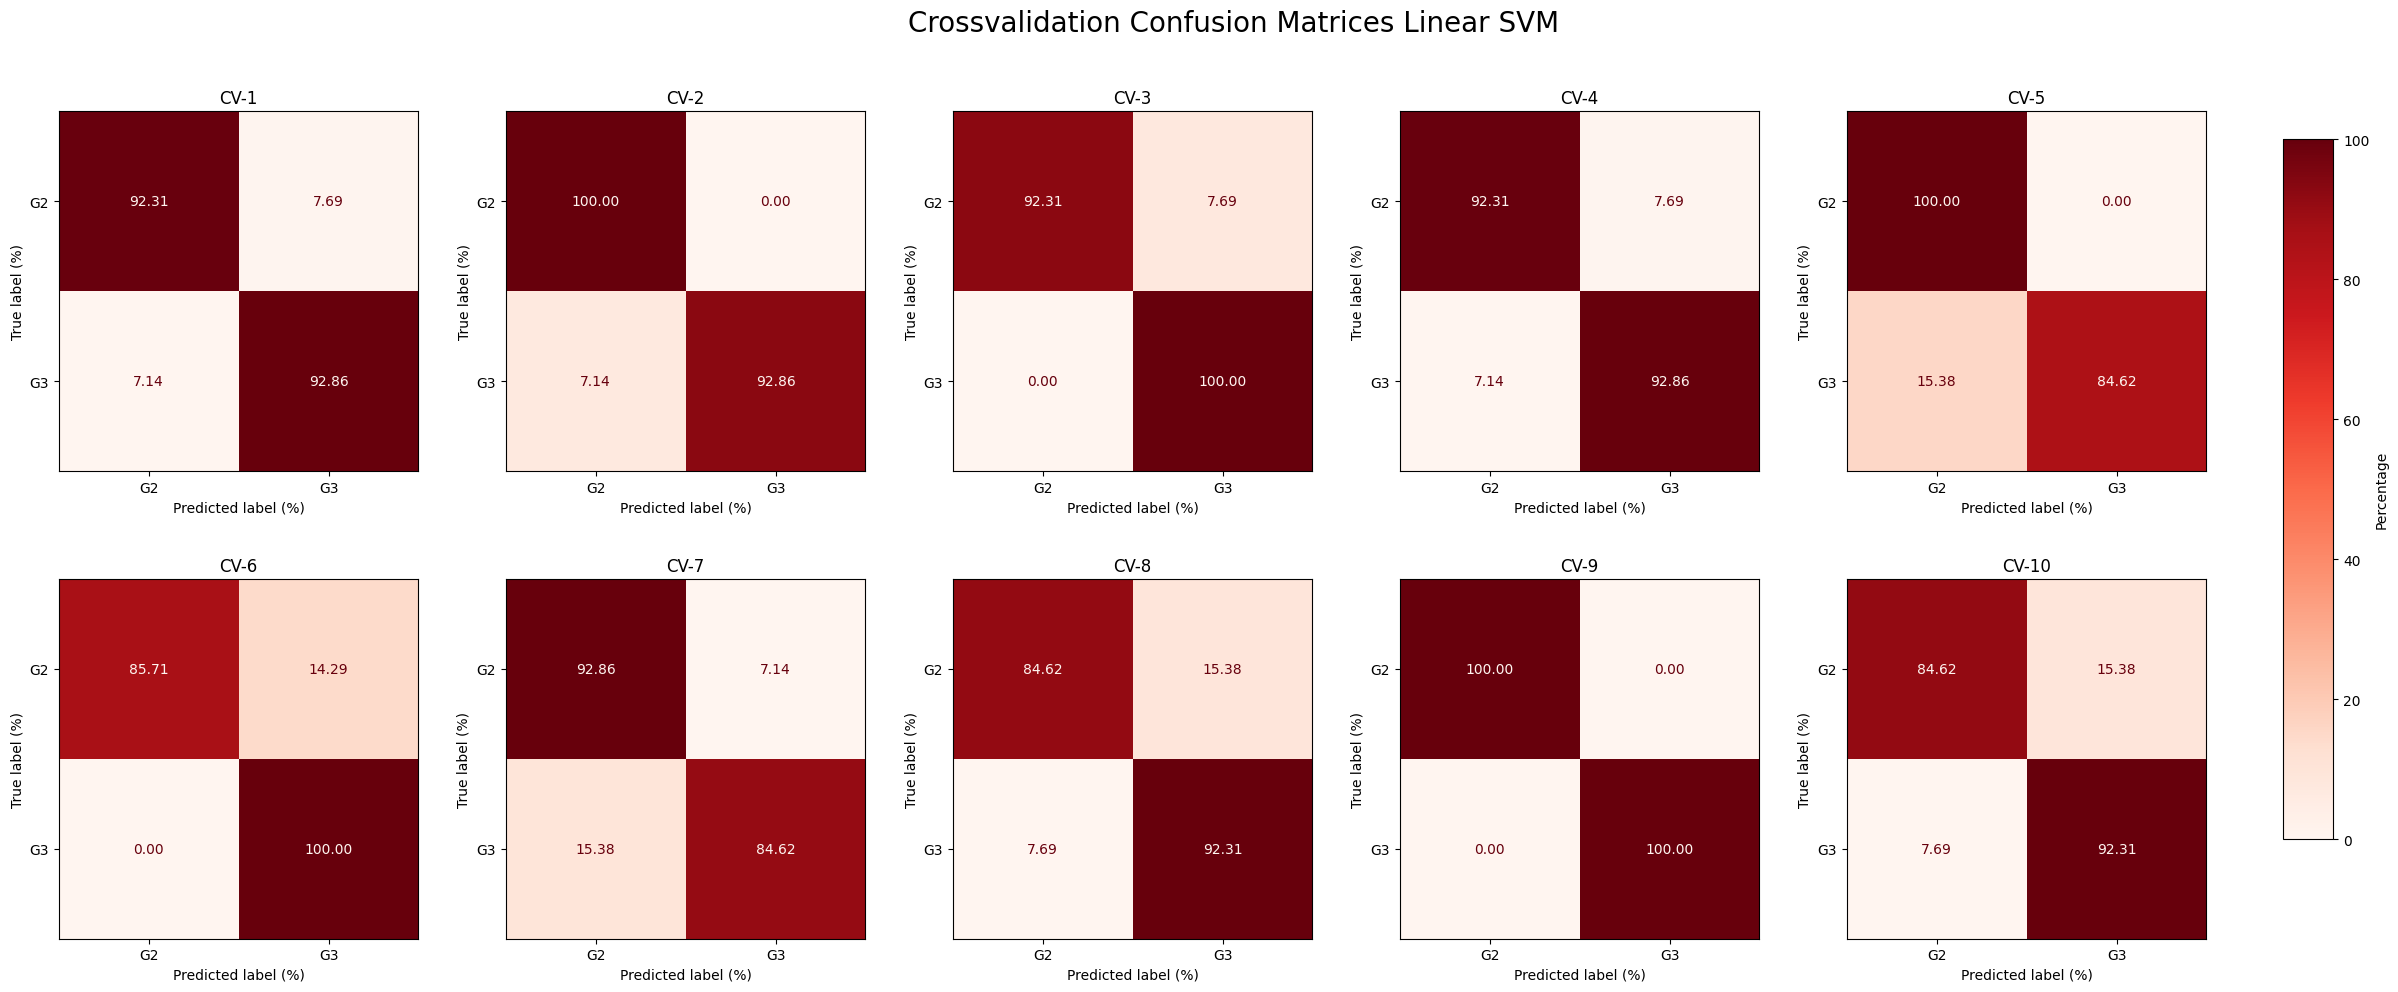

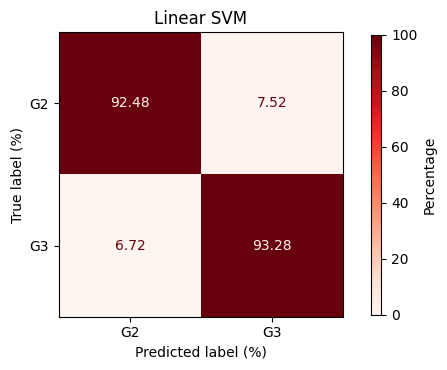

Cross-Validation Results Linear SVM:
Accuracy: ['92.59', '96.30', '96.30', '92.59', '92.59', '92.59', '88.89', '88.46', '100.00', '88.46']
Precision: ['92.59', '96.56', '96.54', '92.59', '93.52', '93.58', '89.07', '88.69', '100.00', '88.69']
Recall: ['92.59', '96.30', '96.30', '92.59', '92.59', '92.59', '88.89', '88.46', '100.00', '88.46']
F1: ['92.59', '96.30', '96.29', '92.59', '92.53', '92.57', '88.86', '88.44', '100.00', '88.44']
AUC: ['97.80', '97.25', '98.90', '97.80', '98.90', '99.45', '93.41', '97.04', '100.00', '98.22']

Average Metrics CV Linear SVM:
Accuracy: 92.88 +- 3.60
Precision: 93.18 +- 3.57
Recall: 92.88 +- 3.60
F1: 92.86 +- 3.60
AUC: 97.88 +- 1.74

True positive CV Linear SVM:
G2: 92.47 ± 5.83
G3: 93.24 ± 5.37


In [ ]:
X_svmg2g3, feat_lsvmg2g3 = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled0,top=225)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_svmg2g3, y_train_valid0)

In [ ]:
X_svmg2g3, feat_lsvmg2g3 = select_features_cv(features_lsvm_g2g3, X_df, X_train_valid_scaled0,top=225)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_svmg2g3, y_train_valid0)

Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'SNORD30', 'FAM103A1', 'C21orf56', 'TMEM173', 'PIGB', 'DUSP10', 'LOXL3',
       'PITPNA', 'C6orf145', 'PLCG1'],
      dtype='object', length=225)
Cross-Validation Results Linear SVM:
Accuracy: ['92.59', '96.30', '96.30', '92.59', '92.59', '92.59', '88.89', '88.46', '100.00', '88.46']
Precision: ['92.59', '96.56', '96.54', '92.59', '93.52', '93.58', '89.07', '88.69', '100.00', '88.69']
Recall: ['92.59', '96.30', '96.30', '92.59', '92.59', '92.59', '88.89', '88.46', '100.00', '88.46']
F1: ['92.59', '96.30', '96.29', '92.59', '92.53', '92.57', '88.86', '88.44', '100.00', '88.44']
AUC: ['97.80', '97.25', '98.90', '97.80', '98.90', '99.45', '93.41', '97.04', '100.00', '98.22']

Average Metrics CV Linear SVM:
Accuracy: 92.88 +- 3.60
Precision: 93.18 +- 3.57
Recall: 92.88 +- 3.60
F1: 92.86 +- 3.60
AUC: 97.88 +- 1.74

Overall Sensitivity (Recall) and Specificity Line

Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ZKSCAN1', 'TBC1D13', 'HERC1', 'THRAP3', 'TMEM55B', 'IARS', 'FCGR3A',
       'HBEGF', 'CORO1C', 'BCL3'],
      dtype='object', length=350)


<ipython-input-357-6c0c5bc0e2af>:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-357-6c0c5bc0e2af>:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


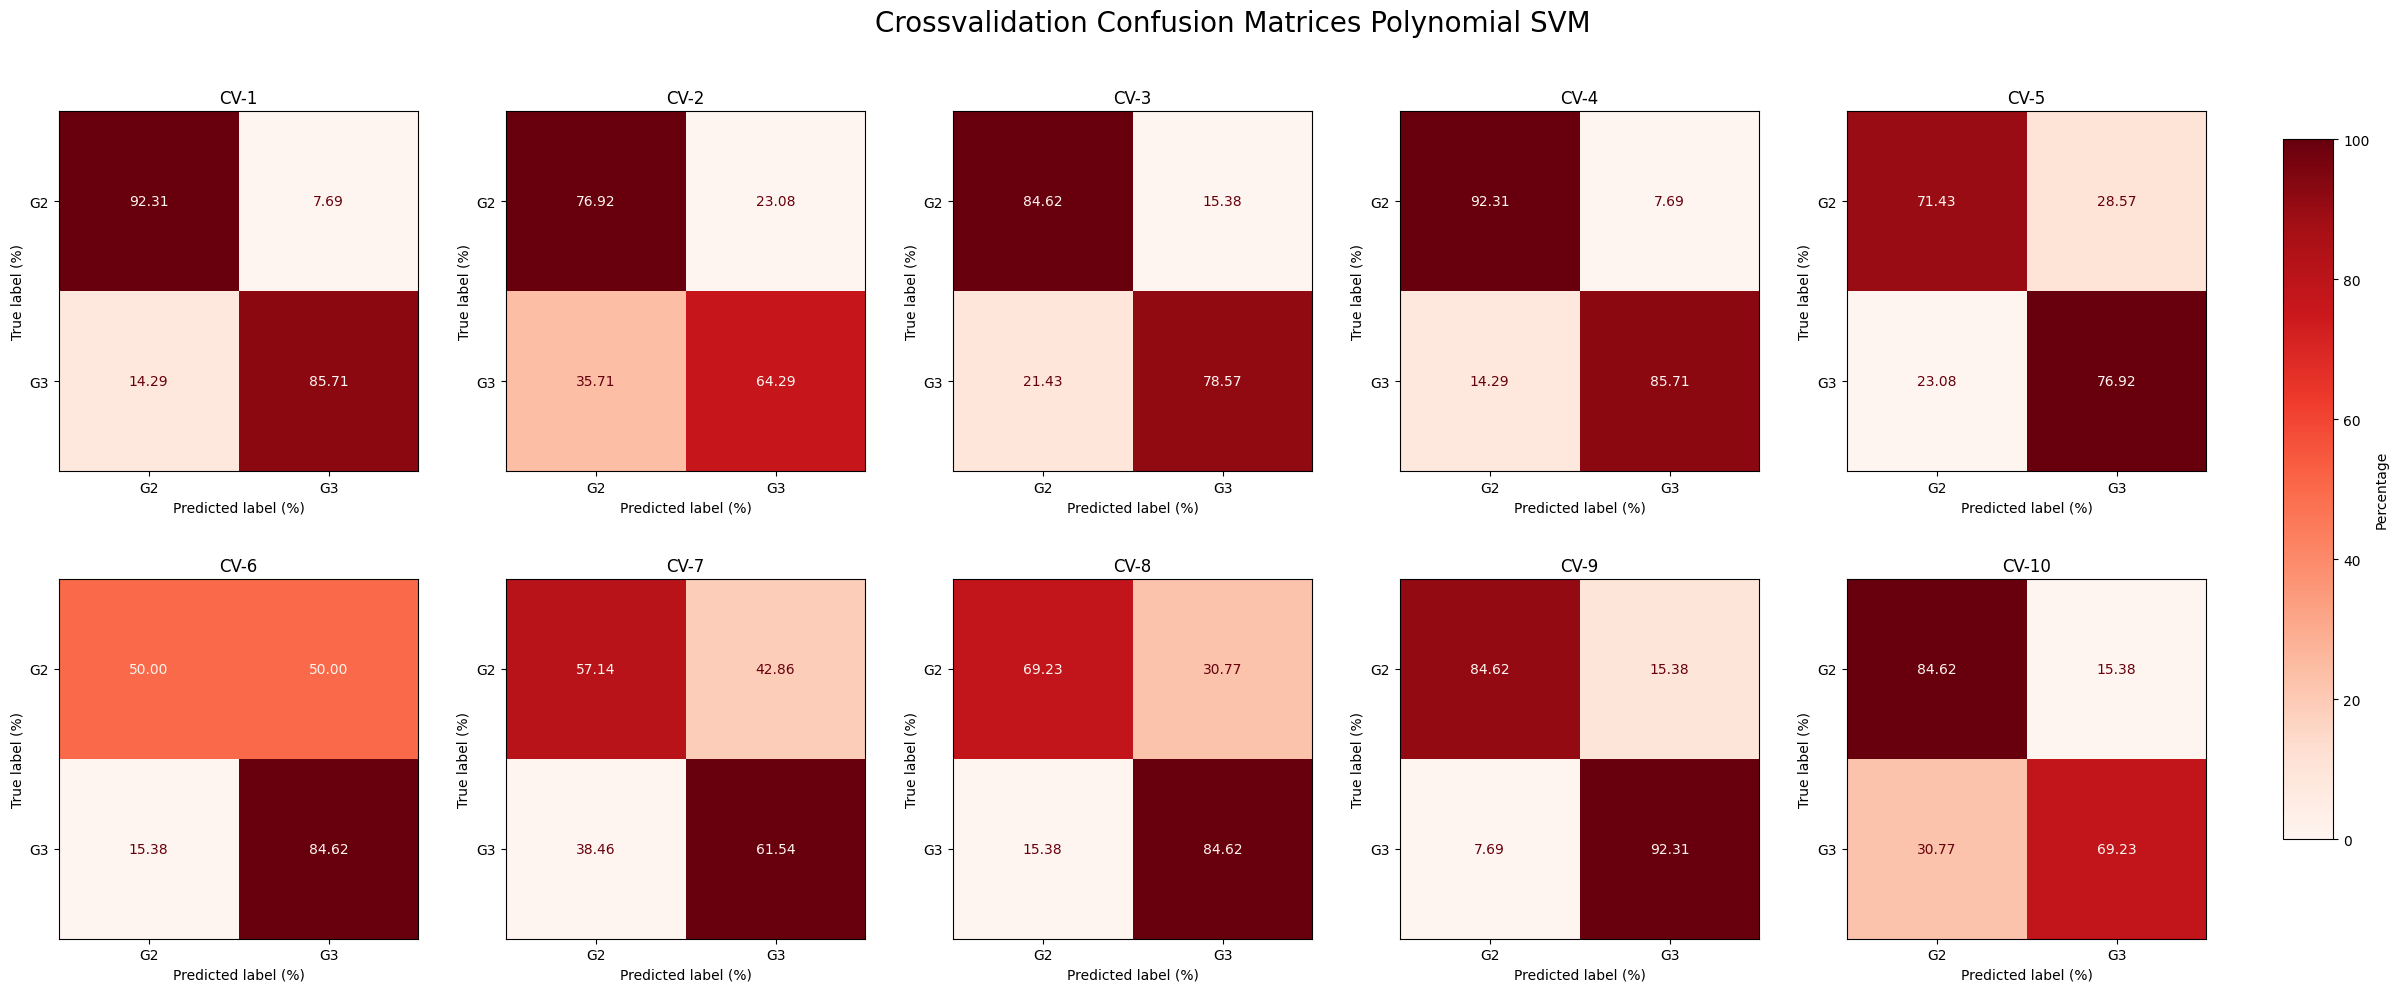

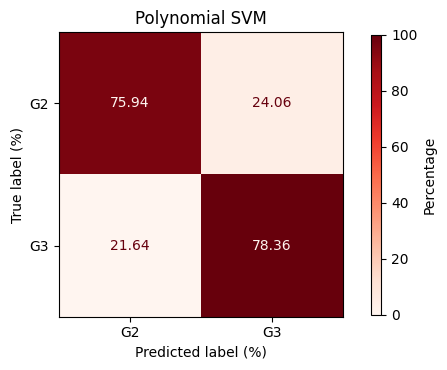

Cross-Validation Results Polynomial SVM:
Accuracy: ['88.89', '70.37', '81.48', '88.89', '74.07', '66.67', '59.26', '76.92', '88.46', '76.92']
Precision: ['89.13', '70.99', '81.71', '89.13', '74.28', '69.75', '59.42', '77.58', '88.69', '77.58']
Recall: ['88.89', '70.37', '81.48', '88.89', '74.07', '66.67', '59.26', '76.92', '88.46', '76.92']
F1: ['88.89', '70.29', '81.48', '88.89', '74.07', '65.73', '59.26', '76.79', '88.44', '76.79']
AUC: ['90.11', '79.12', '89.56', '93.96', '88.46', '79.67', '75.27', '89.35', '94.08', '86.98']

Average Metrics CV Polynomial SVM:
Accuracy: 77.19 +- 9.53
Precision: 77.83 +- 9.23
Recall: 77.19 +- 9.53
F1: 77.06 +- 9.64
AUC: 86.66 +- 6.12

Sensitivity (Recall) for each class Polynomial SVM:
G2: 76.32 ± 13.61
G3: 78.35 ± 9.73

Specificity for each class Polynomial SVM:
G2: 78.35 ± 9.73
G3: 76.32 ± 13.61


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=350)
#svm_poly= SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
svm_poly= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
crossvalidation(svm_poly, 'Polynomial SVM', X_train_importances, y_train_valid0)



Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ZKSCAN1', 'TBC1D13', 'HERC1', 'THRAP3', 'TMEM55B', 'IARS', 'FCGR3A',
       'HBEGF', 'CORO1C', 'BCL3'],
      dtype='object', length=350)


<ipython-input-357-6c0c5bc0e2af>:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
<ipython-input-357-6c0c5bc0e2af>:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])


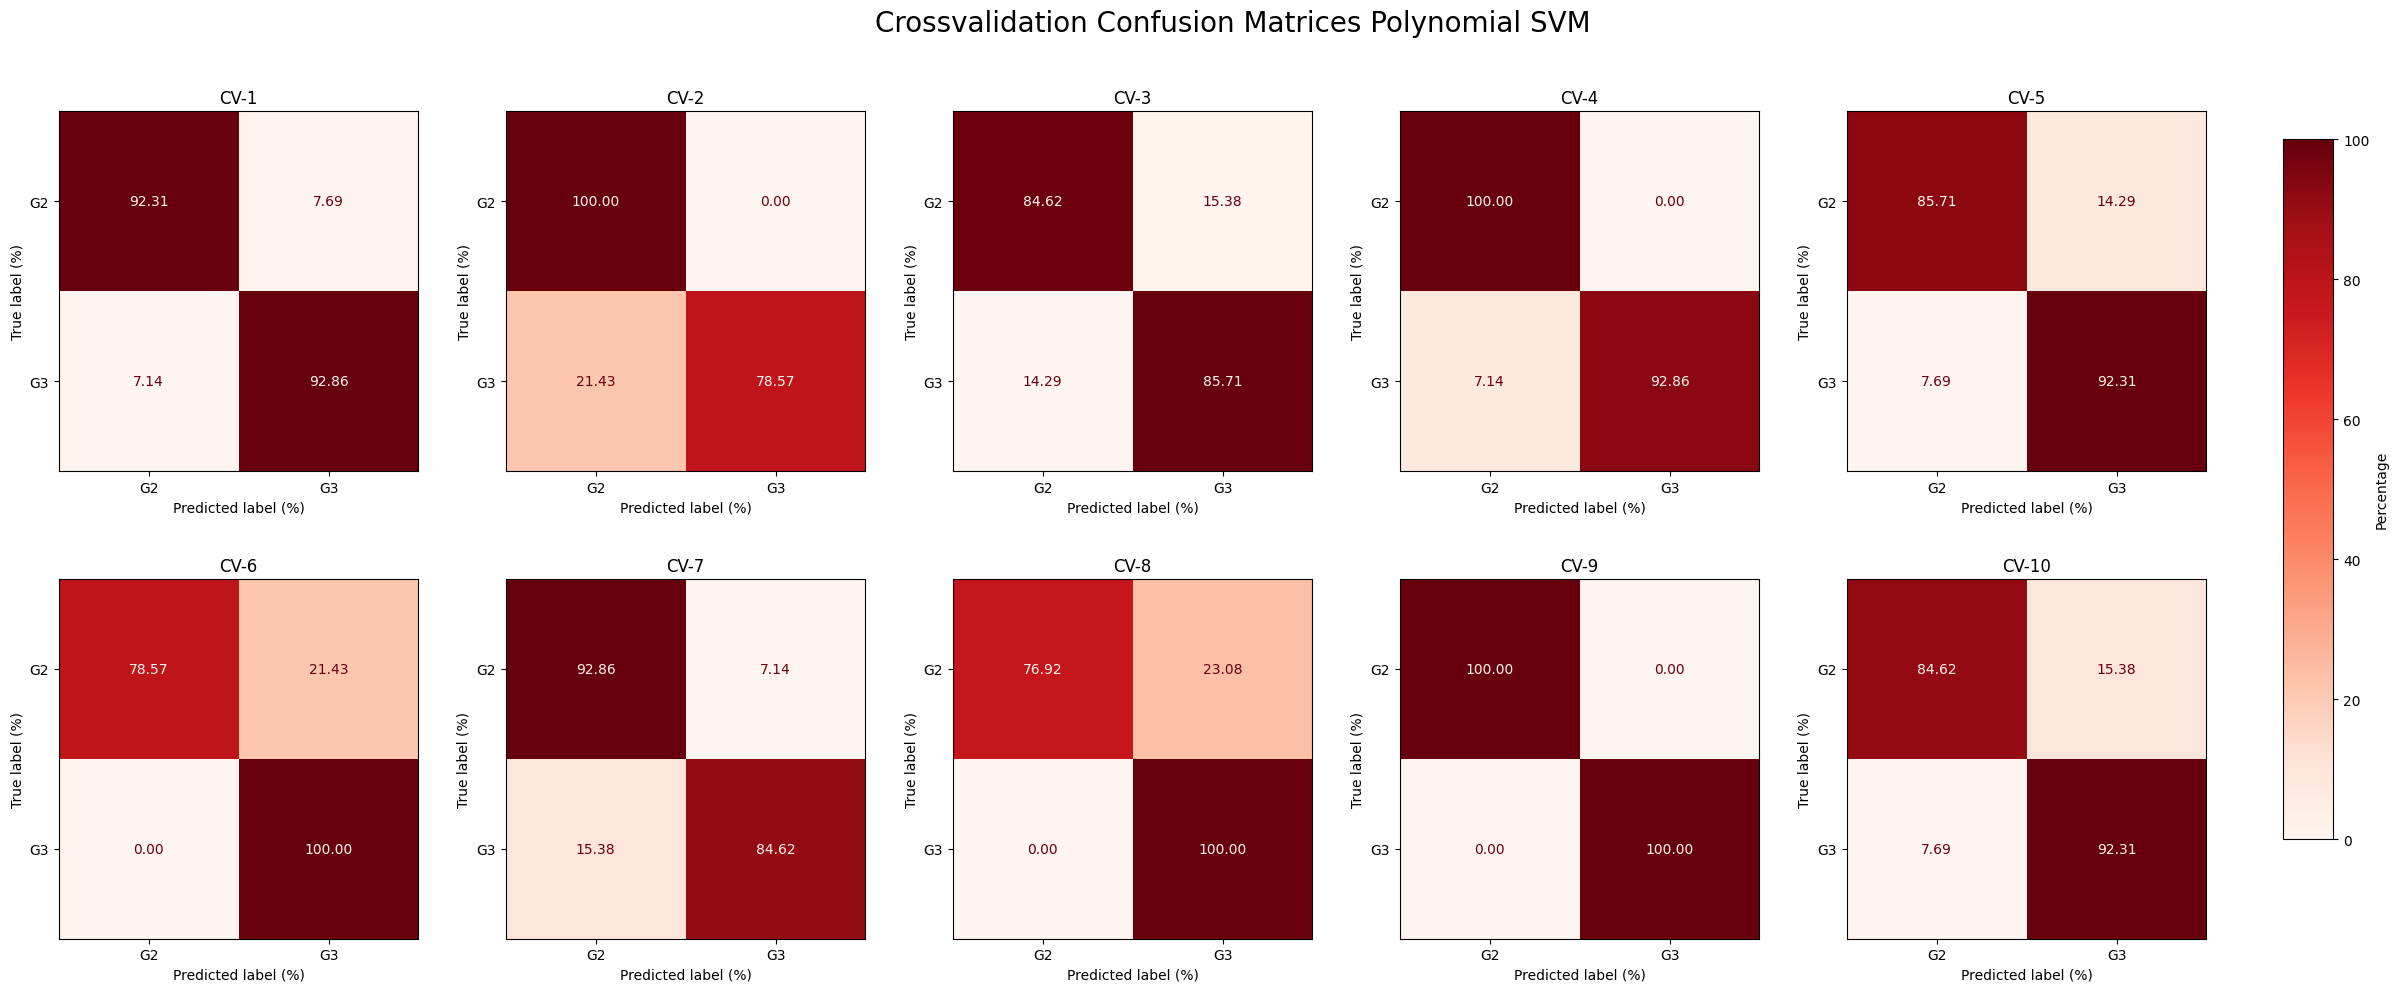

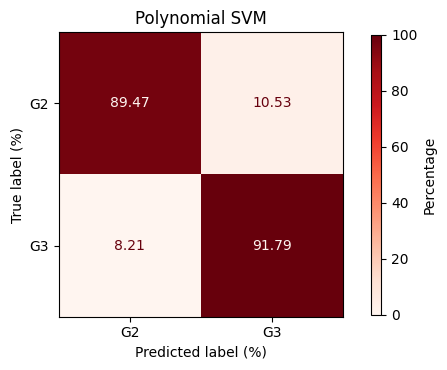

Cross-Validation Results Polynomial SVM:
Accuracy: ['92.59', '88.89', '85.19', '96.30', '88.89', '88.89', '88.89', '88.46', '100.00', '88.46']
Precision: ['92.59', '90.97', '85.19', '96.56', '89.13', '90.97', '89.07', '90.62', '100.00', '88.69']
Recall: ['92.59', '88.89', '85.19', '96.30', '88.89', '88.89', '88.89', '88.46', '100.00', '88.46']
F1: ['92.59', '88.80', '85.19', '96.30', '88.89', '88.80', '88.86', '88.31', '100.00', '88.44']
AUC: ['96.70', '96.15', '95.05', '100.00', '98.90', '97.80', '90.66', '94.67', '100.00', '96.45']

Average Metrics CV Polynomial SVM:
Accuracy: 90.66 +- 4.18
Precision: 91.38 +- 3.99
Recall: 90.66 +- 4.18
F1: 90.62 +- 4.20
AUC: 96.64 +- 2.67

Sensitivity (Recall) for each class Polynomial SVM:
G2: 89.56 ± 8.30
G3: 91.92 ± 6.84

Specificity for each class Polynomial SVM:
G2: 91.92 ± 6.84
G3: 89.56 ± 8.30


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=350)
svm_poly= SVC(kernel ='poly', degree = 3, probability=True,random_state = 42)
crossvalidation(svm_poly, 'Polynomial SVM', X_train_importances, y_train_valid0)



In [ ]:
feat_psvmg2g3

,G2,G3,sum
KCNQ1,0.012439,0.012439,0.024877
SLC6A6,0.007463,0.007463,0.014926
PAPLN,0.006731,0.006731,0.013463
OR8B4,0.006409,0.006409,0.012817
NEDD1,0.006096,0.006096,0.012192
...,...,...,...
CEBPG,0.000512,0.000512,0.001025
PDSS1,0.000484,0.000484,0.000967
HRAS,0.000480,0.000480,0.000960
VARS2,0.000470,0.000470,0.000940


In [ ]:
y_train_valid0

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1])

# Evaluation Test G2 G3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

def plot_confusion_matrix_single(cm, class_names, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    print(cm_normalized)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    fig, ax = plt.subplots()
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds')
    disp.plot(values_format='.2f', cmap='Reds', colorbar=False, ax=ax)  # Plot without the default colorbar
    plt.title(title)
    plt.xlabel('Predicted label (%)')
    plt.ylabel('True label (%)')

    # Add the color bar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Percentage (%)', rotation=-90, va="bottom")
    plt.figure(figsize=(5, 5))
    plt.show()

def calculate_metrics(classifier, X_train, X_test, y_train, y_test):
    # Step 4: Make predictions on the testing data
    y_pred = classifier.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_pred)

    # Calculate specificity for each class
    specificity_per_class = []
    for i in range(cm.shape[0]):
        tn = np.sum(cm) - (np.sum(cm[:, i]) + np.sum(cm[i, :]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)

    # Calculate overall specificity as the average of specificities for each class
    overall_specificity = np.mean(specificity_per_class)

    return accuracy, precision, recall, f1, auc, overall_specificity, cm

def plot_decision_boundary(model, X, y, title, class_names, random_state=42):
    # Perform PCA to reduce to two dimensions with a fixed random_state
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)

    # Create a meshgrid covering the PCA-transformed feature space
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    # Predict the class for each point in the meshgrid
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    # Define the custom colormap
    cmap_background = ListedColormap(['#e0f3f8', '#4575b4'])  # Light blue for 'G2', dark blue for 'G3'
    cmap_points = ListedColormap(['#e0f3f8', '#4575b4'])

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_background)

    # Plot the data points
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', cmap=cmap_points)
    plt.title(title)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
    plt.show()

def evaluation_test(X_train, X_test, y_train, y_test, classifier, model_title, class_names):
    classifier.fit(X_train, y_train)

    # Evaluate the model and get metrics
    accuracy, precision, recall, f1, auc, overall_specificity, cm = calculate_metrics(classifier, X_train, X_test, y_train, y_test)

    # Output the results
    print(f"Evaluation metrics for {model_title}")
    print(f"Accuracy: {accuracy*100:.2f} %")
    print(f"Precision: {precision*100:.2f} %")
    print(f"Recall: {recall*100:.2f} %")
    print(f"F1-score: {f1*100:.2f} %")
    print(f"AUC: {auc*100:.2f} %")
    print(f"Overall Specificity: {overall_specificity*100:.2f} %")
    print(f"Confusion Matrix {model_title}:")

    plot_confusion_matrix_single(cm, class_names=class_names, title=model_title)

    # Plot decision boundary using PCA to reduce to 2D
    plot_decision_boundary(classifier, X_test, y_test, title=f"Decision Boundary - {model_title}", class_names=class_names)

# Example usage:
# Assuming you have a classifier, training data (X_train, y_train), testing data (X_test, y_test), and class names defined:
# classifier = SomeClassifier()
class_names = ['G2', 'G3']
# evaluation_test(X_train, X_test, y_train, y_test, classifier, 'Your Model Title', class_names)


Index(['KCNQ1', 'SLC6A6', 'PAPLN', 'OR8B4', 'NEDD1', 'PYGO1', 'C17orf69',
       'HOXD4', 'CES4', 'BMP4',
       ...
       'ZKSCAN1', 'TBC1D13', 'HERC1', 'THRAP3', 'TMEM55B', 'IARS', 'FCGR3A',
       'HBEGF', 'CORO1C', 'BCL3'],
      dtype='object', length=350)
Evaluation metrics for Kernel SVM
Accuracy: 85.07 %
Precision: 85.18 %
Recall: 85.12 %
F1-score: 85.07 %
AUC: 85.12 %
Overall Specificity: 85.12 %
Confusion Matrix Kernel SVM:
[[82.35294118 17.64705882]
 [12.12121212 87.87878788]]


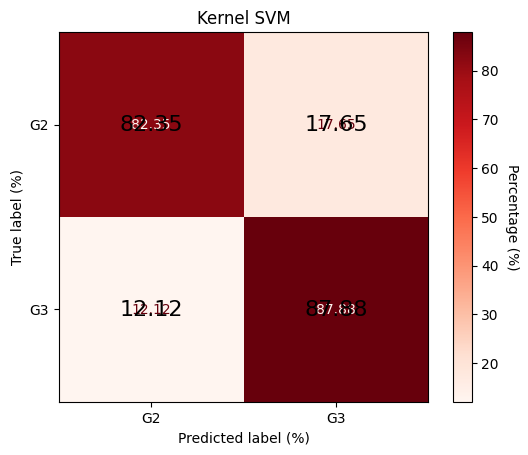

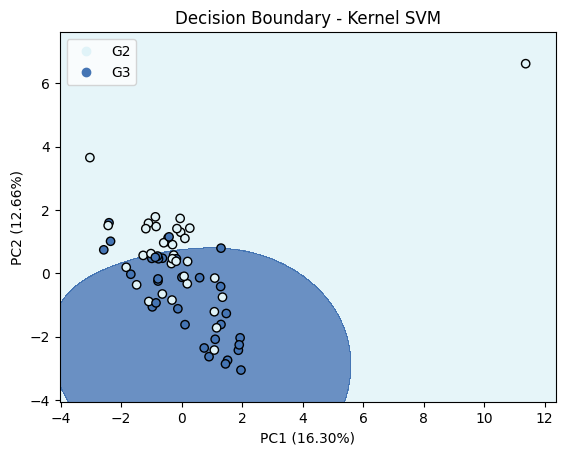

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=350)
model= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
#model= SVC(kernel ='poly',degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid0, y_test0, model, 'Kernel SVM', class_names)



In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_psvmg2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=370)
model= SVC(kernel ='rbf', gamma = 0.1 , C = 1, probability=True,random_state = 42)
#model= SVC(kernel ='poly',degree = 3, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid0, y_test0, model, 'Kernel SVM', class_names)



Index(['MIR1975', 'NUMA1', 'WDR38', 'MIR376B', 'PAPLN', 'PIGB', 'SLC6A6',
       'FAM195B', 'MIER2', 'TRIAP1',
       ...
       'CAPNS1', 'ENSA', 'METTL13', 'TMEM39B', 'ZBTB22', 'TC2N', 'CDC42EP5',
       'GFOD2', 'ZNF738', 'IRF2'],
      dtype='object', length=900)
Evaluation metrics for Kernel SVM
Accuracy: 85.07 %
Precision: 96.00 %
Recall: 72.73 %
F1-score: 82.76 %
AUC: 84.89 %
Overall Specificity: 84.89 %
Confusion Matrix Kernel SVM:
[[97.05882353  2.94117647]
 [27.27272727 72.72727273]]


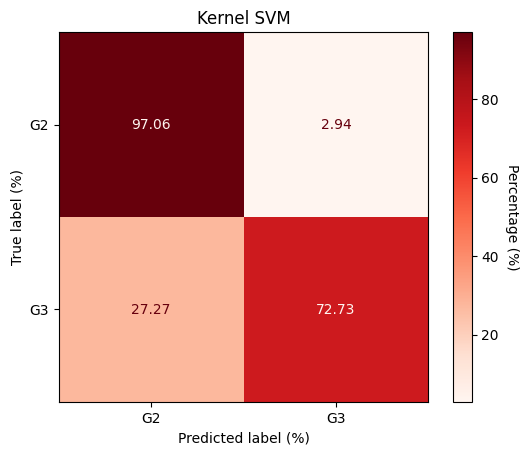

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(features_rbfsvm_g2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=900)
model= SVC(kernel ='rbf', gamma = 0.12 , C = 1, probability=True,random_state = 42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid0, y_test0, model, 'Kernel SVM', class_names)



In [ ]:
X_train_importances, X_test_importances, top_features = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=247)
model = SVC(kernel='linear', probability = True, random_state=42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid0, y_test0, model, 'Linear SVM', class_names)



Index(['KCNQ1', 'OR8B4', 'MIR10B', 'SLC6A6', 'C4orf31', 'C17orf69', 'NAPSB',
       'PYGO1', 'RRBP1', 'HOXD4',
       ...
       'TCIRG1', 'STAG3', 'CRTAC1', 'FREM1', 'DEGS1', 'ARAP1', 'SPRY4',
       'TBXAS1', 'C20orf30', 'VASH2'],
      dtype='object', length=250)
Evaluation metrics for Linear SVM
Accuracy: 76.12 %
Precision: 79.90 %
Recall: 76.38 %
F1-score: 75.46 %
AUC: 76.38 %
Overall Specificity: 76.38 %
Confusion Matrix Linear SVM:
[[58.82352941 41.17647059]
 [ 6.06060606 93.93939394]]


TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'fontsize'

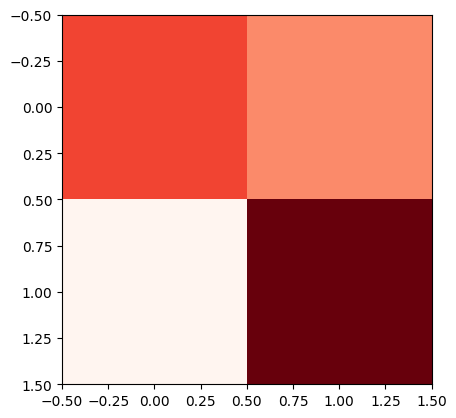

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled0, X_test_scaled0, top=250)
model = SVC(kernel='linear', probability = True, random_state=42)
evaluation_test(X_train_importances, X_test_importances, y_train_valid0, y_test0, model, 'Linear SVM', class_names)



In [ ]:
X_svmg2g3, feat_lsvmg2g3 = select_features(features_lsvm_g2g3, X_df, X_train_valid_scaled0,top=225)
svm_linear = SVC(kernel='linear', probability = True, random_state=42)
crossvalidation(svm_linear, 'Linear SVM', X_svmg2g3, y_train_valid0)

#Neural Network model final

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.0008, dropout_rate=0.25, regularizer=0.009):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer))) #512
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)

    # Calculate sensitivity and specificity for each class
    sensitivity = recall_score(y_test_classes, y_pred, average=None)
    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))

    return accuracy, precision, recall, f1, auc, cm, history, sensitivity, specificity

def train_and_evaluate(X_train, X_test, y_train, y_test, save_model, learning_rate = 0.0008, dropout_rate = 0.25, batch_size = 8, epochs = 100, regularizer = 0.009):
    input_dim = X_train.shape[1]
    num_classes = len(np.unique(np.argmax(y_train, axis=1)))

    model = create_model(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
    accuracy, precision, recall, f1, auc, cm, history, sensitivity, specificity = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs)

    fig, ax = plt.subplots(figsize=(5, 4))
    plot_confusion_matrix(cm, class_names=class_names, ax=ax, title='Confusion Matrix')

    print('======================================================================')
    print('Evaluation Results:')
    print(f'Accuracy: {accuracy * 100:.2f}')
    print(f'Precision: {precision * 100:.2f}')
    print(f'Recall: {recall * 100:.2f}')
    print(f'F1: {f1 * 100:.2f}')
    print(f'AUC: {auc * 100:.2f}')

    print("Sensitivity (Recall) for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {sensitivity[idx] * 100:.2f} %")

    print("Specificity for each class:")
    for idx, class_name in enumerate(class_names):
        print(f"Class {class_name}: {specificity[idx] * 100:.2f} %")

    # Plot accuracy and loss
    plot_accuracy_loss(history)

    # Save the model
    model.save(save_model)
    print(f'Model saved to: {save_model}')

def plot_accuracy_loss(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Plot training & validation accuracy values
    ax[0].plot(history.history['accuracy'])
    ax[0].plot(history.history['val_accuracy'])
    ax[0].set_title('Model accuracy')
    ax[0].set_ylabel('Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    ax[1].plot(history.history['loss'])
    ax[1].plot(history.history['val_loss'])
    ax[1].set_title('Model loss')
    ax[1].set_ylabel('Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Validation'], loc='upper left')

    plt.show()

# Example usage:
# X_train, X_test, y_train, y_test should be your datasets
# Ensure y_train and y_test are one-hot encoded
# train_and_evaluate(X_train, X_test, y_train, y_test, 'model.h5')


Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 4ms/step
Evaluation Results:
Accuracy: 84.33
Precision: 84.04
Recall: 84.33
F1: 84.13
AUC: 95.35
Sensitivity (Recall) for each class:
Class NT: 100.00 %
Class G1: 93.94 %
Class G2: 67.65 %
Class G3: 75.76 %
Specificity for each class:
Class NT: 99.00 %
Class G1: 97.03 %
Class G2: 92.00 %
Class G3: 91.09 %


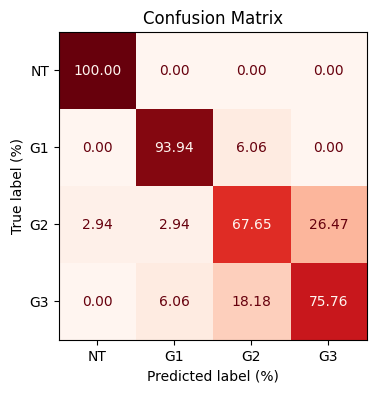

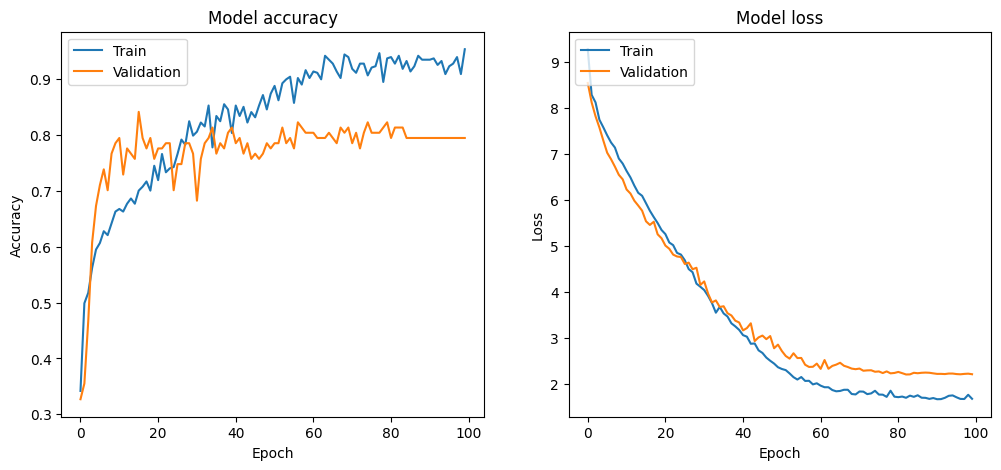

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to: save87_1.h5


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_1.h5')

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 4ms/step
Evaluation Results:
Accuracy: 85.82
Precision: 85.54
Recall: 85.82
F1: 85.58
AUC: 94.48


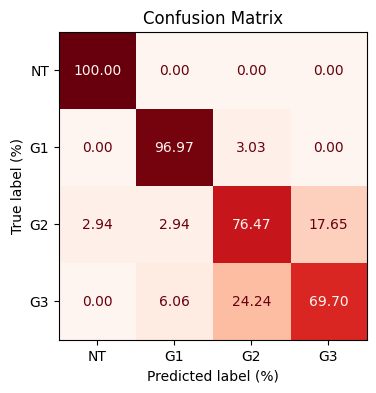

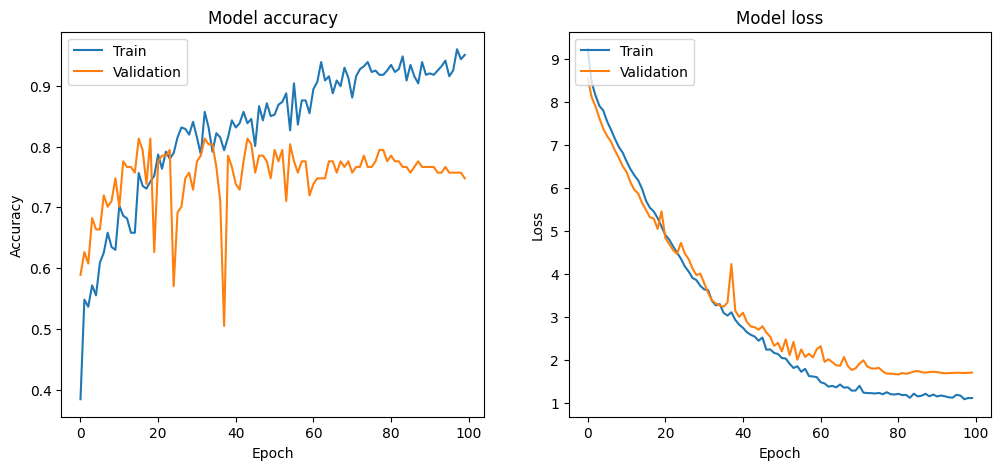

Model saved to: save87_1.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_1.h5')

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 6ms/step
Evaluation Results:
Accuracy: 82.09
Precision: 81.54
Recall: 82.09
F1: 81.77
AUC: 95.15


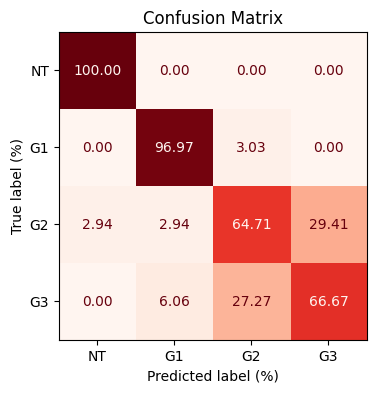

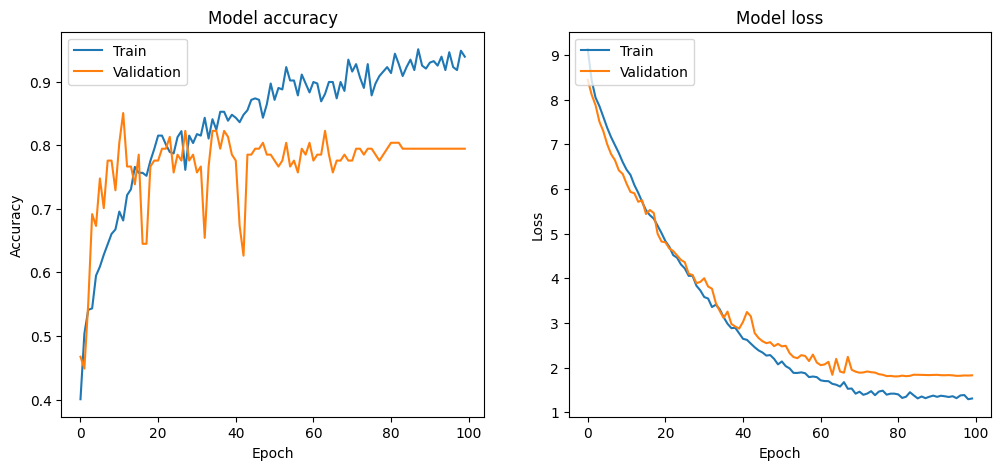

Model saved to: save87_5.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_5.h5')

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 4ms/step
Evaluation Results:
Accuracy: 84.33
Precision: 84.28
Recall: 84.33
F1: 84.24
AUC: 94.95


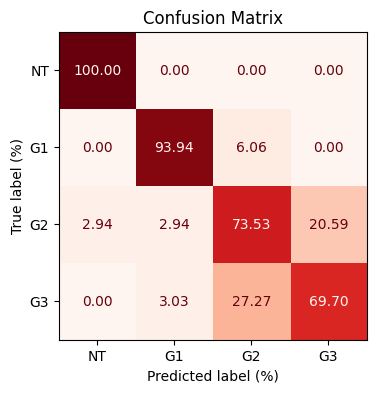

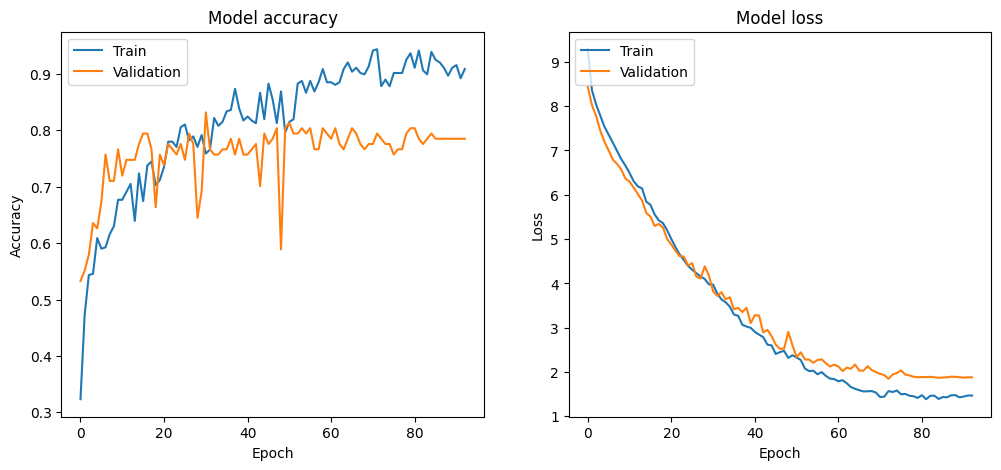

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to: save87.h5


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87.h5')

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 5ms/step
Evaluation Results:
Accuracy: 84.33
Precision: 83.70
Recall: 84.33
F1: 83.88
AUC: 93.92


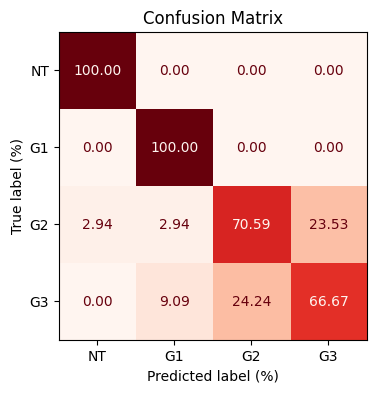

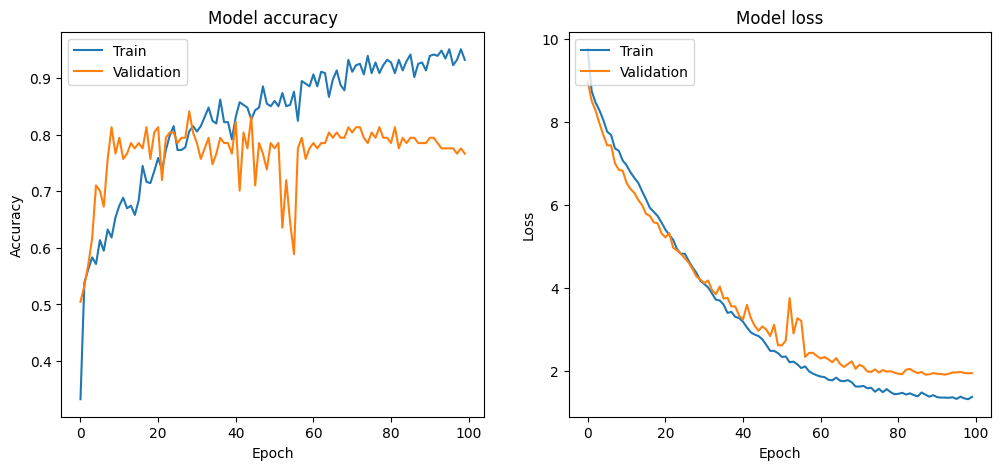

Model saved to: save87_2.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_2.h5', regularizer = 0.0095)

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 3ms/step
Evaluation Results:
Accuracy: 85.07
Precision: 84.63
Recall: 85.07
F1: 84.61
AUC: 95.22


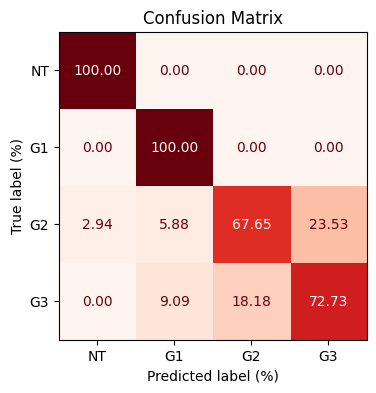

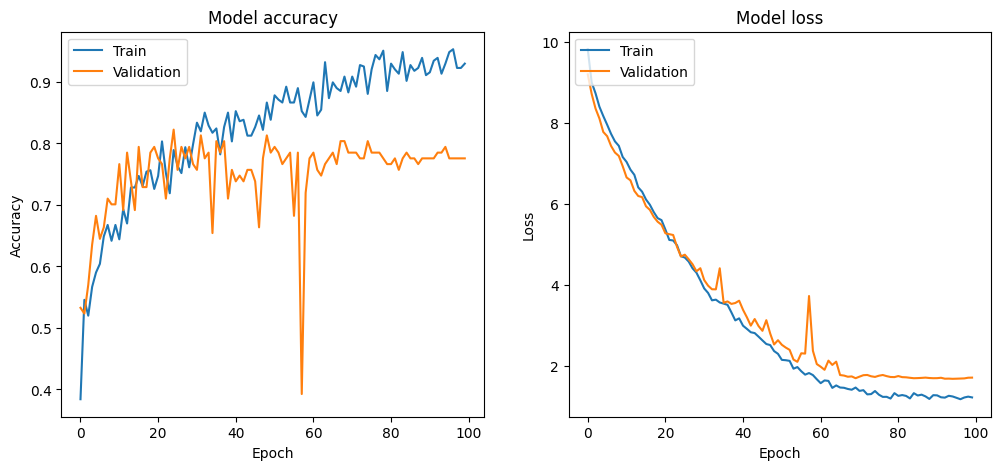

Model saved to: save87_3.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_3.h5', regularizer = 0.0098)

Index(['NEDD1', 'NUMA1', 'E2F6', 'KCNQ1', 'ATPGD1', 'COLEC11', 'BOLL', 'PAPLN',
       'RAB22A', 'C17orf90',
       ...
       'POPDC2', 'GPNMB', 'AGRN', 'FGL1', 'FCGR3A', 'FLAD1', 'SNORD94',
       'MRPS23', 'ZNF227', 'SLC39A7'],
      dtype='object', length=175)
5/5 [==============================] - 0s 4ms/step
Evaluation Results:
Accuracy: 79.10
Precision: 78.27
Recall: 79.10
F1: 78.49
AUC: 94.52


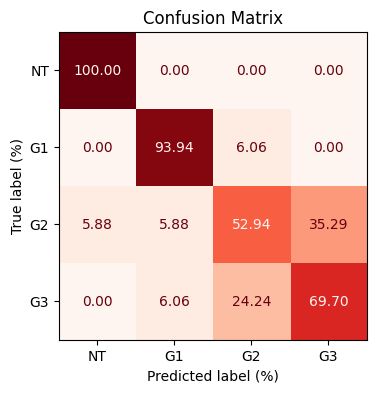

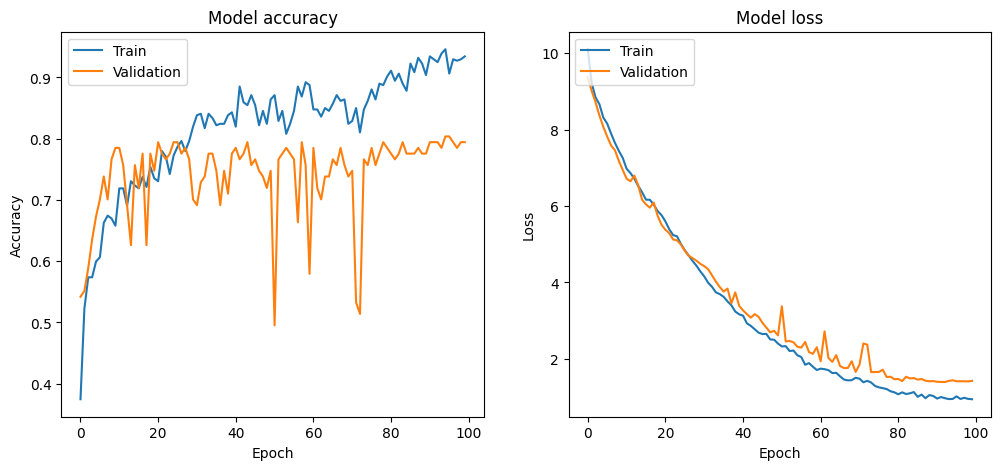

Model saved to: save87_4.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save87_4.h5', regularizer = 0.01)

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save2.h5', learning_rate = )

SyntaxError: invalid syntax (<ipython-input-31-b167eff99825>, line 2)

In [ ]:
X_train_importances, X_test_importances, top_features = select_features(feat_nn, X_df, X_train_valid_scaled, X_test_scaled, top=175)
train_and_evaluate(X_train_importances, X_test_importances, y_train_hot, y_test_hot, 'save84.h5')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Custom class names
class_names = ['NT', 'G1', 'G2', 'G3']

def plot_confusion_matrix(cm, class_names, ax, title):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Normalize by actual class count and convert to percentage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(ax=ax, values_format='.2f', cmap='Reds', colorbar=False)  # Remove individual colorbars
    ax.set_title(title)
    ax.set_xlabel('Predicted label (%)')
    ax.set_ylabel('True label (%)')

def create_model(input_dim, num_classes, learning_rate=0.001, dropout_rate=0.1, regularizer=0.001):
    model = Sequential()
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(regularizer)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    #model.summary()
    return model

def calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms):
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_schedule], verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_test_classes)
    precision = precision_score(y_test_classes, y_pred, average='weighted')
    recall = recall_score(y_test_classes, y_pred, average='weighted')
    f1 = f1_score(y_test_classes, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    cm = confusion_matrix(y_test_classes, y_pred)
    cms.append(cm)

    return accuracy, precision, recall, f1, auc, cm

def crossvalidation(classifier_func, model_title, X, y, num_folds=10, random_state=42):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
    input_dim = X.shape[1]
    num_classes = len(np.unique(y))
    y = label_binarize(y, classes=range(num_classes))

    learning_rate = 0.0008
    dropout_rate = 0.25
    batch_size = 8
    epochs = 100
    regularizer = 0.009

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    cms = []

    tp_percentages = {label: [] for label in range(num_classes)}

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (train_index, test_index) in enumerate(kf.split(X, y.argmax(axis=1))):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = classifier_func(input_dim, num_classes, learning_rate, dropout_rate, regularizer)
        accuracy, precision, recall, f1, auc, cm = calculate_metrics(model, X_train, X_test, y_train, y_test, batch_size, epochs, cms)

        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        for label in range(num_classes):
            if cm[label].sum() > 0:  # Avoid division by zero
                tp_percentages[label].append(cm[label, label] / cm[label].sum() * 100)
            else:
                tp_percentages[label].append(0)

        plot_confusion_matrix(cm, class_names=class_names, ax=axes[i], title=f'CV-{i+1}')

    plot_confusion_matrices(cms, class_names, fig, model_title)

    # Print cross-validation results
    print('======================================================================')
    print(f'Cross-Validation Results {model_title}:')
    print(f'Accuracy: {[f"{score * 100:.2f}" for score in accuracy_scores]}')
    print(f'Precision: {[f"{score * 100:.2f}" for score in precision_scores]}')
    print(f'Recall: {[f"{score * 100:.2f}" for score in recall_scores]}')
    print(f'F1: {[f"{score * 100:.2f}" for score in f1_scores]}')
    print(f'AUC: {[f"{score * 100:.2f}" for score in auc_scores]}')

    print('\n======================================================================')
    print(f'Average Metrics CV {model_title}:')
    print(f'Accuracy: {np.mean(accuracy_scores) * 100:.2f} +- {np.std(accuracy_scores) * 100:.2f}')
    print(f'Precision: {np.mean(precision_scores) * 100:.2f} +- {np.std(precision_scores) * 100:.2f}')
    print(f'Recall: {np.mean(recall_scores) * 100:.2f} +- {np.std(recall_scores) * 100:.2f}')
    print(f'F1: {np.mean(f1_scores) * 100:.2f} +- {np.std(f1_scores) * 100:.2f}')
    print(f'AUC: {np.mean(auc_scores) * 100:.2f} +- {np.std(auc_scores) * 100:.2f}')

    tp_avg_std = {label: (np.mean(tp_percentages[label]), np.std(tp_percentages[label])) for label in range(num_classes)}

    print('\n======================================================================')
    print(f'True positive CV {model_title}:')
    for label in range(num_classes):
        avg, std = tp_avg_std[label]
        print(f'{class_names[label]}: {avg:.2f} ± {std:.2f}')

def plot_confusion_matrices(cms, class_names, fig, model_title):
    """
    Plots confusion matrices for each fold and the average confusion matrix.
    """
    fig.suptitle(f'Crossvalidation Confusion Matrices {model_title}', fontsize=20)

    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation='vertical', label='Percentage')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.subplots_adjust(hspace=0.3)

    avg_cm = np.mean(cms, axis=0)
    fig_avg, ax_avg = plt.subplots(figsize=(5, 4))

    plot_confusion_matrix(avg_cm, class_names=class_names, ax=ax_avg, title=f'{model_title}')

    cax_avg = fig_avg.add_axes([0.75, 0.15, 0.02, 0.7])
    norm_avg = plt.Normalize(vmin=0, vmax=100)
    sm_avg = plt.cm.ScalarMappable(cmap='Reds', norm=norm_avg)
    sm_avg.set_array([])
    fig_avg.colorbar(sm_avg, cax=cax_avg, orientation='vertical', label='Percentage')

    fig_avg.tight_layout(rect=[0, 0, 0.8, 0.95])
    plt.show()

# Example usage:
# X, y should be your dataset
# crossvalidation(create_model, 'Neural Network', X, y)
